## 0. Google Drive setup, saved model path, and dependencies


## 0A. Main user config: Google Drive project, saved model folder, and requirements.txt



Edit this first section when you want to move folders, change model-download behavior, or point to a different `requirements.txt`.

Default parent folder:

```text
/content/drive/MyDrive/00-ENVIRA/01-LayoutParser
```

Default Docling saved model folder:

```text
/content/drive/MyDrive/00-ENVIRA/01-LayoutParser/phase1_docling/artifacts/docling_models
```

Default requirements file:

```text
/content/drive/MyDrive/00-ENVIRA/01-LayoutParser/phase1_docling/requirements.txt
```

Normal rerun mode after models are already downloaded:

```python
AUTO_DOWNLOAD_DOCLING_MODELS = False
OFFLINE_MODE = False  # or True if packages/models are already available
```

One-time model download mode if the model folder is empty:

```python
AUTO_DOWNLOAD_DOCLING_MODELS = True
OFFLINE_MODE = False
```


### 0A. Code

In [5]:

import os
from pathlib import Path

# =============================================================================
# USER CONFIG — EDIT THIS SECTION FIRST
# =============================================================================

# First-run/upload/download PDF location.
# Override without editing the notebook:
#   %env PHASE1_SOURCE_PDF=/content/your_pdf.pdf
SOURCE_PDF_PATH = Path(
    os.environ.get("PHASE1_SOURCE_PDF", "/content/1-s2.0-S0167880921000803-main.pdf")
).expanduser()


# Use Google Drive in Colab.
# Set PHASE1_USE_GOOGLE_DRIVE=0 only for local/server runs without Drive.
USE_GOOGLE_DRIVE = os.environ.get("PHASE1_USE_GOOGLE_DRIVE", "1") == "1"

# Google Drive mount point in Colab.
GDRIVE_MOUNT_POINT = Path(os.environ.get("PHASE1_GDRIVE_MOUNT_POINT", "/content/drive"))

# Your parent Google Drive folder.
# Everything for this pipeline will be stored under this folder.
GDRIVE_PARENT_DIR = Path(
    os.environ.get(
        "PHASE1_GDRIVE_PARENT_DIR",
        str(GDRIVE_MOUNT_POINT / "MyDrive" / "00-ENVIRA" / "01-LayoutParser"),
    )
)

# Project folder name under the parent folder.
PROJECT_NAME = os.environ.get("PHASE1_PROJECT_NAME", "phase1_docling")

# Main persistent project folder.
# You may override this directly with PHASE1_PROJECT_DIR.
PROJECT_DIR = Path(
    os.environ.get("PHASE1_PROJECT_DIR", str(GDRIVE_PARENT_DIR / PROJECT_NAME))
).expanduser()

# Saved Docling model artifacts folder.
# This is the most important path for stable reruns/deployment.
USE_LOCAL_DOCLING_ARTIFACTS = os.environ.get("PHASE1_USE_LOCAL_DOCLING_ARTIFACTS", "1") == "1"
DOCLING_ARTIFACTS_DIR = Path(
    os.environ.get(
        "PHASE1_DOCLING_ARTIFACTS_DIR",
        str(PROJECT_DIR / "artifacts" / "docling_models"),
    )
).expanduser()

# Stronger local-model validation. Increase this if you want stricter checks.
DOCLING_MIN_MODEL_SIZE_MB = float(os.environ.get("PHASE1_DOCLING_MIN_MODEL_SIZE_MB", "100"))

# Because you already downloaded the Docling models into Google Drive,
# the default is to reuse them and NOT download again.
AUTO_DOWNLOAD_DOCLING_MODELS = os.environ.get("PHASE1_AUTO_DOWNLOAD_DOCLING_MODELS", "0") == "1"
FORCE_REDOWNLOAD_DOCLING_MODELS = os.environ.get("PHASE1_FORCE_REDOWNLOAD_DOCLING_MODELS", "0") == "1"
REQUIRE_SAVED_DOCLING_MODELS = os.environ.get("PHASE1_REQUIRE_SAVED_DOCLING_MODELS", "1") == "1"

# Set to 1 only after packages/models are already available locally or in Drive.
OFFLINE_MODE = os.environ.get("PHASE1_OFFLINE_MODE", "0") == "1"

# =============================================================================
# Mount Google Drive and prepare persistent folders
# =============================================================================

IN_COLAB = False
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if USE_GOOGLE_DRIVE and IN_COLAB:
    from google.colab import drive  # type: ignore
    drive.mount(str(GDRIVE_MOUNT_POINT), force_remount=False)

if USE_GOOGLE_DRIVE and IN_COLAB and not (GDRIVE_MOUNT_POINT / "MyDrive").exists():
    raise RuntimeError(
        "Google Drive is enabled, but MyDrive was not found after mounting. "
        "Check the Drive mount permission and GDRIVE_MOUNT_POINT."
    )

PROJECT_DIR = PROJECT_DIR.resolve()
DOCLING_ARTIFACTS_DIR = DOCLING_ARTIFACTS_DIR.resolve()

# Persistent subfolders.
LOCAL_INPUT_DIR = PROJECT_DIR / "input_pdfs"
LOCAL_ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
HF_CACHE_DIR = PROJECT_DIR / "cache" / "huggingface"
PIP_CACHE_DIR = PROJECT_DIR / "cache" / "pip"
TORCH_CACHE_DIR = PROJECT_DIR / "cache" / "torch"
TRANSFORMERS_CACHE_DIR = HF_CACHE_DIR / "transformers"

# requirements.txt is the single source for notebook/server Python dependencies.
REQUIREMENTS_PATH = Path(
    os.environ.get("PHASE1_REQUIREMENTS_PATH", str(PROJECT_DIR / "requirements.txt"))
).expanduser().resolve()

for d in [
    PROJECT_DIR,
    LOCAL_INPUT_DIR,
    LOCAL_ARTIFACTS_DIR,
    DOCLING_ARTIFACTS_DIR,
    HF_CACHE_DIR,
    PIP_CACHE_DIR,
    TORCH_CACHE_DIR,
    TRANSFORMERS_CACHE_DIR,
    REQUIREMENTS_PATH.parent,
]:
    d.mkdir(parents=True, exist_ok=True)

# Route all model/cache downloads to Google Drive/local persistent folders early.
os.environ["DOCLING_ARTIFACTS_PATH"] = str(DOCLING_ARTIFACTS_DIR)
os.environ["HF_HOME"] = str(HF_CACHE_DIR)
os.environ["HUGGINGFACE_HUB_CACHE"] = str(HF_CACHE_DIR / "hub")
os.environ["TRANSFORMERS_CACHE"] = str(TRANSFORMERS_CACHE_DIR)
os.environ["TORCH_HOME"] = str(TORCH_CACHE_DIR)
os.environ["PIP_CACHE_DIR"] = str(PIP_CACHE_DIR)

if OFFLINE_MODE:
    os.environ["HF_HUB_OFFLINE"] = "1"
    os.environ["TRANSFORMERS_OFFLINE"] = "1"

print("IN_COLAB:", IN_COLAB)
print("USE_GOOGLE_DRIVE:", USE_GOOGLE_DRIVE)
print("GDRIVE_PARENT_DIR:", GDRIVE_PARENT_DIR)
print("PROJECT_DIR:", PROJECT_DIR)
print("LOCAL_INPUT_DIR:", LOCAL_INPUT_DIR)
print("DOCLING_ARTIFACTS_DIR:", DOCLING_ARTIFACTS_DIR)
print("DOCLING_MIN_MODEL_SIZE_MB:", DOCLING_MIN_MODEL_SIZE_MB)
print("HF_CACHE_DIR:", HF_CACHE_DIR)
print("PIP_CACHE_DIR:", PIP_CACHE_DIR)
print("TORCH_CACHE_DIR:", TORCH_CACHE_DIR)
print("REQUIREMENTS_PATH:", REQUIREMENTS_PATH)
print("USE_LOCAL_DOCLING_ARTIFACTS:", USE_LOCAL_DOCLING_ARTIFACTS)
print("AUTO_DOWNLOAD_DOCLING_MODELS:", AUTO_DOWNLOAD_DOCLING_MODELS)
print("FORCE_REDOWNLOAD_DOCLING_MODELS:", FORCE_REDOWNLOAD_DOCLING_MODELS)
print("REQUIRE_SAVED_DOCLING_MODELS:", REQUIRE_SAVED_DOCLING_MODELS)
print("OFFLINE_MODE:", OFFLINE_MODE)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
IN_COLAB: True
USE_GOOGLE_DRIVE: True
GDRIVE_PARENT_DIR: /content/drive/MyDrive/00-ENVIRA/01-LayoutParser
PROJECT_DIR: /content/drive/MyDrive/00-ENVIRA/01-LayoutParser/phase1_docling
LOCAL_INPUT_DIR: /content/drive/MyDrive/00-ENVIRA/01-LayoutParser/phase1_docling/input_pdfs
DOCLING_ARTIFACTS_DIR: /content/drive/MyDrive/00-ENVIRA/01-LayoutParser/phase1_docling/artifacts/docling_models
DOCLING_MIN_MODEL_SIZE_MB: 100.0
HF_CACHE_DIR: /content/drive/MyDrive/00-ENVIRA/01-LayoutParser/phase1_docling/cache/huggingface
PIP_CACHE_DIR: /content/drive/MyDrive/00-ENVIRA/01-LayoutParser/phase1_docling/cache/pip
TORCH_CACHE_DIR: /content/drive/MyDrive/00-ENVIRA/01-LayoutParser/phase1_docling/cache/torch
REQUIREMENTS_PATH: /content/drive/MyDrive/00-ENVIRA/01-LayoutParser/phase1_docling/requirements.txt
USE_LOCAL_DOCLING_ARTIFACTS: True
AUTO_DOWNLOAD_DOCLING_MODELS: False
FOR

In [6]:

# Quick status check for the saved Docling model folder.
# The strict validation happens later after Docling is installed/imported.

def quick_folder_size_mb(path: Path) -> float:
    if not path.exists():
        return 0.0
    total = 0
    for p in path.rglob("*"):
        if p.is_file():
            try:
                total += p.stat().st_size
            except OSError:
                pass
    return total / (1024 * 1024)

model_files_preview = []
if DOCLING_ARTIFACTS_DIR.exists():
    model_files_preview = [p for p in DOCLING_ARTIFACTS_DIR.rglob("*") if p.is_file()][:10]

print("Saved Docling model folder:", DOCLING_ARTIFACTS_DIR)
print("Folder exists:", DOCLING_ARTIFACTS_DIR.exists())
print("Approx folder size: %.1f MB" % quick_folder_size_mb(DOCLING_ARTIFACTS_DIR))
print("Preview files:")
for p in model_files_preview:
    print(" -", p.relative_to(DOCLING_ARTIFACTS_DIR))

if not model_files_preview:
    print(
        "WARNING: No model files found yet. If this is the first setup, set "
        "PHASE1_AUTO_DOWNLOAD_DOCLING_MODELS=1 before running the model validation cell."
    )


Saved Docling model folder: /content/drive/MyDrive/00-ENVIRA/01-LayoutParser/phase1_docling/artifacts/docling_models
Folder exists: True
Approx folder size: 1246.2 MB
Preview files:
 - .docling_models_ready.json
 - docling-project--docling-layout-heron/preprocessor_config.json
 - docling-project--docling-layout-heron/config.json
 - docling-project--docling-layout-heron/README.md
 - docling-project--docling-layout-heron/.gitattributes
 - docling-project--docling-layout-heron/docling_heron_400.png
 - docling-project--docling-layout-heron/model.safetensors
 - docling-project--docling-models/README.md
 - docling-project--docling-models/.gitignore
 - docling-project--docling-models/config.json


In [7]:
# Core packages
# Dependencies are managed through requirements.txt.
# In Colab, packages still install into the current runtime, but wheels/downloads are cached in PIP_CACHE_DIR.
# For deployment/server runs, install requirements.txt in the environment first, then set PHASE1_SKIP_PIP_INSTALL=1.

DEFAULT_REQUIREMENTS = """
docling
pymupdf
opencv-python-headless
pandas
matplotlib
tqdm
numpy
""".strip() + "\n"

if not REQUIREMENTS_PATH.exists():
    REQUIREMENTS_PATH.write_text(DEFAULT_REQUIREMENTS, encoding="utf-8")
    print("Created default requirements.txt:", REQUIREMENTS_PATH)
else:
    print("Using existing requirements.txt:", REQUIREMENTS_PATH)

print(REQUIREMENTS_PATH.read_text(encoding="utf-8"))

SKIP_PIP_INSTALL = os.environ.get("PHASE1_SKIP_PIP_INSTALL", "0") == "1"

if OFFLINE_MODE and not SKIP_PIP_INSTALL:
    print(
        "WARNING: PHASE1_OFFLINE_MODE=1 but PHASE1_SKIP_PIP_INSTALL is not 1. "
        "Pip may still try to access package indexes. For fully offline reruns, "
        "install requirements.txt beforehand and set PHASE1_SKIP_PIP_INSTALL=1."
    )

REQUIREMENTS_FILE = str(REQUIREMENTS_PATH)

if not SKIP_PIP_INSTALL:
    %pip -q install --cache-dir "$PIP_CACHE_DIR" -r "$REQUIREMENTS_FILE"
else:
    print("Skipping pip install because PHASE1_SKIP_PIP_INSTALL=1")


Using existing requirements.txt: /content/drive/MyDrive/00-ENVIRA/01-LayoutParser/phase1_docling/requirements.txt
docling
pymupdf
opencv-python-headless
pandas
matplotlib
tqdm
numpy



## 1. PDF, parsing, and output configuration

This section controls the PDF input, page range, Docling parsing options, and output folders. Model-location settings are now kept in Section 0A above.


In [8]:

from pathlib import Path
import hashlib
import os
import re
import shutil
import unicodedata
from difflib import SequenceMatcher

import fitz

# =============================================================================
# PDF INPUT CONFIG
# =============================================================================


# Copy SOURCE_PDF_PATH into Google Drive/local PROJECT_DIR once,
# then reuse the Drive/local copy on future runs.
PREFER_LOCAL_INPUT_COPY = os.environ.get("PHASE1_PREFER_LOCAL_INPUT_COPY", "1") == "1"


def file_sha256_short(path: Path, n: int = 12) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()[:n]


def safe_name(text: str) -> str:
    text = re.sub(r"[^A-Za-z0-9._-]+", "_", str(text))
    text = re.sub(r"_+", "_", text).strip("._-")
    return text or "document"


if not SOURCE_PDF_PATH.exists():
    raise FileNotFoundError(
        "PDF not found. Put the PDF at SOURCE_PDF_PATH or set PHASE1_SOURCE_PDF.\n"
        f"SOURCE_PDF_PATH={SOURCE_PDF_PATH}"
    )

SOURCE_PDF_NAME = SOURCE_PDF_PATH.name
PDF_HASH = file_sha256_short(SOURCE_PDF_PATH)
PDF_STEM_SAFE = safe_name(SOURCE_PDF_PATH.stem)

# One stable document id per exact PDF file.
# Different PDFs, even with the same filename, get different folders.
DOC_ID_ENV = os.environ.get("PHASE1_DOC_ID", "").strip()
DOC_ID = safe_name(DOC_ID_ENV) if DOC_ID_ENV else f"{PDF_STEM_SAFE}__{PDF_HASH}"

LOCAL_PDF_PATH = LOCAL_INPUT_DIR / f"{DOC_ID}.pdf"

if PREFER_LOCAL_INPUT_COPY and LOCAL_PDF_PATH.exists():
    PDF_PATH = LOCAL_PDF_PATH
    print("Using existing persistent PDF copy:", PDF_PATH)
else:
    LOCAL_INPUT_DIR.mkdir(parents=True, exist_ok=True)
    shutil.copy2(SOURCE_PDF_PATH, LOCAL_PDF_PATH)
    PDF_PATH = LOCAL_PDF_PATH
    print("Copied source PDF to persistent project folder:", PDF_PATH)

# Get real PDF page count early so Docling page_range never uses a fake huge end page.
_pdf_doc = fitz.open(str(PDF_PATH))
try:
    PDF_TOTAL_PAGES = int(_pdf_doc.page_count)
finally:
    _pdf_doc.close()

# =============================================================================
# OUTPUT AND PAGE RANGE CONFIG
# =============================================================================

OUTPUT_ROOT_DIR = PROJECT_DIR / "outputs" / "docling_layout_only"

# One stable output folder per exact PDF.
# This prevents different PDFs from overwriting each other.
OUTPUT_DIR = OUTPUT_ROOT_DIR / DOC_ID

# Optional: set PHASE1_RUN_ID if you want multiple saved runs for the same PDF.
RUN_ID = safe_name(os.environ.get("PHASE1_RUN_ID", "").strip())
if RUN_ID:
    OUTPUT_DIR = OUTPUT_DIR / RUN_ID

# Page range. 1-based inclusive start; PAGE_END is inclusive when not None.
PAGE_START = int(os.environ.get("PHASE1_PAGE_START", "1"))
PAGE_END_ENV = os.environ.get("PHASE1_PAGE_END", "")
PAGE_END = int(PAGE_END_ENV) if PAGE_END_ENV.strip() else None
RENDER_DPI = int(os.environ.get("PHASE1_RENDER_DPI", "180"))

if PAGE_START < 1:
    raise ValueError(f"PAGE_START must be >= 1, got {PAGE_START}")
if PAGE_START > PDF_TOTAL_PAGES:
    raise ValueError(f"PAGE_START={PAGE_START} is greater than PDF_TOTAL_PAGES={PDF_TOTAL_PAGES}")

PAGE_END_EFFECTIVE = PDF_TOTAL_PAGES if PAGE_END is None else min(int(PAGE_END), PDF_TOTAL_PAGES)
if PAGE_END_EFFECTIVE < PAGE_START:
    raise ValueError(
        f"Invalid page range: PAGE_START={PAGE_START}, PAGE_END={PAGE_END}, "
        f"PDF_TOTAL_PAGES={PDF_TOTAL_PAGES}"
    )

# =============================================================================
# DOCLING PARSING CONFIG
# =============================================================================

# Keep OCR off for born-digital PDFs. Turn on for scanned/image PDFs.
DOCLING_DO_OCR = os.environ.get("PHASE1_DOCLING_DO_OCR", "0") == "1"
DOCLING_DO_TABLE_STRUCTURE = os.environ.get("PHASE1_DOCLING_DO_TABLE_STRUCTURE", "1") == "1"
DOCLING_DO_FORMULA_ENRICHMENT = os.environ.get("PHASE1_DOCLING_DO_FORMULA_ENRICHMENT", "1") == "1"
DOCLING_DO_CODE_ENRICHMENT = os.environ.get("PHASE1_DOCLING_DO_CODE_ENRICHMENT", "0") == "1"
DOCLING_CODE_FORMULA_PRESET = os.environ.get("PHASE1_DOCLING_CODE_FORMULA_PRESET", "codeformulav2")

# Figure filtering is now environment-configurable.
# Default empty string keeps figures/pictures/charts.
# Example to exclude later:
#   %env PHASE1_DOCLING_EXCLUDE_LABELS=picture,chart
DOCLING_EXCLUDE_LABELS_ENV = os.environ.get("PHASE1_DOCLING_EXCLUDE_LABELS", "").strip()
DOCLING_EXCLUDE_LABELS = {
    safe_name(x).replace("-", "_").lower()
    for x in DOCLING_EXCLUDE_LABELS_ENV.split(",")
    if x.strip()
}

# Page-1 upper-frontmatter filter.
# This is a first-pass article cleanup step for scientific PDFs.
# It detects the main article title and the first Abstract/Article Info/Keywords anchor,
# then drops everything between them. It also drops page furniture above the title.
# It intentionally does NOT filter the abstract/body/footer yet.
PAGE1_UPPER_FRONTMATTER_FILTER = os.environ.get("PHASE1_PAGE1_UPPER_FRONTMATTER_FILTER", "1") == "1"

# Fallback only. Used when no Abstract/Article Info/Keywords anchor is detected.
PAGE1_UPPER_DROP_BOTTOM_RATIO = float(os.environ.get("PHASE1_PAGE1_UPPER_DROP_BOTTOM_RATIO", "0.44"))

# Soft search band for the real paper title. These are ratios of page height.
PAGE1_MAIN_TITLE_Y_MIN = float(os.environ.get("PHASE1_MAIN_TITLE_Y_MIN", "0.15"))
PAGE1_MAIN_TITLE_Y_MAX = float(os.environ.get("PHASE1_MAIN_TITLE_Y_MAX", "0.42"))
PAGE1_MAIN_TITLE_MIN_WIDTH_RATIO = float(os.environ.get("PHASE1_MAIN_TITLE_MIN_WIDTH_RATIO", "0.35"))

# Affiliation evidence is a soft title-candidate penalty, never a hard rejection.
# This avoids rejecting valid titles that contain a country, city, university,
# department, laboratory, or other affiliation-like word.
PAGE1_TITLE_AFFILIATION_PENALTY_MULTIPLIER = float(
    os.environ.get("PHASE1_TITLE_AFFILIATION_PENALTY_MULTIPLIER", "2.0")
)
PAGE1_TITLE_AFFILIATION_PENALTY_CAP = float(
    os.environ.get("PHASE1_TITLE_AFFILIATION_PENALTY_CAP", "30.0")
)
PAGE1_SPLIT_TITLE_AFFILIATION_REJECT_SCORE = float(
    os.environ.get("PHASE1_SPLIT_TITLE_AFFILIATION_REJECT_SCORE", "7.0")
)
PAGE1_SPLIT_TITLE_AUTHOR_REJECT_SCORE = float(
    os.environ.get("PHASE1_SPLIT_TITLE_AUTHOR_REJECT_SCORE", "5.0")
)
PAGE1_SPLIT_TITLE_MAX_VERTICAL_GAP = float(
    os.environ.get("PHASE1_SPLIT_TITLE_MAX_VERTICAL_GAP", "0.020")
)
PAGE1_SPLIT_TITLE_MIN_HORIZONTAL_OVERLAP = float(
    os.environ.get("PHASE1_SPLIT_TITLE_MIN_HORIZONTAL_OVERLAP", "0.20")
)
PAGE1_SPLIT_TITLE_MAX_CENTER_OFFSET = float(
    os.environ.get("PHASE1_SPLIT_TITLE_MAX_CENTER_OFFSET", "0.22")
)

# Search limit for the first Abstract/Summary/Article Info/Keywords heading.
PAGE1_BODY_ANCHOR_Y_MAX = float(os.environ.get("PHASE1_BODY_ANCHOR_Y_MAX", "0.70"))

# Page-1 abstract-equivalent headings. Some journal templates use "Summary"
# instead of "Abstract". Aliases are intentionally configurable and are used
# by the upper-frontmatter anchor, abstract-column inference, and PDF-text
# recovery below.
PAGE1_ABSTRACT_EQUIVALENT_ALIASES_ENV = os.environ.get(
    "PHASE1_PAGE1_ABSTRACT_EQUIVALENT_ALIASES",
    "Abstract,Summary",
).strip()

# Recover a missing standalone Abstract/Summary heading from the source PDF
# text layer when Docling retained the body but omitted the heading region.
# No OCR is run by this fallback.
PAGE1_ABSTRACT_EQUIVALENT_PDF_RECOVERY = os.environ.get(
    "PHASE1_PAGE1_ABSTRACT_EQUIVALENT_PDF_RECOVERY",
    "1",
) == "1"
PAGE1_ABSTRACT_EQUIVALENT_RECOVERY_Y_MIN = float(
    os.environ.get(
        "PHASE1_PAGE1_ABSTRACT_EQUIVALENT_RECOVERY_Y_MIN",
        "0.25",
    )
)
PAGE1_ABSTRACT_EQUIVALENT_RECOVERY_Y_MAX = float(
    os.environ.get(
        "PHASE1_PAGE1_ABSTRACT_EQUIVALENT_RECOVERY_Y_MAX",
        "0.80",
    )
)
PAGE1_ABSTRACT_EQUIVALENT_RECOVERY_MAX_WORDS = int(
    os.environ.get(
        "PHASE1_PAGE1_ABSTRACT_EQUIVALENT_RECOVERY_MAX_WORDS",
        "4",
    )
)
PAGE1_ABSTRACT_EQUIVALENT_RECOVERY_MAX_WIDTH = float(
    os.environ.get(
        "PHASE1_PAGE1_ABSTRACT_EQUIVALENT_RECOVERY_MAX_WIDTH",
        "0.50",
    )
)
PAGE1_ABSTRACT_EQUIVALENT_RECOVERY_BODY_LOOKAHEAD = float(
    os.environ.get(
        "PHASE1_PAGE1_ABSTRACT_EQUIVALENT_RECOVERY_BODY_LOOKAHEAD",
        "0.42",
    )
)
PAGE1_ABSTRACT_EQUIVALENT_RECOVERY_MIN_BODY_WORDS = int(
    os.environ.get(
        "PHASE1_PAGE1_ABSTRACT_EQUIVALENT_RECOVERY_MIN_BODY_WORDS",
        "20",
    )
)
PAGE1_ABSTRACT_EQUIVALENT_RECOVERY_MIN_BODY_WIDTH = float(
    os.environ.get(
        "PHASE1_PAGE1_ABSTRACT_EQUIVALENT_RECOVERY_MIN_BODY_WIDTH",
        "0.28",
    )
)
PAGE1_ABSTRACT_EQUIVALENT_RECOVERY_HORIZONTAL_PAD = float(
    os.environ.get(
        "PHASE1_PAGE1_ABSTRACT_EQUIVALENT_RECOVERY_HORIZONTAL_PAD",
        "0.07",
    )
)

# Page-1 lower metadata/footer filter.
# This is a second-pass page-1 cleanup step. It removes lower frontmatter/footer
# metadata such as corresponding-author notes, emails, DOI, copyright/license,
# and received/accepted/available-online rows while protecting article body text.
PAGE1_LOWER_METADATA_FILTER = os.environ.get("PHASE1_PAGE1_LOWER_METADATA_FILTER", "1") == "1"

# Only start looking for lower metadata below this page-height ratio.
# This protects the ARTICLE INFO / article-history panel near the abstract.
PAGE1_LOWER_METADATA_MIN_Y = float(os.environ.get("PHASE1_LOWER_METADATA_MIN_Y", "0.68"))

# Strong footer zone. Metadata-like rows after this point are very likely noise.
PAGE1_LOWER_HARD_FOOTER_Y = float(os.environ.get("PHASE1_LOWER_HARD_FOOTER_Y", "0.92"))

# How far above the detected lower metadata anchor to include continuation lines.
PAGE1_LOWER_METADATA_CLUSTER_PAD = float(os.environ.get("PHASE1_LOWER_METADATA_CLUSTER_PAD", "0.015"))


# Page-1 post-abstract author-metadata sidebar filter.
#
# Some publishers continue equal-contribution notes, correspondence details,
# and numbered affiliations beside the Introduction after the abstract. This
# stage localizes the real Introduction body column(s), then removes only
# metadata-like regions outside those body columns.
PAGE1_POST_ABSTRACT_AUTHOR_METADATA_FILTER = os.environ.get(
    "PHASE1_PAGE1_POST_ABSTRACT_AUTHOR_METADATA_FILTER", "1"
) == "1"
PAGE1_POST_ABSTRACT_MAX_Y = float(
    os.environ.get("PHASE1_PAGE1_POST_ABSTRACT_MAX_Y", "0.975")
)
PAGE1_POST_ABSTRACT_START_PAD = float(
    os.environ.get("PHASE1_PAGE1_POST_ABSTRACT_START_PAD", "0.008")
)
PAGE1_POST_ABSTRACT_BODY_LOOKAHEAD = float(
    os.environ.get("PHASE1_PAGE1_POST_ABSTRACT_BODY_LOOKAHEAD", "0.34")
)
PAGE1_POST_ABSTRACT_BODY_MIN_WORDS = int(
    os.environ.get("PHASE1_PAGE1_POST_ABSTRACT_BODY_MIN_WORDS", "24")
)
PAGE1_POST_ABSTRACT_BODY_MIN_HEIGHT = float(
    os.environ.get("PHASE1_PAGE1_POST_ABSTRACT_BODY_MIN_HEIGHT", "0.028")
)
PAGE1_POST_ABSTRACT_BODY_MIN_WIDTH = float(
    os.environ.get("PHASE1_PAGE1_POST_ABSTRACT_BODY_MIN_WIDTH", "0.20")
)
PAGE1_POST_ABSTRACT_BODY_MAX_WIDTH = float(
    os.environ.get("PHASE1_PAGE1_POST_ABSTRACT_BODY_MAX_WIDTH", "0.68")
)
PAGE1_POST_ABSTRACT_BODY_CLUSTER_GAP = float(
    os.environ.get("PHASE1_PAGE1_POST_ABSTRACT_BODY_CLUSTER_GAP", "0.16")
)
PAGE1_POST_ABSTRACT_BODY_COLUMN_PAD = float(
    os.environ.get("PHASE1_PAGE1_POST_ABSTRACT_BODY_COLUMN_PAD", "0.025")
)
PAGE1_POST_ABSTRACT_BODY_COLUMN_OVERLAP = float(
    os.environ.get("PHASE1_PAGE1_POST_ABSTRACT_BODY_COLUMN_OVERLAP", "0.45")
)
PAGE1_POST_ABSTRACT_METADATA_MIN_SCORE = float(
    os.environ.get("PHASE1_PAGE1_POST_ABSTRACT_METADATA_MIN_SCORE", "5.0")
)
PAGE1_POST_ABSTRACT_CLUSTER_VERTICAL_GAP = float(
    os.environ.get("PHASE1_PAGE1_POST_ABSTRACT_CLUSTER_VERTICAL_GAP", "0.035")
)
PAGE1_POST_ABSTRACT_CLUSTER_CENTER_TOL = float(
    os.environ.get("PHASE1_PAGE1_POST_ABSTRACT_CLUSTER_CENTER_TOL", "0.10")
)
PAGE1_POST_ABSTRACT_CLUSTER_MIN_OVERLAP = float(
    os.environ.get("PHASE1_PAGE1_POST_ABSTRACT_CLUSTER_MIN_OVERLAP", "0.45")
)


# Column-aware page-1 abstract-to-body transition.
#
# The abstract may end at different vertical positions in the left and right
# columns. Metadata can therefore begin under the left abstract column while
# the right abstract column is still continuing.
PAGE1_POST_ABSTRACT_ABSTRACT_MIN_WORDS = int(
    os.environ.get(
        "PHASE1_PAGE1_POST_ABSTRACT_ABSTRACT_MIN_WORDS",
        "16",
    )
)
PAGE1_POST_ABSTRACT_ABSTRACT_MIN_WIDTH = float(
    os.environ.get(
        "PHASE1_PAGE1_POST_ABSTRACT_ABSTRACT_MIN_WIDTH",
        "0.18",
    )
)
PAGE1_POST_ABSTRACT_ABSTRACT_MAX_WIDTH = float(
    os.environ.get(
        "PHASE1_PAGE1_POST_ABSTRACT_ABSTRACT_MAX_WIDTH",
        "0.92",
    )
)
PAGE1_POST_ABSTRACT_ABSTRACT_LOOKAHEAD = float(
    os.environ.get(
        "PHASE1_PAGE1_POST_ABSTRACT_ABSTRACT_LOOKAHEAD",
        "0.58",
    )
)
PAGE1_POST_ABSTRACT_ABSTRACT_COLUMN_GAP = float(
    os.environ.get(
        "PHASE1_PAGE1_POST_ABSTRACT_ABSTRACT_COLUMN_GAP",
        "0.16",
    )
)
PAGE1_POST_ABSTRACT_ABSTRACT_COLUMN_PAD = float(
    os.environ.get(
        "PHASE1_PAGE1_POST_ABSTRACT_ABSTRACT_COLUMN_PAD",
        "0.025",
    )
)
PAGE1_POST_ABSTRACT_ABSTRACT_BOTTOM_PAD = float(
    os.environ.get(
        "PHASE1_PAGE1_POST_ABSTRACT_ABSTRACT_BOTTOM_PAD",
        "0.008",
    )
)
PAGE1_POST_ABSTRACT_COLUMN_ASSIGN_MAX_DISTANCE = float(
    os.environ.get(
        "PHASE1_PAGE1_POST_ABSTRACT_COLUMN_ASSIGN_MAX_DISTANCE",
        "0.22",
    )
)
PAGE1_POST_ABSTRACT_METADATA_CLUSTER_MAX_WORDS = int(
    os.environ.get(
        "PHASE1_PAGE1_POST_ABSTRACT_METADATA_CLUSTER_MAX_WORDS",
        "110",
    )
)


# Regression-safety controls for structured Elsevier/Springer page-1 layouts.
# Short body fragments can be valid article prose even when they do not meet
# the stricter sentence-like threshold.
PAGE1_POST_ABSTRACT_RELAXED_BODY_MIN_WORDS = int(
    os.environ.get(
        "PHASE1_PAGE1_POST_ABSTRACT_RELAXED_BODY_MIN_WORDS",
        "8",
    )
)
PAGE1_POST_ABSTRACT_RELAXED_BODY_MIN_HEIGHT = float(
    os.environ.get(
        "PHASE1_PAGE1_POST_ABSTRACT_RELAXED_BODY_MIN_HEIGHT",
        "0.018",
    )
)
PAGE1_POST_ABSTRACT_AFFILIATION_ROW_MAX_WORDS = int(
    os.environ.get(
        "PHASE1_PAGE1_POST_ABSTRACT_AFFILIATION_ROW_MAX_WORDS",
        "80",
    )
)
PAGE1_POST_ABSTRACT_AFFILIATION_ROW_MAX_HEIGHT = float(
    os.environ.get(
        "PHASE1_PAGE1_POST_ABSTRACT_AFFILIATION_ROW_MAX_HEIGHT",
        "0.085",
    )
)
PAGE1_POST_ABSTRACT_ABSTRACT_FRAGMENT_PAD = float(
    os.environ.get(
        "PHASE1_PAGE1_POST_ABSTRACT_ABSTRACT_FRAGMENT_PAD",
        "0.018",
    )
)


# Protect the first fragment of a right-hand Introduction column when its top
# begins slightly above the bottom of the left-column "Introduction" heading.
# The fragment must still overlap an already inferred Introduction body column,
# be vertically adjacent to that column, and start below the corresponding
# abstract column.
PAGE1_POST_ABSTRACT_INTRO_BACKFILL_UP_TOL = float(
    os.environ.get(
        "PHASE1_PAGE1_POST_ABSTRACT_INTRO_BACKFILL_UP_TOL",
        "0.060",
    )
)
PAGE1_POST_ABSTRACT_INTRO_BACKFILL_MAX_GAP = float(
    os.environ.get(
        "PHASE1_PAGE1_POST_ABSTRACT_INTRO_BACKFILL_MAX_GAP",
        "0.055",
    )
)
PAGE1_POST_ABSTRACT_INTRO_BACKFILL_ABSTRACT_GAP = float(
    os.environ.get(
        "PHASE1_PAGE1_POST_ABSTRACT_INTRO_BACKFILL_ABSTRACT_GAP",
        "0.004",
    )
)
PAGE1_POST_ABSTRACT_INTRO_BACKFILL_COLUMN_TOP_PAD = float(
    os.environ.get(
        "PHASE1_PAGE1_POST_ABSTRACT_INTRO_BACKFILL_COLUMN_TOP_PAD",
        "0.020",
    )
)

# Later-page upper running-header filter.
# Applies only to document pages after page 1. It does not depend on a fixed
# publisher or journal name. The filter combines top-band geometry, repeated
# normalized text across pages, explicit Docling page-header labels, and
# conservative single-page fallbacks for author/journal/page-number headers.
LATER_PAGE_UPPER_HEADER_FILTER = os.environ.get(
    "PHASE1_LATER_PAGE_UPPER_HEADER_FILTER", "1"
) == "1"

# Broad candidate band. A region must also be shallow and text-like before it
# can be considered a running-header candidate.
LATER_PAGE_HEADER_CANDIDATE_Y_MAX = float(
    os.environ.get("PHASE1_LATER_PAGE_HEADER_CANDIDATE_Y_MAX", "0.12")
)
LATER_PAGE_HEADER_MAX_HEIGHT_RATIO = float(
    os.environ.get("PHASE1_LATER_PAGE_HEADER_MAX_HEIGHT_RATIO", "0.035")
)

# A stricter band used by the conservative fallback rules. This is useful when
# processing a short document where repetition cannot be established.
LATER_PAGE_HEADER_HARD_Y_MAX = float(
    os.environ.get("PHASE1_LATER_PAGE_HEADER_HARD_Y_MAX", "0.075")
)
LATER_PAGE_HEADER_HARD_MAX_HEIGHT_RATIO = float(
    os.environ.get("PHASE1_LATER_PAGE_HEADER_HARD_MAX_HEIGHT_RATIO", "0.020")
)

# Repetition is document-relative: at least this many pages and at least this
# fraction of later pages must contain the same normalized signature/geometry.
LATER_PAGE_HEADER_MIN_REPEAT_PAGES = int(
    os.environ.get("PHASE1_LATER_PAGE_HEADER_MIN_REPEAT_PAGES", "2")
)
LATER_PAGE_HEADER_MIN_REPEAT_FRACTION = float(
    os.environ.get("PHASE1_LATER_PAGE_HEADER_MIN_REPEAT_FRACTION", "0.34")
)

# Geometry-only recurrence is intentionally restricted to the hard top band.
# The buckets allow alternating odd/even page headers and headers whose page
# number changes while their placement stays stable.
LATER_PAGE_HEADER_GEOMETRY_Y_BUCKET = float(
    os.environ.get("PHASE1_LATER_PAGE_HEADER_GEOMETRY_Y_BUCKET", "0.015")
)
LATER_PAGE_HEADER_GEOMETRY_X_BUCKET = float(
    os.environ.get("PHASE1_LATER_PAGE_HEADER_GEOMETRY_X_BUCKET", "0.10")
)
LATER_PAGE_HEADER_GEOMETRY_W_BUCKET = float(
    os.environ.get("PHASE1_LATER_PAGE_HEADER_GEOMETRY_W_BUCKET", "0.10")
)

# Header-row grouping makes recurrence invariant to Docling splitting the same
# running header into two regions on one page and one merged region on another.
# Regions are grouped when their vertical centers are close or their vertical
# spans overlap sufficiently.
LATER_PAGE_HEADER_ROW_Y_TOLERANCE = float(
    os.environ.get("PHASE1_LATER_PAGE_HEADER_ROW_Y_TOLERANCE", "0.012")
)
LATER_PAGE_HEADER_ROW_MIN_VERTICAL_OVERLAP = float(
    os.environ.get("PHASE1_LATER_PAGE_HEADER_ROW_MIN_VERTICAL_OVERLAP", "0.30")
)

# Coarse geometry for the union of all regions in one header row. The union is
# stable when the same header is split on some pages and merged on others.
LATER_PAGE_HEADER_ROW_GEOMETRY_Y_BUCKET = float(
    os.environ.get("PHASE1_LATER_PAGE_HEADER_ROW_GEOMETRY_Y_BUCKET", "0.015")
)
LATER_PAGE_HEADER_ROW_GEOMETRY_X_BUCKET = float(
    os.environ.get("PHASE1_LATER_PAGE_HEADER_ROW_GEOMETRY_X_BUCKET", "0.10")
)
LATER_PAGE_HEADER_ROW_GEOMETRY_W_BUCKET = float(
    os.environ.get("PHASE1_LATER_PAGE_HEADER_ROW_GEOMETRY_W_BUCKET", "0.10")
)

# Split-versus-merged component matching. Independently recurring header
# fragments (for example, a left author string and right journal metadata) are
# matched against a merged candidate row with accent/punctuation-tolerant token
# coverage. Requiring at least two distinct recurring components avoids lowering
# the document-level recurrence threshold for unrelated top-page text.
LATER_PAGE_HEADER_COMPONENT_MIN_MATCHES = int(
    os.environ.get("PHASE1_LATER_PAGE_HEADER_COMPONENT_MIN_MATCHES", "2")
)
LATER_PAGE_HEADER_COMPONENT_TOKEN_COVERAGE = float(
    os.environ.get("PHASE1_LATER_PAGE_HEADER_COMPONENT_TOKEN_COVERAGE", "0.78")
)
LATER_PAGE_HEADER_COMPONENT_TOKEN_SIMILARITY = float(
    os.environ.get("PHASE1_LATER_PAGE_HEADER_COMPONENT_TOKEN_SIMILARITY", "0.84")
)
LATER_PAGE_HEADER_COMPONENT_MAX_PAIR_OVERLAP = float(
    os.environ.get("PHASE1_LATER_PAGE_HEADER_COMPONENT_MAX_PAIR_OVERLAP", "0.70")
)
LATER_PAGE_HEADER_COMPONENT_MIN_ALPHA_CHARS = int(
    os.environ.get("PHASE1_LATER_PAGE_HEADER_COMPONENT_MIN_ALPHA_CHARS", "4")
)

# Some PDFs expose the horizontal rule beneath a running header as a separate
# Text-like layout region. It may contain no usable text, so text recurrence and
# split/merged component matching cannot remove it. The dedicated rule below is
# deliberately narrow: it only targets extremely shallow, very wide regions in
# the strict upper-header band that contain almost no alphanumeric characters.
LATER_PAGE_HEADER_DECORATIVE_RULE_Y_MAX = float(
    os.environ.get("PHASE1_LATER_PAGE_HEADER_DECORATIVE_RULE_Y_MAX", "0.075")
)
LATER_PAGE_HEADER_DECORATIVE_RULE_MIN_WIDTH_RATIO = float(
    os.environ.get("PHASE1_LATER_PAGE_HEADER_DECORATIVE_RULE_MIN_WIDTH_RATIO", "0.55")
)
LATER_PAGE_HEADER_DECORATIVE_RULE_MAX_HEIGHT_RATIO = float(
    os.environ.get("PHASE1_LATER_PAGE_HEADER_DECORATIVE_RULE_MAX_HEIGHT_RATIO", "0.014")
)
LATER_PAGE_HEADER_DECORATIVE_RULE_MAX_ALNUM_CHARS = int(
    os.environ.get("PHASE1_LATER_PAGE_HEADER_DECORATIVE_RULE_MAX_ALNUM_CHARS", "4")
)


# Independent PDF-text-layer verification for later-page running headers.
# This does not trust Docling's text or segmentation for the upper page area.
# It reads a narrow top ROI directly from the source PDF, detects recurring
# header lines, constructs page-level header masks, and removes Docling regions
# by spatial overlap with those masks.
LATER_PAGE_HEADER_PDF_ROI_FILTER = os.environ.get(
    "PHASE1_LATER_PAGE_HEADER_PDF_ROI_FILTER", "1"
) == "1"
LATER_PAGE_HEADER_PDF_ROI_Y_MAX = float(
    os.environ.get("PHASE1_LATER_PAGE_HEADER_PDF_ROI_Y_MAX", "0.105")
)
LATER_PAGE_HEADER_PDF_ROI_LINE_Y_TOLERANCE = float(
    os.environ.get("PHASE1_LATER_PAGE_HEADER_PDF_ROI_LINE_Y_TOLERANCE", "0.012")
)
LATER_PAGE_HEADER_PDF_ROI_MIN_ALPHA_CHARS = int(
    os.environ.get("PHASE1_LATER_PAGE_HEADER_PDF_ROI_MIN_ALPHA_CHARS", "4")
)
LATER_PAGE_HEADER_PDF_ROI_MAX_LINE_WORDS = int(
    os.environ.get("PHASE1_LATER_PAGE_HEADER_PDF_ROI_MAX_LINE_WORDS", "28")
)
LATER_PAGE_HEADER_PDF_ROI_FUZZY_COVERAGE = float(
    os.environ.get("PHASE1_LATER_PAGE_HEADER_PDF_ROI_FUZZY_COVERAGE", "0.78")
)
LATER_PAGE_HEADER_PDF_ROI_FUZZY_SEQUENCE_RATIO = float(
    os.environ.get("PHASE1_LATER_PAGE_HEADER_PDF_ROI_FUZZY_SEQUENCE_RATIO", "0.84")
)

# The mask is expanded slightly below the detected text so a horizontal rule
# attached to or merged with the running header is also covered.
LATER_PAGE_HEADER_PDF_ROI_MASK_X_PAD_RATIO = float(
    os.environ.get("PHASE1_LATER_PAGE_HEADER_PDF_ROI_MASK_X_PAD_RATIO", "0.008")
)
LATER_PAGE_HEADER_PDF_ROI_MASK_Y_PAD_RATIO = float(
    os.environ.get("PHASE1_LATER_PAGE_HEADER_PDF_ROI_MASK_Y_PAD_RATIO", "0.003")
)
LATER_PAGE_HEADER_PDF_ROI_MASK_DOWNWARD_PAD_RATIO = float(
    os.environ.get("PHASE1_LATER_PAGE_HEADER_PDF_ROI_MASK_DOWNWARD_PAD_RATIO", "0.010")
)
LATER_PAGE_HEADER_PDF_ROI_FULL_ROW_MARGIN_RATIO = float(
    os.environ.get("PHASE1_LATER_PAGE_HEADER_PDF_ROI_FULL_ROW_MARGIN_RATIO", "0.045")
)

# A Docling region is removed when this fraction of its own area is covered by
# a confidently detected PDF-ROI header mask. Large body/figure regions only
# touching the mask at an edge therefore remain safe.
LATER_PAGE_HEADER_PDF_ROI_REGION_OVERLAP = float(
    os.environ.get("PHASE1_LATER_PAGE_HEADER_PDF_ROI_REGION_OVERLAP", "0.45")
)
LATER_PAGE_HEADER_PDF_ROI_REGION_CENTER_Y_MAX = float(
    os.environ.get("PHASE1_LATER_PAGE_HEADER_PDF_ROI_REGION_CENTER_Y_MAX", "0.115")
)

# Optional OCR fallback, used only when the PDF text layer yields no plausible
# top-ROI line. PyMuPDF invokes Tesseract if it is available in the runtime.
# Keep enabled for mixed born-digital/scanned corpora; failures are caught and
# reported without stopping the pipeline.
LATER_PAGE_HEADER_PDF_ROI_OCR_FALLBACK = os.environ.get(
    "PHASE1_LATER_PAGE_HEADER_PDF_ROI_OCR_FALLBACK", "1"
) == "1"
LATER_PAGE_HEADER_PDF_ROI_OCR_DPI = int(
    os.environ.get("PHASE1_LATER_PAGE_HEADER_PDF_ROI_OCR_DPI", "300")
)
LATER_PAGE_HEADER_PDF_ROI_OCR_LANGUAGE = os.environ.get(
    "PHASE1_LATER_PAGE_HEADER_PDF_ROI_OCR_LANGUAGE", "eng"
).strip() or "eng"

# When only one later page is available, explicit header labels, isolated page
# numbers, and strong running-header text in the hard top band may still be
# removed. Disable this to require cross-page recurrence only.
LATER_PAGE_HEADER_SINGLE_PAGE_FALLBACK = os.environ.get(
    "PHASE1_LATER_PAGE_HEADER_SINGLE_PAGE_FALLBACK", "1"
) == "1"

# Later-page main-body-end filter.

# Repeated lower-corner visual-furniture filter.
# Docling may label a publisher logo or imprint at the page footer as a
# scientific picture. Candidate selection is deliberately narrow; removal
# requires visual recurrence across distinct pages and no nearby figure/table
# caption. Horizontal position is not part of the recurrence key because many
# publishers alternate the imprint between odd/even page corners.
REPEATED_FOOTER_VISUAL_FILTER = os.environ.get(
    "PHASE1_REPEATED_FOOTER_VISUAL_FILTER", "1"
) == "1"
REPEATED_FOOTER_VISUAL_Y_MIN = float(
    os.environ.get("PHASE1_REPEATED_FOOTER_VISUAL_Y_MIN", "0.86")
)
REPEATED_FOOTER_VISUAL_MAX_WIDTH_RATIO = float(
    os.environ.get("PHASE1_REPEATED_FOOTER_VISUAL_MAX_WIDTH_RATIO", "0.24")
)
REPEATED_FOOTER_VISUAL_MAX_HEIGHT_RATIO = float(
    os.environ.get("PHASE1_REPEATED_FOOTER_VISUAL_MAX_HEIGHT_RATIO", "0.085")
)
REPEATED_FOOTER_VISUAL_MAX_AREA_RATIO = float(
    os.environ.get("PHASE1_REPEATED_FOOTER_VISUAL_MAX_AREA_RATIO", "0.018")
)
REPEATED_FOOTER_VISUAL_EDGE_MARGIN_RATIO = float(
    os.environ.get("PHASE1_REPEATED_FOOTER_VISUAL_EDGE_MARGIN_RATIO", "0.20")
)
REPEATED_FOOTER_VISUAL_MIN_REPEAT_PAGES = int(
    os.environ.get("PHASE1_REPEATED_FOOTER_VISUAL_MIN_REPEAT_PAGES", "2")
)
REPEATED_FOOTER_VISUAL_MIN_REPEAT_FRACTION = float(
    os.environ.get("PHASE1_REPEATED_FOOTER_VISUAL_MIN_REPEAT_FRACTION", "0.25")
)
REPEATED_FOOTER_VISUAL_HASH_DISTANCE = int(
    os.environ.get("PHASE1_REPEATED_FOOTER_VISUAL_HASH_DISTANCE", "10")
)
REPEATED_FOOTER_VISUAL_MIN_SIZE_SIMILARITY = float(
    os.environ.get("PHASE1_REPEATED_FOOTER_VISUAL_MIN_SIZE_SIMILARITY", "0.45")
)
REPEATED_FOOTER_VISUAL_CAPTION_MAX_GAP_RATIO = float(
    os.environ.get("PHASE1_REPEATED_FOOTER_VISUAL_CAPTION_MAX_GAP_RATIO", "0.055")
)
REPEATED_FOOTER_VISUAL_CAPTION_MIN_OVERLAP = float(
    os.environ.get("PHASE1_REPEATED_FOOTER_VISUAL_CAPTION_MIN_OVERLAP", "0.25")
)
REPEATED_FOOTER_VISUAL_SIDE_GAP_RATIO = float(
    os.environ.get("PHASE1_REPEATED_FOOTER_VISUAL_SIDE_GAP_RATIO", "0.035")
)
REPEATED_FOOTER_VISUAL_MIN_VERTICAL_OVERLAP = float(
    os.environ.get("PHASE1_REPEATED_FOOTER_VISUAL_MIN_VERTICAL_OVERLAP", "0.30")
)

# A nearby caption protects only the single visual asset that is its best
# geometric match. This prevents a real figure caption from accidentally
# protecting a repeated publisher logo immediately below it.
REPEATED_FOOTER_VISUAL_CAPTION_ASSIGN_MIN_SCORE = float(
    os.environ.get("PHASE1_REPEATED_FOOTER_VISUAL_CAPTION_ASSIGN_MIN_SCORE", "7.0")
)
REPEATED_FOOTER_VISUAL_TINY_WIDTH_RATIO = float(
    os.environ.get("PHASE1_REPEATED_FOOTER_VISUAL_TINY_WIDTH_RATIO", "0.17")
)
REPEATED_FOOTER_VISUAL_TINY_HEIGHT_RATIO = float(
    os.environ.get("PHASE1_REPEATED_FOOTER_VISUAL_TINY_HEIGHT_RATIO", "0.065")
)


# Compact extreme-footer furniture fallback.
#
# Relative size is only candidate evidence. Removal still requires either:
#   1. publisher/imprint text in the region or source-PDF text, or
#   2. recurrence on at least a small number of pages.
#
# A specifically assigned Fig./Table caption always protects the region.
COMPACT_FOOTER_FURNITURE_FILTER = os.environ.get(
    "PHASE1_COMPACT_FOOTER_FURNITURE_FILTER", "1"
) == "1"
COMPACT_FOOTER_Y0_MIN = float(
    os.environ.get("PHASE1_COMPACT_FOOTER_Y0_MIN", "0.900")
)
COMPACT_FOOTER_CY_MIN = float(
    os.environ.get("PHASE1_COMPACT_FOOTER_CY_MIN", "0.925")
)
COMPACT_FOOTER_MAX_WIDTH_RATIO = float(
    os.environ.get("PHASE1_COMPACT_FOOTER_MAX_WIDTH_RATIO", "0.20")
)
COMPACT_FOOTER_MAX_HEIGHT_RATIO = float(
    os.environ.get("PHASE1_COMPACT_FOOTER_MAX_HEIGHT_RATIO", "0.060")
)
COMPACT_FOOTER_MAX_AREA_RATIO = float(
    os.environ.get("PHASE1_COMPACT_FOOTER_MAX_AREA_RATIO", "0.012")
)
COMPACT_FOOTER_EDGE_MARGIN_RATIO = float(
    os.environ.get("PHASE1_COMPACT_FOOTER_EDGE_MARGIN_RATIO", "0.22")
)
COMPACT_FOOTER_TEXT_MAX_WORDS = int(
    os.environ.get("PHASE1_COMPACT_FOOTER_TEXT_MAX_WORDS", "8")
)
COMPACT_FOOTER_MIN_REPEAT_PAGES = int(
    os.environ.get("PHASE1_COMPACT_FOOTER_MIN_REPEAT_PAGES", "2")
)
COMPACT_FOOTER_MAX_Y_DIFFERENCE = float(
    os.environ.get("PHASE1_COMPACT_FOOTER_MAX_Y_DIFFERENCE", "0.040")
)
COMPACT_FOOTER_MIN_SIZE_SIMILARITY = float(
    os.environ.get("PHASE1_COMPACT_FOOTER_MIN_SIZE_SIMILARITY", "0.28")
)
COMPACT_FOOTER_HASH_DISTANCE = int(
    os.environ.get("PHASE1_COMPACT_FOOTER_HASH_DISTANCE", "18")
)
COMPACT_FOOTER_TEXT_SIMILARITY = float(
    os.environ.get("PHASE1_COMPACT_FOOTER_TEXT_SIMILARITY", "0.78")
)
COMPACT_FOOTER_ALLOW_SINGLE_PAGE_PUBLISHER_TEXT = os.environ.get(
    "PHASE1_COMPACT_FOOTER_ALLOW_SINGLE_PAGE_PUBLISHER_TEXT", "1"
) == "1"


# Context-based publisher confirmation.
#
# The original compact region remains the basis for size/footer qualification.
# These settings only expand the confirmation area so a fragmented publisher
# mark can still be associated with nearby text such as "Springer".
COMPACT_FOOTER_CONTEXT_PAD_X_RATIO = float(
    os.environ.get(
        "PHASE1_COMPACT_FOOTER_CONTEXT_PAD_X_RATIO", "0.080"
    )
)
COMPACT_FOOTER_CONTEXT_PAD_TOP_RATIO = float(
    os.environ.get(
        "PHASE1_COMPACT_FOOTER_CONTEXT_PAD_TOP_RATIO", "0.018"
    )
)
COMPACT_FOOTER_CONTEXT_PAD_BOTTOM_RATIO = float(
    os.environ.get(
        "PHASE1_COMPACT_FOOTER_CONTEXT_PAD_BOTTOM_RATIO", "0.035"
    )
)
COMPACT_FOOTER_CONTEXT_Y_FLOOR = float(
    os.environ.get(
        "PHASE1_COMPACT_FOOTER_CONTEXT_Y_FLOOR", "0.850"
    )
)
COMPACT_FOOTER_EDGE_ROI_Y_MIN = float(
    os.environ.get(
        "PHASE1_COMPACT_FOOTER_EDGE_ROI_Y_MIN", "0.850"
    )
)
COMPACT_FOOTER_EDGE_ROI_SIDE_WIDTH_RATIO = float(
    os.environ.get(
        "PHASE1_COMPACT_FOOTER_EDGE_ROI_SIDE_WIDTH_RATIO", "0.36"
    )
)
COMPACT_FOOTER_PUBLISHER_ANCHOR_MAX_X_GAP_RATIO = float(
    os.environ.get(
        "PHASE1_COMPACT_FOOTER_PUBLISHER_ANCHOR_MAX_X_GAP_RATIO",
        "0.12",
    )
)
COMPACT_FOOTER_PUBLISHER_ANCHOR_MAX_Y_GAP_RATIO = float(
    os.environ.get(
        "PHASE1_COMPACT_FOOTER_PUBLISHER_ANCHOR_MAX_Y_GAP_RATIO",
        "0.055",
    )
)
COMPACT_FOOTER_USE_EDGE_ROI_PUBLISHER_TEXT = os.environ.get(
    "PHASE1_COMPACT_FOOTER_USE_EDGE_ROI_PUBLISHER_TEXT", "1"
) == "1"


# Allow compact footer candidates even when Docling labels them as an unusual
# article region (for example line, list_item, page_footer, or an empty text
# fragment). Geometry identifies the candidate; publisher/repetition evidence
# confirms removal. Tables, formulas, and explicit Fig./Table captions remain
# protected.
COMPACT_FOOTER_LABEL_AGNOSTIC = os.environ.get(
    "PHASE1_COMPACT_FOOTER_LABEL_AGNOSTIC", "1"
) == "1"
COMPACT_FOOTER_MAX_UNCONFIRMED_TEXT_WORDS = int(
    os.environ.get(
        "PHASE1_COMPACT_FOOTER_MAX_UNCONFIRMED_TEXT_WORDS",
        str(COMPACT_FOOTER_TEXT_MAX_WORDS),
    )
)
COMPACT_FOOTER_LINE_LIKE_MAX_HEIGHT_RATIO = float(
    os.environ.get(
        "PHASE1_COMPACT_FOOTER_LINE_LIKE_MAX_HEIGHT_RATIO",
        "0.018",
    )
)
COMPACT_FOOTER_LINE_LIKE_MIN_ASPECT_RATIO = float(
    os.environ.get(
        "PHASE1_COMPACT_FOOTER_LINE_LIKE_MIN_ASPECT_RATIO",
        "2.5",
    )
)


# Small visual page-furniture filter for page 2 onward.
#
# This stage removes detected Figure/Picture/Chart regions only when the entire
# visual is contained inside a narrow top or bottom page band and its normalized
# size is substantially smaller than a normal scientific figure. A specifically
# assigned Fig./Figure/Table caption always protects the visual.
SMALL_EDGE_FIGURE_FILTER = os.environ.get(
    "PHASE1_SMALL_EDGE_FIGURE_FILTER", "1"
) == "1"
SMALL_EDGE_FIGURE_MIN_PAGE = int(
    os.environ.get("PHASE1_SMALL_EDGE_FIGURE_MIN_PAGE", "2")
)
SMALL_EDGE_FIGURE_HEADER_Y1_MAX = float(
    os.environ.get("PHASE1_SMALL_EDGE_FIGURE_HEADER_Y1_MAX", "0.105")
)
SMALL_EDGE_FIGURE_FOOTER_Y0_MIN = float(
    os.environ.get("PHASE1_SMALL_EDGE_FIGURE_FOOTER_Y0_MIN", "0.895")
)
SMALL_EDGE_FIGURE_MAX_WIDTH_RATIO = float(
    os.environ.get("PHASE1_SMALL_EDGE_FIGURE_MAX_WIDTH_RATIO", "0.40")
)
SMALL_EDGE_FIGURE_MAX_HEIGHT_RATIO = float(
    os.environ.get("PHASE1_SMALL_EDGE_FIGURE_MAX_HEIGHT_RATIO", "0.105")
)
SMALL_EDGE_FIGURE_MAX_AREA_RATIO = float(
    os.environ.get("PHASE1_SMALL_EDGE_FIGURE_MAX_AREA_RATIO", "0.030")
)
SMALL_EDGE_FIGURE_BODY_REFERENCE_MIN_AREA = float(
    os.environ.get(
        "PHASE1_SMALL_EDGE_FIGURE_BODY_REFERENCE_MIN_AREA",
        "0.035",
    )
)
SMALL_EDGE_FIGURE_MAX_BODY_AREA_FRACTION = float(
    os.environ.get(
        "PHASE1_SMALL_EDGE_FIGURE_MAX_BODY_AREA_FRACTION",
        "0.45",
    )
)
SMALL_EDGE_FIGURE_USE_BODY_SIZE_REFERENCE = os.environ.get(
    "PHASE1_SMALL_EDGE_FIGURE_USE_BODY_SIZE_REFERENCE", "1"
) == "1"

# Independent page-level footer ROI detector. Unlike the region-driven path,
# this analyzes fixed bottom-left and bottom-right crops from the rendered page,
# then builds exclusion masks for recurring visual components. This remains
# effective when Docling changes a logo's label, crop, or region segmentation.
REPEATED_FOOTER_ROI_FILTER = os.environ.get(
    "PHASE1_REPEATED_FOOTER_ROI_FILTER", "1"
) == "1"
REPEATED_FOOTER_ROI_Y_MIN = float(
    os.environ.get("PHASE1_REPEATED_FOOTER_ROI_Y_MIN", "0.84")
)
REPEATED_FOOTER_ROI_COMPONENT_CY_MIN = float(
    os.environ.get("PHASE1_REPEATED_FOOTER_ROI_COMPONENT_CY_MIN", "0.89")
)
REPEATED_FOOTER_ROI_SIDE_WIDTH_RATIO = float(
    os.environ.get("PHASE1_REPEATED_FOOTER_ROI_SIDE_WIDTH_RATIO", "0.28")
)
REPEATED_FOOTER_ROI_MIN_WIDTH_RATIO = float(
    os.environ.get("PHASE1_REPEATED_FOOTER_ROI_MIN_WIDTH_RATIO", "0.012")
)
REPEATED_FOOTER_ROI_MIN_HEIGHT_RATIO = float(
    os.environ.get("PHASE1_REPEATED_FOOTER_ROI_MIN_HEIGHT_RATIO", "0.004")
)
REPEATED_FOOTER_ROI_MIN_INK_PIXELS = int(
    os.environ.get("PHASE1_REPEATED_FOOTER_ROI_MIN_INK_PIXELS", "20")
)
REPEATED_FOOTER_ROI_MIN_REPEAT_PAGES = int(
    os.environ.get("PHASE1_REPEATED_FOOTER_ROI_MIN_REPEAT_PAGES", "3")
)
REPEATED_FOOTER_ROI_MIN_REPEAT_FRACTION = float(
    os.environ.get("PHASE1_REPEATED_FOOTER_ROI_MIN_REPEAT_FRACTION", "0.40")
)
REPEATED_FOOTER_ROI_HASH_DISTANCE = int(
    os.environ.get("PHASE1_REPEATED_FOOTER_ROI_HASH_DISTANCE", "14")
)
REPEATED_FOOTER_ROI_MIN_SIZE_SIMILARITY = float(
    os.environ.get("PHASE1_REPEATED_FOOTER_ROI_MIN_SIZE_SIMILARITY", "0.30")
)
REPEATED_FOOTER_ROI_TEXT_SIMILARITY = float(
    os.environ.get("PHASE1_REPEATED_FOOTER_ROI_TEXT_SIMILARITY", "0.82")
)
REPEATED_FOOTER_ROI_MAX_Y_DIFFERENCE = float(
    os.environ.get("PHASE1_REPEATED_FOOTER_ROI_MAX_Y_DIFFERENCE", "0.045")
)
REPEATED_FOOTER_ROI_MASK_PAD_X_RATIO = float(
    os.environ.get("PHASE1_REPEATED_FOOTER_ROI_MASK_PAD_X_RATIO", "0.006")
)
REPEATED_FOOTER_ROI_MASK_PAD_Y_RATIO = float(
    os.environ.get("PHASE1_REPEATED_FOOTER_ROI_MASK_PAD_Y_RATIO", "0.004")
)
REPEATED_FOOTER_ROI_REGION_COVERAGE = float(
    os.environ.get("PHASE1_REPEATED_FOOTER_ROI_REGION_COVERAGE", "0.15")
)
REPEATED_FOOTER_ROI_MASK_COVERAGE = float(
    os.environ.get("PHASE1_REPEATED_FOOTER_ROI_MASK_COVERAGE", "0.60")
)

# Reconstruct one footer object from multiple recurring components in the same
# bottom corner and horizontal row (for example, publisher icon + publisher
# name). This avoids missing one Docling region that encloses both components.
REPEATED_FOOTER_ROI_GROUP_COMPONENTS = os.environ.get(
    "PHASE1_REPEATED_FOOTER_ROI_GROUP_COMPONENTS", "1"
) == "1"
REPEATED_FOOTER_ROI_GROUP_MAX_Y_DIFFERENCE = float(
    os.environ.get("PHASE1_REPEATED_FOOTER_ROI_GROUP_MAX_Y_DIFFERENCE", "0.025")
)
REPEATED_FOOTER_ROI_GROUP_MAX_HORIZONTAL_GAP_RATIO = float(
    os.environ.get(
        "PHASE1_REPEATED_FOOTER_ROI_GROUP_MAX_HORIZONTAL_GAP_RATIO", "0.10"
    )
)
REPEATED_FOOTER_ROI_GROUP_MAX_WIDTH_RATIO = float(
    os.environ.get("PHASE1_REPEATED_FOOTER_ROI_GROUP_MAX_WIDTH_RATIO", "0.26")
)
REPEATED_FOOTER_ROI_CUMULATIVE_REGION_COVERAGE = float(
    os.environ.get(
        "PHASE1_REPEATED_FOOTER_ROI_CUMULATIVE_REGION_COVERAGE", "0.18"
    )
)


# Conservative overlap policy. The fixed bottom ROI may contain real body text,
# so a recurring ROI mask is never allowed to delete arbitrary large regions.
# Visual candidates and short footer-like text use separate thresholds.
REPEATED_FOOTER_ROI_VISUAL_REGION_COVERAGE = float(
    os.environ.get("PHASE1_REPEATED_FOOTER_ROI_VISUAL_REGION_COVERAGE", "0.20")
)
REPEATED_FOOTER_ROI_VISUAL_MASK_COVERAGE = float(
    os.environ.get("PHASE1_REPEATED_FOOTER_ROI_VISUAL_MASK_COVERAGE", "0.75")
)
REPEATED_FOOTER_ROI_VISUAL_MIN_CUMULATIVE_REGION_COVERAGE = float(
    os.environ.get(
        "PHASE1_REPEATED_FOOTER_ROI_VISUAL_MIN_CUMULATIVE_REGION_COVERAGE",
        "0.05",
    )
)
REPEATED_FOOTER_ROI_TEXT_REGION_COVERAGE = float(
    os.environ.get("PHASE1_REPEATED_FOOTER_ROI_TEXT_REGION_COVERAGE", "0.70")
)
REPEATED_FOOTER_ROI_TEXT_MASK_COVERAGE = float(
    os.environ.get("PHASE1_REPEATED_FOOTER_ROI_TEXT_MASK_COVERAGE", "0.70")
)
REPEATED_FOOTER_ROI_TEXT_MAX_WORDS = int(
    os.environ.get("PHASE1_REPEATED_FOOTER_ROI_TEXT_MAX_WORDS", "8")
)
REPEATED_FOOTER_ROI_TEXT_MAX_HEIGHT_RATIO = float(
    os.environ.get("PHASE1_REPEATED_FOOTER_ROI_TEXT_MAX_HEIGHT_RATIO", "0.030")
)
REPEATED_FOOTER_ROI_TEXT_MAX_WIDTH_RATIO = float(
    os.environ.get("PHASE1_REPEATED_FOOTER_ROI_TEXT_MAX_WIDTH_RATIO", "0.25")
)
REPEATED_FOOTER_ROI_TEXT_EDGE_MARGIN_RATIO = float(
    os.environ.get("PHASE1_REPEATED_FOOTER_ROI_TEXT_EDGE_MARGIN_RATIO", "0.20")
)

# Primary path: find Conclusion/Conclusions, preserve its content, then remove
# the first following back-matter section and the rest of the document.
# Fallback path: when a paper has no explicit Conclusion section (for example,
# it ends with Discussion), find the first confident back-matter heading near
# the document tail and remove that heading and everything after it.
CONCLUSION_TAIL_FILTER = os.environ.get("PHASE1_CONCLUSION_TAIL_FILTER", "1") == "1"
CONCLUSION_SECTION_MIN_PAGE = int(os.environ.get("PHASE1_CONCLUSION_SECTION_MIN_PAGE", "2"))
CONCLUSION_ANCHOR_MIN_SCORE = float(
    os.environ.get("PHASE1_CONCLUSION_ANCHOR_MIN_SCORE", "10.0")
)
CONCLUSION_BOUNDARY_MIN_SCORE = float(
    os.environ.get("PHASE1_CONCLUSION_BOUNDARY_MIN_SCORE", "7.0")
)
CONCLUSION_MIN_CONTENT_REGIONS = int(
    os.environ.get("PHASE1_CONCLUSION_MIN_CONTENT_REGIONS", "1")
)
CONCLUSION_GENERIC_NEXT_HEADING_BOUNDARY = os.environ.get(
    "PHASE1_CONCLUSION_GENERIC_NEXT_HEADING_BOUNDARY", "1"
) == "1"


# A global column-major sequence can place a lower left-column Appendix before
# a top-right continuation of the Conclusion. On the boundary page, reconcile
# the cutoff independently by column and geometry so substantive text above a
# column's first back-matter heading remains in the article stream.
CONCLUSION_BOUNDARY_PAGE_COLUMN_RECONCILIATION = os.environ.get(
    "PHASE1_CONCLUSION_BOUNDARY_PAGE_COLUMN_RECONCILIATION", "1"
) == "1"
CONCLUSION_BOUNDARY_PAGE_Y_TOLERANCE = float(
    os.environ.get("PHASE1_CONCLUSION_BOUNDARY_PAGE_Y_TOLERANCE", "0.006")
)

# Direct back-matter fallback for papers without an explicit Conclusion.
# The fallback is intentionally conservative: it only accepts known compact
# back-matter headings in the latter part of the processed document, after a
# substantial amount of body content.
DIRECT_BACKMATTER_FALLBACK = os.environ.get(
    "PHASE1_DIRECT_BACKMATTER_FALLBACK", "1"
) == "1"
DIRECT_BACKMATTER_MIN_PAGE_FRACTION = float(
    os.environ.get("PHASE1_DIRECT_BACKMATTER_MIN_PAGE_FRACTION", "0.55")
)
DIRECT_BACKMATTER_MIN_PRIOR_CONTENT_REGIONS = int(
    os.environ.get("PHASE1_DIRECT_BACKMATTER_MIN_PRIOR_CONTENT_REGIONS", "6")
)
DIRECT_BACKMATTER_MIN_SCORE = float(
    os.environ.get("PHASE1_DIRECT_BACKMATTER_MIN_SCORE", "12.0")
)
DIRECT_BACKMATTER_LOOKAHEAD_REGIONS = int(
    os.environ.get("PHASE1_DIRECT_BACKMATTER_LOOKAHEAD_REGIONS", "24")
)

# Preserve figures/tables and their nearby captions/notes even when they occur
# after the main-body boundary. These records are exported separately and do
# not re-enter the clean article-text stream.
POST_BODY_ASSET_EXPORT = os.environ.get(
    "PHASE1_POST_BODY_ASSET_EXPORT", "1"
) == "1"

# Show preserved post-body assets in the visual overlay while keeping the
# language-model article-text stream main-body-only.
POST_BODY_ASSET_OVERLAY = os.environ.get(
    "PHASE1_POST_BODY_ASSET_OVERLAY", "1"
) == "1"

# Preserve a nearby Appendix/Supplement heading as an asset-container title.
POST_BODY_ASSET_PRESERVE_CONTAINER_HEADINGS = os.environ.get(
    "PHASE1_POST_BODY_ASSET_PRESERVE_CONTAINER_HEADINGS", "1"
) == "1"
POST_BODY_ASSET_CAPTION_MAX_GAP_RATIO = float(
    os.environ.get("PHASE1_POST_BODY_ASSET_CAPTION_MAX_GAP_RATIO", "0.045")
)
POST_BODY_ASSET_SIDE_GAP_RATIO = float(
    os.environ.get("PHASE1_POST_BODY_ASSET_SIDE_GAP_RATIO", "0.040")
)
POST_BODY_ASSET_MIN_HORIZONTAL_OVERLAP = float(
    os.environ.get("PHASE1_POST_BODY_ASSET_MIN_HORIZONTAL_OVERLAP", "0.25")
)
POST_BODY_ASSET_MIN_VERTICAL_OVERLAP = float(
    os.environ.get("PHASE1_POST_BODY_ASSET_MIN_VERTICAL_OVERLAP", "0.30")
)
POST_BODY_ASSET_MAX_ASSOCIATED_WORDS = int(
    os.environ.get("PHASE1_POST_BODY_ASSET_MAX_ASSOCIATED_WORDS", "180")
)


# Conservative fallback for pages that contain no retained article regions and
# no Docling/post-body assets, but whose source-PDF word geometry is strongly
# tabular. This creates one synthetic table asset for the page. It does not need
# to infer whether the page continues a table from another page.
FULL_PAGE_TABLE_FALLBACK = os.environ.get(
    "PHASE1_FULL_PAGE_TABLE_FALLBACK", "1"
) == "1"
FULL_PAGE_TABLE_TOP_MARGIN_RATIO = float(
    os.environ.get("PHASE1_FULL_PAGE_TABLE_TOP_MARGIN_RATIO", "0.055")
)
FULL_PAGE_TABLE_BOTTOM_MARGIN_RATIO = float(
    os.environ.get("PHASE1_FULL_PAGE_TABLE_BOTTOM_MARGIN_RATIO", "0.950")
)
FULL_PAGE_TABLE_SIDE_MARGIN_RATIO = float(
    os.environ.get("PHASE1_FULL_PAGE_TABLE_SIDE_MARGIN_RATIO", "0.035")
)
FULL_PAGE_TABLE_MIN_WORDS = int(
    os.environ.get("PHASE1_FULL_PAGE_TABLE_MIN_WORDS", "45")
)
FULL_PAGE_TABLE_MIN_ROWS = int(
    os.environ.get("PHASE1_FULL_PAGE_TABLE_MIN_ROWS", "10")
)
FULL_PAGE_TABLE_CELL_GAP_RATIO = float(
    os.environ.get("PHASE1_FULL_PAGE_TABLE_CELL_GAP_RATIO", "0.018")
)
FULL_PAGE_TABLE_X_BIN_RATIO = float(
    os.environ.get("PHASE1_FULL_PAGE_TABLE_X_BIN_RATIO", "0.022")
)
FULL_PAGE_TABLE_MIN_STRONG_COLUMNS = int(
    os.environ.get("PHASE1_FULL_PAGE_TABLE_MIN_STRONG_COLUMNS", "4")
)
FULL_PAGE_TABLE_STRONG_COLUMN_MIN_ROWS = int(
    os.environ.get("PHASE1_FULL_PAGE_TABLE_STRONG_COLUMN_MIN_ROWS", "4")
)
FULL_PAGE_TABLE_STRONG_COLUMN_MIN_FRACTION = float(
    os.environ.get(
        "PHASE1_FULL_PAGE_TABLE_STRONG_COLUMN_MIN_FRACTION", "0.18"
    )
)
FULL_PAGE_TABLE_MIN_CELL_GROUPS_PER_ROW = int(
    os.environ.get("PHASE1_FULL_PAGE_TABLE_MIN_CELL_GROUPS_PER_ROW", "4")
)
FULL_PAGE_TABLE_MIN_TABULAR_ROW_FRACTION = float(
    os.environ.get("PHASE1_FULL_PAGE_TABLE_MIN_TABULAR_ROW_FRACTION", "0.30")
)
FULL_PAGE_TABLE_MIN_X_SPAN = float(
    os.environ.get("PHASE1_FULL_PAGE_TABLE_MIN_X_SPAN", "0.65")
)
FULL_PAGE_TABLE_MIN_Y_SPAN = float(
    os.environ.get("PHASE1_FULL_PAGE_TABLE_MIN_Y_SPAN", "0.50")
)
FULL_PAGE_TABLE_MAX_REFERENCE_ROW_FRACTION = float(
    os.environ.get(
        "PHASE1_FULL_PAGE_TABLE_MAX_REFERENCE_ROW_FRACTION", "0.22"
    )
)
FULL_PAGE_TABLE_MAX_PROSE_ROW_FRACTION = float(
    os.environ.get("PHASE1_FULL_PAGE_TABLE_MAX_PROSE_ROW_FRACTION", "0.58")
)
FULL_PAGE_TABLE_MIN_SCORE = float(
    os.environ.get("PHASE1_FULL_PAGE_TABLE_MIN_SCORE", "8.0")
)
FULL_PAGE_TABLE_BBOX_PAD_X_RATIO = float(
    os.environ.get("PHASE1_FULL_PAGE_TABLE_BBOX_PAD_X_RATIO", "0.008")
)
FULL_PAGE_TABLE_BBOX_PAD_Y_RATIO = float(
    os.environ.get("PHASE1_FULL_PAGE_TABLE_BBOX_PAD_Y_RATIO", "0.006")
)


# Complete a partially detected figure when an explicit figure caption is
# assigned to a detected panel and a substantial unboxed visual panel appears
# immediately above it in the same horizontal lane. The detected panel keeps
# its original region id; only its bbox is expanded, so reading order and
# caption assignment remain stable.
CAPTION_FIGURE_COMPLETION = os.environ.get(
    "PHASE1_CAPTION_FIGURE_COMPLETION", "1"
) == "1"
CAPTION_FIGURE_COMPLETION_MIN_ASSIGNMENT_SCORE = float(
    os.environ.get(
        "PHASE1_CAPTION_FIGURE_COMPLETION_MIN_ASSIGNMENT_SCORE", "8.0"
    )
)
CAPTION_FIGURE_COMPLETION_TOP_MARGIN_RATIO = float(
    os.environ.get(
        "PHASE1_CAPTION_FIGURE_COMPLETION_TOP_MARGIN_RATIO", "0.060"
    )
)
CAPTION_FIGURE_COMPLETION_MAX_UPWARD_SEARCH_RATIO = float(
    os.environ.get(
        "PHASE1_CAPTION_FIGURE_COMPLETION_MAX_UPWARD_SEARCH_RATIO", "0.42"
    )
)
CAPTION_FIGURE_COMPLETION_MAX_PANEL_GAP_RATIO = float(
    os.environ.get(
        "PHASE1_CAPTION_FIGURE_COMPLETION_MAX_PANEL_GAP_RATIO", "0.075"
    )
)
CAPTION_FIGURE_COMPLETION_INTERNAL_ROW_GAP_RATIO = float(
    os.environ.get(
        "PHASE1_CAPTION_FIGURE_COMPLETION_INTERNAL_ROW_GAP_RATIO", "0.026"
    )
)
CAPTION_FIGURE_COMPLETION_LANE_PAD_RATIO = float(
    os.environ.get(
        "PHASE1_CAPTION_FIGURE_COMPLETION_LANE_PAD_RATIO", "0.018"
    )
)
CAPTION_FIGURE_COMPLETION_INK_THRESHOLD = int(
    os.environ.get("PHASE1_CAPTION_FIGURE_COMPLETION_INK_THRESHOLD", "246")
)
CAPTION_FIGURE_COMPLETION_MIN_ROW_INK_DENSITY = float(
    os.environ.get(
        "PHASE1_CAPTION_FIGURE_COMPLETION_MIN_ROW_INK_DENSITY", "0.0035"
    )
)
CAPTION_FIGURE_COMPLETION_MIN_PANEL_WIDTH_RATIO = float(
    os.environ.get(
        "PHASE1_CAPTION_FIGURE_COMPLETION_MIN_PANEL_WIDTH_RATIO", "0.20"
    )
)
CAPTION_FIGURE_COMPLETION_MIN_PANEL_HEIGHT_RATIO = float(
    os.environ.get(
        "PHASE1_CAPTION_FIGURE_COMPLETION_MIN_PANEL_HEIGHT_RATIO", "0.055"
    )
)
CAPTION_FIGURE_COMPLETION_MIN_HORIZONTAL_OVERLAP = float(
    os.environ.get(
        "PHASE1_CAPTION_FIGURE_COMPLETION_MIN_HORIZONTAL_OVERLAP", "0.48"
    )
)
CAPTION_FIGURE_COMPLETION_MIN_UPWARD_EXTENSION_RATIO = float(
    os.environ.get(
        "PHASE1_CAPTION_FIGURE_COMPLETION_MIN_UPWARD_EXTENSION_RATIO", "0.050"
    )
)
CAPTION_FIGURE_COMPLETION_MAX_BLOCKER_COVERAGE = float(
    os.environ.get(
        "PHASE1_CAPTION_FIGURE_COMPLETION_MAX_BLOCKER_COVERAGE", "0.16"
    )
)
CAPTION_FIGURE_COMPLETION_MIN_SCORE = float(
    os.environ.get("PHASE1_CAPTION_FIGURE_COMPLETION_MIN_SCORE", "8.0")
)
# Require explicit multi-panel evidence by default. Captions such as
# "Fig. 3 ... (a) ... (b) ..." qualify, while a normal single-panel "Fig. 2"
# does not trigger upward completion.
CAPTION_FIGURE_COMPLETION_REQUIRE_MULTIPANEL_HINT = os.environ.get(
    "PHASE1_CAPTION_FIGURE_COMPLETION_REQUIRE_MULTIPANEL_HINT", "1"
) == "1"
CAPTION_FIGURE_COMPLETION_BBOX_PAD_X_RATIO = float(
    os.environ.get(
        "PHASE1_CAPTION_FIGURE_COMPLETION_BBOX_PAD_X_RATIO", "0.004"
    )
)
CAPTION_FIGURE_COMPLETION_BBOX_PAD_Y_RATIO = float(
    os.environ.get(
        "PHASE1_CAPTION_FIGURE_COMPLETION_BBOX_PAD_Y_RATIO", "0.004"
    )
)


# Remove duplicate/nested layout elements detected inside a Figure or Table.
#
# This runs after caption-anchored figure completion so the final expanded
# scientific-asset bbox is used. The parent Figure/Table is kept; nested Text,
# Formula, List, Section-header, duplicate panel boxes, and other regions are
# removed from the article stream and overlay.
NESTED_ASSET_ELEMENT_FILTER = os.environ.get(
    "PHASE1_NESTED_ASSET_ELEMENT_FILTER", "1"
) == "1"

# Strong child containment. This handles ordinary text/formula boxes whose
# bounding boxes are almost fully enclosed by the asset.
NESTED_ASSET_STRONG_CHILD_COVERAGE = float(
    os.environ.get(
        "PHASE1_NESTED_ASSET_STRONG_CHILD_COVERAGE",
        "0.82",
    )
)

# If the child center is inside the asset, permit a slightly lower coverage.
NESTED_ASSET_CENTER_CHILD_COVERAGE = float(
    os.environ.get(
        "PHASE1_NESTED_ASSET_CENTER_CHILD_COVERAGE",
        "0.60",
    )
)
NESTED_ASSET_CENTER_TOLERANCE_RATIO = float(
    os.environ.get(
        "PHASE1_NESTED_ASSET_CENTER_TOLERANCE_RATIO",
        "0.006",
    )
)

# Relaxed edge-fragment rule. Some false Text regions contain an axis tick,
# error bar, or plotted line and extend into blank space outside the asset.
# Require high containment on one axis, meaningful overlap on the other, and a
# child area much smaller than the parent asset.
NESTED_ASSET_EDGE_MIN_CHILD_COVERAGE = float(
    os.environ.get(
        "PHASE1_NESTED_ASSET_EDGE_MIN_CHILD_COVERAGE",
        "0.32",
    )
)
NESTED_ASSET_EDGE_MIN_PRIMARY_AXIS_COVERAGE = float(
    os.environ.get(
        "PHASE1_NESTED_ASSET_EDGE_MIN_PRIMARY_AXIS_COVERAGE",
        "0.80",
    )
)
NESTED_ASSET_EDGE_MIN_SECONDARY_AXIS_COVERAGE = float(
    os.environ.get(
        "PHASE1_NESTED_ASSET_EDGE_MIN_SECONDARY_AXIS_COVERAGE",
        "0.32",
    )
)
NESTED_ASSET_EDGE_MAX_PARENT_AREA_FRACTION = float(
    os.environ.get(
        "PHASE1_NESTED_ASSET_EDGE_MAX_PARENT_AREA_FRACTION",
        "0.35",
    )
)

# A nested Figure/Table is treated as a duplicate panel only when the parent is
# meaningfully larger. This avoids deleting two legitimate similarly sized
# neighboring/overlapping assets.
NESTED_ASSET_DUPLICATE_PARENT_MIN_AREA_MULTIPLIER = float(
    os.environ.get(
        "PHASE1_NESTED_ASSET_DUPLICATE_PARENT_MIN_AREA_MULTIPLIER",
        "1.08",
    )
)


# Remove textual page furniture detected in the outer left or right margin.
#
# The rule is intentionally symmetric. A region must be text-like, narrow,
# mostly contained in one outer side band, and either vertically elongated or
# very compact. Normal article columns that merely begin near a margin are too
# wide to qualify.
SIDE_MARGIN_TEXT_FILTER = os.environ.get(
    "PHASE1_SIDE_MARGIN_TEXT_FILTER",
    "1",
) == "1"
SIDE_MARGIN_TEXT_MIN_PAGE = int(
    os.environ.get(
        "PHASE1_SIDE_MARGIN_TEXT_MIN_PAGE",
        "1",
    )
)

# Symmetric outer page bands.
SIDE_MARGIN_TEXT_LEFT_X1_MAX = float(
    os.environ.get(
        "PHASE1_SIDE_MARGIN_TEXT_LEFT_X1_MAX",
        "0.060",
    )
)
SIDE_MARGIN_TEXT_RIGHT_X0_MIN = float(
    os.environ.get(
        "PHASE1_SIDE_MARGIN_TEXT_RIGHT_X0_MIN",
        "0.940",
    )
)
SIDE_MARGIN_TEXT_MIN_EDGE_COVERAGE = float(
    os.environ.get(
        "PHASE1_SIDE_MARGIN_TEXT_MIN_EDGE_COVERAGE",
        "0.72",
    )
)
SIDE_MARGIN_TEXT_CENTER_TOLERANCE = float(
    os.environ.get(
        "PHASE1_SIDE_MARGIN_TEXT_CENTER_TOLERANCE",
        "0.010",
    )
)

# Shape constraints.
SIDE_MARGIN_TEXT_MAX_WIDTH_RATIO = float(
    os.environ.get(
        "PHASE1_SIDE_MARGIN_TEXT_MAX_WIDTH_RATIO",
        "0.060",
    )
)
SIDE_MARGIN_TEXT_MIN_HEIGHT_RATIO = float(
    os.environ.get(
        "PHASE1_SIDE_MARGIN_TEXT_MIN_HEIGHT_RATIO",
        "0.018",
    )
)
SIDE_MARGIN_TEXT_MIN_VERTICAL_ASPECT = float(
    os.environ.get(
        "PHASE1_SIDE_MARGIN_TEXT_MIN_VERTICAL_ASPECT",
        "1.35",
    )
)

# Also remove tiny horizontal/compact text snippets fully placed in a side band.
SIDE_MARGIN_TEXT_COMPACT_MAX_AREA_RATIO = float(
    os.environ.get(
        "PHASE1_SIDE_MARGIN_TEXT_COMPACT_MAX_AREA_RATIO",
        "0.0025",
    )
)
SIDE_MARGIN_TEXT_COMPACT_MAX_WORDS = int(
    os.environ.get(
        "PHASE1_SIDE_MARGIN_TEXT_COMPACT_MAX_WORDS",
        "24",
    )
)


# Hard barriers prevent completion from crossing another caption, heading,
# paragraph, table, formula, or detected figure in the same horizontal lane.
CAPTION_FIGURE_COMPLETION_BARRIER_MIN_HORIZONTAL_OVERLAP = float(
    os.environ.get(
        "PHASE1_CAPTION_FIGURE_COMPLETION_BARRIER_MIN_HORIZONTAL_OVERLAP",
        "0.18",
    )
)
CAPTION_FIGURE_COMPLETION_BARRIER_MARGIN_RATIO = float(
    os.environ.get(
        "PHASE1_CAPTION_FIGURE_COMPLETION_BARRIER_MARGIN_RATIO", "0.006"
    )
)
CAPTION_FIGURE_COMPLETION_CORRIDOR_PAD_X_RATIO = float(
    os.environ.get(
        "PHASE1_CAPTION_FIGURE_COMPLETION_CORRIDOR_PAD_X_RATIO", "0.006"
    )
)

# Optional comma-separated aliases. These extend the generic defaults without
# hard-coding publisher, journal, country, or document-specific values.
# Examples:
#   %env PHASE1_CONCLUSION_HEADING_ALIASES=Closing remarks,Final conclusions
#   %env PHASE1_POST_CONCLUSION_HEADING_ALIASES=Open practices statement
CONCLUSION_HEADING_ALIASES_ENV = os.environ.get(
    "PHASE1_CONCLUSION_HEADING_ALIASES", ""
).strip()
POST_CONCLUSION_HEADING_ALIASES_ENV = os.environ.get(
    "PHASE1_POST_CONCLUSION_HEADING_ALIASES", ""
).strip()

# Column-aware layout reading order.
# Internal reading-order fields remain zero-based. Overlay labels use the same
# values so the JSON and visualization agree exactly.
COLUMN_AWARE_READING_ORDER = os.environ.get(
    "PHASE1_COLUMN_AWARE_READING_ORDER", "1"
) == "1"

# Infer columns from narrow text-like regions. The algorithm supports one or
# more columns and does not assume a fixed page midpoint.
READING_ORDER_COLUMN_CLUSTER_GAP = float(
    os.environ.get("PHASE1_READING_ORDER_COLUMN_CLUSTER_GAP", "0.17")
)
READING_ORDER_COLUMN_MAX_REGION_WIDTH = float(
    os.environ.get("PHASE1_READING_ORDER_COLUMN_MAX_REGION_WIDTH", "0.62")
)
READING_ORDER_MIN_CLUSTER_REGIONS = int(
    os.environ.get("PHASE1_READING_ORDER_MIN_CLUSTER_REGIONS", "2")
)
READING_ORDER_MIN_CLUSTER_HEIGHT = float(
    os.environ.get("PHASE1_READING_ORDER_MIN_CLUSTER_HEIGHT", "0.08")
)
READING_ORDER_MAX_COLUMNS = int(
    os.environ.get("PHASE1_READING_ORDER_MAX_COLUMNS", "4")
)
READING_ORDER_SPANNING_MIN_WIDTH = float(
    os.environ.get("PHASE1_READING_ORDER_SPANNING_MIN_WIDTH", "0.66")
)
READING_ORDER_SPANNING_COLUMN_OVERLAP = float(
    os.environ.get("PHASE1_READING_ORDER_SPANNING_COLUMN_OVERLAP", "0.18")
)
READING_ORDER_BAND_Y_TOL = float(
    os.environ.get("PHASE1_READING_ORDER_BAND_Y_TOL", "0.006")
)

# On document page 1, only the Introduction-and-below body receives the
# column-aware layout/overlay numbering. Earlier retained metadata remains in
# the output but is explicitly marked as excluded from layout reading order.
PAGE1_READING_START_ALIASES_ENV = os.environ.get(
    "PHASE1_PAGE1_READING_START_ALIASES", "Introduction"
).strip()
PAGE1_READING_START_MIN_Y = float(
    os.environ.get("PHASE1_PAGE1_READING_START_MIN_Y", "0.25")
)
PAGE1_READING_START_Y_TOL = float(
    os.environ.get("PHASE1_PAGE1_READING_START_Y_TOL", "0.012")
)
PAGE1_READING_START_MIN_SCORE = float(
    os.environ.get("PHASE1_PAGE1_READING_START_MIN_SCORE", "8.0")
)

# Strict mode: fail if Docling cannot convert the PDF.
DOCLING_STRICT = os.environ.get("PHASE1_DOCLING_STRICT", "1") == "1"

# =============================================================================
# OUTPUT FILES
# =============================================================================

PAGE_PDF_DIR = OUTPUT_DIR / "page_pdfs"
PAGE_IMAGE_DIR = OUTPUT_DIR / "page_images"
DOCLING_JSON_DIR = OUTPUT_DIR / "docling_json"
OVERLAY_DIR = OUTPUT_DIR / "docling_overlays"
MARKDOWN_DIR = OUTPUT_DIR / "markdown"

PAGE_RECORDS_JSONL = OUTPUT_DIR / "split_page_records.jsonl"
DOCLING_RAW_JSON = OUTPUT_DIR / "docling_raw_document.json"
DOCLING_MARKDOWN = MARKDOWN_DIR / "docling_document.md"
DOCLING_PAGE_RECORDS_JSONL = OUTPUT_DIR / "docling_page_records.jsonl"
DOCLING_REGIONS_JSONL = OUTPUT_DIR / "docling_regions.jsonl"
POST_BODY_ASSETS_JSONL = OUTPUT_DIR / "post_body_assets.jsonl"
POST_BODY_ASSET_REGIONS_JSONL = OUTPUT_DIR / "post_body_asset_regions.jsonl"
SUMMARY_CSV = OUTPUT_DIR / "docling_summary.csv"

for d in [OUTPUT_DIR, PAGE_PDF_DIR, PAGE_IMAGE_DIR, DOCLING_JSON_DIR, OVERLAY_DIR, MARKDOWN_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("SOURCE_PDF_PATH:", SOURCE_PDF_PATH)
print("SOURCE_PDF_NAME:", SOURCE_PDF_NAME)
print("DOC_ID:", DOC_ID)
print("PDF_HASH:", PDF_HASH)
print("PDF_PATH:", PDF_PATH)
print("PDF_TOTAL_PAGES:", PDF_TOTAL_PAGES)
print("PAGE_START:", PAGE_START)
print("PAGE_END:", PAGE_END)
print("PAGE_END_EFFECTIVE:", PAGE_END_EFFECTIVE)
print("RENDER_DPI:", RENDER_DPI)
print("OUTPUT_ROOT_DIR:", OUTPUT_ROOT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("DOCLING_ARTIFACTS_DIR:", DOCLING_ARTIFACTS_DIR)
print("DOCLING_EXCLUDE_LABELS:", DOCLING_EXCLUDE_LABELS)
print("PAGE1_UPPER_FRONTMATTER_FILTER:", PAGE1_UPPER_FRONTMATTER_FILTER)
print("PAGE1_UPPER_DROP_BOTTOM_RATIO:", PAGE1_UPPER_DROP_BOTTOM_RATIO)
print("PAGE1_MAIN_TITLE_Y_RANGE:", (PAGE1_MAIN_TITLE_Y_MIN, PAGE1_MAIN_TITLE_Y_MAX))
print("PAGE1_MAIN_TITLE_MIN_WIDTH_RATIO:", PAGE1_MAIN_TITLE_MIN_WIDTH_RATIO)
print("PAGE1_TITLE_AFFILIATION_PENALTY_MULTIPLIER:", PAGE1_TITLE_AFFILIATION_PENALTY_MULTIPLIER)
print("PAGE1_TITLE_AFFILIATION_PENALTY_CAP:", PAGE1_TITLE_AFFILIATION_PENALTY_CAP)
print("PAGE1_SPLIT_TITLE_AFFILIATION_REJECT_SCORE:", PAGE1_SPLIT_TITLE_AFFILIATION_REJECT_SCORE)
print("PAGE1_SPLIT_TITLE_AUTHOR_REJECT_SCORE:", PAGE1_SPLIT_TITLE_AUTHOR_REJECT_SCORE)
print("PAGE1_SPLIT_TITLE_MAX_VERTICAL_GAP:", PAGE1_SPLIT_TITLE_MAX_VERTICAL_GAP)
print("PAGE1_SPLIT_TITLE_MIN_HORIZONTAL_OVERLAP:", PAGE1_SPLIT_TITLE_MIN_HORIZONTAL_OVERLAP)
print("PAGE1_SPLIT_TITLE_MAX_CENTER_OFFSET:", PAGE1_SPLIT_TITLE_MAX_CENTER_OFFSET)
print(
    "PAGE1_POST_ABSTRACT_AUTHOR_METADATA_FILTER:",
    PAGE1_POST_ABSTRACT_AUTHOR_METADATA_FILTER,
)
print(
    "PAGE1_POST_ABSTRACT_METADATA_MIN_SCORE:",
    PAGE1_POST_ABSTRACT_METADATA_MIN_SCORE,
)
print("LATER_PAGE_UPPER_HEADER_FILTER:", LATER_PAGE_UPPER_HEADER_FILTER)
print("LATER_PAGE_HEADER_CANDIDATE_Y_MAX:", LATER_PAGE_HEADER_CANDIDATE_Y_MAX)
print("LATER_PAGE_HEADER_HARD_Y_MAX:", LATER_PAGE_HEADER_HARD_Y_MAX)
print("LATER_PAGE_HEADER_MAX_HEIGHT_RATIO:", LATER_PAGE_HEADER_MAX_HEIGHT_RATIO)
print("LATER_PAGE_HEADER_HARD_MAX_HEIGHT_RATIO:", LATER_PAGE_HEADER_HARD_MAX_HEIGHT_RATIO)
print("LATER_PAGE_HEADER_MIN_REPEAT_PAGES:", LATER_PAGE_HEADER_MIN_REPEAT_PAGES)
print("LATER_PAGE_HEADER_MIN_REPEAT_FRACTION:", LATER_PAGE_HEADER_MIN_REPEAT_FRACTION)
print("LATER_PAGE_HEADER_ROW_Y_TOLERANCE:", LATER_PAGE_HEADER_ROW_Y_TOLERANCE)
print("LATER_PAGE_HEADER_ROW_MIN_VERTICAL_OVERLAP:", LATER_PAGE_HEADER_ROW_MIN_VERTICAL_OVERLAP)
print("LATER_PAGE_HEADER_DECORATIVE_RULE_Y_MAX:", LATER_PAGE_HEADER_DECORATIVE_RULE_Y_MAX)
print("LATER_PAGE_HEADER_DECORATIVE_RULE_MIN_WIDTH_RATIO:", LATER_PAGE_HEADER_DECORATIVE_RULE_MIN_WIDTH_RATIO)
print("LATER_PAGE_HEADER_DECORATIVE_RULE_MAX_HEIGHT_RATIO:", LATER_PAGE_HEADER_DECORATIVE_RULE_MAX_HEIGHT_RATIO)
print("LATER_PAGE_HEADER_DECORATIVE_RULE_MAX_ALNUM_CHARS:", LATER_PAGE_HEADER_DECORATIVE_RULE_MAX_ALNUM_CHARS)
print("LATER_PAGE_HEADER_PDF_ROI_FILTER:", LATER_PAGE_HEADER_PDF_ROI_FILTER)
print("LATER_PAGE_HEADER_PDF_ROI_Y_MAX:", LATER_PAGE_HEADER_PDF_ROI_Y_MAX)
print("LATER_PAGE_HEADER_PDF_ROI_REGION_OVERLAP:", LATER_PAGE_HEADER_PDF_ROI_REGION_OVERLAP)
print("LATER_PAGE_HEADER_PDF_ROI_OCR_FALLBACK:", LATER_PAGE_HEADER_PDF_ROI_OCR_FALLBACK)
print("LATER_PAGE_HEADER_PDF_ROI_OCR_DPI:", LATER_PAGE_HEADER_PDF_ROI_OCR_DPI)
print("LATER_PAGE_HEADER_SINGLE_PAGE_FALLBACK:", LATER_PAGE_HEADER_SINGLE_PAGE_FALLBACK)
print("REPEATED_FOOTER_VISUAL_FILTER:", REPEATED_FOOTER_VISUAL_FILTER)
print("REPEATED_FOOTER_VISUAL_Y_MIN:", REPEATED_FOOTER_VISUAL_Y_MIN)
print("REPEATED_FOOTER_VISUAL_MAX_SIZE:", (REPEATED_FOOTER_VISUAL_MAX_WIDTH_RATIO, REPEATED_FOOTER_VISUAL_MAX_HEIGHT_RATIO, REPEATED_FOOTER_VISUAL_MAX_AREA_RATIO))
print("REPEATED_FOOTER_VISUAL_REPEAT:", (REPEATED_FOOTER_VISUAL_MIN_REPEAT_PAGES, REPEATED_FOOTER_VISUAL_MIN_REPEAT_FRACTION))
print("REPEATED_FOOTER_VISUAL_HASH_DISTANCE:", REPEATED_FOOTER_VISUAL_HASH_DISTANCE)
print("REPEATED_FOOTER_ROI_FILTER:", REPEATED_FOOTER_ROI_FILTER)
print("REPEATED_FOOTER_ROI:", (REPEATED_FOOTER_ROI_Y_MIN, REPEATED_FOOTER_ROI_SIDE_WIDTH_RATIO, REPEATED_FOOTER_ROI_MIN_REPEAT_FRACTION))
print(
    "REPEATED_FOOTER_ROI_GROUPING:",
    (
        REPEATED_FOOTER_ROI_GROUP_COMPONENTS,
        REPEATED_FOOTER_ROI_GROUP_MAX_Y_DIFFERENCE,
        REPEATED_FOOTER_ROI_GROUP_MAX_HORIZONTAL_GAP_RATIO,
        REPEATED_FOOTER_ROI_CUMULATIVE_REGION_COVERAGE,
    ),
)
print("CONCLUSION_TAIL_FILTER:", CONCLUSION_TAIL_FILTER)
print("CONCLUSION_SECTION_MIN_PAGE:", CONCLUSION_SECTION_MIN_PAGE)
print("CONCLUSION_ANCHOR_MIN_SCORE:", CONCLUSION_ANCHOR_MIN_SCORE)
print("CONCLUSION_BOUNDARY_MIN_SCORE:", CONCLUSION_BOUNDARY_MIN_SCORE)
print("CONCLUSION_MIN_CONTENT_REGIONS:", CONCLUSION_MIN_CONTENT_REGIONS)
print("CONCLUSION_GENERIC_NEXT_HEADING_BOUNDARY:", CONCLUSION_GENERIC_NEXT_HEADING_BOUNDARY)
print("DIRECT_BACKMATTER_FALLBACK:", DIRECT_BACKMATTER_FALLBACK)
print("POST_BODY_ASSET_EXPORT:", POST_BODY_ASSET_EXPORT)
print("POST_BODY_ASSET_OVERLAY:", POST_BODY_ASSET_OVERLAY)
print("POST_BODY_ASSET_PRESERVE_CONTAINER_HEADINGS:", POST_BODY_ASSET_PRESERVE_CONTAINER_HEADINGS)
print("DIRECT_BACKMATTER_MIN_PAGE_FRACTION:", DIRECT_BACKMATTER_MIN_PAGE_FRACTION)
print("DIRECT_BACKMATTER_MIN_PRIOR_CONTENT_REGIONS:", DIRECT_BACKMATTER_MIN_PRIOR_CONTENT_REGIONS)
print("DIRECT_BACKMATTER_MIN_SCORE:", DIRECT_BACKMATTER_MIN_SCORE)
print("DIRECT_BACKMATTER_LOOKAHEAD_REGIONS:", DIRECT_BACKMATTER_LOOKAHEAD_REGIONS)
print("CONCLUSION_HEADING_ALIASES_ENV:", CONCLUSION_HEADING_ALIASES_ENV)
print("POST_CONCLUSION_HEADING_ALIASES_ENV:", POST_CONCLUSION_HEADING_ALIASES_ENV)


Using existing persistent PDF copy: /content/drive/MyDrive/00-ENVIRA/01-LayoutParser/phase1_docling/input_pdfs/1-s2.0-S0167880921000803-main__abdb34c0bb6a.pdf
SOURCE_PDF_PATH: /content/1-s2.0-S0167880921000803-main.pdf
SOURCE_PDF_NAME: 1-s2.0-S0167880921000803-main.pdf
DOC_ID: 1-s2.0-S0167880921000803-main__abdb34c0bb6a
PDF_HASH: abdb34c0bb6a
PDF_PATH: /content/drive/MyDrive/00-ENVIRA/01-LayoutParser/phase1_docling/input_pdfs/1-s2.0-S0167880921000803-main__abdb34c0bb6a.pdf
PDF_TOTAL_PAGES: 8
PAGE_START: 1
PAGE_END: None
PAGE_END_EFFECTIVE: 8
RENDER_DPI: 180
OUTPUT_ROOT_DIR: /content/drive/MyDrive/00-ENVIRA/01-LayoutParser/phase1_docling/outputs/docling_layout_only
OUTPUT_DIR: /content/drive/MyDrive/00-ENVIRA/01-LayoutParser/phase1_docling/outputs/docling_layout_only/1-s2.0-S0167880921000803-main__abdb34c0bb6a/document
DOCLING_ARTIFACTS_DIR: /content/drive/MyDrive/00-ENVIRA/01-LayoutParser/phase1_docling/artifacts/docling_models
DOCLING_EXCLUDE_LABELS: set()
PAGE1_UPPER_FRONTMATTER_FILT

## 2. Imports and helper functions

In [9]:
import json
import math
from collections import Counter, defaultdict
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

import cv2
import fitz
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

try:
    import docling
    from docling.document_converter import DocumentConverter, PdfFormatOption
    from docling.datamodel.base_models import InputFormat
    from docling.datamodel.pipeline_options import PdfPipelineOptions
except Exception as exc:
    raise RuntimeError(
        "Could not import Docling. Run the install cell and restart the runtime if needed. "
        f"Original error: {repr(exc)}"
    ) from exc

BBox = Tuple[float, float, float, float]


def enum_to_str(value: Any) -> str:
    """Return a clean string for plain strings, enums, and Docling labels."""
    if value is None:
        return "unknown"
    if hasattr(value, "value"):
        return str(value.value)
    return str(value)


def clip_bbox(b: BBox, width: int, height: int) -> BBox:
    x0, y0, x1, y1 = map(float, b)
    x0 = max(0.0, min(float(width), x0))
    x1 = max(0.0, min(float(width), x1))
    y0 = max(0.0, min(float(height), y0))
    y1 = max(0.0, min(float(height), y1))
    if x1 < x0:
        x0, x1 = x1, x0
    if y1 < y0:
        y0, y1 = y1, y0
    return x0, y0, x1, y1


def int_bbox(b: BBox) -> Tuple[int, int, int, int]:
    x0, y0, x1, y1 = b
    return int(round(x0)), int(round(y0)), int(round(x1)), int(round(y1))


def bbox_area(b: BBox) -> float:
    x0, y0, x1, y1 = b
    return max(0.0, x1 - x0) * max(0.0, y1 - y0)


def put_label(img, text: str, xy: Tuple[int, int], color: Tuple[int, int, int], scale: float = 0.45, thickness: int = 1):
    x, y = xy
    y = max(14, y)
    cv2.putText(img, str(text), (int(x), int(y)), cv2.FONT_HERSHEY_SIMPLEX, scale, color, thickness, cv2.LINE_AA)


def show_image(path: Path, width: int = 12):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(width, width * img_rgb.shape[0] / max(img_rgb.shape[1], 1)))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.show()


def get_obj_value(obj: Any, name: str, default=None):
    if isinstance(obj, dict):
        return obj.get(name, default)
    return getattr(obj, name, default)


def bbox_to_dict(bbox: Any) -> Dict[str, Any]:
    if bbox is None:
        return {}
    if isinstance(bbox, dict):
        return bbox
    if hasattr(bbox, "model_dump"):
        return bbox.model_dump(mode="json")
    return {
        "l": getattr(bbox, "l", None),
        "t": getattr(bbox, "t", None),
        "r": getattr(bbox, "r", None),
        "b": getattr(bbox, "b", None),
        "coord_origin": enum_to_str(getattr(bbox, "coord_origin", "TOPLEFT")),
    }


def docling_label_to_region_type(label: str) -> str:
    """Normalize Docling labels to readable region names while preserving extra Docling classes."""
    label = str(label or "unknown").lower()
    mapping = {
        "title": "Title",
        "section_header": "Section-header",
        "text": "Text",
        "paragraph": "Text",
        "reference": "Reference",
        "list_item": "List",
        "table": "Table",
        "document_index": "Table",
        "picture": "Figure",
        "chart": "Figure",
        "caption": "Caption",
        "footnote": "Footnote",
        "formula": "Formula",
        "code": "Code",
        "page_header": "Page-header",
        "page_footer": "Page-footer",
        "form": "Form",
        "key_value_region": "Key-value",
        "field_region": "Field-region",
        "field_heading": "Field-heading",
        "field_item": "Field-item",
        "field_key": "Field-key",
        "field_value": "Field-value",
        "handwritten_text": "Handwritten-text",
    }
    return mapping.get(label, label.replace("_", "-").title())


def docling_bbox_to_px(bbox: Any, page_record: Dict[str, Any]) -> Optional[BBox]:
    """Convert Docling provenance bbox to the rendered PNG pixel coordinate system."""
    b = bbox_to_dict(bbox)
    needed = ["l", "t", "r", "b"]
    if not all(k in b and b[k] is not None for k in needed):
        return None

    l, t, r, btm = (float(b["l"]), float(b["t"]), float(b["r"]), float(b["b"]))
    origin = str(b.get("coord_origin", "TOPLEFT")).upper()

    page_w_pt = float(page_record["page_width_pt"])
    page_h_pt = float(page_record["page_height_pt"])
    img_w = int(page_record["image_width_px"])
    img_h = int(page_record["image_height_px"])

    # Docling BoundingBox default is TOPLEFT. Some PDF geometry can be BOTTOMLEFT.
    if origin == "BOTTOMLEFT":
        x0_pt, x1_pt = min(l, r), max(l, r)
        y_top_pt = page_h_pt - max(t, btm)
        y_bottom_pt = page_h_pt - min(t, btm)
    else:
        x0_pt, x1_pt = min(l, r), max(l, r)
        y_top_pt, y_bottom_pt = min(t, btm), max(t, btm)

    sx = img_w / max(page_w_pt, 1e-9)
    sy = img_h / max(page_h_pt, 1e-9)

    px_bbox = (x0_pt * sx, y_top_pt * sy, x1_pt * sx, y_bottom_pt * sy)
    return clip_bbox(px_bbox, img_w, img_h)


## 2B. Verify saved Docling model artifacts from Google Drive

This cell runs before actual parsing. It checks whether the saved Docling model folder in Google Drive is usable.

Default behavior in this organized version:

- If models exist in `DOCLING_ARTIFACTS_DIR`: use them.
- If models are missing: raise a clear error.
- It will only download when `AUTO_DOWNLOAD_DOCLING_MODELS=True` and `OFFLINE_MODE=False`.

This prevents accidental redownloads on every rerun.


In [10]:

import os
import sys
import json
import time
import shutil
import inspect
import subprocess
from pathlib import Path
from typing import Optional


def folder_size_mb(path: Path) -> float:
    if not path.exists():
        return 0.0
    total = 0
    for p in path.rglob("*"):
        if p.is_file():
            try:
                total += p.stat().st_size
            except OSError:
                pass
    return total / (1024 * 1024)


def list_candidate_model_files(path: Path):
    ignored_names = {".docling_models_ready.json", ".DS_Store"}
    if not path.exists():
        return []
    return [p for p in path.rglob("*") if p.is_file() and p.name not in ignored_names]


def folder_has_model_files(path: Path, min_size_mb: Optional[float] = None) -> bool:
    """True when a folder contains enough model/artifact files to be considered usable."""
    if not path.exists():
        return False

    files = list_candidate_model_files(path)
    if not files:
        return False

    min_size = DOCLING_MIN_MODEL_SIZE_MB if min_size_mb is None else float(min_size_mb)
    size_mb = folder_size_mb(path)
    if min_size > 0 and size_mb < min_size:
        return False

    return True


def write_docling_ready_marker(target_dir: Path) -> None:
    target_dir.mkdir(parents=True, exist_ok=True)
    sentinel = target_dir / ".docling_models_ready.json"
    sentinel.write_text(
        json.dumps(
            {
                "ready": True,
                "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
                "target_dir": str(target_dir),
                "size_mb": round(folder_size_mb(target_dir), 2),
                "min_required_size_mb": DOCLING_MIN_MODEL_SIZE_MB,
                "file_count": len(list_candidate_model_files(target_dir)),
            },
            indent=2,
        ),
        encoding="utf-8",
    )


def copy_default_docling_cache_if_needed(target_dir: Path) -> bool:
    """Copy Docling's default cache into target_dir if a downloader wrote there."""
    default_dir = Path.home() / ".cache" / "docling" / "models"
    if default_dir.resolve() == target_dir.resolve():
        return folder_has_model_files(target_dir)
    if default_dir.exists() and folder_has_model_files(default_dir):
        target_dir.mkdir(parents=True, exist_ok=True)
        shutil.copytree(default_dir, target_dir, dirs_exist_ok=True)
        return folder_has_model_files(target_dir)
    return False


def download_docling_models_locally(target_dir: Path, force: bool = False) -> None:
    """Optional one-time downloader. Disabled by default in this notebook."""
    target_dir = Path(target_dir)
    target_dir.mkdir(parents=True, exist_ok=True)

    if folder_has_model_files(target_dir) and not force:
        print("Docling models already available locally:", target_dir)
        print("Approx size: %.1f MB" % folder_size_mb(target_dir))
        write_docling_ready_marker(target_dir)
        return

    errors = []
    os.environ["DOCLING_ARTIFACTS_PATH"] = str(target_dir)

    # 1) Preferred: Python API. Different Docling versions may expose different parameter names.
    try:
        from docling.utils import model_downloader

        fn = model_downloader.download_models
        sig = inspect.signature(fn)
        kwargs = {}
        for name in ["output_dir", "artifacts_path", "models_dir", "local_dir", "cache_dir", "download_path"]:
            if name in sig.parameters:
                kwargs[name] = target_dir
                break

        print("Trying docling.utils.model_downloader.download_models with kwargs:", kwargs)
        try:
            fn(**kwargs)
        except TypeError as exc:
            errors.append(f"Python API kwargs failed: {repr(exc)}")
            try:
                fn(target_dir)
            except TypeError as exc2:
                errors.append(f"Python API positional failed: {repr(exc2)}")
                fn()

        # Some versions may download to the default cache even when a target is provided.
        if not folder_has_model_files(target_dir):
            copy_default_docling_cache_if_needed(target_dir)

    except Exception as exc:
        errors.append(f"Python model_downloader failed: {repr(exc)}")

    # 2) CLI fallback.
    if not folder_has_model_files(target_dir):
        cli_variants = [
            ["docling-tools", "models", "download", "-o", str(target_dir)],
            ["docling-tools", "models", "download", "--output-dir", str(target_dir)],
            ["docling-tools", "models", "download"],
        ]
        for cmd in cli_variants:
            print("Trying CLI:", " ".join(cmd))
            try:
                env = os.environ.copy()
                env["DOCLING_ARTIFACTS_PATH"] = str(target_dir)
                completed = subprocess.run(cmd, env=env, text=True, capture_output=True)
                if completed.returncode != 0:
                    errors.append(
                        f"CLI failed ({' '.join(cmd)}): rc={completed.returncode}\n"
                        f"stdout={completed.stdout[-1000:]}\nstderr={completed.stderr[-1000:]}"
                    )
                if not folder_has_model_files(target_dir):
                    copy_default_docling_cache_if_needed(target_dir)
                if folder_has_model_files(target_dir):
                    break
            except FileNotFoundError as exc:
                errors.append(f"CLI not found for {' '.join(cmd)}: {repr(exc)}")
            except Exception as exc:
                errors.append(f"CLI error for {' '.join(cmd)}: {repr(exc)}")

    if not folder_has_model_files(target_dir):
        raise RuntimeError(
            "Could not download or locate complete Docling model artifacts.\n"
            f"Expected at least {DOCLING_MIN_MODEL_SIZE_MB:.1f} MB in: {target_dir}\n"
            f"Current size: {folder_size_mb(target_dir):.1f} MB\n"
            "Errors:\n- " + "\n- ".join(errors[-8:])
        )

    write_docling_ready_marker(target_dir)
    print("Docling local artifacts ready:", target_dir)
    print("Approx size: %.1f MB" % folder_size_mb(target_dir))


def ensure_saved_docling_models_available() -> None:
    """Central gate before parsing: make sure Docling will use Drive/local artifacts."""
    print("USE_LOCAL_DOCLING_ARTIFACTS:", USE_LOCAL_DOCLING_ARTIFACTS)
    print("DOCLING_ARTIFACTS_DIR:", DOCLING_ARTIFACTS_DIR)
    print("DOCLING_MIN_MODEL_SIZE_MB:", DOCLING_MIN_MODEL_SIZE_MB)
    print("AUTO_DOWNLOAD_DOCLING_MODELS:", AUTO_DOWNLOAD_DOCLING_MODELS)
    print("FORCE_REDOWNLOAD_DOCLING_MODELS:", FORCE_REDOWNLOAD_DOCLING_MODELS)
    print("REQUIRE_SAVED_DOCLING_MODELS:", REQUIRE_SAVED_DOCLING_MODELS)
    print("OFFLINE_MODE:", OFFLINE_MODE)

    if not USE_LOCAL_DOCLING_ARTIFACTS:
        print("USE_LOCAL_DOCLING_ARTIFACTS=False; Docling may use its default cache/remote behavior.")
        return

    os.environ["DOCLING_ARTIFACTS_PATH"] = str(DOCLING_ARTIFACTS_DIR)

    if folder_has_model_files(DOCLING_ARTIFACTS_DIR) and not FORCE_REDOWNLOAD_DOCLING_MODELS:
        write_docling_ready_marker(DOCLING_ARTIFACTS_DIR)
        print("Using saved Docling models from Google Drive/local folder:", DOCLING_ARTIFACTS_DIR)
        print("Approx size: %.1f MB" % folder_size_mb(DOCLING_ARTIFACTS_DIR))
        print("Candidate model file count:", len(list_candidate_model_files(DOCLING_ARTIFACTS_DIR)))
        return

    if AUTO_DOWNLOAD_DOCLING_MODELS and not OFFLINE_MODE:
        print("Saved models missing/incomplete or force redownload enabled. Downloading once into:", DOCLING_ARTIFACTS_DIR)
        download_docling_models_locally(DOCLING_ARTIFACTS_DIR, force=FORCE_REDOWNLOAD_DOCLING_MODELS)
        return

    msg = (
        "Saved Docling model artifacts were not found or look incomplete, and downloading is disabled.\n"
        f"Expected model folder: {DOCLING_ARTIFACTS_DIR}\n"
        f"Current size: {folder_size_mb(DOCLING_ARTIFACTS_DIR):.1f} MB\n"
        f"Minimum required size: {DOCLING_MIN_MODEL_SIZE_MB:.1f} MB\n\n"
        "To use your saved Google Drive models, confirm this path points to the folder that contains the Docling model files.\n"
        "To allow one-time download into this folder, run before this cell:\n"
        "  %env PHASE1_AUTO_DOWNLOAD_DOCLING_MODELS=1\n"
        "  %env PHASE1_OFFLINE_MODE=0\n"
    )

    if REQUIRE_SAVED_DOCLING_MODELS:
        raise FileNotFoundError(msg)
    print("WARNING:", msg)


ensure_saved_docling_models_available()


USE_LOCAL_DOCLING_ARTIFACTS: True
DOCLING_ARTIFACTS_DIR: /content/drive/MyDrive/00-ENVIRA/01-LayoutParser/phase1_docling/artifacts/docling_models
DOCLING_MIN_MODEL_SIZE_MB: 100.0
AUTO_DOWNLOAD_DOCLING_MODELS: False
FORCE_REDOWNLOAD_DOCLING_MODELS: False
REQUIRE_SAVED_DOCLING_MODELS: True
OFFLINE_MODE: False
Using saved Docling models from Google Drive/local folder: /content/drive/MyDrive/00-ENVIRA/01-LayoutParser/phase1_docling/artifacts/docling_models
Approx size: 1246.2 MB
Candidate model file count: 89


## 3. Split PDF into one-page PDFs and render one image per page

In [11]:
def split_pdf_and_render_pages(
    pdf_path: Path,
    page_pdf_dir: Path,
    page_image_dir: Path,
    dpi: int = 180,
    page_start: int = 1,
    page_end: Optional[int] = None,
) -> List[Dict[str, Any]]:
    if not pdf_path.exists():
        raise FileNotFoundError(f"PDF not found: {pdf_path}")

    doc = fitz.open(str(pdf_path))
    total_pages = doc.page_count
    start_idx = max(0, page_start - 1)
    end_idx = total_pages if page_end is None else min(total_pages, page_end)

    if start_idx >= end_idx:
        raise ValueError(
            f"Invalid page range: PAGE_START={page_start}, PAGE_END={page_end}, total_pages={total_pages}"
        )

    page_records = []
    matrix = fitz.Matrix(dpi / 72.0, dpi / 72.0)

    for page_idx in tqdm(range(start_idx, end_idx), desc="Split/render pages"):
        page_number = page_idx + 1
        page = doc.load_page(page_idx)
        rect = page.rect

        one_page_pdf_path = page_pdf_dir / f"page_{page_number:04d}.pdf"
        page_image_path = page_image_dir / f"page_{page_number:04d}.png"

        one_page_doc = fitz.open()
        one_page_doc.insert_pdf(doc, from_page=page_idx, to_page=page_idx)
        one_page_doc.save(str(one_page_pdf_path), garbage=4, deflate=True)
        one_page_doc.close()

        pix = page.get_pixmap(matrix=matrix, alpha=False)
        pix.save(str(page_image_path))

        page_records.append({
            "doc_id": DOC_ID,
            "pdf_hash": PDF_HASH,
            "source_pdf": str(pdf_path),
            "source_pdf_name": pdf_path.name,
            "source_pdf_original_name": SOURCE_PDF_NAME,
            "page_number": page_number,
            "page_index": page_idx,
            "total_pages": total_pages,
            "page_pdf_path": str(one_page_pdf_path),
            "page_image_path": str(page_image_path),
            "page_width_pt": float(rect.width),
            "page_height_pt": float(rect.height),
            "image_width_px": int(pix.width),
            "image_height_px": int(pix.height),
            "render_dpi": int(dpi),
        })

    doc.close()
    return page_records


page_records = split_pdf_and_render_pages(
    PDF_PATH,
    PAGE_PDF_DIR,
    PAGE_IMAGE_DIR,
    dpi=RENDER_DPI,
    page_start=PAGE_START,
    page_end=PAGE_END_EFFECTIVE,
)

with PAGE_RECORDS_JSONL.open("w", encoding="utf-8") as f:
    for row in page_records:
        f.write(json.dumps(row, ensure_ascii=False) + "\n")

print(f"Prepared {len(page_records)} page(s).")
display(pd.DataFrame(page_records))


Split/render pages:   0%|          | 0/8 [00:00<?, ?it/s]

Prepared 8 page(s).


,doc_id,pdf_hash,source_pdf,source_pdf_name,source_pdf_original_name,page_number,page_index,total_pages,page_pdf_path,page_image_path,page_width_pt,page_height_pt,image_width_px,image_height_px,render_dpi
0,1-s2.0-S0167880921000803-main__abdb34c0bb6a,abdb34c0bb6a,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...,1-s2.0-S0167880921000803-main__abdb34c0bb6a.pdf,1-s2.0-S0167880921000803-main.pdf,1,0,8,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...,595.276001,793.700989,1489,1985,180
1,1-s2.0-S0167880921000803-main__abdb34c0bb6a,abdb34c0bb6a,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...,1-s2.0-S0167880921000803-main__abdb34c0bb6a.pdf,1-s2.0-S0167880921000803-main.pdf,2,1,8,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...,595.276001,793.700989,1489,1985,180
2,1-s2.0-S0167880921000803-main__abdb34c0bb6a,abdb34c0bb6a,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...,1-s2.0-S0167880921000803-main__abdb34c0bb6a.pdf,1-s2.0-S0167880921000803-main.pdf,3,2,8,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...,595.276001,793.700989,1489,1985,180
3,1-s2.0-S0167880921000803-main__abdb34c0bb6a,abdb34c0bb6a,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...,1-s2.0-S0167880921000803-main__abdb34c0bb6a.pdf,1-s2.0-S0167880921000803-main.pdf,4,3,8,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...,595.276001,793.700989,1489,1985,180
4,1-s2.0-S0167880921000803-main__abdb34c0bb6a,abdb34c0bb6a,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...,1-s2.0-S0167880921000803-main__abdb34c0bb6a.pdf,1-s2.0-S0167880921000803-main.pdf,5,4,8,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...,595.276001,793.700989,1489,1985,180
5,1-s2.0-S0167880921000803-main__abdb34c0bb6a,abdb34c0bb6a,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...,1-s2.0-S0167880921000803-main__abdb34c0bb6a.pdf,1-s2.0-S0167880921000803-main.pdf,6,5,8,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...,595.276001,793.700989,1489,1985,180
6,1-s2.0-S0167880921000803-main__abdb34c0bb6a,abdb34c0bb6a,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...,1-s2.0-S0167880921000803-main__abdb34c0bb6a.pdf,1-s2.0-S0167880921000803-main.pdf,7,6,8,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...,595.276001,793.700989,1489,1985,180
7,1-s2.0-S0167880921000803-main__abdb34c0bb6a,abdb34c0bb6a,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...,1-s2.0-S0167880921000803-main__abdb34c0bb6a.pdf,1-s2.0-S0167880921000803-main.pdf,8,7,8,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...,595.276001,793.700989,1489,1985,180


## 4. Configure and run Docling

In [12]:
def build_docling_converter() -> DocumentConverter:
    pipeline_options = PdfPipelineOptions()

    def set_option(name: str, value: Any):
        if hasattr(pipeline_options, name):
            setattr(pipeline_options, name, value)
            print(f"Docling option: {name}={value}")
        else:
            print(f"Docling option not available in this installed version, skipped: {name}")

    # Critical deployment setting:
    # tell Docling to load model artifacts from the saved Google Drive/local folder.
    if USE_LOCAL_DOCLING_ARTIFACTS:
        set_option("artifacts_path", str(DOCLING_ARTIFACTS_DIR))

    # Keep remote services disabled unless you explicitly opt in.
    set_option("enable_remote_services", False)

    set_option("do_ocr", DOCLING_DO_OCR)
    set_option("do_table_structure", DOCLING_DO_TABLE_STRUCTURE)

    if DOCLING_DO_FORMULA_ENRICHMENT or DOCLING_DO_CODE_ENRICHMENT:
        try:
            from docling.datamodel.pipeline_options import CodeFormulaVlmOptions
            code_formula_options = CodeFormulaVlmOptions.from_preset(DOCLING_CODE_FORMULA_PRESET)
            set_option("do_formula_enrichment", DOCLING_DO_FORMULA_ENRICHMENT)
            set_option("do_code_enrichment", DOCLING_DO_CODE_ENRICHMENT)
            set_option("code_formula_options", code_formula_options)
            print("Code/formula enrichment preset:", DOCLING_CODE_FORMULA_PRESET)
        except Exception as exc:
            msg = f"Could not configure Docling code/formula enrichment: {repr(exc)}"
            if DOCLING_STRICT:
                raise RuntimeError(msg) from exc
            print("WARNING:", msg)

    return DocumentConverter(
        allowed_formats=[InputFormat.PDF],
        format_options={InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)},
    )


converter = build_docling_converter()

# Docling page_range is 1-based and inclusive.
# Use the actual rendered page range instead of a fake very large end page.
docling_page_start = min(int(r["page_number"]) for r in page_records)
docling_page_end = max(int(r["page_number"]) for r in page_records)
docling_page_range = (docling_page_start, docling_page_end)

print("DOC_ID:", DOC_ID)
print("Docling page_range:", docling_page_range)
print("Docling artifacts source:", DOCLING_ARTIFACTS_DIR if USE_LOCAL_DOCLING_ARTIFACTS else "Docling default")
print("PDF input:", PDF_PATH)

try:
    result = converter.convert(str(PDF_PATH), page_range=docling_page_range)
except Exception as exc:
    if DOCLING_STRICT:
        raise
    result = None
    print("WARNING: Docling conversion failed:", repr(exc))

if result is None or getattr(result, "document", None) is None:
    raise RuntimeError("Docling did not return a document.")

docling_doc = result.document
print("Docling status:", getattr(result, "status", "unknown"))
print("Docling document:", docling_doc)


Docling option: artifacts_path=/content/drive/MyDrive/00-ENVIRA/01-LayoutParser/phase1_docling/artifacts/docling_models
Docling option: enable_remote_services=False
Docling option: do_ocr=False
Docling option: do_table_structure=True
Docling option: do_formula_enrichment=True
Docling option: do_code_enrichment=False
Docling option: code_formula_options=engine_options=AutoInlineVlmEngineOptions(engine_type=<VlmEngineType.AUTO_INLINE: 'auto_inline'>, prefer_vllm=False) model_spec=VlmModelSpec(name='CodeFormulaV2', default_repo_id='docling-project/CodeFormulaV2', revision='main', prompt='', response_format=<ResponseFormat.PLAINTEXT: 'plaintext'>, supported_engines=None, engine_overrides={<VlmEngineType.TRANSFORMERS: 'transformers'>: EngineModelConfig(repo_id=None, revision=None, torch_dtype=None, extra_config={'transformers_model_type': <TransformersModelType.AUTOMODEL_IMAGETEXTTOTEXT: 'automodel-imagetexttotext'>, 'extra_generation_config': {'skip_special_tokens': False}, 'torch_dtype': 

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 128002. This may result in unexpected behavior.


Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie model.text_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.
W0811 12:04:05.773000 1899 torch/_inductor/utils.py:1731] [2/0_1] Not enough SMs to use max_autotune_gemm mode
[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'use_cache', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Docling status: ConversionStatus.SUCCESS
Docling document: schema_name='DoclingDocument' version='1.10.0' name='1-s2.0-S0167880921000803-main__abdb34c0bb6a' origin=DocumentOrigin(mimetype='application/pdf', binary_hash=4085165410099649930, filename='1-s2.0-S0167880921000803-main__abdb34c0bb6a.pdf', uri=None) furniture=GroupItem(self_ref='#/furniture', parent=None, children=[], content_layer=<ContentLayer.FURNITURE: 'furniture'>, meta=None, name='_root_', label=<GroupLabel.UNSPECIFIED: 'unspecified'>) body=GroupItem(self_ref='#/body', parent=None, children=[RefItem(cref='#/texts/0'), RefItem(cref='#/pictures/0'), RefItem(cref='#/texts/1'), RefItem(cref='#/texts/2'), RefItem(cref='#/groups/0'), RefItem(cref='#/texts/4'), RefItem(cref='#/pictures/1'), RefItem(cref='#/texts/5'), RefItem(cref='#/texts/6'), RefItem(cref='#/texts/7'), RefItem(cref='#/texts/8'), RefItem(cref='#/texts/9'), RefItem(cref='#/texts/10'), RefItem(cref='#/texts/11'), RefItem(cref='#/texts/12'), RefItem(cref='#/texts/

## 5. Save raw Docling exports

In [13]:
def docling_document_to_dict(doc: Any) -> Dict[str, Any]:
    if hasattr(doc, "export_to_dict"):
        return doc.export_to_dict()
    if hasattr(doc, "model_dump"):
        return doc.model_dump(mode="json")
    raise TypeError("Cannot serialize Docling document: no export_to_dict/model_dump method found")


docling_raw = docling_document_to_dict(docling_doc)

with DOCLING_RAW_JSON.open("w", encoding="utf-8") as f:
    json.dump(docling_raw, f, ensure_ascii=False, indent=2, default=str)

try:
    md_text = docling_doc.export_to_markdown()
except Exception as exc:
    md_text = f"<!-- Markdown export failed: {repr(exc)} -->\n"

DOCLING_MARKDOWN.write_text(md_text, encoding="utf-8")

print("Saved raw Docling JSON:", DOCLING_RAW_JSON)
print("Saved Docling Markdown:", DOCLING_MARKDOWN)
print("Top-level Docling keys:", list(docling_raw.keys())[:30])


Saved raw Docling JSON: /content/drive/MyDrive/00-ENVIRA/01-LayoutParser/phase1_docling/outputs/docling_layout_only/1-s2.0-S0167880921000803-main__abdb34c0bb6a/document/docling_raw_document.json
Saved Docling Markdown: /content/drive/MyDrive/00-ENVIRA/01-LayoutParser/phase1_docling/outputs/docling_layout_only/1-s2.0-S0167880921000803-main__abdb34c0bb6a/document/markdown/docling_document.md
Top-level Docling keys: ['schema_name', 'version', 'name', 'origin', 'furniture', 'body', 'groups', 'texts', 'pictures', 'tables', 'key_value_items', 'form_items', 'pages']


## 6. Convert Docling items into filtered page layout records and assign dynamic column-aware reading order

- Page 1 numbering begins at the dynamically localized **Introduction** heading.
- Page 1 post-abstract sidebars are localized separately: the real **Introduction** body column(s) are inferred from substantive prose, while equal-contribution notes, correspondence details, and numbered affiliations outside those columns are removed.
- Later pages are numbered **left column top-to-bottom, then the next column**.
- Repeated upper running headers on pages after Page 1 are removed dynamically.
- The later-page header filter now uses two independent paths:
  1. Docling-region recurrence, row reconstruction, fuzzy split/merged matching, and conservative geometry.
  2. A narrow source-PDF top ROI that extracts recurring header text directly with PyMuPDF, optionally falls back to ROI-only OCR, creates a padded header mask, and removes overlapping Docling regions.
- The PDF-ROI mask is designed to catch merged or empty-text horizontal-rule regions even when Docling's label or text payload is wrong.
- Full-width/multi-column figures, captions, tables, and headings remain in vertical reading bands.
- The article tail is localized from **Conclusion/Conclusions** when present. For papers that end with Discussion or otherwise have no explicit conclusion, a conservative direct back-matter fallback finds headings such as Acknowledgements, Data availability, Appendix, or References near the document tail and removes that heading and everything after it.
- Raw Docling order is preserved separately in `docling_reading_order`.


### Page-1 title-neighborhood hardening

This revision separates the real title from adjacent article-type, author, and affiliation regions. Split-title preservation now requires compatible geometry and low author/affiliation evidence.


### Footer ROI v7: grouped recurring components

The bottom-ROI footer detector now merges recurring components on the same footer row (for example, a publisher icon and wordmark) and evaluates both cumulative component coverage and the combined envelope against Docling regions. This prevents a single combined Docling picture box from surviving when each individual footer component is too small to pass the overlap threshold alone.


In [14]:
def iter_docling_items(doc: Any):
    """Yield (item, level, doc_order) from Docling, with a dict fallback."""
    if hasattr(doc, "iterate_items"):
        for order, pair in enumerate(doc.iterate_items()):
            if isinstance(pair, tuple):
                item = pair[0]
                level = pair[1] if len(pair) > 1 else None
            else:
                item = pair
                level = None
            yield item, level, order
        return

    # Fallback for serialized Docling dicts.
    possible_lists = ["texts", "tables", "pictures", "groups", "key_value_items", "form_items"]
    order = 0
    for key in possible_lists:
        for item in docling_raw.get(key, []) or []:
            yield item, None, order
            order += 1


def resolve_page_number(docling_page_no: int, page_map: Dict[int, Dict[str, Any]]) -> Optional[int]:
    """Handle both original page numbers and page-range-relative page numbers."""
    if docling_page_no in page_map:
        return docling_page_no
    shifted = PAGE_START + docling_page_no - 1
    if shifted in page_map:
        return shifted
    return None


def docling_item_to_regions(item: Any, level: Any, doc_order: int, page_map: Dict[int, Dict[str, Any]]) -> List[Dict[str, Any]]:
    raw_label = enum_to_str(get_obj_value(item, "label", "unknown")).lower()
    region_type = docling_label_to_region_type(raw_label)
    prov_list = get_obj_value(item, "prov", []) or []

    text = get_obj_value(item, "text", None)
    orig = get_obj_value(item, "orig", None)
    self_ref = get_obj_value(item, "self_ref", None)
    content_layer = enum_to_str(get_obj_value(item, "content_layer", None))

    regions = []

    for prov_idx, prov in enumerate(prov_list):
        docling_page_no = int(get_obj_value(prov, "page_no", -1))
        page_number = resolve_page_number(docling_page_no, page_map)
        if page_number is None:
            continue

        page_record = page_map[page_number]
        bbox = get_obj_value(prov, "bbox", None)
        bbox_px = docling_bbox_to_px(bbox, page_record)
        if bbox_px is None or bbox_area(bbox_px) <= 0:
            continue

        x0, y0, x1, y1 = bbox_px
        region_idx = len(regions)

        regions.append({
            "doc_id": DOC_ID,
            "pdf_hash": PDF_HASH,
            "layout_region_id": f"p{page_number:04d}_d{doc_order:06d}_{prov_idx:02d}",
            "page_number": int(page_number),
            "region_index": int(region_idx),
            "docling_doc_order": int(doc_order),
            "docling_reading_order": None,  # original Docling document order within this page
            "visual_overlay_order": None,   # column-aware overlay number; None before page-1 Introduction
            "layout_reading_order": None,   # column-aware language-model reading order
            "included_in_layout_reading_order": None,
            "reading_order_column": None,
            "reading_order_band": None,
            "reading_order_role": None,
            "reading_order_excluded_reason": None,
            "docling_self_ref": str(self_ref) if self_ref is not None else None,
            "docling_label": raw_label,
            "type": region_type,
            "content_layer": content_layer,
            "text": text if isinstance(text, str) else None,
            "orig": orig if isinstance(orig, str) else None,
            "score": None,
            "bbox_px": [float(x0), float(y0), float(x1), float(y1)],
            "bbox_docling": bbox_to_dict(bbox),
            "width_px": float(x1 - x0),
            "height_px": float(y1 - y0),
            "area_px": float(bbox_area(bbox_px)),
            "source": "docling",
        })

    return regions


page_map = {int(r["page_number"]): r for r in page_records}
raw_regions = []

for item, level, doc_order in iter_docling_items(docling_doc):
    raw_regions.extend(docling_item_to_regions(item, level, doc_order, page_map))

raw_label_counts = Counter(r["docling_label"] for r in raw_regions)
print("Raw Docling label counts before filtering:")
display(pd.DataFrame(sorted(raw_label_counts.items()), columns=["docling_label", "count"]))


# =============================================================================
# Page-1 upper-frontmatter filter helpers
# =============================================================================

PAGE1_UPPER_DROP_TEXT_RE = re.compile(
    r"(contents\s+lists\s+available|science\s*direct|journal\s+homepage|"
    r"elsevier|check\s+for\s+updates|cross\s*mark|crossmark)",
    re.IGNORECASE,
)

PAGE1_UPPER_DROP_LABELS = {
    "picture",
    "chart",
    "figure",
    "caption",
    "page_header",
    "page_footer",
}

PAGE1_BODY_ANCHOR_RE = re.compile(
    r"^(article\s*info|abstract|keywords?|highlights)\b|"
    r"^(articleinfo|abstract|keywords?|highlights)$",
    re.IGNORECASE,
)


def _build_page1_abstract_equivalent_aliases() -> Tuple[Tuple[str, str], ...]:
    """Return ordered ``(display text, compact key)`` abstract aliases."""
    aliases = []
    seen = set()
    for raw_alias in PAGE1_ABSTRACT_EQUIVALENT_ALIASES_ENV.split(","):
        display = " ".join(str(raw_alias or "").split())
        key = re.sub(r"[^a-z0-9]+", "", display.lower())
        if not display or not key or key in seen:
            continue
        seen.add(key)
        aliases.append((display, key))

    # Preserve Abstract as a safety default even if the environment variable
    # was accidentally emptied.
    if "abstract" not in seen:
        aliases.insert(0, ("Abstract", "abstract"))
    return tuple(aliases)


PAGE1_ABSTRACT_EQUIVALENT_ALIASES = (
    _build_page1_abstract_equivalent_aliases()
)
PAGE1_ABSTRACT_EQUIVALENT_KEYS = tuple(
    alias_key
    for _, alias_key in PAGE1_ABSTRACT_EQUIVALENT_ALIASES
)


def page1_abstract_equivalent_key(text: Any) -> Optional[str]:
    """Return the semantic abstract key for Abstract/Summary-style text.

    A standalone heading is accepted directly. A merged heading-plus-body
    region is accepted only when substantial prose follows the alias. This
    prevents short later headings such as "Summary and conclusions" from being
    mistaken for the page-1 abstract anchor.
    """
    cleaned = clean_region_text_for_filter(text)
    if not cleaned:
        return None

    compact = compact_text_for_filter(cleaned)
    words = cleaned.split()

    for display, alias_key in PAGE1_ABSTRACT_EQUIVALENT_ALIASES:
        if compact == alias_key:
            return alias_key

        alias_pattern = re.escape(display).replace(r"\ ", r"\s+")
        match = re.match(
            rf"^\s*{alias_pattern}\b(?P<rest>.*)$",
            cleaned,
            flags=re.IGNORECASE,
        )
        if match is None:
            continue

        rest = str(match.group("rest") or "")
        separated = bool(
            re.match(r"^\s*[:.\-–—]\s*", rest)
        )
        substantial_merged_body = len(words) >= 8
        if separated or substantial_merged_body:
            return alias_key

    return None


def is_page1_abstract_equivalent_anchor(
    region: Dict[str, Any],
) -> bool:
    return page1_abstract_equivalent_key(
        get_region_text_for_filter(region)
    ) is not None


# Affiliation evidence deliberately avoids enumerating countries, cities, or
# regions. Geographic names are common in legitimate scientific titles. The
# institutional stems cover common English and non-English publisher metadata
# without tying the detector to a fixed list of places.
PAGE1_INSTITUTION_RE = re.compile(
    r"\b("
    r"univer(?:sity|sitat|sitaet|sidad|site|sidade|sitet)\w*|"
    r"depart(?:ment|amento|ement|imiento)\w*|"
    r"facult(?:y|ad|e|at|a)\w*|"
    r"school|college|"
    r"institut(?:e|ion|o|ionen)?\w*|"
    r"laborator(?:y|ies|io|ium|oire)\w*|"
    r"centre|center|academy|academia|akademie|"
    r"ministry|hospital|helmholtz|"
    r"research\s+(?:centre|center|institute|unit|group)"
    r")\b",
    re.IGNORECASE,
)

PAGE1_STRONG_CONTACT_RE = re.compile(
    r"("
    r"@|e-?mail|https?://|www\.|"
    r"\b(?:p\.?\s*o\.?\s*box|postal\s+code|zip\s+code)\b"
    r")",
    re.IGNORECASE,
)

PAGE1_ADDRESS_HINT_RE = re.compile(
    r"\b(?:street|road|avenue|boulevard|campus)\b",
    re.IGNORECASE,
)

# Postal codes are weak evidence and only contribute when combined with other
# affiliation structure. This prevents ordinary years/numbers from dominating.
PAGE1_POSTAL_CODE_RE = re.compile(
    r"\b(?:\d{4,6}|[A-Z]\d[A-Z]\s?\d[A-Z]\d)\b",
    re.IGNORECASE,
)

PAGE1_AFFILIATION_PREFIX_RE = re.compile(
    r"^\s*(?:[a-z]|\d+)[,.)]?\s+",
    re.IGNORECASE,
)

PAGE1_AUTHOR_HINT_RE = re.compile(
    r"([A-ZÀ-ÖØ-Þ][A-Za-zÀ-ÖØ-öø-ÿ'’.-]+[\s\-]+"
    r"[A-ZÀ-ÖØ-Þ][A-Za-zÀ-ÖØ-öø-ÿ'’.-]+|"
    r"[A-ZÀ-ÖØ-Þ]\.\s*[A-ZÀ-ÖØ-Þ][A-Za-zÀ-ÖØ-öø-ÿ'’.-]+)"
)

PAGE1_AUTHOR_INITIAL_RE = re.compile(
    r"\b[A-ZÀ-ÖØ-Þ](?:[-–][A-ZÀ-ÖØ-Þ])?\."
)

PAGE1_AUTHOR_AFFILIATION_MARKER_RE = re.compile(
    r"(?:^|[\s,;])(?:[a-z]|\d+)(?:\s*,\s*(?:[a-z]|\d+))*\s*(?=,|;|\*|$)",
    re.IGNORECASE,
)


PAGE1_AUTHOR_BULLET_RE = re.compile(r"[·•⋅‧]")
PAGE1_AUTHOR_ORCID_RE = re.compile(
    r"(?:\borcid\b|\bid\b|ⓘ|\(id\))",
    re.IGNORECASE,
)

PAGE1_ARTICLE_TYPE_KEYS = {
    "review",
    "reviewarticle",
    "minireview",
    "systematicreview",
    "researcharticle",
    "originalarticle",
    "originalresearcharticle",
    "researchpaper",
    "fulllengtharticle",
    "shortcommunication",
    "briefcommunication",
    "rapidcommunication",
    "technicalnote",
    "perspective",
    "commentary",
    "editorial",
    "letter",
    "casereport",
    "methodsarticle",
    "dataarticle",
    "metaanalysis",
}


def clean_region_text_for_filter(text: Any) -> str:
    """Normalize region text enough for matching and debugging."""
    text = str(text or "")
    text = re.sub(r"\s+", " ", text).strip()
    return text


def get_region_raw_text_for_filter(region: Dict[str, Any]) -> str:
    """Return the least-normalized available region text.

    Newlines are useful evidence for multiline affiliation blocks, so this is
    intentionally separate from get_region_text_for_filter().
    """
    return str(
        region.get("text")
        or region.get("orig")
        or region.get("content")
        or ""
    )


def compact_text_for_filter(text: Any) -> str:
    """Normalize headings for robust matching.

    Examples:
    - "A B S T R A C T" -> "abstract"
    - "A R T I C L E  I N F O" -> "articleinfo"
    - "Article info" -> "articleinfo"
    """
    text = clean_region_text_for_filter(text).lower()
    return re.sub(r"[^a-z0-9]+", "", text)


def get_region_text_for_filter(region: Dict[str, Any]) -> str:
    return clean_region_text_for_filter(
        region.get("text")
        or region.get("orig")
        or region.get("content")
        or ""
    )


def get_region_page_ratios(region: Dict[str, Any], page_map: Dict[int, Dict[str, Any]]) -> Dict[str, float]:
    page_number = int(region["page_number"])
    page_record = page_map[page_number]

    page_w = float(page_record["image_width_px"])
    page_h = float(page_record["image_height_px"])

    x0, y0, x1, y1 = map(float, region["bbox_px"])
    w = max(0.0, x1 - x0)
    h = max(0.0, y1 - y0)

    return {
        "x0": x0 / page_w,
        "y0": y0 / page_h,
        "x1": x1 / page_w,
        "y1": y1 / page_h,
        "w": w / page_w,
        "h": h / page_h,
        "area": (w * h) / (page_w * page_h),
        "cx": ((x0 + x1) / 2.0) / page_w,
        "cy": ((y0 + y1) / 2.0) / page_h,
    }


def is_page1_article_type(text: Any) -> bool:
    """Detect a standalone article-category label above the real title."""
    return compact_text_for_filter(text) in PAGE1_ARTICLE_TYPE_KEYS


def is_page1_body_anchor(region: Dict[str, Any]) -> bool:
    """True for headings that mark the start of the useful article-body zone."""
    text = get_region_text_for_filter(region)
    compact = compact_text_for_filter(text)

    return bool(
        page1_abstract_equivalent_key(text) is not None
        or PAGE1_BODY_ANCHOR_RE.search(text)
        or PAGE1_BODY_ANCHOR_RE.search(compact)
    )


def find_page1_first_body_anchor(
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
) -> Optional[Dict[str, Any]]:
    """Find first ARTICLE INFO / ABSTRACT / SUMMARY / Keywords anchor on page 1.

    This uses text that Docling already extracted in the region. It does not run
    an extra OCR pass.
    """
    anchors = []

    for region in regions:
        if int(region.get("page_number", -1)) != 1:
            continue

        if not is_page1_body_anchor(region):
            continue

        ratios = get_region_page_ratios(region, page_map)

        # Avoid accidental matches in the top journal banner or lower-page text.
        if ratios["cy"] < 0.25:
            continue
        if ratios["cy"] > PAGE1_BODY_ANCHOR_Y_MAX:
            continue

        anchors.append({
            "region": region,
            "id": region.get("layout_region_id"),
            "text": get_region_text_for_filter(region),
            "y0": ratios["y0"],
            "cy": ratios["cy"],
            "y1": ratios["y1"],
        })

    if not anchors:
        return None

    return min(anchors, key=lambda x: x["cy"])


def _group_page1_pdf_words_into_lines(
    raw_words: List[Any],
    page_width_pt: float,
    page_height_pt: float,
) -> List[Dict[str, Any]]:
    """Group PyMuPDF words by their source block/line identifiers."""
    grouped: Dict[Tuple[int, int], List[Any]] = defaultdict(list)
    for raw_word in raw_words:
        if len(raw_word) < 8:
            continue
        grouped[
            (int(raw_word[5]), int(raw_word[6]))
        ].append(raw_word)

    lines = []
    for (block_no, line_no), words in grouped.items():
        words = sorted(
            words,
            key=lambda word: (
                int(word[7]),
                float(word[0]),
            ),
        )
        text = " ".join(
            str(word[4]).strip()
            for word in words
            if str(word[4]).strip()
        )
        if not text:
            continue

        x0 = min(float(word[0]) for word in words)
        y0 = min(float(word[1]) for word in words)
        x1 = max(float(word[2]) for word in words)
        y1 = max(float(word[3]) for word in words)
        lines.append({
            "text": text,
            "block_no": int(block_no),
            "line_no": int(line_no),
            "bbox_pt": [x0, y0, x1, y1],
            "x0": x0 / max(page_width_pt, 1e-9),
            "y0": y0 / max(page_height_pt, 1e-9),
            "x1": x1 / max(page_width_pt, 1e-9),
            "y1": y1 / max(page_height_pt, 1e-9),
            "cx": ((x0 + x1) / 2.0)
            / max(page_width_pt, 1e-9),
            "cy": ((y0 + y1) / 2.0)
            / max(page_height_pt, 1e-9),
            "w": (x1 - x0) / max(page_width_pt, 1e-9),
            "h": (y1 - y0) / max(page_height_pt, 1e-9),
        })

    return sorted(
        lines,
        key=lambda line: (
            float(line["y0"]),
            float(line["x0"]),
        ),
    )


def _page1_reading_start_y0_for_recovery(
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
) -> Optional[float]:
    alias_keys = {
        compact_text_for_filter(alias)
        for alias in PAGE1_READING_START_ALIASES_ENV.split(",")
        if str(alias).strip()
    }
    candidates = []
    for region in regions:
        if int(region.get("page_number", -1)) != 1:
            continue
        text = get_region_text_for_filter(region)
        compact = compact_text_for_filter(text)
        if not any(
            compact == alias_key
            or compact.startswith(alias_key)
            for alias_key in alias_keys
            if alias_key
        ):
            continue
        ratios = get_region_page_ratios(region, page_map)
        if ratios["y0"] >= PAGE1_READING_START_MIN_Y:
            candidates.append(float(ratios["y0"]))

    return min(candidates) if candidates else None


def _page1_abstract_equivalent_body_evidence(
    candidate_line: Dict[str, Any],
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
) -> Optional[Dict[str, Any]]:
    """Find retained prose immediately below a recovered heading line."""
    best = None
    for region in regions:
        if int(region.get("page_number", -1)) != 1:
            continue

        label = str(
            region.get("docling_label", "") or ""
        ).strip().lower()
        region_type = str(
            region.get("type", "") or ""
        ).strip().lower()
        if label in {
            "picture",
            "chart",
            "figure",
            "table",
            "formula",
            "caption",
            "page_header",
            "page_footer",
            "section_header",
            "title",
        }:
            continue
        if region_type in {
            "figure",
            "table",
            "formula",
            "caption",
            "page-header",
            "page-footer",
            "section-header",
            "title",
        }:
            continue

        text = get_region_text_for_filter(region)
        word_count = len(text.split())
        if (
            word_count
            < PAGE1_ABSTRACT_EQUIVALENT_RECOVERY_MIN_BODY_WORDS
        ):
            continue

        ratios = get_region_page_ratios(region, page_map)
        if (
            ratios["w"]
            < PAGE1_ABSTRACT_EQUIVALENT_RECOVERY_MIN_BODY_WIDTH
        ):
            continue
        if ratios["y1"] <= candidate_line["y1"]:
            continue
        if (
            ratios["y0"]
            > candidate_line["y1"]
            + PAGE1_ABSTRACT_EQUIVALENT_RECOVERY_BODY_LOOKAHEAD
        ):
            continue
        if ratios["y0"] < candidate_line["y0"] - 0.012:
            continue

        pad = PAGE1_ABSTRACT_EQUIVALENT_RECOVERY_HORIZONTAL_PAD
        center_aligned = bool(
            ratios["x0"] - pad
            <= candidate_line["cx"]
            <= ratios["x1"] + pad
        )
        left_aligned = bool(
            abs(ratios["x0"] - candidate_line["x0"])
            <= 0.16
        )
        intersection = max(
            0.0,
            min(ratios["x1"], candidate_line["x1"])
            - max(ratios["x0"], candidate_line["x0"]),
        )
        heading_coverage = (
            intersection / max(candidate_line["w"], 1e-9)
        )
        if not (
            center_aligned
            or left_aligned
            or heading_coverage >= 0.45
        ):
            continue

        vertical_gap = max(
            0.0,
            ratios["y0"] - candidate_line["y1"],
        )
        score = (
            min(word_count, 160) / 40.0
            + ratios["w"] * 4.0
            - vertical_gap * 8.0
        )
        row = {
            "region_id": str(
                region.get("layout_region_id")
            ),
            "word_count": int(word_count),
            "vertical_gap": float(vertical_gap),
            "score": float(score),
        }
        if best is None or row["score"] > best["score"]:
            best = row

    return best


def _select_page1_abstract_equivalent_pdf_line(
    pdf_lines: List[Dict[str, Any]],
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
) -> Optional[Dict[str, Any]]:
    """Select an exact standalone Abstract/Summary line with body evidence."""
    intro_y0 = _page1_reading_start_y0_for_recovery(
        regions,
        page_map,
    )
    candidates = []

    for line in pdf_lines:
        compact = compact_text_for_filter(line.get("text", ""))
        if compact not in PAGE1_ABSTRACT_EQUIVALENT_KEYS:
            continue
        if (
            len(str(line.get("text", "")).split())
            > PAGE1_ABSTRACT_EQUIVALENT_RECOVERY_MAX_WORDS
        ):
            continue
        if not (
            PAGE1_ABSTRACT_EQUIVALENT_RECOVERY_Y_MIN
            <= float(line["cy"])
            <= PAGE1_ABSTRACT_EQUIVALENT_RECOVERY_Y_MAX
        ):
            continue
        if (
            float(line["w"])
            > PAGE1_ABSTRACT_EQUIVALENT_RECOVERY_MAX_WIDTH
        ):
            continue
        if intro_y0 is not None and float(line["y0"]) >= intro_y0:
            continue

        evidence = _page1_abstract_equivalent_body_evidence(
            line,
            regions,
            page_map,
        )
        if evidence is None:
            continue

        row = dict(line)
        row["abstract_equivalent_key"] = compact
        row["body_evidence"] = evidence
        row["selection_score"] = (
            float(evidence["score"])
            - float(line["y0"]) * 0.25
        )
        candidates.append(row)

    if not candidates:
        return None
    return max(
        candidates,
        key=lambda row: (
            row["selection_score"],
            -row["y0"],
        ),
    )


def recover_page1_abstract_equivalent_heading(
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
    pdf_path: Path,
) -> Tuple[List[Dict[str, Any]], Dict[str, Any]]:
    """Recover a missing standalone Abstract/Summary heading from PDF text."""
    analysis: Dict[str, Any] = {
        "enabled": bool(
            PAGE1_ABSTRACT_EQUIVALENT_PDF_RECOVERY
        ),
        "aliases": [
            display
            for display, _ in PAGE1_ABSTRACT_EQUIVALENT_ALIASES
        ],
        "recovered": False,
        "recovered_region_id": None,
        "abstract_equivalent_key": None,
        "source": None,
        "pdf_line": None,
        "body_evidence_region_id": None,
        "reason": None,
    }

    if not PAGE1_ABSTRACT_EQUIVALENT_PDF_RECOVERY:
        analysis["reason"] = "disabled"
        return list(regions), analysis
    if 1 not in page_map:
        analysis["reason"] = "page_1_not_processed"
        return list(regions), analysis

    for region in regions:
        if int(region.get("page_number", -1)) != 1:
            continue
        alias_key = page1_abstract_equivalent_key(
            get_region_text_for_filter(region)
        )
        if alias_key is None:
            continue
        analysis.update({
            "abstract_equivalent_key": alias_key,
            "source": str(region.get("source", "docling")),
            "recovered_region_id": str(
                region.get("layout_region_id")
            ),
            "reason": "existing_region_found",
        })
        return list(regions), analysis

    try:
        pdf_doc = fitz.open(str(pdf_path))
    except Exception as exc:
        analysis["reason"] = (
            f"pdf_open_failed:{type(exc).__name__}"
        )
        return list(regions), analysis

    try:
        if pdf_doc.page_count < 1:
            analysis["reason"] = "empty_pdf"
            return list(regions), analysis

        pdf_page = pdf_doc.load_page(0)
        page_width_pt = float(pdf_page.rect.width)
        page_height_pt = float(pdf_page.rect.height)
        raw_words = pdf_page.get_text(
            "words",
            sort=True,
        ) or []
        pdf_lines = _group_page1_pdf_words_into_lines(
            raw_words,
            page_width_pt,
            page_height_pt,
        )
        selected = _select_page1_abstract_equivalent_pdf_line(
            pdf_lines,
            regions,
            page_map,
        )
    finally:
        pdf_doc.close()

    if selected is None:
        analysis["reason"] = "no_supported_pdf_text_line"
        return list(regions), analysis

    page_record = page_map[1]
    image_width = float(page_record["image_width_px"])
    image_height = float(page_record["image_height_px"])
    page_width_pt = float(page_record["page_width_pt"])
    page_height_pt = float(page_record["page_height_pt"])
    x0_pt, y0_pt, x1_pt, y1_pt = map(
        float,
        selected["bbox_pt"],
    )
    bbox_px = [
        x0_pt * image_width / max(page_width_pt, 1e-9),
        y0_pt * image_height / max(page_height_pt, 1e-9),
        x1_pt * image_width / max(page_width_pt, 1e-9),
        y1_pt * image_height / max(page_height_pt, 1e-9),
    ]

    alias_key = str(selected["abstract_equivalent_key"])
    region_id = (
        f"p0001_pdftext_abstract_equivalent_{alias_key}"
    )
    existing_orders = [
        int(region.get("docling_doc_order", -1))
        for region in regions
        if region.get("docling_doc_order") is not None
    ]
    synthetic_order = max(existing_orders + [-1]) + 1

    synthetic_region = {
        "doc_id": DOC_ID,
        "pdf_hash": PDF_HASH,
        "layout_region_id": region_id,
        "page_number": 1,
        "region_index": 0,
        "docling_doc_order": int(synthetic_order),
        "docling_reading_order": None,
        "visual_overlay_order": None,
        "layout_reading_order": None,
        "included_in_layout_reading_order": None,
        "reading_order_column": None,
        "reading_order_band": None,
        "reading_order_role": None,
        "reading_order_excluded_reason": None,
        "docling_self_ref": None,
        "docling_label": "section_header",
        "type": "Section-header",
        "content_layer": "body",
        "text": str(selected["text"]),
        "orig": str(selected["text"]),
        "score": 1.0,
        "bbox_px": [float(value) for value in bbox_px],
        "bbox_docling": {
            "l": x0_pt,
            "t": y0_pt,
            "r": x1_pt,
            "b": y1_pt,
            "coord_origin": "TOPLEFT",
        },
        "width_px": float(bbox_px[2] - bbox_px[0]),
        "height_px": float(bbox_px[3] - bbox_px[1]),
        "area_px": float(
            max(0.0, bbox_px[2] - bbox_px[0])
            * max(0.0, bbox_px[3] - bbox_px[1])
        ),
        "source": "pdf_text_recovery",
        "synthetic_region": True,
        "synthetic_detection_method": (
            "page1_abstract_equivalent_pdf_text"
        ),
        "semantic_role": "abstract_equivalent_heading",
        "abstract_equivalent_key": alias_key,
    }

    updated_regions = list(regions) + [synthetic_region]
    analysis.update({
        "recovered": True,
        "recovered_region_id": region_id,
        "abstract_equivalent_key": alias_key,
        "source": "pdf_text_recovery",
        "pdf_line": {
            key: value
            for key, value in selected.items()
            if key != "body_evidence"
        },
        "body_evidence_region_id": selected[
            "body_evidence"
        ]["region_id"],
        "reason": "standalone_heading_recovered",
    })
    return updated_regions, analysis


def _count_capitalized_name_tokens(text: str) -> int:
    tokens = re.findall(
        r"[A-Za-zÀ-ÖØ-öø-ÿ]+(?:[-’'][A-Za-zÀ-ÖØ-öø-ÿ]+)*\.?",
        text,
    )
    return sum(
        1
        for token in tokens
        if token and token[0].isupper() and len(token.rstrip('.')) >= 2
    )


def looks_page1_author_like(text: Any) -> bool:
    """Text-only author-line heuristic used as a conservative fallback."""
    text = clean_region_text_for_filter(text)
    if not text:
        return False

    comma_count = text.count(",")
    semicolon_count = text.count(";")
    name_hits = len(PAGE1_AUTHOR_HINT_RE.findall(text))
    initial_hits = len(PAGE1_AUTHOR_INITIAL_RE.findall(text))
    marker_hits = len(PAGE1_AUTHOR_AFFILIATION_MARKER_RE.findall(text))
    capitalized_tokens = _count_capitalized_name_tokens(text)

    return bool(
        (comma_count >= 2 and name_hits >= 2)
        or (comma_count >= 3 and marker_hits >= 1)
        or (comma_count + semicolon_count >= 3 and capitalized_tokens >= 4)
        or (initial_hits >= 2 and capitalized_tokens >= 3)
    )



def looks_page1_hard_byline(
    region: Dict[str, Any],
    page_map: Dict[int, Dict[str, Any]],
) -> bool:
    """Conservatively identify a byline that must never become a title fragment."""
    text = get_region_text_for_filter(region)
    if not text:
        return False

    ratios = get_region_page_ratios(region, page_map)
    bullet_count = len(PAGE1_AUTHOR_BULLET_RE.findall(text))
    initial_hits = len(PAGE1_AUTHOR_INITIAL_RE.findall(text))
    marker_hits = len(PAGE1_AUTHOR_AFFILIATION_MARKER_RE.findall(text))
    name_hits = len(PAGE1_AUTHOR_HINT_RE.findall(text))
    capitalized_tokens = _count_capitalized_name_tokens(text)
    orcid_hit = bool(PAGE1_AUTHOR_ORCID_RE.search(text))

    shallow = ratios["h"] <= 0.055
    byline_width = ratios["w"] >= 0.28

    return bool(
        shallow
        and byline_width
        and (
            (bullet_count >= 2 and capitalized_tokens >= 4)
            or (bullet_count >= 1 and name_hits >= 2)
            or (orcid_hit and capitalized_tokens >= 2)
            or (marker_hits >= 2 and name_hits >= 2)
            or (initial_hits >= 3 and capitalized_tokens >= 4)
        )
    )


def score_page1_author_evidence(
    region: Dict[str, Any],
    page_map: Dict[int, Dict[str, Any]],
) -> float:
    """Return multi-signal evidence that a region is an author byline.

    This is stronger than a fixed name regex and supports accented names,
    initials, superscript affiliation markers, punctuation, and byline geometry.
    """
    text = get_region_text_for_filter(region)
    ratios = get_region_page_ratios(region, page_map)
    if not text:
        return 0.0

    comma_count = text.count(",")
    semicolon_count = text.count(";")
    initial_hits = len(PAGE1_AUTHOR_INITIAL_RE.findall(text))
    marker_hits = len(PAGE1_AUTHOR_AFFILIATION_MARKER_RE.findall(text))
    name_hits = len(PAGE1_AUTHOR_HINT_RE.findall(text))
    capitalized_tokens = _count_capitalized_name_tokens(text)
    bullet_count = len(PAGE1_AUTHOR_BULLET_RE.findall(text))
    orcid_hit = bool(PAGE1_AUTHOR_ORCID_RE.search(text))

    score = 0.0

    if comma_count >= 2:
        score += 2.0
    if comma_count >= 5:
        score += 2.0
    if semicolon_count >= 2:
        score += 1.0
    if initial_hits >= 2:
        score += 2.0
    if marker_hits >= 1:
        score += 1.5
    if marker_hits >= 3:
        score += 1.5
    if name_hits >= 2:
        score += 2.0
    if capitalized_tokens >= 4 and comma_count + semicolon_count >= 2:
        score += 1.5
    if "*" in text:
        score += 1.0
    if re.search(r"\bet\s+al\.?\b", text, re.IGNORECASE):
        score += 2.0
    if bullet_count >= 1:
        score += 2.0
    if bullet_count >= 3:
        score += 2.0
    if orcid_hit:
        score += 2.5

    # Bylines are usually wide and shallow. This is supporting evidence only.
    if ratios["h"] <= 0.040 and ratios["w"] >= 0.45:
        score += 1.5

    # Long sentence-like prose is less likely to be an author byline.
    if len(text.split()) >= 35 and text.count(". ") >= 2 and comma_count < 2:
        score -= 3.0

    return max(0.0, score)

def get_page1_affiliation_features(
    region: Dict[str, Any],
    page_map: Dict[int, Dict[str, Any]],
) -> Dict[str, Any]:
    """Extract reusable, publisher-independent affiliation evidence.

    No country/city lookup is used. The features combine institutional words,
    contact/address structure, multiline structure, punctuation, and layout.
    Individual features remain weak because each may occur in a real title.
    """
    raw_text = get_region_raw_text_for_filter(region)
    text = clean_region_text_for_filter(raw_text)
    ratios = get_region_page_ratios(region, page_map)

    institution_hits = len(PAGE1_INSTITUTION_RE.findall(text))
    strong_contact_hits = len(PAGE1_STRONG_CONTACT_RE.findall(text))
    address_hits = len(PAGE1_ADDRESS_HINT_RE.findall(text))
    postal_code_hits = len(PAGE1_POSTAL_CODE_RE.findall(text))
    comma_count = text.count(",")
    semicolon_count = text.count(";")
    nonempty_lines = [line.strip() for line in raw_text.splitlines() if line.strip()]
    line_count = max(1, len(nonempty_lines)) if text else 0
    prefix_line_hits = sum(
        1
        for line in nonempty_lines
        if PAGE1_AFFILIATION_PREFIX_RE.search(line)
    )

    return {
        "institution_hits": institution_hits,
        "strong_contact_hits": strong_contact_hits,
        "address_hits": address_hits,
        "postal_code_hits": postal_code_hits,
        "comma_count": comma_count,
        "semicolon_count": semicolon_count,
        "line_count": line_count,
        "prefix_line_hits": prefix_line_hits,
        "has_affiliation_prefix": bool(PAGE1_AFFILIATION_PREFIX_RE.search(text)),
        "is_shallow_row": ratios["h"] <= 0.025,
        "is_wide_multiline_block": ratios["w"] >= 0.60 and ratios["h"] >= 0.030,
        "is_long_prose": len(text) >= 180 and text.count(". ") >= 2,
    }


def score_page1_affiliation_evidence(
    region: Dict[str, Any],
    page_map: Dict[int, Dict[str, Any]],
) -> float:
    """Return soft but strong multi-signal affiliation evidence."""
    features = get_page1_affiliation_features(region, page_map)

    institution_hits = features["institution_hits"]
    strong_contact_hits = features["strong_contact_hits"]
    address_hits = features["address_hits"]
    postal_code_hits = features["postal_code_hits"]
    comma_count = features["comma_count"]
    semicolon_count = features["semicolon_count"]
    line_count = features["line_count"]
    prefix_line_hits = features["prefix_line_hits"]

    score = 0.0
    score += min(institution_hits, 5) * 2.0
    score += min(strong_contact_hits, 2) * 3.0
    score += min(address_hits, 3) * 1.0

    # A number is useful only when the row already has affiliation-like structure.
    if postal_code_hits and (institution_hits or strong_contact_hits or comma_count >= 2):
        score += min(postal_code_hits, 3) * 1.5

    has_semantic_signal = bool(
        institution_hits or strong_contact_hits or address_hits or postal_code_hits
    )

    if comma_count >= 2 and has_semantic_signal:
        score += 1.0
    if comma_count >= 4 and has_semantic_signal:
        score += 1.0
    if semicolon_count >= 2 and has_semantic_signal:
        score += 1.0

    # Multiple lines/prefixes are characteristic of affiliation lists.
    if line_count >= 2 and has_semantic_signal:
        score += min(line_count - 1, 4) * 0.75
    if prefix_line_hits >= 2:
        score += 2.0
    elif features["has_affiliation_prefix"] and institution_hits:
        score += 1.5

    if features["is_shallow_row"] and has_semantic_signal:
        score += 1.0
    if features["is_wide_multiline_block"] and has_semantic_signal:
        score += 1.5

    # Only reduce affiliation evidence for clearly sentence-like prose.
    if features["is_long_prose"] and institution_hits == 0:
        score -= 2.0

    return max(0.0, score)


def horizontal_overlap_over_min_width(
    bbox_a: List[float],
    bbox_b: List[float],
) -> float:
    ax0, _, ax1, _ = map(float, bbox_a)
    bx0, _, bx1, _ = map(float, bbox_b)
    overlap = max(0.0, min(ax1, bx1) - max(ax0, bx0))
    min_width = min(max(0.0, ax1 - ax0), max(0.0, bx1 - bx0))
    return overlap / max(min_width, 1.0)


def vertical_gap_ratio_between_regions(
    region_a: Dict[str, Any],
    region_b: Dict[str, Any],
    page_map: Dict[int, Dict[str, Any]],
) -> float:
    a = get_region_page_ratios(region_a, page_map)
    b = get_region_page_ratios(region_b, page_map)
    if a["y1"] < b["y0"]:
        return b["y0"] - a["y1"]
    if b["y1"] < a["y0"]:
        return a["y0"] - b["y1"]
    return 0.0

def score_page1_title_candidate(
    region: Dict[str, Any],
    page_map: Dict[int, Dict[str, Any]],
    anchor_y0: Optional[float] = None,
) -> Optional[float]:
    """Score a possible page-1 article title region.

    Important: this does NOT require Docling type == "Title" because some PDFs
    label the real title as Text or Section-header.
    """
    text = get_region_text_for_filter(region)
    typ = str(region.get("type", ""))
    label = str(region.get("docling_label", "")).lower()
    ratios = get_region_page_ratios(region, page_map)

    if not text:
        return None

    if label in PAGE1_UPPER_DROP_LABELS:
        return None

    if PAGE1_UPPER_DROP_TEXT_RE.search(text):
        return None

    # Standalone labels such as "Review" describe the article category rather
    # than the scientific title.
    if is_page1_article_type(text):
        return None

    # A byline may be wide, centered, and close to the title. It must be
    # rejected before layout-based title scoring.
    if looks_page1_hard_byline(region, page_map):
        return None

    # Must be above ARTICLE INFO / ABSTRACT if the anchor exists.
    if anchor_y0 is not None and ratios["cy"] >= anchor_y0:
        return None

    # Avoid the top journal/banner area.
    if ratios["cy"] < PAGE1_MAIN_TITLE_Y_MIN:
        return None

    # Avoid candidates too low for the article title.
    if ratios["cy"] > PAGE1_MAIN_TITLE_Y_MAX:
        return None

    # Avoid small fragments.
    if ratios["w"] < 0.25:
        return None
    if ratios["h"] < 0.008:
        return None

    # Do not hard-reject affiliation-like text. Scientific titles can contain
    # words such as university, laboratory, department, or geographic names.
    score = 0.0

    # Wide title blocks are useful evidence, but cap the area contribution so
    # a tall multiline affiliation block cannot win merely because it is large.
    score += min(ratios["area"], 0.035) * 700.0
    score += ratios["w"] * 10.0
    score += min(ratios["h"], 0.090) * 30.0

    # Titles are usually longer than journal furniture fragments.
    score += min(len(text), 260) / 30.0

    # Use Docling type as a bonus only, not a requirement.
    if typ == "Title":
        score += 10.0
    elif typ == "Text":
        score += 3.0
    elif typ == "Section-header":
        score += 1.0

    # Multi-signal affiliation evidence is only a capped penalty. A title can
    # still win when its layout, size, and length are strongly title-like.
    affiliation_score = score_page1_affiliation_evidence(region, page_map)
    score -= min(
        affiliation_score * PAGE1_TITLE_AFFILIATION_PENALTY_MULTIPLIER,
        PAGE1_TITLE_AFFILIATION_PENALTY_CAP,
    )

    # Author-looking text can still be large, so use a geometry-aware penalty.
    author_score = score_page1_author_evidence(region, page_map)
    score -= min(author_score * 2.5, 28.0)

    # Common title band in Elsevier-style first pages.
    if 0.18 <= ratios["cy"] <= 0.35:
        score += 5.0

    return score


def find_page1_main_title(
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
    anchor: Optional[Dict[str, Any]] = None,
) -> Optional[Dict[str, Any]]:
    """Find main paper title on page 1.

    Works even when the title is labeled as Text instead of Title.
    """
    anchor_y0 = anchor["y0"] if anchor is not None else None
    candidates = []

    for region in regions:
        if int(region.get("page_number", -1)) != 1:
            continue

        score = score_page1_title_candidate(region, page_map, anchor_y0=anchor_y0)
        if score is None:
            continue

        ratios = get_region_page_ratios(region, page_map)
        candidates.append({
            "score": score,
            "region": region,
            "id": region.get("layout_region_id"),
            "text": get_region_text_for_filter(region),
            "type": region.get("type"),
            "label": region.get("docling_label"),
            "y0": ratios["y0"],
            "cy": ratios["cy"],
            "y1": ratios["y1"],
            "w": ratios["w"],
        })

    if not candidates:
        return None

    return max(candidates, key=lambda x: x["score"])


def is_page1_title_fragment_compatible(
    seed_region: Dict[str, Any],
    candidate_region: Dict[str, Any],
    page_map: Dict[int, Dict[str, Any]],
    anchor_y0: Optional[float],
) -> bool:
    """Return True only for a typography/layout-compatible split title line.

    This deliberately rejects article-type labels, bylines, and affiliation
    blocks even when Docling places them very close to the real title.
    """
    candidate_text = get_region_text_for_filter(candidate_region)
    if not candidate_text or is_page1_article_type(candidate_text):
        return False

    if looks_page1_hard_byline(candidate_region, page_map):
        return False

    candidate_ratios = get_region_page_ratios(candidate_region, page_map)
    seed_ratios = get_region_page_ratios(seed_region, page_map)

    if anchor_y0 is not None and candidate_ratios["cy"] >= anchor_y0:
        return False

    if score_page1_author_evidence(candidate_region, page_map) >= PAGE1_SPLIT_TITLE_AUTHOR_REJECT_SCORE:
        return False

    if score_page1_affiliation_evidence(candidate_region, page_map) >= PAGE1_SPLIT_TITLE_AFFILIATION_REJECT_SCORE:
        return False

    candidate_score = score_page1_title_candidate(
        candidate_region,
        page_map,
        anchor_y0=anchor_y0,
    )
    if candidate_score is None or candidate_score < 4.0:
        return False

    gap = vertical_gap_ratio_between_regions(seed_region, candidate_region, page_map)
    if gap > PAGE1_SPLIT_TITLE_MAX_VERTICAL_GAP:
        return False

    height_ratio = candidate_ratios["h"] / max(seed_ratios["h"], 1e-6)
    if not 0.40 <= height_ratio <= 2.40:
        return False

    overlap = horizontal_overlap_over_min_width(
        seed_region["bbox_px"],
        candidate_region["bbox_px"],
    )
    center_offset = abs(candidate_ratios["cx"] - seed_ratios["cx"])

    if (
        overlap < PAGE1_SPLIT_TITLE_MIN_HORIZONTAL_OVERLAP
        and center_offset > PAGE1_SPLIT_TITLE_MAX_CENTER_OFFSET
    ):
        return False

    # A title line should have meaningful width relative to the seed. This still
    # permits a short final line when it is centered under a longer first line.
    if candidate_ratios["w"] < 0.18 and center_offset > 0.08:
        return False

    return True


def find_page1_title_fragment_ids(
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
    title: Optional[Dict[str, Any]],
    anchor: Optional[Dict[str, Any]],
) -> set:
    """Keep only fragments directly compatible with the original title seed.

    Requiring seed compatibility prevents an accepted lower title line from
    acting as a bridge into a nearby author byline.
    """
    if title is None:
        return set()

    seed_region = title["region"]
    seed_id = title["id"]
    anchor_y0 = anchor["y0"] if anchor is not None else None
    keep_ids = {seed_id}

    page1_candidates = [
        region
        for region in regions
        if int(region.get("page_number", -1)) == 1
        and region.get("layout_region_id") != seed_id
    ]

    for candidate in sorted(
        page1_candidates,
        key=lambda region: get_region_page_ratios(
            region,
            page_map,
        )["y0"],
    ):
        if is_page1_title_fragment_compatible(
            seed_region,
            candidate,
            page_map,
            anchor_y0,
        ):
            keep_ids.add(candidate.get("layout_region_id"))

    return keep_ids

def filter_page1_upper_frontmatter(
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
) -> Tuple[List[Dict[str, Any]], List[Dict[str, Any]], Optional[Dict[str, Any]], Optional[Dict[str, Any]]]:
    """Robust page-1 upper-frontmatter cleanup.

    Keeps:
    - selected main article title
    - ARTICLE INFO / ABSTRACT / SUMMARY / Keywords anchors
    - content below those anchors

    Drops on page 1:
    - journal banner/header/logos
    - CrossMark/check-for-updates images
    - author block
    - affiliation block
    - every non-title region between title bottom and first body-anchor top

    It intentionally leaves lower-page footnotes, DOI, footer, References, etc. for later steps.
    """
    if not PAGE1_UPPER_FRONTMATTER_FILTER:
        return list(regions), [], None, None

    anchor = find_page1_first_body_anchor(regions, page_map)
    title = find_page1_main_title(regions, page_map, anchor=anchor)

    title_id = title["id"] if title else None
    title_y0 = title["y0"] if title else None
    title_y1 = title["y1"] if title else None

    anchor_id = anchor["id"] if anchor else None
    anchor_y0 = anchor["y0"] if anchor else None

    # Keep only a contiguous cluster of typography-compatible split-title
    # fragments. Article-type labels, author rows, and affiliations are rejected.
    title_keep_ids = find_page1_title_fragment_ids(
        regions,
        page_map,
        title=title,
        anchor=anchor,
    )

    if anchor is None:
        print(
            "Warning: Page-1 ARTICLE INFO / ABSTRACT / SUMMARY / Keywords anchor was not found. "
            "Using PAGE1_UPPER_DROP_BOTTOM_RATIO fallback for the upper-frontmatter filter."
        )
    else:
        print(f"Detected page-1 body anchor: {anchor['text']!r} at y0={anchor_y0:.3f}, cy={anchor['cy']:.3f}")

    if title is None:
        print(
            "Warning: Page-1 main article title was not confidently found. "
            "The filter will still remove obvious journal/header furniture, but will avoid broad "
            "title-to-anchor deletion to reduce the risk of deleting the paper title."
        )
    else:
        print(f"Detected page-1 title: {title['text']!r} at y1={title_y1:.3f}, score={title['score']:.3f}, kept title fragments={len(title_keep_ids)}")

    kept = []
    dropped = []

    for region in regions:
        page_number = int(region.get("page_number", -1))
        if page_number != 1:
            kept.append(region)
            continue

        region_id = region.get("layout_region_id")
        text = get_region_text_for_filter(region)
        label = str(region.get("docling_label", "")).lower()
        ratios = get_region_page_ratios(region, page_map)

        is_main_title = region_id in title_keep_ids
        is_anchor = (region_id == anchor_id) or is_page1_body_anchor(region)

        # Always keep selected article title.
        if is_main_title:
            kept.append(region)
            continue

        # Always keep ARTICLE INFO / ABSTRACT / SUMMARY / Keywords anchors.
        if is_anchor:
            kept.append(region)
            continue

        # Drop standalone article-category labels such as Review or Editorial.
        if is_page1_article_type(text) and (anchor_y0 is None or ratios["cy"] < anchor_y0):
            region["filter_reason"] = "page1_upper_article_type"
            dropped.append(region)
            continue

        # Drop obvious upper-page images/logos.
        if label in PAGE1_UPPER_DROP_LABELS and ratios["cy"] < 0.45:
            region["filter_reason"] = "page1_upper_logo_or_figure"
            dropped.append(region)
            continue

        # Drop top journal/banner furniture.
        if ratios["cy"] < 0.18:
            region["filter_reason"] = "page1_upper_journal_banner"
            dropped.append(region)
            continue

        # Drop known publisher/header/update text.
        if PAGE1_UPPER_DROP_TEXT_RE.search(text):
            region["filter_reason"] = "page1_upper_publisher_or_update_text"
            dropped.append(region)
            continue

        # Main robust rule:
        # Drop anything between article title bottom and first ARTICLE INFO / ABSTRACT / SUMMARY / Keywords top.
        # This catches author names and affiliations even when Docling labels them as normal Text.
        if title_y1 is not None and anchor_y0 is not None:
            # A small tolerance handles slightly overlapping Docling boxes while
            # the protected title-fragment IDs prevent loss of a true title line.
            if ratios["y0"] >= title_y1 - 0.004 and ratios["cy"] < anchor_y0:
                region["filter_reason"] = "page1_upper_between_title_and_body_anchor"
                dropped.append(region)
                continue

        # Fallback when anchor was not detected.
        if anchor_y0 is None and title_id is not None:
            if ratios["cy"] <= PAGE1_UPPER_DROP_BOTTOM_RATIO and not is_main_title:
                region["filter_reason"] = "page1_upper_frontmatter_fallback"
                dropped.append(region)
                continue

        kept.append(region)

    return kept, dropped, title, anchor


def debug_page1_upper_detection(
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
    max_rows: int = 40,
) -> None:
    """Display page-1 regions, title scores, and body-anchor flags for tuning."""
    anchor = find_page1_first_body_anchor(regions, page_map)
    title = find_page1_main_title(regions, page_map, anchor=anchor)
    anchor_y0 = anchor["y0"] if anchor else None
    title_keep_ids = find_page1_title_fragment_ids(
        regions,
        page_map,
        title=title,
        anchor=anchor,
    )

    rows = []
    for region in regions:
        if int(region.get("page_number", -1)) != 1:
            continue

        ratios = get_region_page_ratios(region, page_map)
        score = score_page1_title_candidate(region, page_map, anchor_y0=anchor_y0)
        affiliation_score = score_page1_affiliation_evidence(region, page_map)
        author_score = score_page1_author_evidence(region, page_map)

        rows.append({
            "id": region.get("layout_region_id"),
            "type": region.get("type"),
            "label": region.get("docling_label"),
            "cy": round(ratios["cy"], 3),
            "y0": round(ratios["y0"], 3),
            "y1": round(ratios["y1"], 3),
            "w": round(ratios["w"], 3),
            "is_anchor": is_page1_body_anchor(region),
            "is_article_type": is_page1_article_type(get_region_text_for_filter(region)),
            "is_kept_title_fragment": region.get("layout_region_id") in title_keep_ids,
            "author_evidence": round(author_score, 3),
            "affiliation_evidence": round(affiliation_score, 3),
            "title_score": None if score is None else round(score, 3),
            "text": get_region_text_for_filter(region)[:140],
        })

    df = pd.DataFrame(rows).sort_values(["cy", "y0", "id"])
    display(df.head(max_rows))

    print("Detected title:", title["text"] if title else None)
    print("Detected anchor:", anchor["text"] if anchor else None)




# =============================================================================
# Page-1 lower metadata/footer filter helpers
# =============================================================================

PAGE1_LOWER_METADATA_ANCHOR_RE = re.compile(
    r"(corresponding\s+author|correspondence|present\s+address|current\s+address|"
    r"e-?mail\s+address|email\s+address|e-?mail|"
    r"doi\.org|dx\.doi\.org|doi\s*:|"
    r"received\s+\d|received\s+in\s+revised\s+form|accepted\s+\d|available\s+online|"
    r"copyright|©|all\s+rights\s+reserved|published\s+by|"
    r"front\s+matter|creative\s+commons|cc\s+by|text\s+and\s+data\s+mining|ai\s+training)",
    re.IGNORECASE,
)

PAGE1_LOWER_METADATA_CONTINUATION_RE = re.compile(
    r"(@|e-?mail|doi|doi\.org|dx\.doi|"
    r"corresponding\s+author|present\s+address|current\s+address|"
    r"received|revised|accepted|available\s+online|"
    r"copyright|©|rights\s+reserved|published\s+by|creative\s+commons|"
    r"department|faculty|school|university|college|institute|laboratory|"
    r"centre|center|ministry|academy|research\s+unit|po\s+box|"
    r"street|road|avenue|city|state|zip|postal)",
    re.IGNORECASE,
)


def is_page1_lower_metadata_anchor(
    region: Dict[str, Any],
    page_map: Dict[int, Dict[str, Any]],
) -> bool:
    """True for a strong lower-page metadata/footer anchor.

    This uses Docling-extracted region text. It does not run a separate OCR pass.
    The lower-y constraint protects ARTICLE INFO / article-history boxes.
    """
    if int(region.get("page_number", -1)) != 1:
        return False

    text = get_region_text_for_filter(region)
    ratios = get_region_page_ratios(region, page_map)

    if ratios["cy"] < PAGE1_LOWER_METADATA_MIN_Y:
        return False

    return bool(PAGE1_LOWER_METADATA_ANCHOR_RE.search(text))


def find_page1_lower_metadata_anchor(
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
) -> Optional[Dict[str, Any]]:
    """Find the first lower-page metadata/footer anchor on page 1."""
    anchors = []

    for region in regions:
        if not is_page1_lower_metadata_anchor(region, page_map):
            continue

        ratios = get_region_page_ratios(region, page_map)
        anchors.append({
            "region": region,
            "id": region.get("layout_region_id"),
            "text": get_region_text_for_filter(region),
            "y0": ratios["y0"],
            "cy": ratios["cy"],
            "y1": ratios["y1"],
        })

    if not anchors:
        return None

    return min(anchors, key=lambda x: x["cy"])


def looks_like_body_paragraph(
    region: Dict[str, Any],
    page_map: Dict[int, Dict[str, Any]],
) -> bool:
    """Safety check to avoid deleting real bottom-of-page body paragraphs."""
    text = get_region_text_for_filter(region)
    typ = str(region.get("type", ""))
    label = str(region.get("docling_label", "")).lower()
    ratios = get_region_page_ratios(region, page_map)

    if label in {"footnote", "page_footer", "caption", "picture", "chart", "figure"}:
        return False

    if PAGE1_LOWER_METADATA_CONTINUATION_RE.search(text):
        return False

    # Real body blocks are usually large and text-rich.
    if typ == "Text" and len(text) >= 120 and ratios["h"] >= 0.035:
        return True

    return False


def score_page1_lower_metadata_candidate(
    region: Dict[str, Any],
    page_map: Dict[int, Dict[str, Any]],
    anchor_y0: Optional[float] = None,
) -> int:
    """Score how likely a region is lower page-1 frontmatter/footer metadata."""
    if int(region.get("page_number", -1)) != 1:
        return 0

    text = get_region_text_for_filter(region)
    label = str(region.get("docling_label", "")).lower()
    typ = str(region.get("type", ""))
    ratios = get_region_page_ratios(region, page_map)

    if ratios["cy"] < PAGE1_LOWER_METADATA_MIN_Y:
        return 0

    score = 0

    if PAGE1_LOWER_METADATA_ANCHOR_RE.search(text):
        score += 5

    if label in {"footnote", "page_footer"}:
        score += 4

    if typ in {"Footnote", "Page-footer"}:
        score += 4

    if "@" in text:
        score += 4

    if PAGE1_LOWER_METADATA_CONTINUATION_RE.search(text):
        score += 2

    if ratios["cy"] >= PAGE1_LOWER_HARD_FOOTER_Y:
        score += 2

    # After a detected lower metadata anchor, nearby following lines are suspicious.
    if anchor_y0 is not None and ratios["y0"] >= anchor_y0 - PAGE1_LOWER_METADATA_CLUSTER_PAD:
        score += 2

    # Short, shallow rows are often footer/metadata rows.
    if ratios["h"] <= 0.030 and len(text) <= 220:
        score += 1

    # Protect large body paragraphs.
    if looks_like_body_paragraph(region, page_map):
        score -= 6

    return score


def filter_page1_lower_metadata(
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
) -> Tuple[List[Dict[str, Any]], List[Dict[str, Any]], Optional[Dict[str, Any]]]:
    """Robust page-1 lower metadata/footer cleanup.

    Keeps:
    - abstract/body/introduction text

    Drops:
    - corresponding-author notes
    - e-mail/address notes
    - DOI/footer metadata
    - received/accepted/footer metadata outside ARTICLE INFO
    - copyright/license/footer rows
    """
    if not PAGE1_LOWER_METADATA_FILTER:
        return list(regions), [], None

    anchor = find_page1_lower_metadata_anchor(regions, page_map)
    anchor_y0 = anchor["y0"] if anchor else None

    if anchor is None:
        print(
            "Warning: Page-1 lower metadata anchor was not found. "
            "Using conservative text/label-only lower metadata filtering."
        )
    else:
        print(
            f"Detected page-1 lower metadata anchor: {anchor['text']!r} "
            f"at y0={anchor_y0:.3f}, cy={anchor['cy']:.3f}"
        )

    kept = []
    dropped = []

    for region in regions:
        if int(region.get("page_number", -1)) != 1:
            kept.append(region)
            continue

        ratios = get_region_page_ratios(region, page_map)
        score = score_page1_lower_metadata_candidate(
            region,
            page_map,
            anchor_y0=anchor_y0,
        )

        # Strong metadata match.
        if score >= 5:
            region["filter_reason"] = "page1_lower_metadata_score"
            dropped.append(region)
            continue

        # Cluster continuation after detected lower metadata anchor.
        if anchor_y0 is not None and ratios["y0"] >= anchor_y0 - PAGE1_LOWER_METADATA_CLUSTER_PAD:
            if score >= 3:
                region["filter_reason"] = "page1_lower_metadata_cluster"
                dropped.append(region)
                continue

        kept.append(region)

    return kept, dropped, anchor


def debug_page1_lower_metadata_detection(
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
    max_rows: int = 40,
) -> None:
    """Display lower page-1 regions and metadata scores for tuning."""
    anchor = find_page1_lower_metadata_anchor(regions, page_map)
    anchor_y0 = anchor["y0"] if anchor else None

    rows = []
    for region in regions:
        if int(region.get("page_number", -1)) != 1:
            continue

        ratios = get_region_page_ratios(region, page_map)
        score = score_page1_lower_metadata_candidate(
            region,
            page_map,
            anchor_y0=anchor_y0,
        )

        rows.append({
            "id": region.get("layout_region_id"),
            "type": region.get("type"),
            "label": region.get("docling_label"),
            "cy": round(ratios["cy"], 3),
            "y0": round(ratios["y0"], 3),
            "y1": round(ratios["y1"], 3),
            "h": round(ratios["h"], 3),
            "metadata_score": score,
            "is_anchor": is_page1_lower_metadata_anchor(region, page_map),
            "text": get_region_text_for_filter(region)[:160],
        })

    df = pd.DataFrame(rows).sort_values(["cy", "y0", "id"])
    display(df.tail(max_rows))
    print("Detected lower metadata anchor:", anchor["text"] if anchor else None)



# =============================================================================
# Page-1 column-aware abstract-to-body metadata filter
# =============================================================================

PAGE1_POST_ABSTRACT_CONTRIBUTION_RE = re.compile(
    r"\b(?:contribut(?:ed|ion)\s+equally|equal\s+contribution|"
    r"shared\s+(?:first|senior)\s+authorship|co-?first\s+authors?|"
    r"these\s+authors?\s+contributed\s+equally)\b",
    re.IGNORECASE,
)

PAGE1_POST_ABSTRACT_CONTACT_RE = re.compile(
    r"(?:"
    r"\bcorrespond(?:ing|ence)\b|"
    r"\bcontact\s+author\b|"
    r"\be-?mail\b|@|"
    r"\baddress\s+for\s+correspondence\b"
    r")",
    re.IGNORECASE,
)

PAGE1_POST_ABSTRACT_SUPPLEMENTARY_RE = re.compile(
    r"\b(?:supplementary|supporting)\s+"
    r"(?:information|material|materials|data)\b|"
    r"\bonline\s+version\s+contains\b",
    re.IGNORECASE,
)

PAGE1_POST_ABSTRACT_PRESENT_ADDRESS_RE = re.compile(
    r"\b(?:present|current|permanent)\s+address\b",
    re.IGNORECASE,
)

PAGE1_POST_ABSTRACT_NUMBERED_AFFILIATION_RE = re.compile(
    r"^\s*(?:\d{1,2}|[a-z])(?:\s*[,.)])?\s+"
    r"(?=(?:department|faculty|school|college|institute|institution|"
    r"laboratory|centre|center|academy|university|ministry|research|"
    r"facultad|universidad|instituto|estaci[oó]n|unit[eé])\b)",
    re.IGNORECASE,
)

# Additional organization evidence is intentionally multilingual but remains
# organization-based rather than using country/city lists.
PAGE1_POST_ABSTRACT_ORGANIZATION_RE = re.compile(
    r"\b(?:"
    r"estaci[oó]n\s+experimental|"
    r"consejo\s+nacional|"
    r"chambre\s+d[’']agriculture|"
    r"[ée]cole|universit[eé]s?|unit[eé]|"
    r"agroparistech|sorbonne|inrae|conicet|inta|"
    r"cnrs|umr|agroparis|"
    r"national\s+(?:research|academy|institute|laboratory)"
    r")\b",
    re.IGNORECASE,
)

PAGE1_POST_ABSTRACT_AFFILIATION_LABELS = {
    "list_item",
    "footnote",
    "reference",
}
PAGE1_POST_ABSTRACT_AFFILIATION_TYPES = {
    "list",
    "list-item",
    "footnote",
    "reference",
}

PAGE1_POST_ABSTRACT_VISUAL_PROTECTED_LABELS = {
    "picture",
    "chart",
    "figure",
    "table",
    "formula",
    "caption",
    "page_header",
    "page_footer",
    "title",
}
PAGE1_POST_ABSTRACT_VISUAL_PROTECTED_TYPES = {
    "figure",
    "table",
    "formula",
    "caption",
    "page-header",
    "page-footer",
    "title",
}


def _page1_post_abstract_horizontal_overlap(
    a: Dict[str, float],
    b: Dict[str, float],
) -> float:
    """Horizontal intersection divided by the narrower normalized width."""
    intersection = max(
        0.0,
        min(a["x1"], b["x1"]) - max(a["x0"], b["x0"]),
    )
    denominator = max(min(a["w"], b["w"]), 1e-9)
    return intersection / denominator


def _page1_post_abstract_vertical_gap(
    a: Dict[str, float],
    b: Dict[str, float],
) -> float:
    if a["y1"] < b["y0"]:
        return b["y0"] - a["y1"]
    if b["y1"] < a["y0"]:
        return a["y0"] - b["y1"]
    return 0.0


def _page1_anchor_payload(
    region: Dict[str, Any],
    page_map: Dict[int, Dict[str, Any]],
) -> Dict[str, Any]:
    ratios = get_region_page_ratios(region, page_map)
    text = get_region_text_for_filter(region)
    return {
        "region": region,
        "id": region.get("layout_region_id"),
        "text": text,
        "abstract_equivalent_key": (
            page1_abstract_equivalent_key(text)
        ),
        "semantic_role": region.get("semantic_role"),
        "source": region.get("source"),
        "x0": float(ratios["x0"]),
        "y0": float(ratios["y0"]),
        "x1": float(ratios["x1"]),
        "y1": float(ratios["y1"]),
        "cx": float(ratios["cx"]),
        "cy": float(ratios["cy"]),
    }


def _find_page1_compact_anchor(
    page_regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
    prefixes: Tuple[str, ...],
) -> Optional[Dict[str, Any]]:
    candidates = []
    for region in page_regions:
        text = get_region_text_for_filter(region)
        if not text:
            continue
        compact = compact_text_for_filter(text)
        abstract_prefixes = {
            prefix
            for prefix in prefixes
            if prefix in PAGE1_ABSTRACT_EQUIVALENT_KEYS
        }
        if abstract_prefixes:
            abstract_key = page1_abstract_equivalent_key(text)
            if abstract_key not in abstract_prefixes:
                continue
        elif not any(
            compact.startswith(prefix)
            for prefix in prefixes
        ):
            continue
        ratios = get_region_page_ratios(region, page_map)
        if ratios["y0"] < 0.25 or ratios["y0"] > 0.94:
            continue
        candidates.append(_page1_anchor_payload(region, page_map))

    if not candidates:
        return None
    return min(candidates, key=lambda row: (row["y0"], row["x0"]))


def _public_page1_anchor(
    anchor: Optional[Dict[str, Any]],
) -> Optional[Dict[str, Any]]:
    if anchor is None:
        return None
    return {
        key: value
        for key, value in anchor.items()
        if key != "region"
    }


def _base_page1_transition_profile(
    region: Dict[str, Any],
    page_map: Dict[int, Dict[str, Any]],
) -> Dict[str, Any]:
    text = get_region_text_for_filter(region)
    label = str(region.get("docling_label", "") or "").strip().lower()
    region_type = str(region.get("type", "") or "").strip()
    normalized_type = region_type.lower()
    ratios = get_region_page_ratios(region, page_map)
    words = text.split()
    word_count = len(words)

    contribution_hit = bool(
        PAGE1_POST_ABSTRACT_CONTRIBUTION_RE.search(text)
    )
    contact_hit = bool(PAGE1_POST_ABSTRACT_CONTACT_RE.search(text))
    supplementary_hit = bool(
        PAGE1_POST_ABSTRACT_SUPPLEMENTARY_RE.search(text)
    )
    present_address_hit = bool(
        PAGE1_POST_ABSTRACT_PRESENT_ADDRESS_RE.search(text)
    )
    numbered_affiliation_hit = bool(
        PAGE1_POST_ABSTRACT_NUMBERED_AFFILIATION_RE.search(text)
    )
    affiliation_prefix_hit = bool(
        PAGE1_AFFILIATION_PREFIX_RE.search(text)
    )

    institution_hits = len(PAGE1_INSTITUTION_RE.findall(text))
    organization_hits = len(
        PAGE1_POST_ABSTRACT_ORGANIZATION_RE.findall(text)
    )
    affiliation_features = get_page1_affiliation_features(
        region,
        page_map,
    )
    affiliation_score = float(
        score_page1_affiliation_evidence(region, page_map)
    )

    textual_region = bool(
        label
        in {
            "text",
            "paragraph",
            "list_item",
            "footnote",
            "reference",
            "unknown",
        }
        or normalized_type
        in {
            "text",
            "paragraph",
            "list",
            "list-item",
            "footnote",
            "reference",
            "unknown",
        }
    )

    # Institutional terms alone are not enough. A valid affiliation seed must
    # also look like a compact row/list rather than ordinary scientific prose.
    row_like_affiliation = bool(
        word_count
        <= PAGE1_POST_ABSTRACT_AFFILIATION_ROW_MAX_WORDS
        and ratios["h"]
        <= PAGE1_POST_ABSTRACT_AFFILIATION_ROW_MAX_HEIGHT
        and (
            label in PAGE1_POST_ABSTRACT_AFFILIATION_LABELS
            or normalized_type
            in PAGE1_POST_ABSTRACT_AFFILIATION_TYPES
            or numbered_affiliation_hit
            or affiliation_prefix_hit
            or affiliation_features["comma_count"] >= 2
            or affiliation_features["line_count"] >= 2
        )
    )
    institutional_row_hit = bool(
        row_like_affiliation
        and (
            institution_hits >= 1
            or organization_hits >= 1
        )
    )
    affiliation_score_hit = bool(
        row_like_affiliation
        and affiliation_score
        >= PAGE1_POST_ABSTRACT_METADATA_MIN_SCORE
    )

    visual_protected = bool(
        label in PAGE1_POST_ABSTRACT_VISUAL_PROTECTED_LABELS
        or normalized_type
        in PAGE1_POST_ABSTRACT_VISUAL_PROTECTED_TYPES
    )

    sentence_like = bool(
        word_count >= PAGE1_POST_ABSTRACT_ABSTRACT_MIN_WORDS
        and (
            re.search(r"[.!?](?:\s|$)", text) is not None
            or word_count >= 34
        )
    )
    abstract_geometry = bool(
        ratios["h"] >= 0.024
        and PAGE1_POST_ABSTRACT_ABSTRACT_MIN_WIDTH
        <= ratios["w"]
        <= PAGE1_POST_ABSTRACT_ABSTRACT_MAX_WIDTH
    )
    intro_geometry = bool(
        ratios["h"] >= PAGE1_POST_ABSTRACT_BODY_MIN_HEIGHT
        and PAGE1_POST_ABSTRACT_BODY_MIN_WIDTH
        <= ratios["w"]
        <= PAGE1_POST_ABSTRACT_BODY_MAX_WIDTH
    )

    strong_explicit_metadata = bool(
        contribution_hit
        or contact_hit
        or supplementary_hit
        or present_address_hit
        or numbered_affiliation_hit
        or institutional_row_hit
    )
    strong_metadata = bool(
        strong_explicit_metadata
        or affiliation_score_hit
    )

    prose_like = bool(
        text
        and sentence_like
        and not visual_protected
        and not strong_metadata
    )
    abstract_prose_like = bool(prose_like and abstract_geometry)
    intro_prose_like = bool(prose_like and intro_geometry)

    metadata_score = 0.0
    if contribution_hit:
        metadata_score += 8.0
    if contact_hit:
        metadata_score += 8.0
    if supplementary_hit:
        metadata_score += 9.0
    if present_address_hit:
        metadata_score += 8.0
    if numbered_affiliation_hit:
        metadata_score += 5.0
    if institutional_row_hit:
        metadata_score += 5.0
    metadata_score += min(affiliation_score, 10.0) * 0.65
    metadata_score += min(organization_hits, 3) * 2.0
    if label in PAGE1_POST_ABSTRACT_AFFILIATION_LABELS:
        metadata_score += 1.0
    if normalized_type in PAGE1_POST_ABSTRACT_AFFILIATION_TYPES:
        metadata_score += 1.0
    if prose_like:
        metadata_score -= 8.0
    if visual_protected:
        metadata_score -= 20.0

    return {
        "region": region,
        "region_id": str(region.get("layout_region_id")),
        "text": text,
        "label": label,
        "region_type": region_type,
        "normalized_type": normalized_type,
        "ratios": ratios,
        "word_count": word_count,
        "contribution_hit": contribution_hit,
        "contact_hit": contact_hit,
        "supplementary_hit": supplementary_hit,
        "present_address_hit": present_address_hit,
        "numbered_affiliation_hit": numbered_affiliation_hit,
        "affiliation_prefix_hit": affiliation_prefix_hit,
        "institution_hits": institution_hits,
        "organization_hits": organization_hits,
        "textual_region": textual_region,
        "row_like_affiliation": row_like_affiliation,
        "institutional_row_hit": institutional_row_hit,
        "affiliation_score_hit": affiliation_score_hit,
        "affiliation_score": affiliation_score,
        "metadata_score": float(metadata_score),
        "strong_explicit_metadata": strong_explicit_metadata,
        "strong_metadata": strong_metadata,
        "visual_protected": visual_protected,
        "sentence_like": sentence_like,
        "abstract_geometry": abstract_geometry,
        "intro_geometry": intro_geometry,
        "prose_like": prose_like,
        "abstract_prose_like": abstract_prose_like,
        "intro_prose_like": intro_prose_like,
    }


def _cluster_page1_profile_columns(
    profiles: List[Dict[str, Any]],
    *,
    center_gap: float,
    pad: float,
) -> List[Dict[str, Any]]:
    if not profiles:
        return []

    ordered = sorted(profiles, key=lambda row: row["ratios"]["cx"])
    clusters: List[List[Dict[str, Any]]] = [[ordered[0]]]

    for profile in ordered[1:]:
        cluster = clusters[-1]
        weights = [
            max(item["ratios"]["h"], 0.01)
            for item in cluster
        ]
        center = sum(
            item["ratios"]["cx"] * weight
            for item, weight in zip(cluster, weights)
        ) / max(sum(weights), 1e-9)

        if profile["ratios"]["cx"] - center > center_gap:
            clusters.append([profile])
        else:
            cluster.append(profile)

    columns: List[Dict[str, Any]] = []
    for cluster in clusters:
        x0 = max(
            0.0,
            min(item["ratios"]["x0"] for item in cluster) - pad,
        )
        x1 = min(
            1.0,
            max(item["ratios"]["x1"] for item in cluster) + pad,
        )
        weights = [
            max(item["ratios"]["h"], 0.01)
            for item in cluster
        ]
        center = sum(
            item["ratios"]["cx"] * weight
            for item, weight in zip(cluster, weights)
        ) / max(sum(weights), 1e-9)

        columns.append({
            "index": len(columns),
            "x0": float(x0),
            "x1": float(x1),
            "w": float(x1 - x0),
            "center": float(center),
            "top": float(
                min(item["ratios"]["y0"] for item in cluster)
            ),
            "bottom": float(
                max(item["ratios"]["y1"] for item in cluster)
            ),
            "support_count": len(cluster),
            "support_height": float(
                sum(item["ratios"]["h"] for item in cluster)
            ),
            "body_region_ids": [
                item["region_id"] for item in cluster
            ],
        })

    return columns


def _assign_profile_to_page1_column(
    profile: Dict[str, Any],
    columns: List[Dict[str, Any]],
) -> Optional[Dict[str, Any]]:
    if not columns:
        return None

    ratios = profile["ratios"]
    scored = []
    for column in columns:
        column_box = {
            "x0": column["x0"],
            "x1": column["x1"],
            "w": max(column["w"], 1e-9),
        }
        overlap = _page1_post_abstract_horizontal_overlap(
            ratios,
            column_box,
        )
        center_distance = abs(
            ratios["cx"] - column["center"]
        )
        center_inside = bool(
            column["x0"] <= ratios["cx"] <= column["x1"]
        )
        score = overlap * 4.0 - center_distance
        if center_inside:
            score += 1.0
        scored.append((score, overlap, center_distance, column))

    scored.sort(
        key=lambda item: (-item[0], -item[1], item[2])
    )
    score, overlap, center_distance, column = scored[0]
    if (
        overlap <= 0.0
        and center_distance
        > PAGE1_POST_ABSTRACT_COLUMN_ASSIGN_MAX_DISTANCE
    ):
        return None
    return column


def _infer_page1_abstract_columns(
    base_profiles: List[Dict[str, Any]],
    *,
    abstract_anchor: Optional[Dict[str, Any]],
    keyword_anchor: Optional[Dict[str, Any]],
    intro_anchor: Optional[Dict[str, Any]],
) -> Tuple[List[Dict[str, Any]], List[str], Optional[float]]:
    if abstract_anchor is None:
        return [], [], None

    upper_bounds = []
    for anchor in (keyword_anchor, intro_anchor):
        if (
            anchor is not None
            and anchor["y0"] > abstract_anchor["y0"]
        ):
            upper_bounds.append(float(anchor["y0"]))

    upper_bound = (
        min(upper_bounds)
        if upper_bounds
        else min(
            PAGE1_POST_ABSTRACT_MAX_Y,
            float(abstract_anchor["y0"])
            + PAGE1_POST_ABSTRACT_ABSTRACT_LOOKAHEAD,
        )
    )

    abstract_id = str(abstract_anchor["id"])
    candidates = []
    for profile in base_profiles:
        ratios = profile["ratios"]
        region_id = profile["region_id"]
        inside_band = bool(
            ratios["y0"]
            >= abstract_anchor["y0"] - 0.012
            and ratios["y0"] < upper_bound + 0.012
        )
        if not inside_band:
            continue

        merged_abstract = bool(
            region_id == abstract_id
            and profile["word_count"]
            >= PAGE1_POST_ABSTRACT_RELAXED_BODY_MIN_WORDS
            and profile["abstract_geometry"]
        )
        relaxed_abstract_fragment = bool(
            profile["textual_region"]
            and profile["word_count"]
            >= PAGE1_POST_ABSTRACT_RELAXED_BODY_MIN_WORDS
            and profile["abstract_geometry"]
            and not profile["strong_metadata"]
        )
        if (
            profile["abstract_prose_like"]
            or merged_abstract
            or relaxed_abstract_fragment
        ):
            candidates.append(profile)

    columns = _cluster_page1_profile_columns(
        candidates,
        center_gap=PAGE1_POST_ABSTRACT_ABSTRACT_COLUMN_GAP,
        pad=PAGE1_POST_ABSTRACT_ABSTRACT_COLUMN_PAD,
    )
    candidate_ids = [
        profile["region_id"] for profile in candidates
    ]
    return columns, candidate_ids, float(upper_bound)


def _infer_page1_intro_body_columns(
    profiles: List[Dict[str, Any]],
) -> Tuple[List[Dict[str, Any]], List[str]]:
    candidates = [
        profile
        for profile in profiles
        if profile.get("substantive_body_candidate", False)
    ]
    columns = _cluster_page1_profile_columns(
        candidates,
        center_gap=PAGE1_POST_ABSTRACT_BODY_CLUSTER_GAP,
        pad=PAGE1_POST_ABSTRACT_BODY_COLUMN_PAD,
    )
    body_ids = [
        profile["region_id"] for profile in candidates
    ]
    return columns, body_ids


def _page1_region_in_intro_body_column(
    profile: Dict[str, Any],
    body_columns: List[Dict[str, Any]],
) -> bool:
    ratios = profile["ratios"]
    for column in body_columns:
        column_box = {
            "x0": column["x0"],
            "x1": column["x1"],
            "w": max(column["w"], 1e-9),
        }
        overlap = _page1_post_abstract_horizontal_overlap(
            ratios,
            column_box,
        )
        center_inside = bool(
            column["x0"] <= ratios["cx"] <= column["x1"]
        )
        if (
            center_inside
            and overlap
            >= PAGE1_POST_ABSTRACT_BODY_COLUMN_OVERLAP
        ):
            return True
    return False


def _profile_page1_post_abstract_region(
    base_profile: Dict[str, Any],
    *,
    abstract_anchor: Optional[Dict[str, Any]],
    keyword_anchor: Optional[Dict[str, Any]],
    intro_anchor: Optional[Dict[str, Any]],
    abstract_columns: List[Dict[str, Any]],
    abstract_body_ids: set,
    intro_body_columns: List[Dict[str, Any]],
    intro_body_ids: set,
) -> Dict[str, Any]:
    profile = dict(base_profile)
    ratios = profile["ratios"]
    region_id = profile["region_id"]

    abstract_column = _assign_profile_to_page1_column(
        profile,
        abstract_columns,
    )
    abstract_bottom = (
        float(abstract_column["bottom"])
        if abstract_column is not None
        else (
            float(abstract_anchor["y1"])
            if abstract_anchor is not None
            else None
        )
    )
    below_abstract_bottom = bool(
        abstract_bottom is not None
        and ratios["y0"]
        >= abstract_bottom
        - PAGE1_POST_ABSTRACT_ABSTRACT_BOTTOM_PAD
    )
    after_intro = bool(
        intro_anchor is not None
        and ratios["y0"]
        >= intro_anchor["y1"]
        - PAGE1_POST_ABSTRACT_START_PAD
    )
    after_abstract_start = bool(
        abstract_anchor is not None
        and ratios["y0"]
        >= abstract_anchor["y0"]
        - PAGE1_POST_ABSTRACT_START_PAD
    )

    anchor_ids = {
        str(anchor["id"])
        for anchor in (
            abstract_anchor,
            keyword_anchor,
            intro_anchor,
        )
        if anchor is not None
    }
    protected_anchor = region_id in anchor_ids
    protected_abstract_body = region_id in abstract_body_ids
    protected_intro_body = region_id in intro_body_ids

    in_intro_body_column = _page1_region_in_intro_body_column(
        profile,
        intro_body_columns,
    )
    intro_column = _assign_profile_to_page1_column(
        profile,
        intro_body_columns,
    )
    intro_column_top = (
        None
        if intro_column is None
        else float(intro_column["top"])
    )

    # Protect every text-like fragment geometrically inside the inferred
    # abstract band, not only fragments that satisfy the sentence threshold.
    in_abstract_column_band = bool(
        abstract_column is not None
        and abstract_anchor is not None
        and profile["textual_region"]
        and ratios["y1"]
        >= abstract_anchor["y0"]
        - PAGE1_POST_ABSTRACT_START_PAD
        and ratios["y0"]
        <= abstract_column["bottom"]
        + PAGE1_POST_ABSTRACT_ABSTRACT_FRAGMENT_PAD
        and not profile["strong_explicit_metadata"]
    )
    if in_abstract_column_band:
        protected_abstract_body = True

    # Restore the legacy safety invariant: once an Introduction body column is
    # inferred, all text-like fragments in that column are protected. This
    # covers short continuation fragments and citation-only fragments.
    protected_intro_column_fragment = bool(
        after_intro
        and in_intro_body_column
        and profile["textual_region"]
        and not profile["strong_explicit_metadata"]
    )

    # Some two-column layouts start the right Introduction column slightly
    # above the bottom of the left-column Introduction heading. Backfill only
    # into an already inferred body column, only when vertically adjacent to
    # that column, and never above the corresponding abstract bottom.
    intro_backfill_floor_candidates = []
    if abstract_bottom is not None:
        intro_backfill_floor_candidates.append(
            float(abstract_bottom)
            + PAGE1_POST_ABSTRACT_INTRO_BACKFILL_ABSTRACT_GAP
        )
    if intro_anchor is not None:
        intro_backfill_floor_candidates.append(
            float(intro_anchor["y0"])
            - PAGE1_POST_ABSTRACT_INTRO_BACKFILL_UP_TOL
        )
    intro_backfill_floor = (
        max(intro_backfill_floor_candidates)
        if intro_backfill_floor_candidates
        else None
    )
    intro_backfill_vertical_gap = (
        None
        if intro_column_top is None
        else max(0.0, intro_column_top - float(ratios["y1"]))
    )
    intro_column_backfill = bool(
        intro_anchor is not None
        and intro_column is not None
        and in_intro_body_column
        and profile["textual_region"]
        and not profile["visual_protected"]
        and not profile["strong_explicit_metadata"]
        and not after_intro
        and intro_backfill_floor is not None
        and float(ratios["y1"]) >= intro_backfill_floor
        and float(ratios["y0"])
        <= intro_column_top
        + PAGE1_POST_ABSTRACT_INTRO_BACKFILL_COLUMN_TOP_PAD
        and intro_backfill_vertical_gap
        <= PAGE1_POST_ABSTRACT_INTRO_BACKFILL_MAX_GAP
    )

    if protected_intro_column_fragment or intro_column_backfill:
        protected_intro_body = True

    before_intro_heading = bool(
        intro_anchor is None
        or ratios["y0"]
        < intro_anchor["y0"]
        + PAGE1_POST_ABSTRACT_START_PAD
    )
    pre_intro_candidate = bool(
        below_abstract_bottom
        and before_intro_heading
    )
    post_intro_sidebar_candidate = bool(
        after_intro
        and (
            not in_intro_body_column
            or profile["strong_explicit_metadata"]
        )
    )

    candidate_window = bool(
        ratios["y0"] <= PAGE1_POST_ABSTRACT_MAX_Y
        and (
            pre_intro_candidate
            or post_intro_sidebar_candidate
            or (
                after_abstract_start
                and profile["strong_explicit_metadata"]
            )
        )
    )

    protected = bool(
        profile["visual_protected"]
        or protected_anchor
        or protected_abstract_body
        or protected_intro_body
    )

    profile.update({
        "abstract_column_index": (
            None
            if abstract_column is None
            else int(abstract_column["index"])
        ),
        "abstract_bottom_for_region": abstract_bottom,
        "below_abstract_bottom": below_abstract_bottom,
        "after_intro": after_intro,
        "after_abstract_start": after_abstract_start,
        "in_abstract_column_band": in_abstract_column_band,
        "intro_column_index": (
            None
            if intro_column is None
            else int(intro_column["index"])
        ),
        "intro_column_top": intro_column_top,
        "intro_backfill_floor": intro_backfill_floor,
        "intro_backfill_vertical_gap": (
            intro_backfill_vertical_gap
        ),
        "intro_column_backfill": intro_column_backfill,
        "protected_intro_column_fragment": (
            protected_intro_column_fragment
        ),
        "pre_intro_candidate": pre_intro_candidate,
        "post_intro_sidebar_candidate": (
            post_intro_sidebar_candidate
        ),
        "candidate_window": candidate_window,
        "protected_anchor": protected_anchor,
        "protected_abstract_body": protected_abstract_body,
        "protected_intro_body": protected_intro_body,
        "in_intro_body_column": in_intro_body_column,
        "protected": protected,
    })
    return profile


def analyze_page1_post_abstract_author_metadata(
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
) -> Dict[str, Any]:
    """Remove page-1 metadata using per-column abstract bottoms.

    This remains operational when no Introduction heading appears on page 1.
    """
    if not PAGE1_POST_ABSTRACT_AUTHOR_METADATA_FILTER:
        return {
            "enabled": False,
            "abstract_anchor": None,
            "keyword_anchor": None,
            "intro_anchor": None,
            "abstract_columns": [],
            "body_columns": [],
            "candidate_count": 0,
            "seed_count": 0,
            "cluster_count": 0,
            "drop_count": 0,
            "drop_region_ids": set(),
            "protected_article_region_ids": set(),
            "decisions": [],
        }

    page1_regions = [
        region
        for region in regions
        if int(region.get("page_number", -1)) == 1
    ]
    abstract_anchor = _find_page1_compact_anchor(
        page1_regions,
        page_map,
        PAGE1_ABSTRACT_EQUIVALENT_KEYS,
    )
    keyword_anchor = _find_page1_compact_anchor(
        page1_regions,
        page_map,
        ("keyword", "keywords"),
    )
    intro_anchor = find_page1_reading_start_anchor(
        page1_regions,
        page_map,
    )

    if abstract_anchor is None and intro_anchor is None:
        return {
            "enabled": True,
            "abstract_anchor": None,
            "keyword_anchor": _public_page1_anchor(
                keyword_anchor
            ),
            "intro_anchor": None,
            "abstract_columns": [],
            "body_columns": [],
            "candidate_count": 0,
            "seed_count": 0,
            "cluster_count": 0,
            "drop_count": 0,
            "drop_region_ids": set(),
            "protected_article_region_ids": set(),
            "decisions": [],
            "reason": "abstract_and_introduction_anchors_not_found",
        }

    base_profiles = [
        _base_page1_transition_profile(region, page_map)
        for region in page1_regions
    ]

    (
        abstract_columns,
        abstract_body_id_list,
        abstract_upper_bound,
    ) = _infer_page1_abstract_columns(
        base_profiles,
        abstract_anchor=abstract_anchor,
        keyword_anchor=keyword_anchor,
        intro_anchor=intro_anchor,
    )
    abstract_body_ids = set(abstract_body_id_list)

    for profile in base_profiles:
        ratios = profile["ratios"]
        relaxed_intro_fragment = bool(
            profile["textual_region"]
            and profile["word_count"]
            >= PAGE1_POST_ABSTRACT_RELAXED_BODY_MIN_WORDS
            and ratios["h"]
            >= PAGE1_POST_ABSTRACT_RELAXED_BODY_MIN_HEIGHT
            and PAGE1_POST_ABSTRACT_BODY_MIN_WIDTH
            <= ratios["w"]
            <= PAGE1_POST_ABSTRACT_BODY_MAX_WIDTH
            and not profile["strong_metadata"]
            and not profile["visual_protected"]
        )
        profile["substantive_body_candidate"] = bool(
            intro_anchor is not None
            and (
                profile["intro_prose_like"]
                or relaxed_intro_fragment
            )
            and ratios["y0"]
            >= intro_anchor["y1"]
            - PAGE1_POST_ABSTRACT_START_PAD
            and ratios["y0"]
            <= intro_anchor["y1"]
            + PAGE1_POST_ABSTRACT_BODY_LOOKAHEAD
        )

    intro_body_columns, intro_body_id_list = (
        _infer_page1_intro_body_columns(base_profiles)
    )
    intro_body_ids = set(intro_body_id_list)

    profiles = [
        _profile_page1_post_abstract_region(
            profile,
            abstract_anchor=abstract_anchor,
            keyword_anchor=keyword_anchor,
            intro_anchor=intro_anchor,
            abstract_columns=abstract_columns,
            abstract_body_ids=abstract_body_ids,
            intro_body_columns=intro_body_columns,
            intro_body_ids=intro_body_ids,
        )
        for profile in base_profiles
    ]

    protected_article_region_ids = {
        profile["region_id"]
        for profile in profiles
        if (
            profile["protected_anchor"]
            or profile["protected_abstract_body"]
            or profile["protected_intro_body"]
        )
    }

    candidate_profiles = [
        profile
        for profile in profiles
        if profile["candidate_window"]
        and not profile["protected"]
    ]

    seed_profiles = []
    for profile in candidate_profiles:
        if profile["after_intro"]:
            # Legacy behavior after Introduction: affiliation-only seeds must
            # stay outside inferred article-body columns.
            explicit_seed = bool(
                profile["strong_explicit_metadata"]
                and not profile["prose_like"]
                and (
                    not profile["in_intro_body_column"]
                    or profile["contact_hit"]
                    or profile["contribution_hit"]
                    or profile["supplementary_hit"]
                    or profile["present_address_hit"]
                )
            )
            sidebar_seed = bool(
                not profile["in_intro_body_column"]
                and not profile["prose_like"]
                and (
                    profile["institutional_row_hit"]
                    or profile["affiliation_score_hit"]
                )
            )
        else:
            # New column-aware pre-Introduction fallback: require genuine
            # semantic metadata evidence. Ordinary text is never a seed.
            explicit_seed = bool(
                profile["strong_explicit_metadata"]
                and not profile["prose_like"]
            )
            sidebar_seed = bool(
                not profile["prose_like"]
                and (
                    profile["institutional_row_hit"]
                    or profile["affiliation_score_hit"]
                )
            )

        profile["is_seed"] = bool(explicit_seed or sidebar_seed)
        if profile["is_seed"]:
            seed_profiles.append(profile)

    drop_ids = {
        profile["region_id"] for profile in seed_profiles
    }
    cluster_added_ids = set()

    # Expand through aligned weak-text/empty-text regions. The region must be
    # outside protected abstract/Introduction content.
    changed = True
    while changed:
        changed = False
        selected = [
            profile
            for profile in candidate_profiles
            if profile["region_id"] in drop_ids
        ]
        for profile in candidate_profiles:
            region_id = profile["region_id"]
            if region_id in drop_ids or profile["protected"]:
                continue
            if profile["prose_like"]:
                continue
            if (
                profile["after_intro"]
                and profile["in_intro_body_column"]
            ):
                continue
            if profile["in_abstract_column_band"]:
                continue
            if profile["word_count"] > (
                PAGE1_POST_ABSTRACT_METADATA_CLUSTER_MAX_WORDS
            ):
                continue

            label_or_type_support = bool(
                profile["label"]
                in {
                    "text",
                    "paragraph",
                    "list_item",
                    "footnote",
                    "reference",
                    "unknown",
                }
                or profile["normalized_type"]
                in {
                    "text",
                    "paragraph",
                    "list",
                    "list-item",
                    "footnote",
                    "reference",
                    "unknown",
                }
            )
            if (
                not label_or_type_support
                and profile["metadata_score"] < 2.0
            ):
                continue

            for selected_profile in selected:
                overlap = _page1_post_abstract_horizontal_overlap(
                    profile["ratios"],
                    selected_profile["ratios"],
                )
                center_delta = abs(
                    profile["ratios"]["cx"]
                    - selected_profile["ratios"]["cx"]
                )
                vertical_gap = _page1_post_abstract_vertical_gap(
                    profile["ratios"],
                    selected_profile["ratios"],
                )
                same_transition_column = bool(
                    (
                        profile["after_intro"]
                        and selected_profile["after_intro"]
                    )
                    or (
                        profile["abstract_column_index"]
                        == selected_profile["abstract_column_index"]
                    )
                )

                aligned = bool(
                    overlap
                    >= PAGE1_POST_ABSTRACT_CLUSTER_MIN_OVERLAP
                    or center_delta
                    <= PAGE1_POST_ABSTRACT_CLUSTER_CENTER_TOL
                )
                close = bool(
                    vertical_gap
                    <= PAGE1_POST_ABSTRACT_CLUSTER_VERTICAL_GAP
                )
                if aligned and close and same_transition_column:
                    drop_ids.add(region_id)
                    cluster_added_ids.add(region_id)
                    changed = True
                    break

    decisions = []
    for profile in candidate_profiles:
        region_id = profile["region_id"]
        if region_id not in drop_ids:
            continue
        decision_kind = (
            "semantic_seed"
            if profile.get("is_seed")
            else "aligned_cluster_continuation"
        )
        decisions.append({
            "region": profile["region"],
            "region_id": region_id,
            "page_number": 1,
            "drop": True,
            "decision_kind": decision_kind,
            "filter_reason": (
                "page1_column_aware_metadata_seed"
                if decision_kind == "semantic_seed"
                else "page1_column_aware_metadata_cluster"
            ),
            "profile": {
                key: value
                for key, value in profile.items()
                if key != "region"
            },
        })

    transition_method = (
        "abstract_columns_then_introduction"
        if abstract_columns and intro_anchor is not None
        else "abstract_columns_then_keywords"
        if abstract_columns and keyword_anchor is not None
        else "abstract_columns_only"
        if abstract_columns
        else "introduction_fallback"
    )

    return {
        "enabled": True,
        "transition_method": transition_method,
        "abstract_anchor": _public_page1_anchor(
            abstract_anchor
        ),
        "keyword_anchor": _public_page1_anchor(
            keyword_anchor
        ),
        "intro_anchor": _public_page1_anchor(
            intro_anchor
        ),
        "abstract_upper_bound": abstract_upper_bound,
        "abstract_columns": abstract_columns,
        "abstract_body_region_ids": sorted(
            abstract_body_ids
        ),
        "body_columns": intro_body_columns,
        "body_region_ids": sorted(intro_body_ids),
        "candidate_count": len(candidate_profiles),
        "seed_count": len(seed_profiles),
        "cluster_count": len(cluster_added_ids),
        "drop_count": len(drop_ids),
        "drop_region_ids": drop_ids,
        "protected_article_region_ids": (
            protected_article_region_ids
        ),
        "intro_backfill_count": sum(
            1
            for profile in profiles
            if profile.get("intro_column_backfill", False)
        ),
        "decisions": decisions,
    }


def filter_page1_post_abstract_author_metadata(
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
) -> Tuple[
    List[Dict[str, Any]],
    List[Dict[str, Any]],
    Dict[str, Any],
]:
    analysis = analyze_page1_post_abstract_author_metadata(
        regions,
        page_map,
    )
    drop_ids = {
        str(region_id)
        for region_id in analysis.get("drop_region_ids", set())
    }
    decision_by_id = {
        str(decision["region_id"]): decision
        for decision in analysis.get("decisions", [])
    }

    kept = []
    dropped = []
    for region in regions:
        region_id = str(region.get("layout_region_id"))
        if region_id not in drop_ids:
            kept.append(region)
            continue

        decision = decision_by_id.get(region_id, {})
        row = dict(region)
        row["filter_reason"] = decision.get(
            "filter_reason",
            "page1_column_aware_metadata",
        )
        row["page1_post_abstract_metadata_profile"] = (
            decision.get("profile")
        )
        row["page1_post_abstract_metadata_decision_kind"] = (
            decision.get("decision_kind")
        )
        dropped.append(row)

    return kept, dropped, analysis


def debug_page1_post_abstract_author_metadata(
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
    max_rows: int = 120,
) -> pd.DataFrame:
    analysis = analyze_page1_post_abstract_author_metadata(
        regions,
        page_map,
    )
    decision_by_id = {
        str(decision["region_id"]): decision
        for decision in analysis.get("decisions", [])
    }

    page1_regions = [
        region
        for region in regions
        if int(region.get("page_number", -1)) == 1
    ]
    base_profiles = [
        _base_page1_transition_profile(region, page_map)
        for region in page1_regions
    ]
    abstract_columns = analysis.get("abstract_columns", [])
    intro_columns = analysis.get("body_columns", [])
    abstract_body_ids = set(
        analysis.get("abstract_body_region_ids", [])
    )
    intro_body_ids = set(
        analysis.get("body_region_ids", [])
    )

    abstract_anchor = analysis.get("abstract_anchor")
    keyword_anchor = analysis.get("keyword_anchor")
    intro_anchor = analysis.get("intro_anchor")

    # Public anchor dictionaries contain all geometry needed by the profiler.
    profiles = [
        _profile_page1_post_abstract_region(
            profile,
            abstract_anchor=abstract_anchor,
            keyword_anchor=keyword_anchor,
            intro_anchor=intro_anchor,
            abstract_columns=abstract_columns,
            abstract_body_ids=abstract_body_ids,
            intro_body_columns=intro_columns,
            intro_body_ids=intro_body_ids,
        )
        for profile in base_profiles
    ]

    rows = []
    for profile in profiles:
        decision = decision_by_id.get(
            profile["region_id"],
            {},
        )
        ratios = profile["ratios"]
        rows.append({
            "region_id": profile["region_id"],
            "type": profile["region_type"],
            "label": profile["label"],
            "x0": round(ratios["x0"], 4),
            "x1": round(ratios["x1"], 4),
            "y0": round(ratios["y0"], 4),
            "y1": round(ratios["y1"], 4),
            "abstract_column": (
                profile["abstract_column_index"]
            ),
            "abstract_bottom": (
                None
                if profile["abstract_bottom_for_region"] is None
                else round(
                    profile["abstract_bottom_for_region"],
                    4,
                )
            ),
            "below_abstract_bottom": (
                profile["below_abstract_bottom"]
            ),
            "in_intro_body_column": (
                profile["in_intro_body_column"]
            ),
            "protected_abstract": (
                profile["protected_abstract_body"]
            ),
            "abstract_band_fragment": (
                profile["in_abstract_column_band"]
            ),
            "protected_intro": (
                profile["protected_intro_body"]
            ),
            "intro_column_fragment": (
                profile["protected_intro_column_fragment"]
            ),
            "intro_column_backfill": (
                profile["intro_column_backfill"]
            ),
            "intro_column_top": (
                None
                if profile["intro_column_top"] is None
                else round(profile["intro_column_top"], 4)
            ),
            "intro_backfill_floor": (
                None
                if profile["intro_backfill_floor"] is None
                else round(profile["intro_backfill_floor"], 4)
            ),
            "intro_backfill_gap": (
                None
                if profile["intro_backfill_vertical_gap"] is None
                else round(
                    profile["intro_backfill_vertical_gap"],
                    4,
                )
            ),
            "prose_like": profile["prose_like"],
            "supplementary": profile["supplementary_hit"],
            "present_address": profile["present_address_hit"],
            "contact": profile["contact_hit"],
            "institution_hits": profile["institution_hits"],
            "organization_hits": profile["organization_hits"],
            "metadata_score": round(
                profile["metadata_score"],
                2,
            ),
            "candidate_window": profile["candidate_window"],
            "drop": bool(decision),
            "decision_kind": decision.get("decision_kind"),
            "text": profile["text"][:180],
        })

    df = pd.DataFrame(rows)
    if len(df):
        df = df.sort_values(
            ["drop", "y0", "x0"],
            ascending=[False, True, True],
        )
    display(df.head(max_rows))
    print("Transition method:", analysis.get("transition_method"))
    print("Abstract anchor:", analysis.get("abstract_anchor"))
    print("Keywords anchor:", analysis.get("keyword_anchor"))
    print("Introduction anchor:", analysis.get("intro_anchor"))
    print("Abstract columns:", abstract_columns)
    print("Introduction body columns:", intro_columns)
    print({
        key: value
        for key, value in analysis.items()
        if key not in {"decisions", "drop_region_ids"}
    })
    return df


# =============================================================================
# Later-page upper running-header filter helpers
# =============================================================================

LATER_PAGE_HEADER_EXPLICIT_LABELS = {
    "page_header",
    "page-header",
    "header",
}

# Large content objects are never running-header candidates, even when their
# top edge happens to enter the candidate band.
LATER_PAGE_HEADER_PROTECTED_TYPES = {
    "Figure",
    "Table",
    "Formula",
    "Code",
    "Caption",
}

LATER_PAGE_RUNNING_HEADER_HINT_RE = re.compile(
    r"("
    r"\bet\s+al\.?\b|"
    r"\bdoi\b|"
    r"\b(?:vol(?:ume)?|issue)\b|"
    r"\b\d{1,4}\s*\(\s*(?:19|20)\d{2}\s*\)|"
    r"\b(?:19|20)\d{2}\b\s*[,;:]?\s*\d{2,}|"
    r"\b(?:19|20)\d{2}\b.*\b\d{5,}\b"
    r")",
    re.IGNORECASE,
)

LATER_PAGE_NUMBER_ONLY_RE = re.compile(
    r"^\s*(?:page\s*)?[ivxlcdm\d]{1,7}\s*$",
    re.IGNORECASE,
)


def count_later_page_header_alnum(text: Any) -> int:
    """Count letters and digits in a candidate without trusting OCR punctuation."""
    cleaned = clean_region_text_for_filter(text)
    return sum(1 for ch in cleaned if ch.isalnum())


def is_later_page_upper_decorative_rule(
    text: Any,
    ratios: Dict[str, float],
) -> bool:
    """Detect a very wide, nearly text-free horizontal rule in the header band.

    This is intentionally independent of cross-page recurrence because Docling
    may expose the same printed rule as a layout region on only a subset of pages.
    The conjunction of strict top position, extreme shallowness, large width, and
    negligible alphanumeric content keeps this separate from body paragraphs,
    section headings, captions, formulas, figures, and tables.
    """
    return bool(
        float(ratios.get("cy", 1.0))
        <= LATER_PAGE_HEADER_DECORATIVE_RULE_Y_MAX
        and float(ratios.get("w", 0.0))
        >= LATER_PAGE_HEADER_DECORATIVE_RULE_MIN_WIDTH_RATIO
        and float(ratios.get("h", 1.0))
        <= LATER_PAGE_HEADER_DECORATIVE_RULE_MAX_HEIGHT_RATIO
        and count_later_page_header_alnum(text)
        <= LATER_PAGE_HEADER_DECORATIVE_RULE_MAX_ALNUM_CHARS
    )


def normalize_later_page_header_signature(text: Any) -> str:
    """Return a recurrence signature tolerant of segmentation and typography.

    Unicode is case-folded and accent marks are removed, digit runs become one
    marker, punctuation is converted to whitespace, and non-Latin letters are
    retained. This lets split and merged headers match despite punctuation,
    accents, or small OCR differences while preserving meaningful word tokens.
    """
    text = clean_region_text_for_filter(text)
    if not text:
        return ""

    text = unicodedata.normalize("NFKD", text.casefold())
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = text.replace("–", "-").replace("—", "-")
    text = re.sub(r"\d+", " <n> ", text)
    text = "".join(
        ch if (ch.isalnum() or ch in "<>") else " "
        for ch in text
    )
    text = re.sub(r"\s+", " ", text).strip()
    return text


def _header_signature_alpha_count(signature: str) -> int:
    return sum(1 for ch in str(signature) if ch.isalpha())


def _header_signature_tokens(signature: str) -> List[str]:
    """Tokenize an already normalized header signature."""
    return re.findall(r"<n>|[^\W_]+", str(signature), flags=re.UNICODE)


def _header_token_weight(token: str) -> float:
    """Down-weight generic short tokens while preserving repeated number slots."""
    token = str(token)
    if token == "<n>":
        return 0.75
    if token in {"a", "an", "and", "et", "al", "of", "the"}:
        return 0.50
    return max(1.0, min(float(len(token)), 12.0) / 4.0)


def _header_token_similarity(left: str, right: str) -> float:
    if left == right:
        return 1.0
    if left == "<n>" or right == "<n>":
        return 0.0
    if min(len(left), len(right)) < 3:
        return 0.0
    return SequenceMatcher(None, left, right).ratio()


def header_component_coverage(
    component_signature: str,
    candidate_signature: str,
) -> float:
    """Weighted fuzzy token coverage of one recurring component in a row.

    Matching is one-to-one, order-independent, accent/punctuation tolerant, and
    allows small OCR spelling variation. A merged row can therefore match the
    same left/right components found as separate Docling regions on other pages.
    """
    component_tokens = _header_signature_tokens(component_signature)
    candidate_tokens = _header_signature_tokens(candidate_signature)
    if not component_tokens or not candidate_tokens:
        return 0.0

    used_candidate_indexes = set()
    matched_weight = 0.0
    total_weight = sum(_header_token_weight(token) for token in component_tokens)

    # Match the most informative tokens first so generic tokens do not consume
    # stronger candidates needed by journal or author names.
    component_order = sorted(
        range(len(component_tokens)),
        key=lambda idx: (-_header_token_weight(component_tokens[idx]), -len(component_tokens[idx]), idx),
    )

    for component_index in component_order:
        component_token = component_tokens[component_index]
        best_index = None
        best_similarity = 0.0

        for candidate_index, candidate_token in enumerate(candidate_tokens):
            if candidate_index in used_candidate_indexes:
                continue
            similarity = _header_token_similarity(component_token, candidate_token)
            if similarity > best_similarity:
                best_similarity = similarity
                best_index = candidate_index

        if (
            best_index is not None
            and best_similarity >= LATER_PAGE_HEADER_COMPONENT_TOKEN_SIMILARITY
        ):
            used_candidate_indexes.add(best_index)
            matched_weight += _header_token_weight(component_token)

    return matched_weight / max(total_weight, 1e-9)


def _header_component_pair_overlap(left_signature: str, right_signature: str) -> float:
    """Symmetric token overlap used to keep matched components conceptually distinct."""
    left_tokens = set(_header_signature_tokens(left_signature))
    right_tokens = set(_header_signature_tokens(right_signature))
    if not left_tokens or not right_tokens:
        return 0.0
    intersection = len(left_tokens & right_tokens)
    return intersection / max(1, min(len(left_tokens), len(right_tokens)))


def match_recurring_header_components(
    candidate_signature: str,
    repeated_signatures: Dict[str, List[int]],
) -> List[Dict[str, Any]]:
    """Find distinct independently recurring components contained in a row."""
    matches = []
    for component_signature, pages in repeated_signatures.items():
        if _header_signature_alpha_count(component_signature) < LATER_PAGE_HEADER_COMPONENT_MIN_ALPHA_CHARS:
            continue

        coverage = header_component_coverage(
            component_signature,
            candidate_signature,
        )
        if coverage < LATER_PAGE_HEADER_COMPONENT_TOKEN_COVERAGE:
            continue

        matches.append({
            "signature": component_signature,
            "pages": list(pages),
            "page_count": len(pages),
            "coverage": float(coverage),
            "token_count": len(_header_signature_tokens(component_signature)),
        })

    # Keep the strongest, most informative non-redundant components. This
    # prevents one full merged signature and one nested sub-signature from being
    # counted as two independent header parts.
    selected = []
    for match in sorted(
        matches,
        key=lambda row: (-row["coverage"], -row["token_count"], -len(row["signature"])),
    ):
        if any(
            _header_component_pair_overlap(match["signature"], kept["signature"])
            > LATER_PAGE_HEADER_COMPONENT_MAX_PAIR_OVERLAP
            for kept in selected
        ):
            continue
        selected.append(match)

    return selected


def is_later_page_header_candidate(
    region: Dict[str, Any],
    page_map: Dict[int, Dict[str, Any]],
) -> bool:
    """Select only shallow text-like regions in the upper page band."""
    page_number = int(region.get("page_number", -1))
    if page_number <= 1:
        return False

    if str(region.get("type", "")) in LATER_PAGE_HEADER_PROTECTED_TYPES:
        return False

    text = get_region_text_for_filter(region)
    ratios = get_region_page_ratios(region, page_map)
    decorative_rule = is_later_page_upper_decorative_rule(text, ratios)

    # Ordinary running-header candidates need usable text. A decorative rule is
    # the one intentional exception because it may be represented by an empty or
    # punctuation-only Text region.
    if not text and not decorative_rule:
        return False

    if ratios["cy"] > LATER_PAGE_HEADER_CANDIDATE_Y_MAX:
        return False
    if ratios["h"] > LATER_PAGE_HEADER_MAX_HEIGHT_RATIO:
        return False

    # Extremely long text is usually a real body paragraph whose top happens
    # to be near the page margin, not a running header. The line-like decorative
    # rule exception remains eligible even when its OCR payload is malformed.
    if len(text) > 320 and not decorative_rule:
        return False

    return True


def later_page_header_geometry_key(
    region: Dict[str, Any],
    page_map: Dict[int, Dict[str, Any]],
) -> Tuple[int, int, int]:
    """Coarse geometry key used only for hard-top recurrence."""
    ratios = get_region_page_ratios(region, page_map)

    def bucket(value: float, width: float) -> int:
        width = max(float(width), 1e-6)
        return int(round(float(value) / width))

    return (
        bucket(ratios["cy"], LATER_PAGE_HEADER_GEOMETRY_Y_BUCKET),
        bucket(ratios["cx"], LATER_PAGE_HEADER_GEOMETRY_X_BUCKET),
        bucket(ratios["w"], LATER_PAGE_HEADER_GEOMETRY_W_BUCKET),
    )


def _interval_overlap_ratio(
    a0: float,
    a1: float,
    b0: float,
    b1: float,
) -> float:
    """Intersection divided by the shorter interval length."""
    intersection = max(0.0, min(float(a1), float(b1)) - max(float(a0), float(b0)))
    shorter = min(max(float(a1) - float(a0), 0.0), max(float(b1) - float(b0), 0.0))
    if shorter <= 1e-9:
        return 0.0
    return intersection / shorter


def later_page_header_row_geometry_key(
    row_ratios: Dict[str, float],
) -> Tuple[int, int, int]:
    """Coarse key for the union bbox of a candidate header row."""

    def bucket(value: float, width: float) -> int:
        width = max(float(width), 1e-6)
        return int(round(float(value) / width))

    return (
        bucket(row_ratios["cy"], LATER_PAGE_HEADER_ROW_GEOMETRY_Y_BUCKET),
        bucket(row_ratios["cx"], LATER_PAGE_HEADER_ROW_GEOMETRY_X_BUCKET),
        bucket(row_ratios["w"], LATER_PAGE_HEADER_ROW_GEOMETRY_W_BUCKET),
    )


def _canonicalize_header_row_fragments(items: List[Dict[str, Any]]) -> Tuple[str, List[str]]:
    """Build one split/merge-invariant signature for a header row.

    A merged Docling region often contains the exact text of two smaller regions.
    When that happens, the contained fragments are suppressed so these layouts:

        [author] [journal]
        [author + journal]

    produce the same normalized row signature.
    """
    fragments = []
    for item in items:
        signature = str(item.get("signature", "")).strip()
        if not signature:
            continue
        ratios = item["ratios"]
        fragments.append({
            "signature": signature,
            "x0": float(ratios["x0"]),
            "x1": float(ratios["x1"]),
            "cx": float(ratios["cx"]),
            "length": len(signature),
        })

    # Prefer longer merged fragments first. Suppress exact duplicates and
    # shorter fragments already represented inside a selected overlapping one.
    selected = []
    for fragment in sorted(
        fragments,
        key=lambda f: (-f["length"], f["x0"], f["x1"]),
    ):
        redundant = False
        for kept in selected:
            same = fragment["signature"] == kept["signature"]
            contained_text = fragment["signature"] in kept["signature"]
            horizontal_overlap = _interval_overlap_ratio(
                fragment["x0"], fragment["x1"], kept["x0"], kept["x1"]
            )
            if same or (contained_text and horizontal_overlap >= 0.25):
                redundant = True
                break
        if not redundant:
            selected.append(fragment)

    selected = sorted(selected, key=lambda f: (f["x0"], f["cx"], f["x1"]))
    component_signatures = [f["signature"] for f in selected]
    row_signature = re.sub(r"\s+", " ", " ".join(component_signatures)).strip()
    return row_signature, component_signatures


def build_later_page_header_rows(
    candidates: List[Dict[str, Any]],
) -> List[Dict[str, Any]]:
    """Group same-line candidates into rows without a horizontal-gap limit.

    A left author string and a right journal string belong to one row even when
    most of the page width between them is blank. Only vertical compatibility
    is used for membership; x coordinates are used later to order components.
    """
    by_page = defaultdict(list)
    for item in candidates:
        by_page[int(item["page_number"])].append(item)

    rows = []
    for page_number in sorted(by_page):
        page_rows = []
        page_items = sorted(
            by_page[page_number],
            key=lambda item: (
                float(item["ratios"]["cy"]),
                float(item["ratios"]["x0"]),
                str(item.get("id", "")),
            ),
        )

        for item in page_items:
            ratios = item["ratios"]
            best_row = None
            best_score = -1.0

            for row in page_rows:
                row_ratios = row["ratios"]
                center_delta = abs(float(ratios["cy"]) - float(row_ratios["cy"]))
                vertical_overlap = _interval_overlap_ratio(
                    float(ratios["y0"]),
                    float(ratios["y1"]),
                    float(row_ratios["y0"]),
                    float(row_ratios["y1"]),
                )
                same_row = (
                    center_delta <= LATER_PAGE_HEADER_ROW_Y_TOLERANCE
                    or vertical_overlap >= LATER_PAGE_HEADER_ROW_MIN_VERTICAL_OVERLAP
                )
                if not same_row:
                    continue

                score = max(
                    vertical_overlap,
                    1.0 - center_delta / max(LATER_PAGE_HEADER_ROW_Y_TOLERANCE, 1e-6),
                )
                if score > best_score:
                    best_score = score
                    best_row = row

            if best_row is None:
                best_row = {
                    "page_number": page_number,
                    "items": [],
                    "ratios": {
                        "x0": float(ratios["x0"]),
                        "y0": float(ratios["y0"]),
                        "x1": float(ratios["x1"]),
                        "y1": float(ratios["y1"]),
                    },
                }
                page_rows.append(best_row)

            best_row["items"].append(item)
            x0 = min(float(member["ratios"]["x0"]) for member in best_row["items"])
            y0 = min(float(member["ratios"]["y0"]) for member in best_row["items"])
            x1 = max(float(member["ratios"]["x1"]) for member in best_row["items"])
            y1 = max(float(member["ratios"]["y1"]) for member in best_row["items"])
            best_row["ratios"] = {
                "x0": x0,
                "y0": y0,
                "x1": x1,
                "y1": y1,
                "cx": (x0 + x1) / 2.0,
                "cy": (y0 + y1) / 2.0,
                "w": max(0.0, x1 - x0),
                "h": max(0.0, y1 - y0),
            }

        for row_index, row in enumerate(
            sorted(page_rows, key=lambda r: (r["ratios"]["cy"], r["ratios"]["x0"]))
        ):
            row["row_id"] = f"p{page_number:04d}_header_row_{row_index:02d}"
            row["items"] = sorted(
                row["items"],
                key=lambda item: (
                    float(item["ratios"]["x0"]),
                    float(item["ratios"]["cx"]),
                    str(item.get("id", "")),
                ),
            )
            row_signature, component_signatures = _canonicalize_header_row_fragments(row["items"])
            row["signature"] = row_signature
            row["component_signatures"] = component_signatures
            row["member_ids"] = [item.get("id") for item in row["items"]]
            row["member_texts"] = [item.get("text", "") for item in row["items"]]
            row["geometry_key"] = later_page_header_row_geometry_key(row["ratios"])
            rows.append(row)

    return rows



# =============================================================================
# Independent source-PDF top-ROI header verification
# =============================================================================

# These regexes are publisher-independent structural hints. Cross-page
# recurrence remains the primary signal; regex only helps describe evidence.
LATER_PAGE_PDF_ROI_AUTHOR_HINT_RE = re.compile(
    r"\bet\s+al\.?\s*$",
    re.IGNORECASE,
)
LATER_PAGE_PDF_ROI_VOLUME_YEAR_HINT_RE = re.compile(
    r"\b\d{1,4}\s*\(\s*(?:19|20)\d{2}\s*\)",
    re.IGNORECASE,
)
LATER_PAGE_PDF_ROI_YEAR_NUMBER_HINT_RE = re.compile(
    r"\b(?:19|20)\d{2}\b.*\b\d{2,}\b",
    re.IGNORECASE,
)


def score_later_page_pdf_roi_header_line(text: str) -> float:
    """Return weak structural evidence for a top-ROI line being a header."""
    cleaned = clean_region_text_for_filter(text)
    if not cleaned:
        return 0.0

    score = 0.0
    word_count = len(cleaned.split())

    if LATER_PAGE_PDF_ROI_AUTHOR_HINT_RE.search(cleaned):
        score += 3.0
    if LATER_PAGE_PDF_ROI_VOLUME_YEAR_HINT_RE.search(cleaned):
        score += 2.5
    if LATER_PAGE_PDF_ROI_YEAR_NUMBER_HINT_RE.search(cleaned):
        score += 1.5
    if word_count <= 12:
        score += 0.5

    return score


def _pdf_roi_alignment(cx_ratio: float) -> str:
    if cx_ratio <= 0.35:
        return "left"
    if cx_ratio >= 0.65:
        return "right"
    return "center"


def _words_to_pdf_roi_lines(
    words: List[Tuple[Any, ...]],
    page_number: int,
    page_width_pt: float,
    page_height_pt: float,
    extraction_method: str,
) -> List[Dict[str, Any]]:
    """Group PyMuPDF word tuples into source-PDF text lines."""
    grouped: Dict[Tuple[int, int], List[Dict[str, Any]]] = defaultdict(list)

    for raw_word in words:
        if len(raw_word) < 8:
            continue

        x0, y0, x1, y1, text, block_no, line_no, word_no = raw_word[:8]
        cleaned_word = str(text or "").strip()
        if not cleaned_word:
            continue

        grouped[(int(block_no), int(line_no))].append({
            "text": cleaned_word,
            "bbox_pt": [
                float(x0),
                float(y0),
                float(x1),
                float(y1),
            ],
            "word_no": int(word_no),
        })

    lines: List[Dict[str, Any]] = []

    for block_line, line_words in grouped.items():
        line_words.sort(key=lambda item: (
            item["word_no"],
            item["bbox_pt"][0],
        ))

        text = " ".join(item["text"] for item in line_words).strip()
        if not text:
            continue

        x0 = min(item["bbox_pt"][0] for item in line_words)
        y0 = min(item["bbox_pt"][1] for item in line_words)
        x1 = max(item["bbox_pt"][2] for item in line_words)
        y1 = max(item["bbox_pt"][3] for item in line_words)

        width = max(0.0, x1 - x0)
        height = max(0.0, y1 - y0)
        cx = (x0 + x1) / 2.0
        cy = (y0 + y1) / 2.0

        signature = normalize_later_page_header_signature(text)

        lines.append({
            "page_number": int(page_number),
            "text": text,
            "signature": signature,
            "bbox_pt": [x0, y0, x1, y1],
            "x0": x0 / max(page_width_pt, 1.0),
            "y0": y0 / max(page_height_pt, 1.0),
            "x1": x1 / max(page_width_pt, 1.0),
            "y1": y1 / max(page_height_pt, 1.0),
            "w": width / max(page_width_pt, 1.0),
            "h": height / max(page_height_pt, 1.0),
            "cx": cx / max(page_width_pt, 1.0),
            "cy": cy / max(page_height_pt, 1.0),
            "word_count": len(text.split()),
            "alpha_count": _header_signature_alpha_count(signature),
            "regex_score": score_later_page_pdf_roi_header_line(text),
            "alignment": _pdf_roi_alignment(
                cx / max(page_width_pt, 1.0)
            ),
            "block_line": block_line,
            "extraction_method": extraction_method,
        })

    return sorted(lines, key=lambda item: (
        item["y0"],
        item["x0"],
    ))


def _ocr_source_pdf_roi_words(
    page: fitz.Page,
    roi: fitz.Rect,
) -> List[Tuple[Any, ...]]:
    """OCR only the top ROI and map words back to source-PDF coordinates."""
    zoom = float(LATER_PAGE_HEADER_PDF_ROI_OCR_DPI) / 72.0
    pix = page.get_pixmap(
        matrix=fitz.Matrix(zoom, zoom),
        clip=roi,
        alpha=False,
    )

    ocr_bytes = pix.pdfocr_tobytes(
        language=LATER_PAGE_HEADER_PDF_ROI_OCR_LANGUAGE,
    )
    ocr_doc = fitz.open(stream=ocr_bytes, filetype="pdf")

    try:
        ocr_page = ocr_doc.load_page(0)
        ocr_rect = ocr_page.rect
        words = ocr_page.get_text("words", sort=True)

        sx = roi.width / max(float(ocr_rect.width), 1e-9)
        sy = roi.height / max(float(ocr_rect.height), 1e-9)

        mapped = []
        for raw_word in words:
            if len(raw_word) < 8:
                continue

            x0, y0, x1, y1, text, block_no, line_no, word_no = raw_word[:8]
            mapped.append((
                float(roi.x0) + float(x0) * sx,
                float(roi.y0) + float(y0) * sy,
                float(roi.x0) + float(x1) * sx,
                float(roi.y0) + float(y1) * sy,
                text,
                block_no,
                line_no,
                word_no,
            ))

        return mapped

    finally:
        ocr_doc.close()


def extract_later_page_pdf_roi_lines(
    page: fitz.Page,
    page_record: Dict[str, Any],
    allow_ocr: bool = True,
) -> Dict[str, Any]:
    """Read a narrow top ROI directly from the source PDF.

    The normal PDF text layer is used first. OCR is attempted only when there is
    no plausible shallow top line.
    """
    page_number = int(page_record["page_number"])
    page_width_pt = float(page.rect.width)
    page_height_pt = float(page.rect.height)

    roi = fitz.Rect(
        0.0,
        0.0,
        page_width_pt,
        page_height_pt * LATER_PAGE_HEADER_PDF_ROI_Y_MAX,
    )

    direct_words = page.get_text(
        "words",
        clip=roi,
        sort=True,
    )
    direct_lines = _words_to_pdf_roi_lines(
        direct_words,
        page_number,
        page_width_pt,
        page_height_pt,
        "pdf_text",
    )

    plausible_direct_lines = [
        line
        for line in direct_lines
        if (
            line["alpha_count"] >= LATER_PAGE_HEADER_PDF_ROI_MIN_ALPHA_CHARS
            and line["word_count"] <= LATER_PAGE_HEADER_PDF_ROI_MAX_LINE_WORDS
            and line["cy"] <= LATER_PAGE_HEADER_HARD_Y_MAX
        )
    ]

    result = {
        "page_number": page_number,
        "roi_bbox_pt": [
            float(roi.x0),
            float(roi.y0),
            float(roi.x1),
            float(roi.y1),
        ],
        "extraction_method": "pdf_text",
        "lines": direct_lines,
        "ocr_attempted": False,
        "ocr_error": None,
    }

    if plausible_direct_lines or not allow_ocr:
        return result

    result["ocr_attempted"] = True

    try:
        ocr_words = _ocr_source_pdf_roi_words(page, roi)
        ocr_lines = _words_to_pdf_roi_lines(
            ocr_words,
            page_number,
            page_width_pt,
            page_height_pt,
            "ocr",
        )
        if ocr_lines:
            result["extraction_method"] = "ocr"
            result["lines"] = ocr_lines
    except Exception as exc:
        result["ocr_error"] = f"{type(exc).__name__}: {exc}"

    return result


def _pdf_roi_line_cluster_similarity(
    left_signature: str,
    right_signature: str,
) -> float:
    if not left_signature or not right_signature:
        return 0.0
    if left_signature == right_signature:
        return 1.0

    forward = header_component_coverage(
        left_signature,
        right_signature,
    )
    reverse = header_component_coverage(
        right_signature,
        left_signature,
    )
    coverage = min(forward, reverse)
    sequence_ratio = SequenceMatcher(
        None,
        left_signature,
        right_signature,
    ).ratio()

    if (
        coverage >= LATER_PAGE_HEADER_PDF_ROI_FUZZY_COVERAGE
        or sequence_ratio >= LATER_PAGE_HEADER_PDF_ROI_FUZZY_SEQUENCE_RATIO
    ):
        return max(coverage, sequence_ratio)

    return max(coverage, sequence_ratio) * 0.5


def cluster_later_page_pdf_roi_lines(
    lines: List[Dict[str, Any]],
) -> List[Dict[str, Any]]:
    """Cluster recurring PDF-ROI lines with mild OCR tolerance."""
    eligible = [
        line
        for line in lines
        if (
            line.get("alpha_count", 0)
            >= LATER_PAGE_HEADER_PDF_ROI_MIN_ALPHA_CHARS
            and line.get("word_count", 0)
            <= LATER_PAGE_HEADER_PDF_ROI_MAX_LINE_WORDS
            and line.get("cy", 1.0)
            <= LATER_PAGE_HEADER_PDF_ROI_Y_MAX
        )
    ]

    clusters: List[Dict[str, Any]] = []

    for line in sorted(
        eligible,
        key=lambda item: (
            item["page_number"],
            item["cy"],
            item["x0"],
        ),
    ):
        best_cluster = None
        best_similarity = 0.0

        for cluster in clusters:
            if cluster["alignment"] != line["alignment"]:
                continue

            similarity = _pdf_roi_line_cluster_similarity(
                cluster["representative_signature"],
                line["signature"],
            )

            # Recurring headers stay near the same vertical location.
            vertical_delta = abs(
                float(cluster["mean_cy"]) - float(line["cy"])
            )
            if vertical_delta > LATER_PAGE_HEADER_PDF_ROI_LINE_Y_TOLERANCE:
                continue

            if similarity > best_similarity:
                best_similarity = similarity
                best_cluster = cluster

        if (
            best_cluster is None
            or best_similarity
            < min(
                LATER_PAGE_HEADER_PDF_ROI_FUZZY_COVERAGE,
                LATER_PAGE_HEADER_PDF_ROI_FUZZY_SEQUENCE_RATIO,
            )
        ):
            cluster_id = f"pdf_roi_header_cluster_{len(clusters):03d}"
            best_cluster = {
                "cluster_id": cluster_id,
                "alignment": line["alignment"],
                "representative_signature": line["signature"],
                "records": [],
                "pages": set(),
                "signature_counts": Counter(),
                "mean_cy": float(line["cy"]),
            }
            clusters.append(best_cluster)

        best_cluster["records"].append(line)
        best_cluster["pages"].add(int(line["page_number"]))
        best_cluster["signature_counts"][line["signature"]] += 1
        best_cluster["representative_signature"] = (
            best_cluster["signature_counts"].most_common(1)[0][0]
        )
        best_cluster["mean_cy"] = sum(
            float(record["cy"])
            for record in best_cluster["records"]
        ) / max(len(best_cluster["records"]), 1)
        line["cluster_id"] = best_cluster["cluster_id"]
        line["cluster_similarity"] = float(best_similarity)

    return clusters


def _pdf_bbox_pt_to_image_px(
    bbox_pt: List[float],
    page_record: Dict[str, Any],
) -> List[float]:
    page_width_pt = float(page_record["page_width_pt"])
    page_height_pt = float(page_record["page_height_pt"])
    image_width_px = float(page_record["image_width_px"])
    image_height_px = float(page_record["image_height_px"])

    sx = image_width_px / max(page_width_pt, 1e-9)
    sy = image_height_px / max(page_height_pt, 1e-9)

    x0, y0, x1, y1 = map(float, bbox_pt)
    return [
        x0 * sx,
        y0 * sy,
        x1 * sx,
        y1 * sy,
    ]


def _bbox_intersection_over_region(
    region_bbox: List[float],
    mask_bbox: List[float],
) -> float:
    rx0, ry0, rx1, ry1 = map(float, region_bbox)
    mx0, my0, mx1, my1 = map(float, mask_bbox)

    ix0 = max(rx0, mx0)
    iy0 = max(ry0, my0)
    ix1 = min(rx1, mx1)
    iy1 = min(ry1, my1)

    intersection = (
        max(0.0, ix1 - ix0)
        * max(0.0, iy1 - iy0)
    )
    region_area = (
        max(0.0, rx1 - rx0)
        * max(0.0, ry1 - ry0)
    )

    return intersection / max(region_area, 1e-9)


def build_later_page_pdf_roi_header_masks(
    recurring_lines: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
) -> List[Dict[str, Any]]:
    """Build per-page masks from recurring source-PDF header lines."""
    lines_by_page: Dict[int, List[Dict[str, Any]]] = defaultdict(list)
    for line in recurring_lines:
        lines_by_page[int(line["page_number"])].append(line)

    masks: List[Dict[str, Any]] = []

    for page_number, page_lines in sorted(lines_by_page.items()):
        page_record = page_map[page_number]
        page_width_pt = float(page_record["page_width_pt"])
        page_height_pt = float(page_record["page_height_pt"])

        rows: List[Dict[str, Any]] = []

        for line in sorted(
            page_lines,
            key=lambda item: (
                item["cy"],
                item["x0"],
            ),
        ):
            target_row = None

            for row in rows:
                if abs(float(row["mean_cy"]) - float(line["cy"])) <= (
                    LATER_PAGE_HEADER_PDF_ROI_LINE_Y_TOLERANCE
                ):
                    target_row = row
                    break

            if target_row is None:
                target_row = {
                    "lines": [],
                    "mean_cy": float(line["cy"]),
                }
                rows.append(target_row)

            target_row["lines"].append(line)
            target_row["mean_cy"] = sum(
                float(member["cy"])
                for member in target_row["lines"]
            ) / len(target_row["lines"])

        for row_index, row in enumerate(rows):
            members = row["lines"]
            x0 = min(float(line["bbox_pt"][0]) for line in members)
            y0 = min(float(line["bbox_pt"][1]) for line in members)
            x1 = max(float(line["bbox_pt"][2]) for line in members)
            y1 = max(float(line["bbox_pt"][3]) for line in members)

            alignments = {line["alignment"] for line in members}
            spans_both_sides = (
                "left" in alignments
                and "right" in alignments
            )

            # When left and right recurring components form the same row, use a
            # near-full-width mask. This covers a horizontal rule represented as
            # a separate/merged Docling region between those text components.
            if spans_both_sides:
                margin = (
                    page_width_pt
                    * LATER_PAGE_HEADER_PDF_ROI_FULL_ROW_MARGIN_RATIO
                )
                x0 = min(x0, margin)
                x1 = max(x1, page_width_pt - margin)
            else:
                x_pad = (
                    page_width_pt
                    * LATER_PAGE_HEADER_PDF_ROI_MASK_X_PAD_RATIO
                )
                x0 -= x_pad
                x1 += x_pad

            y0 -= (
                page_height_pt
                * LATER_PAGE_HEADER_PDF_ROI_MASK_Y_PAD_RATIO
            )
            y1 += (
                page_height_pt
                * (
                    LATER_PAGE_HEADER_PDF_ROI_MASK_Y_PAD_RATIO
                    + LATER_PAGE_HEADER_PDF_ROI_MASK_DOWNWARD_PAD_RATIO
                )
            )

            bbox_pt = [
                max(0.0, x0),
                max(0.0, y0),
                min(page_width_pt, x1),
                min(
                    page_height_pt
                    * LATER_PAGE_HEADER_PDF_ROI_REGION_CENTER_Y_MAX,
                    y1,
                ),
            ]
            bbox_px = _pdf_bbox_pt_to_image_px(
                bbox_pt,
                page_record,
            )

            masks.append({
                "mask_id": (
                    f"pdf_roi_header_mask_p{page_number:04d}_r{row_index:02d}"
                ),
                "page_number": page_number,
                "bbox_pt": bbox_pt,
                "bbox_px": bbox_px,
                "line_texts": [line["text"] for line in members],
                "line_signatures": [
                    line["signature"]
                    for line in members
                ],
                "cluster_ids": [
                    line.get("cluster_id")
                    for line in members
                ],
                "alignments": sorted(alignments),
                "spans_both_sides": spans_both_sides,
                "extraction_methods": sorted({
                    line.get("extraction_method", "unknown")
                    for line in members
                }),
            })

    return masks


def analyze_later_page_pdf_roi_headers(
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
) -> Dict[str, Any]:
    """Detect later-page headers independently from the source PDF itself."""
    if not LATER_PAGE_HEADER_PDF_ROI_FILTER:
        return {
            "enabled": False,
            "drop_ids": set(),
            "decisions": [],
            "lines": [],
            "clusters": [],
            "masks": [],
        }

    later_pages = sorted(
        page_number
        for page_number in page_map
        if int(page_number) > 1
    )
    page_count = len(later_pages)
    repeat_threshold = max(
        int(LATER_PAGE_HEADER_MIN_REPEAT_PAGES),
        int(math.ceil(
            page_count
            * LATER_PAGE_HEADER_MIN_REPEAT_FRACTION
        )),
    ) if page_count else int(LATER_PAGE_HEADER_MIN_REPEAT_PAGES)

    source_pdf_candidates = [
        Path(str(record.get("source_pdf", "")))
        for _, record in sorted(page_map.items())
        if record.get("source_pdf")
    ]
    source_pdf = (
        source_pdf_candidates[0]
        if source_pdf_candidates
        else None
    )

    if source_pdf is None or not source_pdf.exists():
        return {
            "enabled": True,
            "source_pdf": (
                str(source_pdf)
                if source_pdf is not None
                else None
            ),
            "error": "Source PDF is unavailable for ROI verification.",
            "drop_ids": set(),
            "decisions": [],
            "lines": [],
            "clusters": [],
            "masks": [],
            "repeat_threshold": repeat_threshold,
        }

    all_lines: List[Dict[str, Any]] = []
    page_extractions: List[Dict[str, Any]] = []
    ocr_allowed = bool(
        LATER_PAGE_HEADER_PDF_ROI_OCR_FALLBACK
    )

    doc = fitz.open(str(source_pdf))
    try:
        for page_number in later_pages:
            page_record = page_map[page_number]
            page_index = int(
                page_record.get(
                    "page_index",
                    page_number - 1,
                )
            )
            if page_index < 0 or page_index >= doc.page_count:
                continue

            page = doc.load_page(page_index)
            extraction = extract_later_page_pdf_roi_lines(
                page,
                page_record,
                allow_ocr=ocr_allowed,
            )
            page_extractions.append({
                key: value
                for key, value in extraction.items()
                if key != "lines"
            })
            all_lines.extend(extraction.get("lines", []))

            # If Tesseract is unavailable, avoid repeating the same expensive
            # failing fallback on every remaining page.
            if extraction.get("ocr_error"):
                ocr_allowed = False
    finally:
        doc.close()

    clusters = cluster_later_page_pdf_roi_lines(
        all_lines,
    )
    recurring_clusters = [
        cluster
        for cluster in clusters
        if len(cluster["pages"]) >= repeat_threshold
    ]
    recurring_cluster_ids = {
        cluster["cluster_id"]
        for cluster in recurring_clusters
    }

    recurring_lines = [
        line
        for line in all_lines
        if line.get("cluster_id")
        in recurring_cluster_ids
    ]
    masks = build_later_page_pdf_roi_header_masks(
        recurring_lines,
        page_map,
    )
    masks_by_page: Dict[int, List[Dict[str, Any]]] = defaultdict(list)
    for mask in masks:
        masks_by_page[int(mask["page_number"])].append(mask)

    drop_ids = set()
    decisions = []

    for region in regions:
        page_number = int(region.get("page_number", -1))
        if page_number <= 1:
            continue
        if str(region.get("type", "")) in LATER_PAGE_HEADER_PROTECTED_TYPES:
            continue

        ratios = get_region_page_ratios(region, page_map)
        if (
            ratios["cy"]
            > LATER_PAGE_HEADER_PDF_ROI_REGION_CENTER_Y_MAX
        ):
            continue

        best_mask = None
        best_coverage = 0.0

        for mask in masks_by_page.get(page_number, []):
            coverage = _bbox_intersection_over_region(
                region["bbox_px"],
                mask["bbox_px"],
            )
            if coverage > best_coverage:
                best_coverage = coverage
                best_mask = mask

        if best_mask is None or best_coverage <= 0.0:
            continue

        should_drop = (
            best_coverage
            >= LATER_PAGE_HEADER_PDF_ROI_REGION_OVERLAP
        )
        region_id = region.get("layout_region_id")

        if should_drop and region_id is not None:
            drop_ids.add(region_id)

        decisions.append({
            "id": region_id,
            "page_number": page_number,
            "text": get_region_text_for_filter(region),
            "drop": should_drop,
            "reason": (
                "later_page_pdf_roi_header_overlap"
                if should_drop
                else None
            ),
            "pdf_roi_header_overlap": should_drop,
            "pdf_roi_header_coverage": float(best_coverage),
            "pdf_roi_header_mask_id": best_mask["mask_id"],
            "pdf_roi_header_mask_bbox_pt": best_mask["bbox_pt"],
            "pdf_roi_header_mask_bbox_px": best_mask["bbox_px"],
            "pdf_roi_header_line_texts": best_mask["line_texts"],
            "pdf_roi_header_line_signatures": best_mask[
                "line_signatures"
            ],
            "pdf_roi_header_extraction_methods": best_mask[
                "extraction_methods"
            ],
            "pdf_roi_header_spans_both_sides": best_mask[
                "spans_both_sides"
            ],
            "y0": ratios["y0"],
            "cy": ratios["cy"],
            "y1": ratios["y1"],
            "h": ratios["h"],
            "w": ratios["w"],
            "cx": ratios["cx"],
        })

    cluster_summaries = []
    for cluster in clusters:
        cluster_summaries.append({
            "cluster_id": cluster["cluster_id"],
            "alignment": cluster["alignment"],
            "representative_signature": cluster[
                "representative_signature"
            ],
            "page_count": len(cluster["pages"]),
            "pages": sorted(cluster["pages"]),
            "record_count": len(cluster["records"]),
            "mean_cy": float(cluster["mean_cy"]),
            "recurring": (
                cluster["cluster_id"]
                in recurring_cluster_ids
            ),
            "sample_texts": list(dict.fromkeys(
                record["text"]
                for record in cluster["records"]
            ))[:5],
        })

    return {
        "enabled": True,
        "source_pdf": str(source_pdf),
        "later_pages": later_pages,
        "later_page_count": page_count,
        "repeat_threshold": repeat_threshold,
        "line_count": len(all_lines),
        "cluster_count": len(clusters),
        "recurring_cluster_count": len(
            recurring_clusters
        ),
        "mask_count": len(masks),
        "drop_ids": drop_ids,
        "drop_count": len(drop_ids),
        "decisions": decisions,
        "lines": all_lines,
        "clusters": cluster_summaries,
        "masks": masks,
        "page_extractions": page_extractions,
        "ocr_attempted_pages": [
            row["page_number"]
            for row in page_extractions
            if row.get("ocr_attempted")
        ],
        "ocr_error_pages": [
            {
                "page_number": row["page_number"],
                "error": row.get("ocr_error"),
            }
            for row in page_extractions
            if row.get("ocr_error")
        ],
    }


def analyze_later_page_upper_headers(
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
) -> Dict[str, Any]:
    """Analyze recurring running headers without deleting any region.

    Recurrence is evaluated both per Docling region and per reconstructed header
    row. The row path is robust to split-versus-merged header segmentation.
    """
    later_pages = sorted({
        int(region.get("page_number", -1))
        for region in regions
        if int(region.get("page_number", -1)) > 1
    })
    page_count = len(later_pages)
    repeat_threshold = max(
        int(LATER_PAGE_HEADER_MIN_REPEAT_PAGES),
        int(math.ceil(page_count * LATER_PAGE_HEADER_MIN_REPEAT_FRACTION)),
    ) if page_count else int(LATER_PAGE_HEADER_MIN_REPEAT_PAGES)

    candidates = []
    signature_pages = defaultdict(set)
    geometry_pages = defaultdict(set)

    for region in regions:
        if not is_later_page_header_candidate(region, page_map):
            continue

        ratios = get_region_page_ratios(region, page_map)
        text = get_region_text_for_filter(region)
        signature = normalize_later_page_header_signature(text)
        geometry_key = later_page_header_geometry_key(region, page_map)
        page_number = int(region["page_number"])
        label = str(region.get("docling_label", "")).lower().replace("_", "-")

        record = {
            "region": region,
            "id": region.get("layout_region_id"),
            "page_number": page_number,
            "text": text,
            "signature": signature,
            "geometry_key": geometry_key,
            "label": label,
            "ratios": ratios,
        }
        candidates.append(record)

        # Very short/empty normalized strings are not strong recurrence keys.
        if _header_signature_alpha_count(signature) >= LATER_PAGE_HEADER_COMPONENT_MIN_ALPHA_CHARS:
            signature_pages[signature].add(page_number)

        # Geometry recurrence is constrained later to the hard top band.
        geometry_pages[geometry_key].add(page_number)

    # Build page-level rows after all candidate regions are known. This makes
    # recurrence invariant to Docling returning [left][right] on one page and
    # [one full-width merged region] on another page.
    header_rows = build_later_page_header_rows(candidates)
    row_signature_pages = defaultdict(set)
    row_geometry_pages = defaultdict(set)
    row_by_region_id = {}

    for row in header_rows:
        row_signature = str(row.get("signature", ""))
        page_number = int(row["page_number"])
        if _header_signature_alpha_count(row_signature) >= LATER_PAGE_HEADER_COMPONENT_MIN_ALPHA_CHARS:
            row_signature_pages[row_signature].add(page_number)
        row_geometry_pages[row["geometry_key"]].add(page_number)
        for region_id in row.get("member_ids", []):
            if region_id is not None:
                row_by_region_id[region_id] = row

    repeated_signatures = {
        signature: sorted(pages)
        for signature, pages in signature_pages.items()
        if len(pages) >= repeat_threshold
    }
    repeated_geometries = {
        key: sorted(pages)
        for key, pages in geometry_pages.items()
        if len(pages) >= repeat_threshold
    }
    repeated_row_signatures = {
        signature: sorted(pages)
        for signature, pages in row_signature_pages.items()
        if len(pages) >= repeat_threshold
    }
    repeated_row_geometries = {
        key: sorted(pages)
        for key, pages in row_geometry_pages.items()
        if len(pages) >= repeat_threshold
    }

    decisions = []
    drop_ids = set()

    for item in candidates:
        text = item["text"]
        ratios = item["ratios"]
        signature = item["signature"]
        geometry_key = item["geometry_key"]
        label = item["label"]
        row = row_by_region_id.get(item["id"])

        hard_top = (
            ratios["cy"] <= LATER_PAGE_HEADER_HARD_Y_MAX
            and ratios["h"] <= LATER_PAGE_HEADER_HARD_MAX_HEIGHT_RATIO
        )
        explicit_label = label in {x.replace("_", "-") for x in LATER_PAGE_HEADER_EXPLICIT_LABELS}
        repeated_text = signature in repeated_signatures
        repeated_geometry = geometry_key in repeated_geometries
        page_number_only = bool(LATER_PAGE_NUMBER_ONLY_RE.fullmatch(text))
        corner_aligned = ratios["cx"] <= 0.22 or ratios["cx"] >= 0.78
        running_text_hint = bool(LATER_PAGE_RUNNING_HEADER_HINT_RE.search(text))
        decorative_rule_alnum_count = count_later_page_header_alnum(text)
        decorative_rule = is_later_page_upper_decorative_rule(text, ratios)

        row_signature = str(row.get("signature", "")) if row else ""
        row_geometry_key = row.get("geometry_key") if row else None
        row_signature_repeat_pages = len(row_signature_pages.get(row_signature, set()))
        row_geometry_repeat_pages = len(row_geometry_pages.get(row_geometry_key, set()))
        row_top_position = bool(
            row
            and float(row.get("ratios", {}).get("cy", 1.0))
            <= LATER_PAGE_HEADER_HARD_Y_MAX
        )
        repeated_header_row = bool(
            row_top_position
            and row_signature in repeated_row_signatures
            and row_geometry_key in repeated_row_geometries
        )

        component_candidate_signature = row_signature or signature
        recurring_component_matches = match_recurring_header_components(
            component_candidate_signature,
            repeated_signatures,
        )
        contains_recurring_header_components = bool(
            row_top_position
            and len(recurring_component_matches)
            >= LATER_PAGE_HEADER_COMPONENT_MIN_MATCHES
        )

        # Geometry-only filtering is intentionally conservative: the region
        # must be in the hard top band and either wide or margin aligned.
        geometry_header = bool(
            hard_top
            and repeated_geometry
            and (ratios["w"] >= 0.35 or corner_aligned)
        )

        fallback_header = bool(
            LATER_PAGE_HEADER_SINGLE_PAGE_FALLBACK
            and hard_top
            and (
                explicit_label
                or running_text_hint
                or (page_number_only and corner_aligned)
            )
        )

        reason = None
        if decorative_rule:
            reason = "later_page_upper_decorative_rule"
        elif repeated_header_row:
            reason = "later_page_upper_repeated_header_row"
        elif contains_recurring_header_components:
            reason = "later_page_upper_contains_recurring_header_components"
        elif explicit_label:
            reason = "later_page_upper_explicit_header_label"
        elif repeated_text:
            reason = "later_page_upper_repeated_text"
        elif geometry_header:
            reason = "later_page_upper_repeated_geometry"
        elif fallback_header:
            if page_number_only:
                reason = "later_page_upper_page_number"
            else:
                reason = "later_page_upper_running_header_fallback"

        should_drop = reason is not None
        if should_drop:
            drop_ids.add(item["id"])

        decisions.append({
            "id": item["id"],
            "page_number": item["page_number"],
            "text": text,
            "signature": signature,
            "signature_repeat_pages": len(signature_pages.get(signature, set())),
            "geometry_repeat_pages": len(geometry_pages.get(geometry_key, set())),
            "header_row_id": row.get("row_id") if row else None,
            "header_row_member_count": len(row.get("member_ids", [])) if row else 0,
            "header_row_member_ids": row.get("member_ids", []) if row else [],
            "header_row_signature": row_signature,
            "header_row_component_signatures": row.get("component_signatures", []) if row else [],
            "header_row_signature_repeat_pages": row_signature_repeat_pages,
            "header_row_geometry_repeat_pages": row_geometry_repeat_pages,
            "header_row_top_position": row_top_position,
            "repeated_header_row": repeated_header_row,
            "contains_recurring_header_components": contains_recurring_header_components,
            "recurring_header_component_match_count": len(recurring_component_matches),
            "recurring_header_component_matches": recurring_component_matches,
            "explicit_label": explicit_label,
            "hard_top": hard_top,
            "page_number_only": page_number_only,
            "corner_aligned": corner_aligned,
            "running_text_hint": running_text_hint,
            "decorative_rule": decorative_rule,
            "decorative_rule_alnum_count": decorative_rule_alnum_count,
            "drop": should_drop,
            "reason": reason,
            "y0": ratios["y0"],
            "cy": ratios["cy"],
            "y1": ratios["y1"],
            "h": ratios["h"],
            "w": ratios["w"],
            "cx": ratios["cx"],
        })

    row_summaries = []
    for row in header_rows:
        row_component_matches = match_recurring_header_components(
            row.get("signature", ""),
            repeated_signatures,
        )
        row_summaries.append({
            "row_id": row["row_id"],
            "page_number": row["page_number"],
            "member_count": len(row.get("member_ids", [])),
            "member_ids": row.get("member_ids", []),
            "member_texts": row.get("member_texts", []),
            "component_signatures": row.get("component_signatures", []),
            "signature": row.get("signature", ""),
            "signature_repeat_pages": len(row_signature_pages.get(row.get("signature", ""), set())),
            "geometry_key": row.get("geometry_key"),
            "geometry_repeat_pages": len(row_geometry_pages.get(row.get("geometry_key"), set())),
            "header_row_top_position": bool(
                float(row.get("ratios", {}).get("cy", 1.0))
                <= LATER_PAGE_HEADER_HARD_Y_MAX
            ),
            "repeated_header_row": bool(
                float(row.get("ratios", {}).get("cy", 1.0))
                <= LATER_PAGE_HEADER_HARD_Y_MAX
                and row.get("signature", "") in repeated_row_signatures
                and row.get("geometry_key") in repeated_row_geometries
            ),
            "contains_recurring_header_components": bool(
                float(row.get("ratios", {}).get("cy", 1.0))
                <= LATER_PAGE_HEADER_HARD_Y_MAX
                and len(row_component_matches)
                >= LATER_PAGE_HEADER_COMPONENT_MIN_MATCHES
            ),
            "recurring_header_component_match_count": len(row_component_matches),
            "recurring_header_component_matches": row_component_matches,
            **row["ratios"],
        })

    # Independent source-PDF verification. This path uses a top-page ROI
    # directly from the original PDF and therefore remains reliable when
    # Docling merges the header text with a horizontal rule or exposes an empty
    # / incorrect text payload.
    pdf_roi_analysis = analyze_later_page_pdf_roi_headers(
        regions,
        page_map,
    )
    pdf_roi_drop_ids = set(
        pdf_roi_analysis.get("drop_ids", set())
    )
    drop_ids.update(pdf_roi_drop_ids)

    decision_by_id = {
        row.get("id"): row
        for row in decisions
        if row.get("id") is not None
    }
    region_by_id = {
        region.get("layout_region_id"): region
        for region in regions
        if region.get("layout_region_id") is not None
    }

    for roi_decision in pdf_roi_analysis.get(
        "decisions",
        [],
    ):
        region_id = roi_decision.get("id")
        if region_id is None:
            continue

        existing = decision_by_id.get(region_id)
        if existing is not None:
            existing.update({
                key: value
                for key, value in roi_decision.items()
                if key.startswith("pdf_roi_")
            })
            if roi_decision.get("drop"):
                existing["drop"] = True
                if not existing.get("reason"):
                    existing["reason"] = (
                        "later_page_pdf_roi_header_overlap"
                    )
            continue

        region = region_by_id.get(region_id)
        if region is None:
            continue

        ratios = get_region_page_ratios(
            region,
            page_map,
        )
        appended = {
            "id": region_id,
            "page_number": int(region["page_number"]),
            "text": get_region_text_for_filter(region),
            "signature": normalize_later_page_header_signature(
                get_region_text_for_filter(region)
            ),
            "signature_repeat_pages": 0,
            "geometry_repeat_pages": 0,
            "header_row_id": None,
            "header_row_member_count": 0,
            "header_row_member_ids": [],
            "header_row_signature": "",
            "header_row_component_signatures": [],
            "header_row_signature_repeat_pages": 0,
            "header_row_geometry_repeat_pages": 0,
            "header_row_top_position": False,
            "repeated_header_row": False,
            "contains_recurring_header_components": False,
            "recurring_header_component_match_count": 0,
            "recurring_header_component_matches": [],
            "explicit_label": False,
            "hard_top": False,
            "page_number_only": False,
            "corner_aligned": False,
            "running_text_hint": False,
            "decorative_rule": False,
            "decorative_rule_alnum_count": (
                count_later_page_header_alnum(
                    get_region_text_for_filter(region)
                )
            ),
            "drop": bool(roi_decision.get("drop")),
            "reason": roi_decision.get("reason"),
            "y0": ratios["y0"],
            "cy": ratios["cy"],
            "y1": ratios["y1"],
            "h": ratios["h"],
            "w": ratios["w"],
            "cx": ratios["cx"],
        }
        appended.update({
            key: value
            for key, value in roi_decision.items()
            if key.startswith("pdf_roi_")
        })
        decisions.append(appended)
        decision_by_id[region_id] = appended

    return {
        "later_pages": later_pages,
        "later_page_count": page_count,
        "repeat_threshold": repeat_threshold,
        "candidate_count": len(candidates),
        "header_row_count": len(header_rows),
        "drop_ids": drop_ids,
        "repeated_signatures": repeated_signatures,
        "repeated_geometries": repeated_geometries,
        "repeated_row_signatures": repeated_row_signatures,
        "repeated_row_geometries": repeated_row_geometries,
        "recurring_header_components": repeated_signatures,
        "header_rows": row_summaries,
        "decorative_rule_drop_count": sum(
            1 for row in decisions if row.get("reason") == "later_page_upper_decorative_rule"
        ),
        "pdf_roi_analysis": pdf_roi_analysis,
        "pdf_roi_enabled": bool(pdf_roi_analysis.get("enabled", False)),
        "pdf_roi_line_count": int(pdf_roi_analysis.get("line_count", 0)),
        "pdf_roi_recurring_cluster_count": int(
            pdf_roi_analysis.get("recurring_cluster_count", 0)
        ),
        "pdf_roi_mask_count": int(pdf_roi_analysis.get("mask_count", 0)),
        "pdf_roi_drop_count": int(pdf_roi_analysis.get("drop_count", 0)),
        "pdf_roi_ocr_attempted_pages": pdf_roi_analysis.get(
            "ocr_attempted_pages", []
        ),
        "pdf_roi_ocr_error_pages": pdf_roi_analysis.get(
            "ocr_error_pages", []
        ),
        "decisions": decisions,
    }

def filter_later_page_upper_headers(
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
) -> Tuple[List[Dict[str, Any]], List[Dict[str, Any]], Dict[str, Any]]:
    """Remove running headers from pages after page 1.

    The filter is recurrence-first and publisher-independent. It never removes
    figures, tables, formulas, code blocks, or captions solely because they are
    near the top of a page.
    """
    if not LATER_PAGE_UPPER_HEADER_FILTER:
        return list(regions), [], {
            "enabled": False,
            "drop_ids": set(),
            "decisions": [],
            "candidate_count": 0,
        }

    analysis = analyze_later_page_upper_headers(regions, page_map)
    drop_ids = set(analysis.get("drop_ids", set()))
    decision_by_id = {
        row["id"]: row
        for row in analysis.get("decisions", [])
        if row.get("drop")
    }

    kept = []
    dropped = []
    for region in regions:
        region_id = region.get("layout_region_id")
        if region_id in drop_ids:
            removed = dict(region)
            decision = decision_by_id.get(region_id, {})
            removed["filter_reason"] = decision.get(
                "reason", "later_page_upper_running_header"
            )
            removed["later_page_header_signature"] = decision.get("signature")
            removed["later_page_header_signature_repeat_pages"] = decision.get(
                "signature_repeat_pages", 0
            )
            removed["later_page_header_geometry_repeat_pages"] = decision.get(
                "geometry_repeat_pages", 0
            )
            removed["later_page_header_row_id"] = decision.get("header_row_id")
            removed["later_page_header_row_signature"] = decision.get(
                "header_row_signature"
            )
            removed["later_page_header_row_signature_repeat_pages"] = decision.get(
                "header_row_signature_repeat_pages", 0
            )
            removed["later_page_header_row_geometry_repeat_pages"] = decision.get(
                "header_row_geometry_repeat_pages", 0
            )
            removed["later_page_header_contains_recurring_components"] = decision.get(
                "contains_recurring_header_components", False
            )
            removed["later_page_header_recurring_component_matches"] = decision.get(
                "recurring_header_component_matches", []
            )
            removed["later_page_header_decorative_rule"] = decision.get(
                "decorative_rule", False
            )
            removed["later_page_header_decorative_rule_alnum_count"] = decision.get(
                "decorative_rule_alnum_count", 0
            )
            removed["later_page_header_pdf_roi_overlap"] = decision.get(
                "pdf_roi_header_overlap", False
            )
            removed["later_page_header_pdf_roi_coverage"] = decision.get(
                "pdf_roi_header_coverage", 0.0
            )
            removed["later_page_header_pdf_roi_mask_id"] = decision.get(
                "pdf_roi_header_mask_id"
            )
            removed["later_page_header_pdf_roi_mask_bbox_pt"] = decision.get(
                "pdf_roi_header_mask_bbox_pt"
            )
            removed["later_page_header_pdf_roi_mask_bbox_px"] = decision.get(
                "pdf_roi_header_mask_bbox_px"
            )
            removed["later_page_header_pdf_roi_line_texts"] = decision.get(
                "pdf_roi_header_line_texts", []
            )
            removed["later_page_header_pdf_roi_extraction_methods"] = decision.get(
                "pdf_roi_header_extraction_methods", []
            )
            dropped.append(removed)
        else:
            kept.append(region)

    analysis = dict(analysis)
    analysis["enabled"] = True
    analysis["drop_count"] = len(dropped)
    return kept, dropped, analysis


def debug_later_page_upper_header_detection(
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
    max_rows: int = 200,
) -> None:
    """Display every later-page top-band candidate and its filter evidence."""
    analysis = analyze_later_page_upper_headers(regions, page_map)
    rows = analysis.get("decisions", [])
    df = pd.DataFrame(rows)
    if len(df):
        df = df.sort_values(
            ["page_number", "cy", "cx"],
            ascending=[True, True, True],
        )
    display(df.head(max_rows))
    print("Later pages:", analysis.get("later_pages"))
    print("Repeat threshold:", analysis.get("repeat_threshold"))
    print("Candidate count:", analysis.get("candidate_count"))
    print("Header row count:", analysis.get("header_row_count"))
    print("Drop count:", len(analysis.get("drop_ids", set())))
    print("Decorative-rule drop count:", analysis.get("decorative_rule_drop_count", 0))
    print("PDF-ROI line count:", analysis.get("pdf_roi_line_count", 0))
    print("PDF-ROI recurring clusters:", analysis.get("pdf_roi_recurring_cluster_count", 0))
    print("PDF-ROI mask count:", analysis.get("pdf_roi_mask_count", 0))
    print("PDF-ROI drop count:", analysis.get("pdf_roi_drop_count", 0))
    print("PDF-ROI OCR attempted pages:", analysis.get("pdf_roi_ocr_attempted_pages", []))
    print("PDF-ROI OCR error pages:", analysis.get("pdf_roi_ocr_error_pages", []))
    print("Repeated text signatures:", analysis.get("repeated_signatures"))
    print("Repeated geometry buckets:", analysis.get("repeated_geometries"))
    print("Repeated header-row signatures:", analysis.get("repeated_row_signatures"))
    print("Repeated header-row geometry buckets:", analysis.get("repeated_row_geometries"))
    print("Recurring header components:", analysis.get("recurring_header_components"))

    row_df = pd.DataFrame(analysis.get("header_rows", []))
    if len(row_df):
        print("Reconstructed later-page header rows:")
        display(
            row_df.sort_values(["page_number", "cy", "x0"]).head(max_rows)
        )

    pdf_roi = analysis.get("pdf_roi_analysis", {})
    pdf_roi_line_df = pd.DataFrame(pdf_roi.get("lines", []))
    if len(pdf_roi_line_df):
        print("Source-PDF top-ROI lines:")
        display(
            pdf_roi_line_df.sort_values(
                ["page_number", "cy", "x0"]
            ).head(max_rows)
        )

    pdf_roi_cluster_df = pd.DataFrame(pdf_roi.get("clusters", []))
    if len(pdf_roi_cluster_df):
        print("Source-PDF top-ROI recurrence clusters:")
        display(
            pdf_roi_cluster_df.sort_values(
                ["recurring", "page_count", "alignment"],
                ascending=[False, False, True],
            ).head(max_rows)
        )

    pdf_roi_mask_df = pd.DataFrame(pdf_roi.get("masks", []))
    if len(pdf_roi_mask_df):
        print("Source-PDF header masks:")
        display(
            pdf_roi_mask_df.sort_values(
                ["page_number", "mask_id"]
            ).head(max_rows)
        )


# =============================================================================
# Later-page conclusion-tail filter helpers (standalone + merged headings)
# =============================================================================

# Exact normalized aliases are used only to localize compact section headings.
# They are semantic section names, not publisher/country/document-specific data.
DEFAULT_CONCLUSION_HEADING_KEYS = {
    "conclusion",
    "conclusions",
    "concludingremarks",
    "finalremarks",
    "summaryandconclusion",
    "summaryandconclusions",
    "discussionandconclusion",
    "discussionandconclusions",
    "generaldiscussionandconclusion",
    "generaldiscussionandconclusions",
    "conclusionandrecommendations",
    "conclusionsandrecommendations",
    "conclusionandoutlook",
    "conclusionsandoutlook",
    "conclusionandfuturework",
    "conclusionsandfuturework",
    "implicationsandconclusions",
}

DEFAULT_POST_CONCLUSION_HEADING_KEYS = {
    # Acknowledgement / contributor material
    "acknowledgement",
    "acknowledgements",
    "acknowledgment",
    "acknowledgments",
    "authorcontribution",
    "authorcontributions",
    "authorscontributions",
    "authorshipcontributionstatement",
    "creditauthorshipcontributionstatement",
    "creditauthorstatement",
    "contributorstatement",
    # Funding / declarations / ethics
    "funding",
    "fundinginformation",
    "financialsupport",
    "declarationofcompetinginterest",
    "declarationofcompetinginterests",
    "declarationofinterest",
    "declarationofinterests",
    "declarationsofinterest",
    "declarationsofinterests",
    "declarationofconflictofinterest",
    "declarationofconflictsofinterest",
    "declarationsofconflictofinterest",
    "declarationsofconflictsofinterest",
    "competinginterest",
    "competinginterests",
    "conflictofinterest",
    "conflictsofinterest",
    "disclosurestatement",
    "ethicsstatement",
    "ethicalapproval",
    "informedconsent",
    "consentforpublication",
    "institutionalreviewboardstatement",
    # Data, code, supplements, appendices
    "dataavailability",
    "dataavailabilitystatement",
    "availabilityofdataandmaterials",
    "dataandcodeavailability",
    "codeavailability",
    "supplementarymaterial",
    "supplementarymaterials",
    "supplementarydata",
    "supportinginformation",
    "appendix",
    "appendices",
    # References / notes
    "reference",
    "references",
    "referencelist",
    "bibliography",
    "literaturecited",
    "workscited",
    "citedliterature",
    "referencesandnotes",
    "notesandreferences",
}


def normalize_section_heading_key(text: Any) -> str:
    """Normalize a compact numbered or unnumbered section heading."""
    text = clean_region_text_for_filter(text).lower()
    text = re.sub(
        r"^\s*(?:section\s+)?(?:\d+(?:\.\d+)*|[ivxlcdm]+)[\s.)\-:]+",
        "",
        text,
        flags=re.IGNORECASE,
    )
    text = re.sub(r"[\s.:;\-–—]+$", "", text)
    return re.sub(r"[^a-z0-9]+", "", text)


CONCLUSION_HEADING_KEYS = set(DEFAULT_CONCLUSION_HEADING_KEYS)
for _alias in CONCLUSION_HEADING_ALIASES_ENV.split(","):
    _alias_key = normalize_section_heading_key(_alias)
    if _alias_key:
        CONCLUSION_HEADING_KEYS.add(_alias_key)

POST_CONCLUSION_HEADING_KEYS = set(DEFAULT_POST_CONCLUSION_HEADING_KEYS)
for _alias in POST_CONCLUSION_HEADING_ALIASES_ENV.split(","):
    _alias_key = normalize_section_heading_key(_alias)
    if _alias_key:
        POST_CONCLUSION_HEADING_KEYS.add(_alias_key)


def is_compact_heading_text(text: Any, max_chars: int = 150, max_words: int = 20) -> bool:
    """Reject paragraph-like text before applying heading semantics."""
    text = clean_region_text_for_filter(text)
    if not text or len(text) > max_chars or len(text.split()) > max_words:
        return False

    # A long sentence ending in sentence punctuation is unlikely to be a
    # standalone section heading. Short labels such as "6. Conclusions" remain.
    if len(text.split()) >= 9 and re.search(r"[.!?]\s*$", text):
        return False
    return True


def is_heading_labeled_region(region: Dict[str, Any]) -> bool:
    typ = str(region.get("type", ""))
    label = str(region.get("docling_label", "")).lower()
    return typ in {"Section-header", "Title"} or label in {
        "section_header",
        "title",
        "subtitle",
    }


def is_page_furniture_region(region: Dict[str, Any]) -> bool:
    typ = str(region.get("type", ""))
    label = str(region.get("docling_label", "")).lower()
    return typ in {"Page-header", "Page-footer"} or label in {
        "page_header",
        "page_footer",
    }


CONCLUSION_HEADING_WORD_RE = re.compile(r"\bconclusions?\b", re.IGNORECASE)
POST_CONCLUSION_HEADING_RE = re.compile(
    r"(?:"
    r"acknowledg(?:e)?ments?|"
    r"(?:author|authorship|contributor|credit).{0,40}contributions?|"
    r"declarations?\s+of\s+interests?|"
    r"declarations?\s+of\s+conflicts?\s+of\s+interests?|"
    r"competing interests?|conflicts? of interests?|disclosures?|"
    r"funding|financial support|"
    r"(?:data|code).{0,30}availability|availability of data|"
    r"supplementary (?:data|materials?)(?:\s*[:.\-–—]?\s*.*)?|supporting information|"
    r"appendi(?:x|ces)(?:\s+[a-z0-9]+)?(?:\s*[:.\-–—]?\s*.*)?|"
    r"references?|bibliography|literature cited|works cited"
    r")",
    re.IGNORECASE,
)


def strip_section_numbering(text: Any) -> str:
    """Remove leading section numbering but preserve readable words."""
    text = clean_region_text_for_filter(text)
    return re.sub(
        r"^\s*(?:section\s+)?(?:\d+(?:\.\d+)*|[ivxlcdm]+)[\s.)\-:]+",
        "",
        text,
        flags=re.IGNORECASE,
    ).strip(" \t\r\n.:;-–—")


# Docling sometimes merges a back-matter heading and its following paragraph
# into one Text region, for example:
#   "Supplementary Information The online version contains ..."
#   "Acknowledgements This study was funded ..."
# Exact/full-heading matching misses these regions. Prefix matching is limited
# to the beginning of the region and is only consumed by the conclusion/tail
# boundary logic, which keeps this conservative for ordinary body prose.
POST_CONCLUSION_HEADING_PREFIX_RE = re.compile(
    r"^\s*(?P<heading>"
    r"electronic\s+supplementary\s+material|"
    r"supplementary\s+(?:information|materials?|data)|"
    r"supporting\s+information|"
    r"acknowledg(?:e)?ments?|"
    r"(?:credit\s+)?authorship\s+contribution\s+statement|"
    r"credit\s+author\s+statement|"
    r"authors?\s+contributions?|"
    r"contributor\s+statement|"
    r"funding\s+information|financial\s+support|funding|"
    r"declarations?\s+of\s+competing\s+interests?|"
    r"declarations?\s+of\s+conflicts?\s+of\s+interests?|"
    r"declarations?\s+of\s+interests?|"
    r"declaration\s+of\s+competing\s+interests?|"
    r"competing\s+interests?|conflicts?\s+of\s+interests?|"
    r"disclosure\s+statement|"
    r"institutional\s+review\s+board\s+statement|"
    r"informed\s+consent(?:\s+statement)?|"
    r"consent\s+for\s+publication|"
    r"ethics\s+statement|ethical\s+approval|"
    r"availability\s+of\s+data\s+and\s+materials|"
    r"data\s+and\s+code\s+availability|"
    r"data\s+availability(?:\s+statement)?|"
    r"code\s+availability|"
    r"financial\s+interests?|declarations?|open\s+access|"
    r"appendi(?:x|ces)(?:\s+[A-Za-z0-9]+)?|"
    r"references?\s+and\s+notes|notes\s+and\s+references?|"
    r"reference\s+list|references?|bibliography|"
    r"literature\s+cited|works\s+cited|cited\s+literature"
    r")\b(?P<remainder>.*)$",
    re.IGNORECASE,
)

# These short prefixes are common English words/phrases in ordinary prose.
# When they are merged with a paragraph, require the remainder to begin like a
# new heading-attached sentence rather than a lowercase grammatical continuation.
POST_CONCLUSION_AMBIGUOUS_PREFIX_KEYS = {
    "funding",
    "dataavailability",
    "codeavailability",
    "declarations",
    "declaration",
    "financialinterests",
    "openaccess",
    "reference",
    "references",
    "appendix",
    "appendices",
}


def detect_post_conclusion_heading_prefix(text: Any) -> Optional[Dict[str, Any]]:
    """Return a recognized heading prefix at the start of a region.

    The result supports both standalone headings and heading+paragraph regions.
    Numbered headings are normalized before matching. A small safeguard rejects
    ambiguous phrases followed by a lowercase prose continuation, e.g.
    ``Data availability can affect model performance``.
    """
    stripped = strip_section_numbering(text)
    if not stripped:
        return None

    match = POST_CONCLUSION_HEADING_PREFIX_RE.match(stripped)
    if not match:
        return None

    matched_prefix = clean_region_text_for_filter(match.group("heading"))
    remainder = clean_region_text_for_filter(match.group("remainder"))
    heading_key = normalize_section_heading_key(matched_prefix)
    merged = bool(remainder)

    if merged and heading_key in POST_CONCLUSION_AMBIGUOUS_PREFIX_KEYS:
        first_alnum = re.search(r"[A-Za-z0-9]", remainder)
        if first_alnum and remainder[first_alnum.start()].islower():
            return None

    return {
        "matched_prefix": matched_prefix,
        "heading_key": heading_key,
        "remainder": remainder,
        "merged": merged,
    }


def is_conclusion_section_heading(region: Dict[str, Any]) -> bool:
    """Recognize exact aliases plus open-ended compact Conclusion headings."""
    text = get_region_text_for_filter(region)
    if not is_compact_heading_text(text):
        return False

    if normalize_section_heading_key(text) in CONCLUSION_HEADING_KEYS:
        return True

    # This avoids being limited to a fixed alias list. Variants such as
    # "Conclusions, limitations and future perspectives" are accepted when
    # Docling identifies them as a heading. Ordinary prose mentions are not.
    stripped = strip_section_numbering(text)
    return bool(
        is_heading_labeled_region(region)
        and CONCLUSION_HEADING_WORD_RE.search(stripped)
    )


def is_known_post_conclusion_heading(region: Dict[str, Any]) -> bool:
    """Recognize standalone and heading+paragraph back-matter regions."""
    text = get_region_text_for_filter(region)
    prefix_info = detect_post_conclusion_heading_prefix(text)

    # Exact compact headings retain the original strict semantics.
    if is_compact_heading_text(text):
        if normalize_section_heading_key(text) in POST_CONCLUSION_HEADING_KEYS:
            return True

        stripped = strip_section_numbering(text)
        if POST_CONCLUSION_HEADING_RE.fullmatch(stripped):
            return True

    # A recognized phrase at the beginning also accepts a Docling region that
    # merged the heading and its paragraph. The tail scorers still require a
    # confirmed Conclusion or a late-document fallback position.
    return prefix_info is not None


def is_substantive_conclusion_content(
    region: Dict[str, Any],
    page_map: Dict[int, Dict[str, Any]],
) -> bool:
    """Evidence that a region can belong to the conclusion body."""
    if is_page_furniture_region(region):
        return False

    typ = str(region.get("type", ""))
    label = str(region.get("docling_label", "")).lower()
    text = get_region_text_for_filter(region)

    if typ in {"Text", "List", "Formula", "Figure", "Table", "Caption", "Footnote"}:
        return bool(text) or typ in {"Figure", "Table", "Formula"}
    if label in {"text", "paragraph", "list_item", "formula", "picture", "chart", "table", "caption"}:
        return bool(text) or label in {"picture", "chart", "table", "formula"}
    return looks_like_body_paragraph(region, page_map)


def build_document_column_major_sequence(
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
) -> List[Dict[str, Any]]:
    """Build one page-by-page sequence using the same order as final numbering.

    This deliberately reuses ``build_column_major_reading_order`` so filtering
    and overlay numbering cannot disagree about left/right-column order.
    """
    regions_by_page: Dict[int, List[Dict[str, Any]]] = defaultdict(list)
    for region in regions:
        regions_by_page[int(region.get("page_number", -1))].append(region)

    sequence: List[Dict[str, Any]] = []
    sequence_index = 0
    for page_number in sorted(regions_by_page):
        page_regions = regions_by_page[page_number]
        ordered, order_meta = build_column_major_reading_order(page_regions, page_map)
        for page_order, region in enumerate(ordered):
            sequence.append({
                "region": region,
                "sequence_index": int(sequence_index),
                "page_number": int(page_number),
                "page_order": int(page_order),
                "column": region.get("reading_order_column"),
                "band": region.get("reading_order_band"),
                "role": region.get("reading_order_role"),
                "order_mode": order_meta.get("mode"),
            })
            sequence_index += 1
    return sequence


def score_conclusion_section_anchor(
    region: Dict[str, Any],
    sequence: List[Dict[str, Any]],
    sequence_index: int,
    page_map: Dict[int, Dict[str, Any]],
) -> Optional[float]:
    """Score an exact compact Conclusion/Conclusions heading candidate."""
    page_number = int(region.get("page_number", -1))
    if page_number < CONCLUSION_SECTION_MIN_PAGE:
        return None
    if not is_conclusion_section_heading(region):
        return None

    text = get_region_text_for_filter(region)
    ratios = get_region_page_ratios(region, page_map)
    score = 8.0  # exact normalized conclusion-heading match

    if is_heading_labeled_region(region):
        score += 4.0
    if len(text.split()) <= 8:
        score += 1.0
    if ratios["h"] <= 0.055:
        score += 1.0
    if ratios["w"] <= 0.70:
        score += 0.5
    if is_page_furniture_region(region):
        score -= 10.0

    # Require local evidence that body-like content follows the heading. Page
    # furniture is ignored and a new confident heading ends the evidence scan.
    following_content = 0
    inspected = 0
    for row in sequence[sequence_index + 1:]:
        candidate = row["region"]
        if int(row["page_number"]) > page_number + 1:
            break
        if is_page_furniture_region(candidate):
            continue
        if is_heading_labeled_region(candidate) and is_compact_heading_text(
            get_region_text_for_filter(candidate)
        ):
            break
        inspected += 1
        if is_substantive_conclusion_content(candidate, page_map):
            following_content += 1
        if inspected >= 8:
            break

    score += min(following_content, 3) * 1.0
    if following_content == 0:
        score -= 3.0
    return score


def find_conclusion_section_anchor(
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
    sequence: Optional[List[Dict[str, Any]]] = None,
) -> Optional[Dict[str, Any]]:
    """Find the earliest confident conclusion section in layout reading order."""
    if sequence is None:
        sequence = build_document_column_major_sequence(regions, page_map)

    candidates = []
    for row in sequence:
        region = row["region"]
        score = score_conclusion_section_anchor(
            region,
            sequence,
            int(row["sequence_index"]),
            page_map,
        )
        if score is None or score < CONCLUSION_ANCHOR_MIN_SCORE:
            continue

        ratios = get_region_page_ratios(region, page_map)
        candidates.append({
            "region": region,
            "id": region.get("layout_region_id"),
            "text": get_region_text_for_filter(region),
            "heading_key": normalize_section_heading_key(get_region_text_for_filter(region)),
            "page_number": int(row["page_number"]),
            "page_order": int(row["page_order"]),
            "sequence_index": int(row["sequence_index"]),
            "score": float(score),
            "x0": ratios["x0"],
            "x1": ratios["x1"],
            "y0": ratios["y0"],
            "y1": ratios["y1"],
            "column": row.get("column"),
            "band": row.get("band"),
            "role": row.get("role"),
        })

    if not candidates:
        return None

    # The first confident Conclusion heading marks the article's terminal body
    # section. Exact heading semantics prevent ordinary prose mentions from
    # becoming anchors.
    return min(candidates, key=lambda x: (x["sequence_index"], -x["score"]))


def score_post_conclusion_boundary(
    region: Dict[str, Any],
    conclusion_content_count: int,
    page_map: Dict[int, Dict[str, Any]],
) -> Optional[float]:
    """Score the first new section heading after the conclusion body."""
    if is_page_furniture_region(region):
        return None

    text = get_region_text_for_filter(region)
    prefix_info = detect_post_conclusion_heading_prefix(text)
    compact_heading = is_compact_heading_text(text)
    known_backmatter = is_known_post_conclusion_heading(region)

    # Long regions are accepted only when they begin with a recognized
    # back-matter heading. Ordinary paragraph-like text remains ineligible.
    if not compact_heading and prefix_info is None:
        return None

    labeled_heading = is_heading_labeled_region(region)

    if not known_backmatter:
        if not CONCLUSION_GENERIC_NEXT_HEADING_BOUNDARY or not labeled_heading:
            return None
        if conclusion_content_count < CONCLUSION_MIN_CONTENT_REGIONS:
            return None

    score = 0.0
    if known_backmatter:
        score += 8.0
    if prefix_info is not None and prefix_info.get("merged"):
        score += 3.0
    if labeled_heading:
        score += 5.0

    ratios = get_region_page_ratios(region, page_map)
    if len(text.split()) <= 10:
        score += 1.0
    if ratios["h"] <= 0.060:
        score += 0.5
    if ratios["w"] <= 0.75:
        score += 0.5

    # Generic headings require at least one substantive conclusion region.
    # Known back-matter headings remain valid even when Docling merged or lost
    # the conclusion paragraph immediately before them.
    if conclusion_content_count >= CONCLUSION_MIN_CONTENT_REGIONS:
        score += 1.0
    elif not known_backmatter:
        score -= 4.0

    return score


def find_post_conclusion_boundary(
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
    conclusion_anchor: Optional[Dict[str, Any]],
    sequence: Optional[List[Dict[str, Any]]] = None,
) -> Optional[Dict[str, Any]]:
    """Find the first new section after Conclusion and its retained content."""
    if conclusion_anchor is None:
        return None
    if sequence is None:
        sequence = build_document_column_major_sequence(regions, page_map)

    anchor_index = int(conclusion_anchor["sequence_index"])
    conclusion_content_count = 0

    for row in sequence:
        sequence_index = int(row["sequence_index"])
        if sequence_index <= anchor_index:
            continue

        region = row["region"]
        score = score_post_conclusion_boundary(
            region,
            conclusion_content_count,
            page_map,
        )
        if score is not None and score >= CONCLUSION_BOUNDARY_MIN_SCORE:
            ratios = get_region_page_ratios(region, page_map)
            prefix_info = detect_post_conclusion_heading_prefix(
                get_region_text_for_filter(region)
            )
            return {
                "region": region,
                "id": region.get("layout_region_id"),
                "text": get_region_text_for_filter(region),
                "heading_key": (
                    prefix_info["heading_key"]
                    if prefix_info is not None
                    else normalize_section_heading_key(get_region_text_for_filter(region))
                ),
                "matched_post_body_heading_prefix": (
                    None if prefix_info is None else prefix_info["matched_prefix"]
                ),
                "merged_heading_paragraph_region": bool(
                    prefix_info is not None and prefix_info.get("merged")
                ),
                "page_number": int(row["page_number"]),
                "page_order": int(row["page_order"]),
                "sequence_index": sequence_index,
                "score": float(score),
                "known_post_conclusion_heading": bool(is_known_post_conclusion_heading(region)),
                "conclusion_content_region_count": int(conclusion_content_count),
                "x0": ratios["x0"],
                "x1": ratios["x1"],
                "y0": ratios["y0"],
                "y1": ratios["y1"],
                "column": row.get("column"),
                "band": row.get("band"),
                "role": row.get("role"),
            }

        if is_substantive_conclusion_content(region, page_map):
            conclusion_content_count += 1

    return None


REFERENCE_BACKMATTER_HEADING_KEYS = {
    "reference",
    "references",
    "referencelist",
    "bibliography",
    "literaturecited",
    "workscited",
    "citedliterature",
    "referencesandnotes",
    "notesandreferences",
}


def document_page_fraction(
    page_number: int,
    page_map: Dict[int, Dict[str, Any]],
) -> float:
    """Return the page's relative position within the processed document."""
    page_numbers = sorted(int(p) for p in page_map)
    if not page_numbers:
        return 0.0
    first_page = page_numbers[0]
    last_page = page_numbers[-1]
    if last_page <= first_page:
        return 0.0
    return (int(page_number) - first_page) / float(last_page - first_page)


def is_reference_backmatter_heading(region: Dict[str, Any]) -> bool:
    """True for standalone or merged References/Bibliography boundaries."""
    text = get_region_text_for_filter(region)
    prefix_info = detect_post_conclusion_heading_prefix(text)
    if prefix_info is not None and prefix_info["heading_key"] in REFERENCE_BACKMATTER_HEADING_KEYS:
        return True

    key = normalize_section_heading_key(text)
    if key in REFERENCE_BACKMATTER_HEADING_KEYS:
        return True
    stripped = strip_section_numbering(text)
    return bool(
        re.fullmatch(
            r"(?:references?|reference\s+list|bibliography|literature\s+cited|"
            r"works\s+cited|cited\s+literature|references\s+and\s+notes|"
            r"notes\s+and\s+references)",
            stripped,
            flags=re.IGNORECASE,
        )
    )


def looks_like_reference_entry_text(text: Any) -> bool:
    """Weak corroborating evidence that text below References is citation data."""
    text = clean_region_text_for_filter(text)
    if len(text) < 35:
        return False
    has_year = bool(re.search(r"\b(?:18|19|20)\d{2}[a-z]?\b", text, re.IGNORECASE))
    has_identifier = bool(
        re.search(r"(?:\bdoi\b|https?://|\b10\.\d{4,9}/)", text, re.IGNORECASE)
    )
    author_punctuation = text.count(",") >= 2
    has_pages = bool(re.search(r"\b\d+\s*[-–]\s*\d+\b", text))
    return bool(has_year and (has_identifier or author_punctuation or has_pages))


def score_direct_backmatter_boundary(
    region: Dict[str, Any],
    sequence: List[Dict[str, Any]],
    sequence_index: int,
    page_map: Dict[int, Dict[str, Any]],
    min_sequence_index: int = 0,
) -> Optional[float]:
    """Score a direct body-to-back-matter boundary without a Conclusion anchor.

    This path is conservative and only considers known compact back-matter
    headings in the latter part of the document, after enough substantive body
    content. It is designed for papers whose final body section is Discussion.
    """
    if sequence_index < int(min_sequence_index):
        return None
    if is_page_furniture_region(region):
        return None

    text = get_region_text_for_filter(region)
    prefix_info = detect_post_conclusion_heading_prefix(text)
    compact_heading = is_compact_heading_text(text)
    if not compact_heading and prefix_info is None:
        return None
    if not is_known_post_conclusion_heading(region):
        return None

    page_number = int(region.get("page_number", -1))
    page_fraction = document_page_fraction(page_number, page_map)
    if page_fraction < DIRECT_BACKMATTER_MIN_PAGE_FRACTION:
        return None

    prior_substantive_count = sum(
        1
        for row in sequence[:sequence_index]
        if is_substantive_conclusion_content(row["region"], page_map)
        and not is_known_post_conclusion_heading(row["region"])
    )
    if prior_substantive_count < DIRECT_BACKMATTER_MIN_PRIOR_CONTENT_REGIONS:
        return None

    lookahead = sequence[
        sequence_index + 1:
        sequence_index + 1 + max(1, DIRECT_BACKMATTER_LOOKAHEAD_REGIONS)
    ]
    following_known_heading_count = sum(
        1 for row in lookahead if is_known_post_conclusion_heading(row["region"])
    )
    following_reference_like_count = sum(
        1
        for row in lookahead
        if looks_like_reference_entry_text(get_region_text_for_filter(row["region"]))
    )

    reference_heading = is_reference_backmatter_heading(region)

    # A non-reference heading before the final quarter needs corroborating
    # back-matter evidence after it. This avoids cutting at an isolated heading
    # such as "Funding" in an unusual mid-article layout.
    if (
        not reference_heading
        and page_fraction < 0.75
        and following_known_heading_count == 0
        and following_reference_like_count == 0
    ):
        return None

    ratios = get_region_page_ratios(region, page_map)
    labeled_heading = is_heading_labeled_region(region)

    score = 8.0  # exact/semantic known back-matter family
    if prefix_info is not None and prefix_info.get("merged"):
        score += 3.0
    if labeled_heading:
        score += 3.0
    if page_fraction >= 0.75:
        score += 2.0
    else:
        score += 1.0
    if prior_substantive_count >= 2 * DIRECT_BACKMATTER_MIN_PRIOR_CONTENT_REGIONS:
        score += 1.0
    if len(text.split()) <= 10:
        score += 0.5
    if ratios["h"] <= 0.060:
        score += 0.5
    if ratios["w"] <= 0.75:
        score += 0.5
    score += min(following_known_heading_count, 2) * 1.5
    score += min(following_reference_like_count, 2) * 1.0
    if reference_heading:
        score += 3.0

    return score


def find_direct_backmatter_boundary(
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
    sequence: Optional[List[Dict[str, Any]]] = None,
    min_sequence_index: int = 0,
    fallback_reason: str = "conclusion_not_found",
) -> Optional[Dict[str, Any]]:
    """Find the earliest confident direct back-matter boundary near the tail."""
    if not DIRECT_BACKMATTER_FALLBACK:
        return None
    if sequence is None:
        sequence = build_document_column_major_sequence(regions, page_map)

    candidates: List[Dict[str, Any]] = []
    for row in sequence:
        sequence_index = int(row["sequence_index"])
        score = score_direct_backmatter_boundary(
            row["region"],
            sequence,
            sequence_index,
            page_map,
            min_sequence_index=min_sequence_index,
        )
        if score is None or score < DIRECT_BACKMATTER_MIN_SCORE:
            continue

        region = row["region"]
        ratios = get_region_page_ratios(region, page_map)
        page_number = int(row["page_number"])
        prior_substantive_count = sum(
            1
            for prior in sequence[:sequence_index]
            if is_substantive_conclusion_content(prior["region"], page_map)
            and not is_known_post_conclusion_heading(prior["region"])
        )
        lookahead = sequence[
            sequence_index + 1:
            sequence_index + 1 + max(1, DIRECT_BACKMATTER_LOOKAHEAD_REGIONS)
        ]
        following_known_heading_count = sum(
            1 for later in lookahead if is_known_post_conclusion_heading(later["region"])
        )
        following_reference_like_count = sum(
            1
            for later in lookahead
            if looks_like_reference_entry_text(
                get_region_text_for_filter(later["region"])
            )
        )

        prefix_info = detect_post_conclusion_heading_prefix(
            get_region_text_for_filter(region)
        )
        candidates.append({
            "region": region,
            "id": region.get("layout_region_id"),
            "text": get_region_text_for_filter(region),
            "heading_key": (
                prefix_info["heading_key"]
                if prefix_info is not None
                else normalize_section_heading_key(get_region_text_for_filter(region))
            ),
            "matched_post_body_heading_prefix": (
                None if prefix_info is None else prefix_info["matched_prefix"]
            ),
            "merged_heading_paragraph_region": bool(
                prefix_info is not None and prefix_info.get("merged")
            ),
            "page_number": page_number,
            "page_order": int(row["page_order"]),
            "sequence_index": sequence_index,
            "score": float(score),
            "known_post_conclusion_heading": True,
            "conclusion_content_region_count": 0,
            "direct_backmatter_fallback": True,
            "fallback_reason": str(fallback_reason),
            "boundary_method": "direct_backmatter_fallback",
            "document_page_fraction": float(document_page_fraction(page_number, page_map)),
            "prior_substantive_region_count": int(prior_substantive_count),
            "following_known_backmatter_heading_count": int(
                following_known_heading_count
            ),
            "following_reference_like_region_count": int(
                following_reference_like_count
            ),
            "x0": ratios["x0"],
            "x1": ratios["x1"],
            "y0": ratios["y0"],
            "y1": ratios["y1"],
            "column": row.get("column"),
            "band": row.get("band"),
            "role": row.get("role"),
        })

    if not candidates:
        return None

    # The first confident tail heading is the main-body boundary. Later
    # headings such as References remain part of the already-filtered tail.
    return min(candidates, key=lambda item: (item["sequence_index"], -item["score"]))


def resolve_main_body_tail_boundary(
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
    sequence: Optional[List[Dict[str, Any]]] = None,
) -> Tuple[
    Optional[Dict[str, Any]],
    Optional[Dict[str, Any]],
]:
    """Resolve the primary Conclusion path, then the direct fallback path."""
    if sequence is None:
        sequence = build_document_column_major_sequence(regions, page_map)

    conclusion_anchor = find_conclusion_section_anchor(
        regions,
        page_map,
        sequence=sequence,
    )

    if conclusion_anchor is not None:
        boundary = find_post_conclusion_boundary(
            regions,
            page_map,
            conclusion_anchor,
            sequence=sequence,
        )
        if boundary is not None:
            boundary = dict(boundary)
            boundary["boundary_method"] = "conclusion_then_backmatter"
            boundary["direct_backmatter_fallback"] = False
            return conclusion_anchor, boundary

        # A second conservative chance when the Conclusion was detected but its
        # next heading was missed by the stricter local boundary scorer.
        boundary = find_direct_backmatter_boundary(
            regions,
            page_map,
            sequence=sequence,
            min_sequence_index=int(conclusion_anchor["sequence_index"]) + 1,
            fallback_reason="conclusion_boundary_not_found",
        )
        if boundary is not None:
            boundary = dict(boundary)
            boundary["boundary_method"] = "direct_backmatter_after_conclusion"
        return conclusion_anchor, boundary

    boundary = find_direct_backmatter_boundary(
        regions,
        page_map,
        sequence=sequence,
        min_sequence_index=0,
        fallback_reason="conclusion_not_found",
    )
    return None, boundary



# =============================================================================
# Asset-aware post-body preservation
# =============================================================================


# =============================================================================
# REPEATED LOWER-CORNER VISUAL FURNITURE
# =============================================================================

REPEATED_FOOTER_VISUAL_CAPTION_RE = re.compile(
    r"^\s*(?:fig(?:ure)?\.?|table)\s*(?:[A-Z]\s*[.\-]?\s*)?\d+",
    re.IGNORECASE,
)


def _footer_visual_phash_from_crop(crop_bgr: np.ndarray) -> Optional[str]:
    """Return a compact 64-bit perceptual hash for a rendered crop.

    Near-white margins are trimmed first, making the hash less sensitive to
    inconsistent Docling boxes and fixed-ROI component padding.
    """
    if crop_bgr is None or crop_bgr.size == 0:
        return None

    if crop_bgr.ndim == 3:
        gray = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)
    else:
        gray = crop_bgr.copy()

    ink_mask = gray < 248
    ys, xs = np.where(ink_mask)
    if len(xs) == 0 or len(ys) == 0:
        return None

    x0, x1 = int(xs.min()), int(xs.max()) + 1
    y0, y1 = int(ys.min()), int(ys.max()) + 1
    gray = gray[y0:y1, x0:x1]
    if gray.size == 0 or min(gray.shape[:2]) < 2:
        return None

    resized = cv2.resize(gray, (32, 32), interpolation=cv2.INTER_AREA)
    dct = cv2.dct(np.float32(resized))
    low = dct[:8, :8]
    median = float(np.median(low.flatten()[1:]))
    bits = (low > median).flatten()

    value = 0
    for bit in bits:
        value = (value << 1) | int(bool(bit))
    return f"{value:016x}"


def _footer_visual_hash_distance(hash_a: Optional[str], hash_b: Optional[str]) -> int:
    if not hash_a or not hash_b:
        return 10**9
    return (int(hash_a, 16) ^ int(hash_b, 16)).bit_count()


def _footer_visual_size_similarity(a: Dict[str, Any], b: Dict[str, Any]) -> float:
    ar = a["ratios"]
    br = b["ratios"]
    width_similarity = min(ar["w"], br["w"]) / max(ar["w"], br["w"], 1e-9)
    height_similarity = min(ar["h"], br["h"]) / max(ar["h"], br["h"], 1e-9)
    return float(min(width_similarity, height_similarity))


def _is_footer_visual_candidate(
    region: Dict[str, Any],
    page_map: Dict[int, Dict[str, Any]],
) -> bool:
    """Region-driven footer candidate path retained as a fast first signal."""
    label = str(region.get("docling_label", "")).lower()
    region_type = str(region.get("type", "")).lower()
    if label not in {"picture", "chart"} and region_type not in {
        "figure", "picture", "chart"
    }:
        return False

    ratios = get_region_page_ratios(region, page_map)
    near_edge = (
        ratios["x0"] <= REPEATED_FOOTER_VISUAL_EDGE_MARGIN_RATIO
        or ratios["x1"] >= 1.0 - REPEATED_FOOTER_VISUAL_EDGE_MARGIN_RATIO
    )
    return bool(
        ratios["cy"] >= REPEATED_FOOTER_VISUAL_Y_MIN
        and ratios["w"] <= REPEATED_FOOTER_VISUAL_MAX_WIDTH_RATIO
        and ratios["h"] <= REPEATED_FOOTER_VISUAL_MAX_HEIGHT_RATIO
        and ratios["area"] <= REPEATED_FOOTER_VISUAL_MAX_AREA_RATIO
        and near_edge
    )


def _is_footer_caption_like_region(region: Dict[str, Any]) -> bool:
    text = get_region_text_for_filter(region)
    label = str(region.get("docling_label", "")).lower()
    return bool(label == "caption" or REPEATED_FOOTER_VISUAL_CAPTION_RE.search(text))


def _is_visual_asset_region(region: Dict[str, Any]) -> bool:
    label = str(region.get("docling_label", "")).lower()
    region_type = str(region.get("type", "")).lower()
    return bool(
        label in {"picture", "chart", "table"}
        or region_type in {"figure", "picture", "chart", "table"}
    )


def _horizontal_overlap_coverages(
    a: List[float],
    b: List[float],
) -> Tuple[float, float, float]:
    """Return overlap pixels, coverage of a, and coverage of b."""
    ax0, _, ax1, _ = map(float, a)
    bx0, _, bx1, _ = map(float, b)
    overlap = _bbox_overlap_1d(ax0, ax1, bx0, bx1)
    a_width = max(1.0, ax1 - ax0)
    b_width = max(1.0, bx1 - bx0)
    return float(overlap), float(overlap / a_width), float(overlap / b_width)


def _score_footer_caption_asset_pair(
    caption_region: Dict[str, Any],
    asset_region: Dict[str, Any],
    page_map: Dict[int, Dict[str, Any]],
) -> Optional[float]:
    """Score whether one caption belongs to one visual asset."""
    if int(caption_region.get("page_number", -1)) != int(
        asset_region.get("page_number", -2)
    ):
        return None
    if caption_region.get("layout_region_id") == asset_region.get("layout_region_id"):
        return None

    page_number = int(asset_region.get("page_number", -1))
    page = page_map.get(page_number)
    if not page:
        return None
    page_w = float(page["image_width_px"])
    page_h = float(page["image_height_px"])

    cb = list(map(float, caption_region["bbox_px"]))
    ab = list(map(float, asset_region["bbox_px"]))
    _, caption_h_coverage, asset_h_coverage = _horizontal_overlap_coverages(cb, ab)
    vertical_gap = _vertical_gap_px(cb, ab) / max(page_h, 1.0)
    horizontal_gap = _horizontal_gap_px(cb, ab) / max(page_w, 1.0)
    vertical_overlap = _vertical_overlap_fraction(cb, ab)

    caption_below = cb[1] >= ab[3]
    caption_above = ab[1] >= cb[3]
    vertical_pair = bool(
        (caption_below or caption_above)
        and vertical_gap <= REPEATED_FOOTER_VISUAL_CAPTION_MAX_GAP_RATIO
        and caption_h_coverage >= 0.18
        and asset_h_coverage >= 0.18
    )
    side_pair = bool(
        horizontal_gap <= REPEATED_FOOTER_VISUAL_SIDE_GAP_RATIO
        and vertical_overlap >= REPEATED_FOOTER_VISUAL_MIN_VERTICAL_OVERLAP
    )
    if not vertical_pair and not side_pair:
        return None

    text = get_region_text_for_filter(caption_region)
    label = str(caption_region.get("docling_label", "")).lower()
    explicit_caption_text = bool(REPEATED_FOOTER_VISUAL_CAPTION_RE.search(text))

    score = 0.0
    if explicit_caption_text:
        score += 4.0
    if label == "caption":
        score += 2.0

    if vertical_pair:
        if vertical_gap <= 0.012:
            score += 5.0
        elif vertical_gap <= 0.030:
            score += 3.0
        else:
            score += 1.0

        if caption_h_coverage >= 0.75:
            score += 5.0
        elif caption_h_coverage >= 0.45:
            score += 3.0
        elif caption_h_coverage >= 0.25:
            score += 1.5

        if asset_h_coverage >= 0.75:
            score += 2.0
        elif asset_h_coverage >= 0.40:
            score += 1.0
        elif asset_h_coverage >= 0.20:
            score += 0.5

        if caption_below:
            score += 1.5

    if side_pair:
        score += 4.0 if horizontal_gap <= 0.015 else 2.0
        if vertical_overlap >= 0.70:
            score += 4.0
        elif vertical_overlap >= 0.40:
            score += 2.0

    asset_ratios = get_region_page_ratios(asset_region, page_map)
    if asset_ratios["w"] >= 0.30 or asset_ratios["h"] >= 0.12:
        score += 3.0

    tiny_asset = bool(
        asset_ratios["w"] <= REPEATED_FOOTER_VISUAL_TINY_WIDTH_RATIO
        and asset_ratios["h"] <= REPEATED_FOOTER_VISUAL_TINY_HEIGHT_RATIO
    )
    near_footer_corner = bool(
        asset_ratios["cy"] >= REPEATED_FOOTER_VISUAL_Y_MIN
        and (
            asset_ratios["x0"] <= REPEATED_FOOTER_VISUAL_EDGE_MARGIN_RATIO
            or asset_ratios["x1"] >= 1.0 - REPEATED_FOOTER_VISUAL_EDGE_MARGIN_RATIO
        )
    )
    if tiny_asset:
        score -= 6.0
    if tiny_asset and near_footer_corner:
        score -= 2.0
    return float(score)


def _assign_footer_captions_to_best_assets(
    page_regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
) -> Dict[str, Any]:
    """Assign each caption to at most one best visual asset on its page."""
    assets = [r for r in page_regions if _is_visual_asset_region(r)]
    captions = [r for r in page_regions if _is_footer_caption_like_region(r)]

    assigned_asset_ids = set()
    assignment_by_asset_id: Dict[str, List[Dict[str, Any]]] = defaultdict(list)
    assignments: List[Dict[str, Any]] = []

    for caption in captions:
        scored: List[Tuple[float, Dict[str, Any]]] = []
        for asset in assets:
            pair_score = _score_footer_caption_asset_pair(caption, asset, page_map)
            if pair_score is not None:
                scored.append((float(pair_score), asset))
        if not scored:
            continue

        scored.sort(
            key=lambda item: (
                item[0],
                get_region_page_ratios(item[1], page_map)["area"],
            ),
            reverse=True,
        )
        best_score, best_asset = scored[0]
        if best_score < REPEATED_FOOTER_VISUAL_CAPTION_ASSIGN_MIN_SCORE:
            continue

        asset_id = str(best_asset.get("layout_region_id"))
        caption_id = str(caption.get("layout_region_id"))
        row = {
            "caption_region_id": caption_id,
            "caption_text": get_region_text_for_filter(caption),
            "asset_region_id": asset_id,
            "score": float(best_score),
        }
        assigned_asset_ids.add(asset_id)
        assignment_by_asset_id[asset_id].append(row)
        assignments.append(row)

    return {
        "assigned_asset_ids": assigned_asset_ids,
        "assignment_by_asset_id": assignment_by_asset_id,
        "assignments": assignments,
    }



CAPTION_FIGURE_COMPLETION_CAPTION_RE = re.compile(
    r"^\s*(?:fig(?:ure)?s?\.?)\s*(?:s?\d+|[a-z]\d+)",
    re.IGNORECASE,
)
CAPTION_FIGURE_COMPLETION_PANEL_RE = re.compile(
    r"\(\s*([a-z])\s*\)",
    re.IGNORECASE,
)
CAPTION_FIGURE_COMPLETION_PANEL_RANGE_RE = re.compile(
    r"\(\s*([a-z])\s*[–-]\s*([a-z])\s*\)",
    re.IGNORECASE,
)


def _caption_figure_panel_hints(text: Any) -> List[str]:
    """Return panel letters referenced by a figure caption."""
    normalized = str(text or "").lower()
    panels = {
        match.group(1).lower()
        for match in CAPTION_FIGURE_COMPLETION_PANEL_RE.finditer(normalized)
    }
    for match in CAPTION_FIGURE_COMPLETION_PANEL_RANGE_RE.finditer(normalized):
        start = ord(match.group(1).lower())
        end = ord(match.group(2).lower())
        if start <= end and end - start <= 12:
            panels.update(chr(value) for value in range(start, end + 1))

    # Also accept prose such as "panels a and b".
    prose_match = re.search(
        r"\bpanels?\s+([a-z])(?:\s*,\s*([a-z]))*"
        r"(?:\s*(?:and|&)\s*([a-z]))?",
        normalized,
    )
    if prose_match:
        panels.update(
            value.lower()
            for value in prose_match.groups()
            if value
        )
    return sorted(panels)


def _is_caption_completion_figure_region(
    region: Dict[str, Any],
) -> bool:
    label = str(region.get("docling_label", "") or "").lower()
    region_type = str(region.get("type", "") or "").lower()
    return bool(
        label in {"picture", "chart"}
        or region_type in {"figure", "picture", "chart"}
    )


def _caption_completion_intersection_area(
    bbox_a: List[float],
    bbox_b: List[float],
) -> float:
    ax0, ay0, ax1, ay1 = map(float, bbox_a)
    bx0, by0, bx1, by1 = map(float, bbox_b)
    return float(
        max(0.0, min(ax1, bx1) - max(ax0, bx0))
        * max(0.0, min(ay1, by1) - max(ay0, by0))
    )


def _caption_completion_horizontal_overlap(
    bbox_a: List[float],
    bbox_b: List[float],
) -> float:
    ax0, _, ax1, _ = map(float, bbox_a)
    bx0, _, bx1, _ = map(float, bbox_b)
    overlap = max(0.0, min(ax1, bx1) - max(ax0, bx0))
    return float(
        overlap / max(1.0, min(ax1 - ax0, bx1 - bx0))
    )


def _caption_completion_fill_short_gaps(
    active: np.ndarray,
    max_gap: int,
) -> np.ndarray:
    """Fill short False runs between active rows."""
    output = np.asarray(active, dtype=bool).copy()
    true_indexes = np.flatnonzero(output)
    if len(true_indexes) < 2:
        return output

    for left, right in zip(true_indexes[:-1], true_indexes[1:]):
        gap = int(right - left - 1)
        if 0 < gap <= max_gap:
            output[left + 1:right] = True
    return output


def _caption_completion_row_segments(
    active: np.ndarray,
) -> List[Tuple[int, int]]:
    """Return inclusive-exclusive active-row segments."""
    # Use a signed dtype so falling edges remain -1 instead of wrapping
    # from uint8 zero to 255.
    values = np.asarray(active, dtype=np.int16)
    if values.size == 0:
        return []
    padded = np.pad(values, (1, 1), mode="constant")
    changes = np.diff(padded)
    starts = np.flatnonzero(changes == 1)
    ends = np.flatnonzero(changes == -1)
    return [
        (int(start), int(end))
        for start, end in zip(starts, ends)
        if end > start
    ]


def _caption_completion_is_blocking_region(
    region: Dict[str, Any],
    page_map: Dict[int, Dict[str, Any]],
) -> bool:
    """Identify content that completion must not cross or absorb."""
    label = str(region.get("docling_label", "") or "").lower()
    region_type = str(region.get("type", "") or "").lower()
    text = get_region_text_for_filter(region)
    word_count = len(text.split())
    ratios = get_region_page_ratios(region, page_map)

    if _is_caption_completion_figure_region(region):
        return True

    # Captions are hard barriers. This is essential when an unrelated figure
    # and its caption sit above another correctly detected figure.
    if label in {
        "caption",
        "table",
        "formula",
        "section_header",
        "title",
        "reference",
    }:
        return True
    if region_type in {
        "caption",
        "table",
        "formula",
        "section-header",
        "title",
        "reference",
    }:
        return True

    # Ordinary prose is also a barrier when it is substantial. Tiny axis
    # labels, tick labels, and panel letters remain non-blocking.
    return bool(
        label in {
            "text",
            "paragraph",
            "list_item",
            "footnote",
            "unknown",
        }
        and (
            word_count >= 8
            or ratios["h"] >= 0.040
            or ratios["w"] >= 0.28
        )
    )



def _caption_completion_collect_blockers(
    raw_page_regions: List[Dict[str, Any]],
    asset_region: Dict[str, Any],
    caption_region: Dict[str, Any],
    page_map: Dict[int, Dict[str, Any]],
) -> List[Dict[str, Any]]:
    """Collect blocking regions other than the target asset and its caption."""
    asset_id = str(asset_region.get("layout_region_id"))
    caption_id = str(caption_region.get("layout_region_id"))
    blockers: List[Dict[str, Any]] = []

    for region in raw_page_regions:
        region_id = str(region.get("layout_region_id"))
        if region_id in {asset_id, caption_id}:
            continue
        if not _caption_completion_is_blocking_region(region, page_map):
            continue

        bbox = list(map(float, region.get("bbox_px", [0, 0, 0, 0])))
        if bbox[2] <= bbox[0] or bbox[3] <= bbox[1]:
            continue
        blockers.append({
            "region_id": region_id,
            "bbox_px": bbox,
            "docling_label": region.get("docling_label"),
            "type": region.get("type"),
            "text": get_region_text_for_filter(region)[:240],
        })

    return blockers


def _caption_completion_nearest_hard_barrier(
    blockers: List[Dict[str, Any]],
    asset_bbox: List[float],
) -> Optional[Dict[str, Any]]:
    """Return the nearest blocking region above the target figure lane."""
    candidates = []
    asset_top = float(asset_bbox[1])

    for blocker in blockers:
        bbox = blocker["bbox_px"]
        if float(bbox[1]) >= asset_top:
            continue
        if float(bbox[3]) > asset_top + 2.0:
            continue

        overlap = _caption_completion_horizontal_overlap(
            bbox,
            asset_bbox,
        )
        if (
            overlap
            < CAPTION_FIGURE_COMPLETION_BARRIER_MIN_HORIZONTAL_OVERLAP
        ):
            continue

        candidates.append({
            **blocker,
            "horizontal_overlap": float(overlap),
        })

    if not candidates:
        return None

    candidates.sort(
        key=lambda row: (
            float(row["bbox_px"][3]),
            float(row["horizontal_overlap"]),
        ),
        reverse=True,
    )
    return candidates[0]


def _caption_completion_corridor_blockers(
    blockers: List[Dict[str, Any]],
    candidate_bbox: List[float],
    asset_bbox: List[float],
    page_width_px: float,
) -> List[Dict[str, Any]]:
    """Find blocking regions between a candidate panel and the target asset."""
    corridor_top = float(candidate_bbox[3])
    corridor_bottom = float(asset_bbox[1])
    if corridor_bottom <= corridor_top + 1.0:
        return []

    pad_x = (
        float(page_width_px)
        * CAPTION_FIGURE_COMPLETION_CORRIDOR_PAD_X_RATIO
    )
    corridor_bbox = [
        max(0.0, min(candidate_bbox[0], asset_bbox[0]) - pad_x),
        corridor_top,
        max(candidate_bbox[2], asset_bbox[2]) + pad_x,
        corridor_bottom,
    ]

    hits = []
    for blocker in blockers:
        bbox = blocker["bbox_px"]
        intersection = _caption_completion_intersection_area(
            bbox,
            corridor_bbox,
        )
        if intersection <= 0:
            continue

        overlap = _caption_completion_horizontal_overlap(
            bbox,
            corridor_bbox,
        )
        if (
            overlap
            < CAPTION_FIGURE_COMPLETION_BARRIER_MIN_HORIZONTAL_OVERLAP
        ):
            continue

        hits.append({
            **blocker,
            "corridor_intersection_area": float(intersection),
            "corridor_horizontal_overlap": float(overlap),
        })

    return hits


def _caption_completion_candidate_from_image(
    page_record: Dict[str, Any],
    asset_region: Dict[str, Any],
    caption_region: Dict[str, Any],
    raw_page_regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
) -> Optional[Dict[str, Any]]:
    """Find an unboxed visual band immediately above a detected figure panel."""
    image = cv2.imread(
        str(page_record["page_image_path"]),
        cv2.IMREAD_GRAYSCALE,
    )
    if image is None:
        return None

    page_h, page_w = image.shape[:2]
    asset_bbox = list(map(float, asset_region["bbox_px"]))
    caption_bbox = list(map(float, caption_region["bbox_px"]))

    blockers = _caption_completion_collect_blockers(
        raw_page_regions,
        asset_region,
        caption_region,
        page_map,
    )
    nearest_barrier = _caption_completion_nearest_hard_barrier(
        blockers,
        asset_bbox,
    )

    lane_pad = page_w * CAPTION_FIGURE_COMPLETION_LANE_PAD_RATIO
    lane_x0 = max(0, int(np.floor(asset_bbox[0] - lane_pad)))
    lane_x1 = min(page_w, int(np.ceil(asset_bbox[2] + lane_pad)))
    search_y1 = max(0, int(np.floor(asset_bbox[1])))
    search_y0 = max(
        int(page_h * CAPTION_FIGURE_COMPLETION_TOP_MARGIN_RATIO),
        int(np.floor(
            asset_bbox[1]
            - page_h
            * CAPTION_FIGURE_COMPLETION_MAX_UPWARD_SEARCH_RATIO
        )),
    )

    if nearest_barrier is not None:
        barrier_margin = (
            page_h * CAPTION_FIGURE_COMPLETION_BARRIER_MARGIN_RATIO
        )
        search_y0 = max(
            search_y0,
            int(np.ceil(
                float(nearest_barrier["bbox_px"][3]) + barrier_margin
            )),
        )

    if lane_x1 - lane_x0 < 20 or search_y1 - search_y0 < 20:
        return None

    crop = image[search_y0:search_y1, lane_x0:lane_x1]
    ink = (
        crop < CAPTION_FIGURE_COMPLETION_INK_THRESHOLD
    ).astype(np.uint8)

    search_bbox = [lane_x0, search_y0, lane_x1, search_y1]
    for blocker in blockers:
        bbox = blocker["bbox_px"]
        if _caption_completion_intersection_area(
            bbox,
            search_bbox,
        ) <= 0:
            continue

        bx0 = max(0, int(np.floor(bbox[0] - lane_x0 - 2)))
        bx1 = min(ink.shape[1], int(np.ceil(bbox[2] - lane_x0 + 2)))
        by0 = max(0, int(np.floor(bbox[1] - search_y0 - 2)))
        by1 = min(ink.shape[0], int(np.ceil(bbox[3] - search_y0 + 2)))
        if bx1 > bx0 and by1 > by0:
            ink[by0:by1, bx0:bx1] = 0

    close_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (
            max(3, int(round((lane_x1 - lane_x0) * 0.007))),
            max(3, int(round(page_h * 0.004))),
        ),
    )
    expanded = cv2.morphologyEx(
        ink * 255,
        cv2.MORPH_CLOSE,
        close_kernel,
    )
    vertical_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (3, max(3, int(round(page_h * 0.006)))),
    )
    expanded = cv2.dilate(expanded, vertical_kernel, iterations=1)

    row_density = np.mean(expanded > 0, axis=1)
    smooth_window = max(3, int(round(page_h * 0.005)))
    if smooth_window > 1:
        kernel = np.ones(smooth_window, dtype=float) / smooth_window
        row_density = np.convolve(row_density, kernel, mode="same")

    active = (
        row_density
        >= CAPTION_FIGURE_COMPLETION_MIN_ROW_INK_DENSITY
    )
    active = _caption_completion_fill_short_gaps(
        active,
        max(
            1,
            int(round(
                page_h
                * CAPTION_FIGURE_COMPLETION_INTERNAL_ROW_GAP_RATIO
            )),
        ),
    )
    segments = _caption_completion_row_segments(active)
    if not segments:
        return None

    max_panel_gap_px = (
        page_h * CAPTION_FIGURE_COMPLETION_MAX_PANEL_GAP_RATIO
    )
    min_height_px = (
        page_h * CAPTION_FIGURE_COMPLETION_MIN_PANEL_HEIGHT_RATIO
    )

    candidates: List[Dict[str, Any]] = []
    for local_y0, local_y1 in segments:
        height = local_y1 - local_y0
        if height < min_height_px:
            continue

        segment_ink = ink[local_y0:local_y1]
        ys, xs = np.where(segment_ink > 0)
        if len(xs) < 8:
            continue

        candidate_bbox = [
            float(lane_x0 + int(xs.min())),
            float(search_y0 + local_y0 + int(ys.min())),
            float(lane_x0 + int(xs.max()) + 1),
            float(search_y0 + local_y0 + int(ys.max()) + 1),
        ]
        gap = max(0.0, asset_bbox[1] - candidate_bbox[3])
        if gap > max_panel_gap_px:
            continue

        width_ratio = (
            candidate_bbox[2] - candidate_bbox[0]
        ) / max(page_w, 1.0)
        height_ratio = (
            candidate_bbox[3] - candidate_bbox[1]
        ) / max(page_h, 1.0)
        horizontal_overlap = _caption_completion_horizontal_overlap(
            candidate_bbox,
            asset_bbox,
        )
        if (
            width_ratio
            < CAPTION_FIGURE_COMPLETION_MIN_PANEL_WIDTH_RATIO
            or height_ratio
            < CAPTION_FIGURE_COMPLETION_MIN_PANEL_HEIGHT_RATIO
            or horizontal_overlap
            < CAPTION_FIGURE_COMPLETION_MIN_HORIZONTAL_OVERLAP
        ):
            continue

        candidate_area = max(
            1.0,
            (candidate_bbox[2] - candidate_bbox[0])
            * (candidate_bbox[3] - candidate_bbox[1]),
        )
        blocker_area = sum(
            _caption_completion_intersection_area(
                candidate_bbox,
                blocker["bbox_px"],
            )
            for blocker in blockers
        )
        blocker_coverage = min(1.0, blocker_area / candidate_area)
        if (
            blocker_coverage
            > CAPTION_FIGURE_COMPLETION_MAX_BLOCKER_COVERAGE
        ):
            continue

        corridor_hits = _caption_completion_corridor_blockers(
            blockers,
            candidate_bbox,
            asset_bbox,
            page_w,
        )
        if corridor_hits:
            continue

        raw_crop = ink[
            max(0, int(candidate_bbox[1] - search_y0)):
            min(ink.shape[0], int(candidate_bbox[3] - search_y0)),
            max(0, int(candidate_bbox[0] - lane_x0)):
            min(ink.shape[1], int(candidate_bbox[2] - lane_x0)),
        ]
        ink_density = (
            float(np.mean(raw_crop > 0))
            if raw_crop.size
            else 0.0
        )

        candidates.append({
            "bbox_px": candidate_bbox,
            "gap_ratio": float(gap / max(page_h, 1.0)),
            "width_ratio": float(width_ratio),
            "height_ratio": float(height_ratio),
            "horizontal_overlap": float(horizontal_overlap),
            "blocker_coverage": float(blocker_coverage),
            "ink_density": float(ink_density),
            "segment_local_y0": int(local_y0),
            "segment_local_y1": int(local_y1),
            "nearest_hard_barrier": nearest_barrier,
            "search_y0_px": int(search_y0),
            "search_y1_px": int(search_y1),
            "corridor_blocker_count": 0,
        })

    if not candidates:
        return None

    candidates.sort(
        key=lambda item: (
            -item["gap_ratio"],
            item["horizontal_overlap"],
            item["width_ratio"] * item["height_ratio"],
        ),
        reverse=True,
    )
    return candidates[0]


def _score_caption_figure_completion(
    caption_text: str,
    asset_bbox: List[float],
    candidate: Dict[str, Any],
    page_record: Dict[str, Any],
) -> Tuple[float, Dict[str, Any]]:
    panel_hints = _caption_figure_panel_hints(caption_text)
    page_h = float(page_record["image_height_px"])
    upward_extension_ratio = (
        float(asset_bbox[1]) - float(candidate["bbox_px"][1])
    ) / max(page_h, 1.0)

    score = 0.0
    if CAPTION_FIGURE_COMPLETION_CAPTION_RE.search(caption_text):
        score += 2.0
    if len(panel_hints) >= 2:
        score += 4.0
    elif len(panel_hints) == 1:
        score += 1.0

    overlap = float(candidate["horizontal_overlap"])
    if overlap >= 0.78:
        score += 3.0
    elif overlap >= 0.60:
        score += 2.0
    elif overlap >= CAPTION_FIGURE_COMPLETION_MIN_HORIZONTAL_OVERLAP:
        score += 1.0

    gap_ratio = float(candidate["gap_ratio"])
    if gap_ratio <= 0.030:
        score += 2.0
    elif gap_ratio <= CAPTION_FIGURE_COMPLETION_MAX_PANEL_GAP_RATIO:
        score += 1.0

    if float(candidate["width_ratio"]) >= 0.30:
        score += 1.5
    else:
        score += 0.5
    if float(candidate["height_ratio"]) >= 0.10:
        score += 1.5
    else:
        score += 0.5

    blocker_coverage = float(candidate["blocker_coverage"])
    if blocker_coverage <= 0.02:
        score += 2.0
    elif blocker_coverage <= 0.08:
        score += 1.0
    else:
        score -= 2.0

    ink_density = float(candidate["ink_density"])
    if 0.006 <= ink_density <= 0.45:
        score += 1.0

    if (
        upward_extension_ratio
        >= CAPTION_FIGURE_COMPLETION_MIN_UPWARD_EXTENSION_RATIO
    ):
        score += 1.0

    metrics = {
        **candidate,
        "panel_hints": panel_hints,
        "panel_hint_count": len(panel_hints),
        "upward_extension_ratio": float(upward_extension_ratio),
        "completion_score": float(score),
    }
    return float(score), metrics


def complete_caption_anchored_figures(
    regions: List[Dict[str, Any]],
    raw_regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
) -> Tuple[List[Dict[str, Any]], Dict[str, Any]]:
    """Expand a detected panel to include a confidently missed panel above it."""
    analysis: Dict[str, Any] = {
        "enabled": bool(CAPTION_FIGURE_COMPLETION),
        "candidate_count": 0,
        "completion_count": 0,
        "completed_region_ids": [],
        "pages": {},
        "decisions": [],
    }
    if not CAPTION_FIGURE_COMPLETION:
        return list(regions), analysis

    regions_by_page: Dict[int, List[Dict[str, Any]]] = defaultdict(list)
    raw_by_page: Dict[int, List[Dict[str, Any]]] = defaultdict(list)
    for region in regions:
        regions_by_page[int(region.get("page_number", -1))].append(region)
    for region in raw_regions:
        raw_by_page[int(region.get("page_number", -1))].append(region)

    replacements: Dict[str, Dict[str, Any]] = {}

    for page_number, page_regions in regions_by_page.items():
        page_record = page_map.get(page_number)
        if not page_record:
            continue

        assignment = _assign_footer_captions_to_best_assets(
            page_regions,
            page_map,
        )
        region_by_id = {
            str(region.get("layout_region_id")): region
            for region in page_regions
        }

        best_assignment_by_asset: Dict[str, Dict[str, Any]] = {}
        for row in assignment.get("assignments", []):
            asset_id = str(row.get("asset_region_id"))
            if (
                asset_id not in best_assignment_by_asset
                or float(row.get("score", 0.0))
                > float(
                    best_assignment_by_asset[asset_id].get("score", 0.0)
                )
            ):
                best_assignment_by_asset[asset_id] = row

        page_decisions = []
        for asset_id, assignment_row in best_assignment_by_asset.items():
            asset = region_by_id.get(asset_id)
            caption = region_by_id.get(
                str(assignment_row.get("caption_region_id"))
            )
            if asset is None or caption is None:
                continue
            if not _is_caption_completion_figure_region(asset):
                continue

            caption_text = get_region_text_for_filter(caption)
            if not CAPTION_FIGURE_COMPLETION_CAPTION_RE.search(
                caption_text
            ):
                continue
            if (
                float(assignment_row.get("score", 0.0))
                < CAPTION_FIGURE_COMPLETION_MIN_ASSIGNMENT_SCORE
            ):
                continue

            asset_bbox = list(map(float, asset["bbox_px"]))
            caption_bbox = list(map(float, caption["bbox_px"]))
            if caption_bbox[1] < asset_bbox[3] - 3.0:
                # Completion is only for the common caption-below-panel case.
                continue

            panel_hints = _caption_figure_panel_hints(caption_text)
            if (
                CAPTION_FIGURE_COMPLETION_REQUIRE_MULTIPANEL_HINT
                and len(panel_hints) < 2
            ):
                page_decisions.append({
                    "asset_region_id": asset_id,
                    "caption_region_id": caption.get("layout_region_id"),
                    "completed": False,
                    "reason": "insufficient_multipanel_caption_evidence",
                    "caption_text": caption_text[:300],
                    "panel_hints": panel_hints,
                })
                continue

            analysis["candidate_count"] += 1
            candidate = _caption_completion_candidate_from_image(
                page_record,
                asset,
                caption,
                raw_by_page.get(page_number, []),
                page_map,
            )
            if candidate is None:
                page_decisions.append({
                    "asset_region_id": asset_id,
                    "caption_region_id": caption.get("layout_region_id"),
                    "completed": False,
                    "reason": "no_visual_band_above_asset",
                    "caption_text": caption_text[:300],
                    "panel_hints": panel_hints,
                })
                continue

            score, metrics = _score_caption_figure_completion(
                caption_text,
                asset_bbox,
                candidate,
                page_record,
            )
            qualified = bool(
                score >= CAPTION_FIGURE_COMPLETION_MIN_SCORE
                and (
                    len(metrics["panel_hints"]) >= 2
                    or (
                        not CAPTION_FIGURE_COMPLETION_REQUIRE_MULTIPANEL_HINT
                        and score
                        >= CAPTION_FIGURE_COMPLETION_MIN_SCORE + 2.0
                    )
                )
            )
            if not qualified:
                page_decisions.append({
                    "asset_region_id": asset_id,
                    "caption_region_id": caption.get("layout_region_id"),
                    "completed": False,
                    "reason": "completion_score_below_threshold",
                    "caption_text": caption_text[:300],
                    "metrics": metrics,
                })
                continue

            candidate_bbox = list(map(float, candidate["bbox_px"]))
            page_w = float(page_record["image_width_px"])
            page_h = float(page_record["image_height_px"])
            pad_x = (
                page_w * CAPTION_FIGURE_COMPLETION_BBOX_PAD_X_RATIO
            )
            pad_y = (
                page_h * CAPTION_FIGURE_COMPLETION_BBOX_PAD_Y_RATIO
            )
            merged_bbox = [
                max(0.0, min(asset_bbox[0], candidate_bbox[0]) - pad_x),
                max(0.0, min(asset_bbox[1], candidate_bbox[1]) - pad_y),
                min(page_w, max(asset_bbox[2], candidate_bbox[2]) + pad_x),
                min(
                    caption_bbox[1] - 1.0,
                    max(asset_bbox[3], candidate_bbox[3]) + pad_y,
                ),
            ]
            if merged_bbox[3] <= merged_bbox[1]:
                continue

            completed = dict(asset)
            completed["bbox_px"] = [float(value) for value in merged_bbox]
            completed["width_px"] = float(
                merged_bbox[2] - merged_bbox[0]
            )
            completed["height_px"] = float(
                merged_bbox[3] - merged_bbox[1]
            )
            completed["area_px"] = float(
                completed["width_px"] * completed["height_px"]
            )
            completed["synthetic_region"] = True
            completed["synthetic_detection_method"] = (
                "caption_anchored_figure_completion"
            )
            completed["figure_completion_original_bbox_px"] = asset_bbox
            completed["figure_completion_candidate_bbox_px"] = (
                candidate_bbox
            )
            completed["figure_completion_caption_region_id"] = (
                caption.get("layout_region_id")
            )
            completed["figure_completion_caption_text"] = caption_text
            completed["figure_completion_assignment_score"] = float(
                assignment_row.get("score", 0.0)
            )
            completed["figure_completion_metrics"] = metrics
            completed["figure_completion_completed_from_region_ids"] = [
                asset_id
            ]
            replacements[asset_id] = completed

            decision = {
                "asset_region_id": asset_id,
                "caption_region_id": caption.get("layout_region_id"),
                "completed": True,
                "reason": "caption_anchored_visual_band_above_asset",
                "original_bbox_px": asset_bbox,
                "candidate_bbox_px": candidate_bbox,
                "completed_bbox_px": merged_bbox,
                "caption_text": caption_text[:500],
                "metrics": metrics,
            }
            page_decisions.append(decision)
            analysis["completion_count"] += 1
            analysis["completed_region_ids"].append(asset_id)

        if page_decisions:
            analysis["pages"][str(page_number)] = {
                "decision_count": len(page_decisions),
                "completion_count": sum(
                    bool(row.get("completed"))
                    for row in page_decisions
                ),
                "decisions": page_decisions,
            }
            analysis["decisions"].extend(page_decisions)

    updated_regions = [
        replacements.get(
            str(region.get("layout_region_id")),
            region,
        )
        for region in regions
    ]
    return updated_regions, analysis


def debug_caption_figure_completion(
    analysis: Dict[str, Any],
) -> None:
    """Display completion decisions and the evidence used for each figure."""
    rows = []
    for page_key, page_info in analysis.get("pages", {}).items():
        for decision in page_info.get("decisions", []):
            metrics = decision.get("metrics", {})
            rows.append({
                "page_number": int(page_key),
                "completed": bool(decision.get("completed")),
                "reason": decision.get("reason"),
                "asset_region_id": decision.get("asset_region_id"),
                "caption_region_id": decision.get("caption_region_id"),
                "score": metrics.get("completion_score"),
                "panel_hints": metrics.get("panel_hints"),
                "gap_ratio": metrics.get("gap_ratio"),
                "horizontal_overlap": metrics.get(
                    "horizontal_overlap"
                ),
                "width_ratio": metrics.get("width_ratio"),
                "height_ratio": metrics.get("height_ratio"),
                "blocker_coverage": metrics.get("blocker_coverage"),
                "ink_density": metrics.get("ink_density"),
                "caption_text": decision.get("caption_text"),
            })
    display(pd.DataFrame(rows))


def _footer_candidate_has_specific_caption(
    region: Dict[str, Any],
    caption_assignment: Dict[str, Any],
) -> Tuple[bool, Optional[str], Optional[float], Optional[str]]:
    own_text = get_region_text_for_filter(region)
    if REPEATED_FOOTER_VISUAL_CAPTION_RE.search(own_text):
        return True, own_text, 999.0, "own_region_caption_text"

    region_id = str(region.get("layout_region_id"))
    rows = caption_assignment.get("assignment_by_asset_id", {}).get(region_id, [])
    if not rows:
        return False, None, None, None
    best = max(rows, key=lambda row: float(row.get("score", 0.0)))
    return (
        True,
        best.get("caption_text"),
        float(best.get("score", 0.0)),
        best.get("caption_region_id"),
    )


# -----------------------------------------------------------------------------
# Independent fixed bottom-ROI analysis
# -----------------------------------------------------------------------------


def _normalize_footer_roi_text(text: Any) -> str:
    text = unicodedata.normalize("NFKD", str(text or ""))
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = text.lower()
    text = re.sub(r"\d+", " <n> ", text)
    text = re.sub(r"[^a-z0-9<>]+", " ", text)
    return " ".join(text.split())


def _footer_roi_pdf_text_for_bbox(
    pdf_page: Any,
    bbox_px: List[float],
    page_record: Dict[str, Any],
) -> str:
    if pdf_page is None:
        return ""
    image_w = float(page_record.get("image_width_px", 1.0) or 1.0)
    image_h = float(page_record.get("image_height_px", 1.0) or 1.0)
    page_w = float(page_record.get("page_width_pt", pdf_page.rect.width) or pdf_page.rect.width)
    page_h = float(page_record.get("page_height_pt", pdf_page.rect.height) or pdf_page.rect.height)
    x0, y0, x1, y1 = map(float, bbox_px)
    clip = fitz.Rect(
        x0 * page_w / image_w,
        y0 * page_h / image_h,
        x1 * page_w / image_w,
        y1 * page_h / image_h,
    )
    try:
        words = pdf_page.get_text("words", clip=clip, sort=True) or []
    except Exception:
        return ""
    return " ".join(str(word[4]).strip() for word in words if str(word[4]).strip())


def _extract_footer_roi_components_from_page(
    page_number: int,
    page_record: Dict[str, Any],
    pdf_page: Any = None,
) -> List[Dict[str, Any]]:
    """Extract compact non-white components from fixed bottom corner ROIs."""
    image = cv2.imread(str(page_record["page_image_path"]), cv2.IMREAD_COLOR)
    if image is None:
        return []

    page_h, page_w = image.shape[:2]
    roi_y0 = int(round(page_h * REPEATED_FOOTER_ROI_Y_MIN))
    side_w = int(round(page_w * REPEATED_FOOTER_ROI_SIDE_WIDTH_RATIO))
    side_specs = [
        ("left", 0, side_w),
        ("right", max(0, page_w - side_w), page_w),
    ]
    components: List[Dict[str, Any]] = []

    for side, roi_x0, roi_x1 in side_specs:
        roi = image[roi_y0:page_h, roi_x0:roi_x1]
        if roi.size == 0:
            continue
        gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
        ink = (gray < 245).astype(np.uint8) * 255

        # Join letters/icon fragments into stable objects without joining whole
        # page lines. Kernel sizes scale with the rendered page dimensions.
        kernel_w = max(5, int(round(page_w * 0.006)))
        kernel_h = max(3, int(round(page_h * 0.0025)))
        joined = cv2.morphologyEx(
            ink,
            cv2.MORPH_CLOSE,
            cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_w, kernel_h)),
        )
        joined = cv2.dilate(
            joined,
            cv2.getStructuringElement(
                cv2.MORPH_RECT,
                (max(3, kernel_w // 2), max(2, kernel_h // 2)),
            ),
            iterations=1,
        )

        count, labels, stats, _ = cv2.connectedComponentsWithStats(joined, connectivity=8)
        for label_id in range(1, count):
            x, y, w, h, _ = map(int, stats[label_id])
            if w <= 0 or h <= 0:
                continue

            # Trim the dilated component back to actual ink pixels.
            local_ink = ink[y:y+h, x:x+w] > 0
            ys, xs = np.where(local_ink)
            if len(xs) < REPEATED_FOOTER_ROI_MIN_INK_PIXELS:
                continue
            tx0, tx1 = int(xs.min()), int(xs.max()) + 1
            ty0, ty1 = int(ys.min()), int(ys.max()) + 1
            gx0 = roi_x0 + x + tx0
            gy0 = roi_y0 + y + ty0
            gx1 = roi_x0 + x + tx1
            gy1 = roi_y0 + y + ty1
            bbox_px = [float(gx0), float(gy0), float(gx1), float(gy1)]

            ratios = {
                "x0": gx0 / max(page_w, 1),
                "y0": gy0 / max(page_h, 1),
                "x1": gx1 / max(page_w, 1),
                "y1": gy1 / max(page_h, 1),
                "w": (gx1 - gx0) / max(page_w, 1),
                "h": (gy1 - gy0) / max(page_h, 1),
                "cx": ((gx0 + gx1) / 2.0) / max(page_w, 1),
                "cy": ((gy0 + gy1) / 2.0) / max(page_h, 1),
                "area": ((gx1 - gx0) * (gy1 - gy0)) / max(page_w * page_h, 1),
            }
            if not (
                ratios["cy"] >= REPEATED_FOOTER_ROI_COMPONENT_CY_MIN
                and ratios["w"] >= REPEATED_FOOTER_ROI_MIN_WIDTH_RATIO
                and ratios["h"] >= REPEATED_FOOTER_ROI_MIN_HEIGHT_RATIO
                and ratios["w"] <= REPEATED_FOOTER_VISUAL_MAX_WIDTH_RATIO
                and ratios["h"] <= REPEATED_FOOTER_VISUAL_MAX_HEIGHT_RATIO
                and ratios["area"] <= REPEATED_FOOTER_VISUAL_MAX_AREA_RATIO
            ):
                continue

            crop = image[gy0:gy1, gx0:gx1]
            visual_hash = _footer_visual_phash_from_crop(crop)
            if not visual_hash:
                continue
            pdf_text = _footer_roi_pdf_text_for_bbox(pdf_page, bbox_px, page_record)
            components.append({
                "component_id": f"p{page_number:04d}_{side}_{len(components):03d}",
                "page_number": int(page_number),
                "side": side,
                "bbox_px": bbox_px,
                "ratios": ratios,
                "visual_hash": visual_hash,
                "pdf_text": pdf_text,
                "text_signature": _normalize_footer_roi_text(pdf_text),
                "ink_pixels": int(len(xs)),
            })
    return components


def _footer_roi_component_text_match(a: Dict[str, Any], b: Dict[str, Any]) -> bool:
    sa = str(a.get("text_signature", ""))
    sb = str(b.get("text_signature", ""))
    if len(sa) < 3 or len(sb) < 3:
        return False
    if sa == sb:
        return True
    return SequenceMatcher(None, sa, sb).ratio() >= REPEATED_FOOTER_ROI_TEXT_SIMILARITY


def _bbox_2d_coverages(
    region_bbox: List[float],
    mask_bbox: List[float],
) -> Tuple[float, float, float]:
    rx0, ry0, rx1, ry1 = map(float, region_bbox)
    mx0, my0, mx1, my1 = map(float, mask_bbox)
    ix0, iy0 = max(rx0, mx0), max(ry0, my0)
    ix1, iy1 = min(rx1, mx1), min(ry1, my1)
    intersection = max(0.0, ix1 - ix0) * max(0.0, iy1 - iy0)
    region_area = max(1.0, (rx1 - rx0) * (ry1 - ry0))
    mask_area = max(1.0, (mx1 - mx0) * (my1 - my0))
    return float(intersection), float(intersection / region_area), float(intersection / mask_area)


def _bbox_union_envelope(bboxes: List[List[float]]) -> List[float]:
    """Return the enclosing rectangle of one or more valid bboxes."""
    valid = [list(map(float, bbox)) for bbox in bboxes if bbox and len(bbox) == 4]
    if not valid:
        return [0.0, 0.0, 0.0, 0.0]
    return [
        min(bbox[0] for bbox in valid),
        min(bbox[1] for bbox in valid),
        max(bbox[2] for bbox in valid),
        max(bbox[3] for bbox in valid),
    ]


def _bbox_horizontal_gap(a: List[float], b: List[float]) -> float:
    """Horizontal gap in pixels; zero when rectangles overlap horizontally."""
    ax0, _, ax1, _ = map(float, a)
    bx0, _, bx1, _ = map(float, b)
    if ax1 < bx0:
        return float(bx0 - ax1)
    if bx1 < ax0:
        return float(ax0 - bx1)
    return 0.0


def _rect_union_area(rectangles: List[List[float]]) -> float:
    """Exact union area for a small collection of axis-aligned rectangles."""
    rects = []
    for rectangle in rectangles:
        if not rectangle or len(rectangle) != 4:
            continue
        x0, y0, x1, y1 = map(float, rectangle)
        if x1 > x0 and y1 > y0:
            rects.append([x0, y0, x1, y1])
    if not rects:
        return 0.0

    x_values = sorted({value for rect in rects for value in (rect[0], rect[2])})
    area = 0.0
    for left, right in zip(x_values, x_values[1:]):
        if right <= left:
            continue
        intervals = []
        for x0, y0, x1, y1 in rects:
            if x0 < right and x1 > left:
                intervals.append((y0, y1))
        if not intervals:
            continue
        intervals.sort()
        covered_y = 0.0
        current_start, current_end = intervals[0]
        for start, end in intervals[1:]:
            if start <= current_end:
                current_end = max(current_end, end)
            else:
                covered_y += max(0.0, current_end - current_start)
                current_start, current_end = start, end
        covered_y += max(0.0, current_end - current_start)
        area += (right - left) * covered_y
    return float(area)


def _bbox_multi_mask_coverages(
    region_bbox: List[float],
    member_mask_bboxes: List[List[float]],
    envelope_bbox: Optional[List[float]] = None,
) -> Dict[str, float]:
    """Coverage against both the component union and its enclosing envelope."""
    rx0, ry0, rx1, ry1 = map(float, region_bbox)
    region_area = max(1.0, (rx1 - rx0) * (ry1 - ry0))
    member_bboxes = [list(map(float, bbox)) for bbox in member_mask_bboxes if bbox]
    clipped = []
    for mx0, my0, mx1, my1 in member_bboxes:
        ix0, iy0 = max(rx0, mx0), max(ry0, my0)
        ix1, iy1 = min(rx1, mx1), min(ry1, my1)
        if ix1 > ix0 and iy1 > iy0:
            clipped.append([ix0, iy0, ix1, iy1])

    cumulative_intersection = _rect_union_area(clipped)
    component_union_area = max(1.0, _rect_union_area(member_bboxes))
    envelope = envelope_bbox or _bbox_union_envelope(member_bboxes)
    envelope_intersection, envelope_region_coverage, envelope_mask_coverage = (
        _bbox_2d_coverages(region_bbox, envelope)
    )
    return {
        "cumulative_intersection": float(cumulative_intersection),
        "cumulative_region_coverage": float(cumulative_intersection / region_area),
        "component_mask_coverage": float(cumulative_intersection / component_union_area),
        "envelope_intersection": float(envelope_intersection),
        "envelope_region_coverage": float(envelope_region_coverage),
        "envelope_mask_coverage": float(envelope_mask_coverage),
    }


def _footer_roi_region_removal_profile(
    region: Dict[str, Any],
    page_map: Dict[int, Dict[str, Any]],
) -> Dict[str, Any]:
    """Classify whether a Docling region may be removed by an ROI footer mask.

    The fixed footer ROI often includes real body text. Large paragraphs,
    formulas, tables, list items, and section headings are therefore protected
    before any mask-overlap calculation. Only compact visual regions or very
    short, shallow corner text may be considered removable.
    """
    label = str(region.get("docling_label", "") or "").strip().lower()
    region_type = str(region.get("type", "") or "").strip().lower()
    text = get_region_text_for_filter(region)
    ratios = get_region_page_ratios(region, page_map)

    bottom_band = bool(
        ratios["cy"] >= REPEATED_FOOTER_ROI_Y_MIN - 0.03
    )
    near_edge = bool(
        ratios["x0"] <= REPEATED_FOOTER_ROI_TEXT_EDGE_MARGIN_RATIO
        or ratios["x1"] >= 1.0 - REPEATED_FOOTER_ROI_TEXT_EDGE_MARGIN_RATIO
    )

    visual_like = bool(
        label in {"picture", "chart"}
        or region_type in {"figure", "picture", "chart"}
    )
    if visual_like:
        eligible = bool(
            bottom_band
            and near_edge
            and ratios["w"] <= REPEATED_FOOTER_VISUAL_MAX_WIDTH_RATIO
            and ratios["h"] <= REPEATED_FOOTER_VISUAL_MAX_HEIGHT_RATIO
            and ratios["area"] <= REPEATED_FOOTER_VISUAL_MAX_AREA_RATIO
        )
        return {
            "eligible": eligible,
            "kind": "visual",
            "label": label,
            "region_type": region_type,
            "word_count": len(text.split()),
            "bottom_band": bottom_band,
            "near_edge": near_edge,
            "ratios": ratios,
        }

    text_like_label = label in {
        "text",
        "footnote",
        "caption",
        "unknown",
        "page_footer",
        "page-footer",
        "footer",
    }
    word_count = len(text.split())
    eligible = bool(
        text_like_label
        and bottom_band
        and near_edge
        and word_count <= REPEATED_FOOTER_ROI_TEXT_MAX_WORDS
        and ratios["h"] <= REPEATED_FOOTER_ROI_TEXT_MAX_HEIGHT_RATIO
        and ratios["w"] <= REPEATED_FOOTER_ROI_TEXT_MAX_WIDTH_RATIO
    )
    return {
        "eligible": eligible,
        "kind": "text" if text_like_label else "protected",
        "label": label,
        "region_type": region_type,
        "word_count": word_count,
        "bottom_band": bottom_band,
        "near_edge": near_edge,
        "ratios": ratios,
    }


def _footer_roi_overlap_qualification(
    profile: Dict[str, Any],
    coverage: Dict[str, float],
    *,
    is_composite: bool,
) -> Dict[str, Any]:
    """Apply type-specific conservative overlap rules."""
    if not profile.get("eligible"):
        return {
            "qualifies": False,
            "effective_region_coverage": 0.0,
            "effective_mask_coverage": 0.0,
            "reason": "region_profile_protected",
        }

    cumulative_region = float(coverage["cumulative_region_coverage"])
    component_mask = float(coverage["component_mask_coverage"])
    envelope_region = float(coverage["envelope_region_coverage"])

    if profile.get("kind") == "visual":
        # The composite envelope is allowed only for an already-small visual
        # candidate. It is never used to delete text because the empty space
        # between an icon and a wordmark may cover genuine prose.
        effective_region = max(
            cumulative_region,
            envelope_region if is_composite else 0.0,
        )
        qualifies = bool(
            effective_region >= REPEATED_FOOTER_ROI_VISUAL_REGION_COVERAGE
            or (
                component_mask >= REPEATED_FOOTER_ROI_VISUAL_MASK_COVERAGE
                and cumulative_region
                >= REPEATED_FOOTER_ROI_VISUAL_MIN_CUMULATIVE_REGION_COVERAGE
            )
        )
        return {
            "qualifies": qualifies,
            "effective_region_coverage": effective_region,
            "effective_mask_coverage": component_mask,
            "reason": (
                "visual_overlap"
                if qualifies
                else "visual_overlap_below_threshold"
            ),
        }

    if profile.get("kind") == "text":
        # For text, neither mask coverage alone nor the composite envelope is
        # sufficient. The actual component union must substantially cover both
        # the target region and the footer masks.
        qualifies = bool(
            cumulative_region >= REPEATED_FOOTER_ROI_TEXT_REGION_COVERAGE
            and component_mask >= REPEATED_FOOTER_ROI_TEXT_MASK_COVERAGE
        )
        return {
            "qualifies": qualifies,
            "effective_region_coverage": cumulative_region,
            "effective_mask_coverage": component_mask,
            "reason": (
                "short_footer_text_overlap"
                if qualifies
                else "text_overlap_below_threshold"
            ),
        }

    return {
        "qualifies": False,
        "effective_region_coverage": 0.0,
        "effective_mask_coverage": 0.0,
        "reason": "unsupported_region_kind",
    }


def _build_footer_roi_composite_masks(
    component_masks: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
) -> List[Dict[str, Any]]:
    """Merge recurring same-row components into one footer-object mask.

    A publisher mark is commonly segmented into an icon and a wordmark. Each
    component can recur reliably across pages while neither individual mask
    covers enough of Docling's combined picture region. Composite masks use the
    component union and its tight enclosing rectangle for overlap decisions.
    """
    if not REPEATED_FOOTER_ROI_GROUP_COMPONENTS:
        return []

    masks_by_page_side: Dict[Tuple[int, str], List[Dict[str, Any]]] = defaultdict(list)
    for mask in component_masks:
        masks_by_page_side[(int(mask["page_number"]), str(mask.get("side", "")))].append(mask)

    composite_masks: List[Dict[str, Any]] = []
    for (page_number, side), page_masks in sorted(masks_by_page_side.items()):
        if len(page_masks) < 2:
            continue
        page_w = float(page_map[page_number]["image_width_px"])
        page_h = float(page_map[page_number]["image_height_px"])
        parent = list(range(len(page_masks)))

        def find(index: int) -> int:
            while parent[index] != index:
                parent[index] = parent[parent[index]]
                index = parent[index]
            return index

        def union(left: int, right: int) -> None:
            root_left, root_right = find(left), find(right)
            if root_left != root_right:
                parent[root_right] = root_left

        for i in range(len(page_masks)):
            for j in range(i + 1, len(page_masks)):
                bbox_i = page_masks[i]["bbox_px"]
                bbox_j = page_masks[j]["bbox_px"]
                cy_i = ((float(bbox_i[1]) + float(bbox_i[3])) / 2.0) / max(page_h, 1.0)
                cy_j = ((float(bbox_j[1]) + float(bbox_j[3])) / 2.0) / max(page_h, 1.0)
                if abs(cy_i - cy_j) > REPEATED_FOOTER_ROI_GROUP_MAX_Y_DIFFERENCE:
                    continue
                gap_ratio = _bbox_horizontal_gap(bbox_i, bbox_j) / max(page_w, 1.0)
                if gap_ratio > REPEATED_FOOTER_ROI_GROUP_MAX_HORIZONTAL_GAP_RATIO:
                    continue
                union(i, j)

        groups: Dict[int, List[int]] = defaultdict(list)
        for index in range(len(page_masks)):
            groups[find(index)].append(index)

        for group_number, member_indices in enumerate(
            sorted(groups.values(), key=lambda values: min(values)), start=1
        ):
            if len(member_indices) < 2:
                continue
            members = [page_masks[index] for index in member_indices]
            member_bboxes = [member["bbox_px"] for member in members]
            envelope = _bbox_union_envelope(member_bboxes)
            width_ratio = (envelope[2] - envelope[0]) / max(page_w, 1.0)
            cy_ratio = ((envelope[1] + envelope[3]) / 2.0) / max(page_h, 1.0)
            if width_ratio > REPEATED_FOOTER_ROI_GROUP_MAX_WIDTH_RATIO:
                continue
            if cy_ratio < REPEATED_FOOTER_ROI_COMPONENT_CY_MIN:
                continue

            repeat_pages = min(int(member.get("repeat_pages", 0)) for member in members)
            composite_masks.append({
                "mask_id": (
                    f"footer_roi_group_p{page_number:04d}_{side}_{group_number:03d}"
                ),
                "mask_kind": "composite_footer_object",
                "page_number": int(page_number),
                "side": side,
                "repeat_pages": int(repeat_pages),
                "bbox_px": envelope,
                "member_bboxes_px": member_bboxes,
                "member_mask_ids": [member["mask_id"] for member in members],
                "member_component_ids": [member["component_id"] for member in members],
                "member_cluster_ids": sorted({int(member["cluster_id"]) for member in members}),
                "cluster_id": "+".join(
                    str(value) for value in sorted({int(member["cluster_id"]) for member in members})
                ),
                "pdf_text": " ".join(
                    text for text in (str(member.get("pdf_text", "")).strip() for member in members) if text
                ),
                "text_signature": " ".join(
                    text for text in (str(member.get("text_signature", "")).strip() for member in members) if text
                ),
            })
    return composite_masks


def _analyze_repeated_footer_roi_masks(
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
    caption_assignment_by_page: Dict[int, Dict[str, Any]],
) -> Dict[str, Any]:
    if not REPEATED_FOOTER_ROI_FILTER:
        return {
            "enabled": False,
            "repeat_threshold": 0,
            "components": [],
            "clusters": [],
            "masks": [],
            "overlap_decisions": [],
            "overlap_region_ids": set(),
        }

    processed_pages = sorted(page_map)
    repeat_threshold = max(
        int(REPEATED_FOOTER_ROI_MIN_REPEAT_PAGES),
        int(math.ceil(len(processed_pages) * REPEATED_FOOTER_ROI_MIN_REPEAT_FRACTION)),
    )

    pdf_doc = None
    try:
        pdf_doc = fitz.open(str(PDF_PATH))
    except Exception:
        pdf_doc = None

    components: List[Dict[str, Any]] = []
    try:
        for page_number in processed_pages:
            pdf_page = None
            if pdf_doc is not None and 1 <= page_number <= pdf_doc.page_count:
                try:
                    pdf_page = pdf_doc.load_page(page_number - 1)
                except Exception:
                    pdf_page = None
            components.extend(
                _extract_footer_roi_components_from_page(
                    page_number,
                    page_map[page_number],
                    pdf_page=pdf_page,
                )
            )
    finally:
        if pdf_doc is not None:
            pdf_doc.close()

    parent = list(range(len(components)))

    def find(i: int) -> int:
        while parent[i] != i:
            parent[i] = parent[parent[i]]
            i = parent[i]
        return i

    def union(i: int, j: int) -> None:
        ri, rj = find(i), find(j)
        if ri != rj:
            parent[rj] = ri

    for i in range(len(components)):
        for j in range(i + 1, len(components)):
            a, b = components[i], components[j]
            if a["page_number"] == b["page_number"]:
                continue
            if abs(a["ratios"]["cy"] - b["ratios"]["cy"]) > REPEATED_FOOTER_ROI_MAX_Y_DIFFERENCE:
                continue
            size_similarity = _footer_visual_size_similarity(a, b)
            visual_match = bool(
                size_similarity >= REPEATED_FOOTER_ROI_MIN_SIZE_SIMILARITY
                and _footer_visual_hash_distance(a["visual_hash"], b["visual_hash"])
                <= REPEATED_FOOTER_ROI_HASH_DISTANCE
            )
            text_match = _footer_roi_component_text_match(a, b)
            if visual_match or text_match:
                union(i, j)

    cluster_members: Dict[int, List[int]] = defaultdict(list)
    for idx in range(len(components)):
        cluster_members[find(idx)].append(idx)

    clusters: List[Dict[str, Any]] = []
    masks: List[Dict[str, Any]] = []
    for cluster_number, member_indices in enumerate(
        sorted(cluster_members.values(), key=lambda xs: min(xs)), start=1
    ):
        pages = sorted({components[i]["page_number"] for i in member_indices})
        repeated = len(pages) >= repeat_threshold
        cluster = {
            "cluster_id": int(cluster_number),
            "page_numbers": pages,
            "repeat_pages": len(pages),
            "repeated": bool(repeated),
            "member_component_ids": [components[i]["component_id"] for i in member_indices],
            "text_signatures": sorted({components[i]["text_signature"] for i in member_indices if components[i]["text_signature"]}),
        }
        clusters.append(cluster)
        for i in member_indices:
            components[i]["cluster_id"] = int(cluster_number)
            components[i]["cluster_repeat_pages"] = len(pages)
            components[i]["repeated"] = bool(repeated)
            if not repeated:
                continue
            page_number = components[i]["page_number"]
            page = page_map[page_number]
            page_w = float(page["image_width_px"])
            page_h = float(page["image_height_px"])
            x0, y0, x1, y1 = components[i]["bbox_px"]
            pad_x = page_w * REPEATED_FOOTER_ROI_MASK_PAD_X_RATIO
            pad_y = page_h * REPEATED_FOOTER_ROI_MASK_PAD_Y_RATIO
            masks.append({
                "mask_id": f"footer_roi_c{cluster_number:03d}_p{page_number:04d}_{len(masks):03d}",
                "mask_kind": "component",
                "cluster_id": int(cluster_number),
                "page_number": int(page_number),
                "side": components[i].get("side"),
                "repeat_pages": len(pages),
                "bbox_px": [
                    max(0.0, x0 - pad_x),
                    max(0.0, y0 - pad_y),
                    min(page_w, x1 + pad_x),
                    min(page_h, y1 + pad_y),
                ],
                "component_id": components[i]["component_id"],
                "visual_hash": components[i]["visual_hash"],
                "pdf_text": components[i]["pdf_text"],
                "text_signature": components[i]["text_signature"],
            })

    component_mask_count = len(masks)
    composite_masks = _build_footer_roi_composite_masks(masks, page_map)
    masks.extend(composite_masks)

    regions_by_page: Dict[int, List[Dict[str, Any]]] = defaultdict(list)
    for region in regions:
        regions_by_page[int(region.get("page_number", -1))].append(region)

    overlap_decisions: List[Dict[str, Any]] = []
    overlap_region_ids = set()
    for mask in masks:
        page_number = int(mask["page_number"])
        for region in regions_by_page.get(page_number, []):
            profile = _footer_roi_region_removal_profile(region, page_map)
            if not profile.get("eligible"):
                continue

            region_bbox = list(map(float, region["bbox_px"]))
            mask_bbox = list(map(float, mask["bbox_px"]))
            member_bboxes = [
                list(map(float, bbox))
                for bbox in mask.get("member_bboxes_px", [mask_bbox])
            ]
            coverage = _bbox_multi_mask_coverages(
                region_bbox,
                member_bboxes,
                envelope_bbox=mask_bbox,
            )
            if (
                coverage["cumulative_intersection"] <= 0
                and coverage["envelope_intersection"] <= 0
            ):
                continue

            is_composite = mask.get("mask_kind") == "composite_footer_object"
            qualification = _footer_roi_overlap_qualification(
                profile,
                coverage,
                is_composite=is_composite,
            )
            if not qualification["qualifies"]:
                continue

            has_caption, caption_text, caption_score, caption_region_id = (
                _footer_candidate_has_specific_caption(
                    region,
                    caption_assignment_by_page.get(page_number, {}),
                )
            )
            drop = bool(not has_caption)
            region_id = str(region.get("layout_region_id"))
            decision = {
                "region": region,
                "region_id": region_id,
                "page_number": page_number,
                "mask_id": mask["mask_id"],
                "mask_kind": mask.get("mask_kind", "component"),
                "cluster_id": mask["cluster_id"],
                "cluster_repeat_pages": mask["repeat_pages"],
                "mask_bbox_px": mask["bbox_px"],
                "member_mask_ids": mask.get("member_mask_ids", [mask["mask_id"]]),
                "member_cluster_ids": mask.get("member_cluster_ids", [mask["cluster_id"]]),
                "footer_region_kind": profile.get("kind"),
                "footer_region_label": profile.get("label"),
                "footer_region_word_count": profile.get("word_count"),
                "overlap_qualification_reason": qualification.get("reason"),
                "region_coverage": float(
                    qualification["effective_region_coverage"]
                ),
                "mask_coverage": float(
                    qualification["effective_mask_coverage"]
                ),
                "cumulative_region_coverage": float(
                    coverage["cumulative_region_coverage"]
                ),
                "component_mask_coverage": float(
                    coverage["component_mask_coverage"]
                ),
                "envelope_region_coverage": float(
                    coverage["envelope_region_coverage"]
                ),
                "envelope_mask_coverage": float(
                    coverage["envelope_mask_coverage"]
                ),
                "pdf_text": mask.get("pdf_text", ""),
                "text_signature": mask.get("text_signature", ""),
                "has_specific_caption": bool(has_caption),
                "assigned_caption_text": caption_text,
                "caption_assignment_score": caption_score,
                "assigned_caption_region_id": caption_region_id,
                "drop": drop,
            }
            overlap_decisions.append(decision)
            if drop:
                overlap_region_ids.add(region_id)

    return {
        "enabled": True,
        "repeat_threshold": int(repeat_threshold),
        "component_count": len(components),
        "cluster_count": len(clusters),
        "repeated_cluster_count": sum(1 for c in clusters if c["repeated"]),
        "mask_count": len(masks),
        "component_mask_count": int(component_mask_count),
        "composite_mask_count": int(len(composite_masks)),
        "overlap_drop_count": len(overlap_region_ids),
        "components": components,
        "clusters": clusters,
        "masks": masks,
        "overlap_decisions": overlap_decisions,
        "overlap_region_ids": overlap_region_ids,
    }



COMPACT_FOOTER_PUBLISHER_RE = re.compile(
    r"\b(?:"
    r"springer(?:\s+nature)?|"
    r"elsevier|"
    r"wiley(?:\s+blackwell)?|"
    r"taylor\s*(?:&|and)?\s*francis|"
    r"sage|"
    r"mdpi|"
    r"frontiers|"
    r"nature(?:\s+portfolio)?|"
    r"biomed\s+central|"
    r"bmc|"
    r"oxford\s+university\s+press|"
    r"cambridge\s+university\s+press"
    r")\b",
    re.IGNORECASE,
)


def _compact_footer_publisher_tokens(text: Any) -> List[str]:
    """Return normalized publisher/imprint tokens found in footer text."""
    normalized = " ".join(str(text or "").split())
    return sorted({
        match.group(0).strip().lower()
        for match in COMPACT_FOOTER_PUBLISHER_RE.finditer(normalized)
    })


def _compact_footer_region_profile(
    region: Dict[str, Any],
    page_map: Dict[int, Dict[str, Any]],
) -> Dict[str, Any]:
    """Classify a compact extreme-footer region independently of its label.

    Docling may describe the same publisher mark as text, list_item, footer,
    picture, line-like unknown content, or another article-region label.
    Therefore the candidate gate is geometric and conservative:

    - the region must be tiny, near a page edge, and in the extreme footer;
    - explicit tables, formulas, and semantic Fig./Table captions are protected;
    - long prose is not admitted as a compact furniture candidate;
    - actual removal still requires nearby publisher evidence or recurrence.
    """
    label = str(
        region.get("docling_label", "") or ""
    ).strip().lower()
    region_type = str(
        region.get("type", "") or ""
    ).strip().lower()
    text = get_region_text_for_filter(region)
    ratios = get_region_page_ratios(region, page_map)

    visual_like = bool(
        label in {"picture", "chart", "figure", "image"}
        or region_type in {
            "figure",
            "picture",
            "chart",
            "image",
        }
    )
    word_count = len(text.split())
    aspect_ratio = (
        ratios["w"] / max(ratios["h"], 1e-9)
    )
    line_like = bool(
        ratios["h"]
        <= COMPACT_FOOTER_LINE_LIKE_MAX_HEIGHT_RATIO
        and aspect_ratio
        >= COMPACT_FOOTER_LINE_LIKE_MIN_ASPECT_RATIO
    )
    empty_or_short_text = bool(
        word_count
        <= COMPACT_FOOTER_MAX_UNCONFIRMED_TEXT_WORDS
    )

    # Hard semantic protection is deliberately narrow. A publisher fragment
    # mislabelled as list_item, caption, footer, or unknown should still be
    # eligible. Explicit scientific structures and explicit caption text stay
    # protected.
    explicit_scientific_caption = bool(
        REPEATED_FOOTER_VISUAL_CAPTION_RE.search(text)
    )
    hard_protected = bool(
        label in {"table", "formula"}
        or region_type in {"table", "formula"}
        or explicit_scientific_caption
    )

    near_edge = bool(
        ratios["x0"] <= COMPACT_FOOTER_EDGE_MARGIN_RATIO
        or ratios["x1"]
        >= 1.0 - COMPACT_FOOTER_EDGE_MARGIN_RATIO
    )
    extreme_footer = bool(
        ratios["y0"] >= COMPACT_FOOTER_Y0_MIN
        or ratios["cy"] >= COMPACT_FOOTER_CY_MIN
    )
    compact_size = bool(
        ratios["w"] <= COMPACT_FOOTER_MAX_WIDTH_RATIO
        and ratios["h"] <= COMPACT_FOOTER_MAX_HEIGHT_RATIO
        and ratios["area"] <= COMPACT_FOOTER_MAX_AREA_RATIO
    )

    if COMPACT_FOOTER_LABEL_AGNOSTIC:
        content_shape_allowed = bool(
            visual_like
            or line_like
            or empty_or_short_text
        )
    else:
        text_like = bool(
            label in {
                "text",
                "paragraph",
                "footnote",
                "unknown",
                "page_footer",
                "page-footer",
                "footer",
            }
            or region_type in {
                "text",
                "paragraph",
                "footnote",
                "unknown",
                "page-footer",
                "footer",
            }
        )
        content_shape_allowed = bool(
            visual_like
            or line_like
            or (
                text_like
                and empty_or_short_text
            )
        )

    eligible = bool(
        COMPACT_FOOTER_FURNITURE_FILTER
        and not hard_protected
        and content_shape_allowed
        and near_edge
        and extreme_footer
        and compact_size
    )
    return {
        "eligible": eligible,
        "label": label,
        "region_type": region_type,
        "text": text,
        "word_count": word_count,
        "visual_like": visual_like,
        "line_like": line_like,
        "empty_or_short_text": empty_or_short_text,
        "explicit_scientific_caption": (
            explicit_scientific_caption
        ),
        "hard_protected": hard_protected,
        # Kept for compatibility with earlier diagnostics.
        "protected_label": hard_protected,
        "content_shape_allowed": content_shape_allowed,
        "label_agnostic": bool(
            COMPACT_FOOTER_LABEL_AGNOSTIC
        ),
        "near_edge": near_edge,
        "extreme_footer": extreme_footer,
        "compact_size": compact_size,
        "aspect_ratio": float(aspect_ratio),
        "ratios": ratios,
    }


COMPACT_FOOTER_PUBLISHER_WORD_RE = re.compile(
    r"^(?:"
    r"springer|elsevier|wiley|blackwell|taylor|francis|sage|mdpi|"
    r"frontiers|nature|bmc|oxford|cambridge"
    r")$",
    re.IGNORECASE,
)


def _compact_footer_context_bbox(
    bbox_px: List[float],
    page_record: Dict[str, Any],
) -> List[float]:
    """Expand a compact candidate only for publisher confirmation."""
    page_w = float(page_record.get("image_width_px", 1.0) or 1.0)
    page_h = float(page_record.get("image_height_px", 1.0) or 1.0)
    x0, y0, x1, y1 = map(float, bbox_px)

    pad_x = page_w * COMPACT_FOOTER_CONTEXT_PAD_X_RATIO
    pad_top = page_h * COMPACT_FOOTER_CONTEXT_PAD_TOP_RATIO
    pad_bottom = page_h * COMPACT_FOOTER_CONTEXT_PAD_BOTTOM_RATIO

    return [
        max(0.0, x0 - pad_x),
        max(
            page_h * COMPACT_FOOTER_CONTEXT_Y_FLOOR,
            y0 - pad_top,
        ),
        min(page_w, x1 + pad_x),
        min(page_h, y1 + pad_bottom),
    ]


def _compact_footer_edge_roi_bbox(
    bbox_px: List[float],
    page_record: Dict[str, Any],
) -> List[float]:
    """Return the left or right footer neighborhood for the candidate."""
    page_w = float(page_record.get("image_width_px", 1.0) or 1.0)
    page_h = float(page_record.get("image_height_px", 1.0) or 1.0)
    x0, _, x1, _ = map(float, bbox_px)
    center_x = (x0 + x1) / 2.0
    side_width = page_w * COMPACT_FOOTER_EDGE_ROI_SIDE_WIDTH_RATIO
    y0 = page_h * COMPACT_FOOTER_EDGE_ROI_Y_MIN

    if center_x >= page_w / 2.0:
        return [
            max(0.0, page_w - side_width),
            y0,
            page_w,
            page_h,
        ]
    return [
        0.0,
        y0,
        min(page_w, side_width),
        page_h,
    ]


def _compact_footer_bbox_intersection_area(
    left: List[float],
    right: List[float],
) -> float:
    x0 = max(float(left[0]), float(right[0]))
    y0 = max(float(left[1]), float(right[1]))
    x1 = min(float(left[2]), float(right[2]))
    y1 = min(float(left[3]), float(right[3]))
    return max(0.0, x1 - x0) * max(0.0, y1 - y0)


def _compact_footer_bbox_axis_gaps(
    left: List[float],
    right: List[float],
) -> Dict[str, float]:
    """Return non-negative horizontal and vertical gaps between boxes."""
    horizontal_gap = max(
        0.0,
        float(right[0]) - float(left[2]),
        float(left[0]) - float(right[2]),
    )
    vertical_gap = max(
        0.0,
        float(right[1]) - float(left[3]),
        float(left[1]) - float(right[3]),
    )
    return {
        "horizontal_gap": float(horizontal_gap),
        "vertical_gap": float(vertical_gap),
    }


def _compact_footer_anchor_is_near(
    candidate_bbox: List[float],
    context_bbox: List[float],
    anchor_bbox: List[float],
    page_record: Dict[str, Any],
) -> bool:
    """Require spatial association between a fragment and publisher anchor."""
    if _compact_footer_bbox_intersection_area(
        context_bbox,
        anchor_bbox,
    ) > 0:
        return True

    page_w = float(page_record.get("image_width_px", 1.0) or 1.0)
    page_h = float(page_record.get("image_height_px", 1.0) or 1.0)
    gaps = _compact_footer_bbox_axis_gaps(
        candidate_bbox,
        anchor_bbox,
    )
    return bool(
        gaps["horizontal_gap"]
        <= page_w
        * COMPACT_FOOTER_PUBLISHER_ANCHOR_MAX_X_GAP_RATIO
        and gaps["vertical_gap"]
        <= page_h
        * COMPACT_FOOTER_PUBLISHER_ANCHOR_MAX_Y_GAP_RATIO
    )


def _compact_footer_pdf_text_and_publisher_hits(
    pdf_page: Any,
    bbox_px: List[float],
    page_record: Dict[str, Any],
) -> Dict[str, Any]:
    """Read PDF text and retain image-space boxes for publisher words."""
    if pdf_page is None:
        return {
            "text": "",
            "publisher_tokens": [],
            "publisher_hits": [],
        }

    image_w = float(
        page_record.get("image_width_px", 1.0) or 1.0
    )
    image_h = float(
        page_record.get("image_height_px", 1.0) or 1.0
    )
    page_w = float(
        page_record.get(
            "page_width_pt",
            pdf_page.rect.width,
        )
        or pdf_page.rect.width
    )
    page_h = float(
        page_record.get(
            "page_height_pt",
            pdf_page.rect.height,
        )
        or pdf_page.rect.height
    )

    x0, y0, x1, y1 = map(float, bbox_px)
    clip = fitz.Rect(
        x0 * page_w / image_w,
        y0 * page_h / image_h,
        x1 * page_w / image_w,
        y1 * page_h / image_h,
    )

    try:
        words = pdf_page.get_text(
            "words",
            clip=clip,
            sort=True,
        ) or []
    except Exception:
        words = []

    text = " ".join(
        str(word[4]).strip()
        for word in words
        if str(word[4]).strip()
    )
    publisher_tokens = _compact_footer_publisher_tokens(text)
    publisher_hits: List[Dict[str, Any]] = []

    for word in words:
        value = str(word[4]).strip()
        normalized_word = re.sub(
            r"^[^\w]+|[^\w]+$",
            "",
            value,
        )
        if not normalized_word:
            continue
        if not COMPACT_FOOTER_PUBLISHER_WORD_RE.match(
            normalized_word
        ):
            continue

        wx0, wy0, wx1, wy1 = map(float, word[:4])
        publisher_hits.append({
            "text": value,
            "publisher_tokens": (
                _compact_footer_publisher_tokens(value)
                or [normalized_word.lower()]
            ),
            "bbox_px": [
                wx0 * image_w / page_w,
                wy0 * image_h / page_h,
                wx1 * image_w / page_w,
                wy1 * image_h / page_h,
            ],
            "source": "pdf_word",
        })

    # Multiword publisher names may not be represented by a single matching
    # word. Preserve the ROI as a coarse anchor when the combined text matches.
    if publisher_tokens and not publisher_hits:
        publisher_hits.append({
            "text": text,
            "publisher_tokens": publisher_tokens,
            "bbox_px": list(map(float, bbox_px)),
            "source": "pdf_roi_text",
        })

    return {
        "text": text,
        "publisher_tokens": publisher_tokens,
        "publisher_hits": publisher_hits,
    }


def _compact_footer_neighbor_publisher_hits(
    page_regions: List[Dict[str, Any]],
    context_bbox: List[float],
) -> List[Dict[str, Any]]:
    """Find separate publisher-text regions near a fragmented mark."""
    hits: List[Dict[str, Any]] = []
    for region in page_regions:
        text = get_region_text_for_filter(region)
        tokens = _compact_footer_publisher_tokens(text)
        if not tokens:
            continue

        bbox = list(
            map(
                float,
                region.get("bbox_px", [0, 0, 0, 0]),
            )
        )
        if bbox[2] <= bbox[0] or bbox[3] <= bbox[1]:
            continue
        if _compact_footer_bbox_intersection_area(
            bbox,
            context_bbox,
        ) <= 0:
            continue

        hits.append({
            "text": text,
            "publisher_tokens": tokens,
            "bbox_px": bbox,
            "region_id": region.get("layout_region_id"),
            "source": "neighbor_region_text",
        })
    return hits


def _compact_footer_pair_match(
    left: Dict[str, Any],
    right: Dict[str, Any],
) -> Dict[str, Any]:
    """Compare compact footer candidates from two different pages."""
    if int(left["page_number"]) == int(right["page_number"]):
        return {
            "matches": False,
            "reason": "same_page",
            "size_similarity": 0.0,
            "hash_distance": None,
            "text_similarity": 0.0,
        }

    y_difference = abs(
        float(left["ratios"]["cy"]) - float(right["ratios"]["cy"])
    )
    size_similarity = _footer_visual_size_similarity(left, right)

    left_signature = str(left.get("text_signature", "") or "")
    right_signature = str(right.get("text_signature", "") or "")
    text_similarity = (
        SequenceMatcher(None, left_signature, right_signature).ratio()
        if left_signature and right_signature
        else 0.0
    )

    left_hash = left.get("visual_hash")
    right_hash = right.get("visual_hash")
    hash_distance = (
        _footer_visual_hash_distance(left_hash, right_hash)
        if left_hash and right_hash
        else None
    )

    same_publisher = bool(
        set(left.get("publisher_tokens", []))
        & set(right.get("publisher_tokens", []))
    )
    visual_match = bool(
        hash_distance is not None
        and hash_distance <= COMPACT_FOOTER_HASH_DISTANCE
    )
    text_match = bool(
        text_similarity >= COMPACT_FOOTER_TEXT_SIMILARITY
    )

    matches = bool(
        y_difference <= COMPACT_FOOTER_MAX_Y_DIFFERENCE
        and size_similarity >= COMPACT_FOOTER_MIN_SIZE_SIMILARITY
        and (same_publisher or visual_match or text_match)
    )
    return {
        "matches": matches,
        "reason": (
            "publisher_match"
            if same_publisher
            else "visual_match"
            if visual_match
            else "text_match"
            if text_match
            else "no_identity_match"
        ),
        "y_difference": float(y_difference),
        "size_similarity": float(size_similarity),
        "hash_distance": hash_distance,
        "text_similarity": float(text_similarity),
        "same_publisher": same_publisher,
    }


def _analyze_compact_footer_furniture(
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
    caption_assignment_by_page: Dict[int, Dict[str, Any]],
) -> Dict[str, Any]:
    """Find tiny footer furniture using size plus context confirmation."""
    if not COMPACT_FOOTER_FURNITURE_FILTER:
        return {
            "enabled": False,
            "candidate_count": 0,
            "cluster_count": 0,
            "repeated_cluster_count": 0,
            "publisher_confirmed_count": 0,
            "context_publisher_confirmed_count": 0,
            "edge_roi_publisher_confirmed_count": 0,
            "drop_count": 0,
            "drop_region_ids": set(),
            "candidates": [],
            "clusters": [],
        }

    regions_by_page: Dict[int, List[Dict[str, Any]]] = defaultdict(list)
    for region in regions:
        regions_by_page[int(region.get("page_number", -1))].append(
            region
        )

    image_cache: Dict[int, Optional[np.ndarray]] = {}
    pdf_page_cache: Dict[int, Any] = {}
    pdf_doc = None
    try:
        pdf_doc = fitz.open(str(PDF_PATH))
    except Exception:
        pdf_doc = None

    candidates: List[Dict[str, Any]] = []
    try:
        for region in regions:
            profile = _compact_footer_region_profile(
                region,
                page_map,
            )
            if not profile["eligible"]:
                continue

            page_number = int(region.get("page_number", -1))
            page_record = page_map.get(page_number)
            if not page_record:
                continue

            original_bbox = list(
                map(float, region["bbox_px"])
            )
            context_bbox = _compact_footer_context_bbox(
                original_bbox,
                page_record,
            )
            edge_roi_bbox = _compact_footer_edge_roi_bbox(
                original_bbox,
                page_record,
            )

            if page_number not in image_cache:
                image_cache[page_number] = cv2.imread(
                    str(page_record["page_image_path"]),
                    cv2.IMREAD_COLOR,
                )
            image = image_cache[page_number]

            region_visual_hash = None
            context_visual_hash = None
            if image is not None:
                region_x0, region_y0, region_x1, region_y1 = int_bbox(
                    clip_bbox(
                        tuple(original_bbox),
                        image.shape[1],
                        image.shape[0],
                    )
                )
                if (
                    region_x1 > region_x0
                    and region_y1 > region_y0
                ):
                    region_visual_hash = (
                        _footer_visual_phash_from_crop(
                            image[
                                region_y0:region_y1,
                                region_x0:region_x1,
                            ]
                        )
                    )

                ctx_x0, ctx_y0, ctx_x1, ctx_y1 = int_bbox(
                    clip_bbox(
                        tuple(context_bbox),
                        image.shape[1],
                        image.shape[0],
                    )
                )
                if ctx_x1 > ctx_x0 and ctx_y1 > ctx_y0:
                    context_visual_hash = (
                        _footer_visual_phash_from_crop(
                            image[
                                ctx_y0:ctx_y1,
                                ctx_x0:ctx_x1,
                            ]
                        )
                    )

            pdf_page = None
            if (
                pdf_doc is not None
                and 1 <= page_number <= pdf_doc.page_count
            ):
                if page_number not in pdf_page_cache:
                    try:
                        pdf_page_cache[page_number] = (
                            pdf_doc.load_page(page_number - 1)
                        )
                    except Exception:
                        pdf_page_cache[page_number] = None
                pdf_page = pdf_page_cache[page_number]

            original_pdf = (
                _compact_footer_pdf_text_and_publisher_hits(
                    pdf_page,
                    original_bbox,
                    page_record,
                )
            )
            context_pdf = (
                _compact_footer_pdf_text_and_publisher_hits(
                    pdf_page,
                    context_bbox,
                    page_record,
                )
            )
            edge_pdf = (
                _compact_footer_pdf_text_and_publisher_hits(
                    pdf_page,
                    edge_roi_bbox,
                    page_record,
                )
                if COMPACT_FOOTER_USE_EDGE_ROI_PUBLISHER_TEXT
                else {
                    "text": "",
                    "publisher_tokens": [],
                    "publisher_hits": [],
                }
            )

            region_text = profile["text"]
            region_tokens = _compact_footer_publisher_tokens(
                region_text
            )
            neighbor_hits = _compact_footer_neighbor_publisher_hits(
                regions_by_page.get(page_number, []),
                context_bbox,
            )

            all_anchor_hits: List[Dict[str, Any]] = []
            all_anchor_hits.extend(
                original_pdf.get("publisher_hits", [])
            )
            all_anchor_hits.extend(
                context_pdf.get("publisher_hits", [])
            )
            all_anchor_hits.extend(neighbor_hits)

            edge_near_hits: List[Dict[str, Any]] = []
            for hit in edge_pdf.get("publisher_hits", []):
                if _compact_footer_anchor_is_near(
                    original_bbox,
                    context_bbox,
                    hit["bbox_px"],
                    page_record,
                ):
                    edge_near_hits.append(hit)
            all_anchor_hits.extend(edge_near_hits)

            context_tokens = sorted({
                token
                for token in (
                    context_pdf.get("publisher_tokens", [])
                    + [
                        publisher_token
                        for hit in neighbor_hits
                        for publisher_token in hit.get(
                            "publisher_tokens", []
                        )
                    ]
                )
            })
            edge_near_tokens = sorted({
                publisher_token
                for hit in edge_near_hits
                for publisher_token in hit.get(
                    "publisher_tokens", []
                )
            })

            publisher_tokens = sorted({
                *region_tokens,
                *original_pdf.get("publisher_tokens", []),
                *context_tokens,
                *edge_near_tokens,
            })

            confirmation_sources: List[str] = []
            if region_tokens:
                confirmation_sources.append("region_text")
            if original_pdf.get("publisher_tokens"):
                confirmation_sources.append("original_bbox_pdf_text")
            if context_pdf.get("publisher_tokens"):
                confirmation_sources.append(
                    "expanded_context_pdf_text"
                )
            if neighbor_hits:
                confirmation_sources.append(
                    "expanded_context_neighbor_region"
                )
            if edge_near_hits:
                confirmation_sources.append(
                    "edge_footer_publisher_anchor"
                )

            publisher_confirmed = bool(
                confirmation_sources
                and publisher_tokens
            )

            context_combined_text = " ".join(
                part
                for part in [
                    region_text,
                    original_pdf.get("text", ""),
                    context_pdf.get("text", ""),
                    " ".join(
                        str(hit.get("text", "") or "")
                        for hit in neighbor_hits
                    ),
                ]
                if part
            ).strip()

            text_signature = _normalize_footer_roi_text(
                context_combined_text
            )

            (
                has_caption,
                caption_text,
                caption_score,
                caption_region_id,
            ) = _footer_candidate_has_specific_caption(
                region,
                caption_assignment_by_page.get(
                    page_number,
                    {},
                ),
            )

            candidates.append({
                "detection_source": "compact_footer_size_context",
                "region": region,
                "region_id": str(
                    region.get("layout_region_id")
                ),
                "page_number": page_number,
                "profile": profile,
                "ratios": profile["ratios"],
                # Context hash is more stable when Docling emits only a line,
                # icon, or partial publisher word. Fall back to the exact crop.
                "visual_hash": (
                    context_visual_hash
                    or region_visual_hash
                ),
                "region_visual_hash": region_visual_hash,
                "context_visual_hash": context_visual_hash,
                "region_text": region_text,
                "pdf_text": original_pdf.get("text", ""),
                "context_pdf_text": context_pdf.get("text", ""),
                "edge_footer_pdf_text": edge_pdf.get("text", ""),
                "combined_text": context_combined_text,
                "text_signature": text_signature,
                "publisher_tokens": publisher_tokens,
                "publisher_confirmed": publisher_confirmed,
                "publisher_confirmation_sources": (
                    confirmation_sources
                ),
                "publisher_anchor_hits": all_anchor_hits,
                "context_bbox_px": context_bbox,
                "edge_roi_bbox_px": edge_roi_bbox,
                "has_specific_caption": bool(has_caption),
                "assigned_caption_text": caption_text,
                "caption_assignment_score": caption_score,
                "assigned_caption_region_id": caption_region_id,
            })
    finally:
        if pdf_doc is not None:
            pdf_doc.close()

    parent = list(range(len(candidates)))

    def find(index: int) -> int:
        while parent[index] != index:
            parent[index] = parent[parent[index]]
            index = parent[index]
        return index

    def union(left: int, right: int) -> None:
        root_left = find(left)
        root_right = find(right)
        if root_left != root_right:
            parent[root_right] = root_left

    pair_evidence: List[Dict[str, Any]] = []
    for i in range(len(candidates)):
        for j in range(i + 1, len(candidates)):
            evidence = _compact_footer_pair_match(
                candidates[i],
                candidates[j],
            )
            if evidence["matches"]:
                union(i, j)
            pair_evidence.append({
                "left_region_id": candidates[i]["region_id"],
                "right_region_id": candidates[j]["region_id"],
                **evidence,
            })

    members_by_root: Dict[int, List[int]] = defaultdict(list)
    for index in range(len(candidates)):
        members_by_root[find(index)].append(index)

    clusters: List[Dict[str, Any]] = []
    drop_region_ids = set()
    for cluster_id, member_indexes in enumerate(
        sorted(
            members_by_root.values(),
            key=lambda rows: min(rows),
        ),
        start=1,
    ):
        pages = sorted({
            int(candidates[index]["page_number"])
            for index in member_indexes
        })
        repeated = bool(
            len(pages) >= COMPACT_FOOTER_MIN_REPEAT_PAGES
        )
        cluster = {
            "cluster_id": int(cluster_id),
            "page_numbers": pages,
            "repeat_pages": len(pages),
            "repeated": repeated,
            "member_region_ids": [
                candidates[index]["region_id"]
                for index in member_indexes
            ],
            "publisher_tokens": sorted({
                token
                for index in member_indexes
                for token in candidates[index].get(
                    "publisher_tokens",
                    [],
                )
            }),
        }
        clusters.append(cluster)

        for index in member_indexes:
            candidate = candidates[index]
            publisher_confirmation = bool(
                candidate["publisher_confirmed"]
                and COMPACT_FOOTER_ALLOW_SINGLE_PAGE_PUBLISHER_TEXT
            )
            confirmed = bool(
                publisher_confirmation or repeated
            )
            drop = bool(
                confirmed
                and not candidate["has_specific_caption"]
            )

            sources = candidate.get(
                "publisher_confirmation_sources",
                [],
            )
            if publisher_confirmation:
                if "expanded_context_pdf_text" in sources:
                    method = "expanded_context_pdf_text"
                elif (
                    "expanded_context_neighbor_region"
                    in sources
                ):
                    method = "expanded_context_neighbor_region"
                elif "edge_footer_publisher_anchor" in sources:
                    method = "edge_footer_publisher_anchor"
                elif "original_bbox_pdf_text" in sources:
                    method = "original_bbox_pdf_text"
                else:
                    method = "region_text"
            elif repeated:
                method = "repeated_compact_footer"
            else:
                method = None

            candidate["cluster_id"] = int(cluster_id)
            candidate["cluster_repeat_pages"] = len(pages)
            candidate["repeated_compact_footer"] = repeated
            candidate["confirmation_method"] = method
            candidate["drop"] = drop
            if drop:
                drop_region_ids.add(
                    candidate["region_id"]
                )

    return {
        "enabled": True,
        "candidate_count": len(candidates),
        "cluster_count": len(clusters),
        "repeated_cluster_count": sum(
            1
            for cluster in clusters
            if cluster["repeated"]
        ),
        "publisher_confirmed_count": sum(
            1
            for candidate in candidates
            if candidate["publisher_confirmed"]
        ),
        "context_publisher_confirmed_count": sum(
            1
            for candidate in candidates
            if any(
                source in {
                    "expanded_context_pdf_text",
                    "expanded_context_neighbor_region",
                }
                for source in candidate.get(
                    "publisher_confirmation_sources",
                    [],
                )
            )
        ),
        "edge_roi_publisher_confirmed_count": sum(
            1
            for candidate in candidates
            if "edge_footer_publisher_anchor"
            in candidate.get(
                "publisher_confirmation_sources",
                [],
            )
        ),
        "drop_count": len(drop_region_ids),
        "drop_region_ids": drop_region_ids,
        "candidates": candidates,
        "clusters": clusters,
        "pair_evidence": pair_evidence,
    }



def _is_visual_figure_region(region: Dict[str, Any]) -> bool:
    """Return True for Docling visual-asset labels/types."""
    label = str(
        region.get("docling_label", "") or ""
    ).strip().lower()
    region_type = str(
        region.get("type", "") or ""
    ).strip().lower()
    return bool(
        label in {"picture", "chart", "figure", "image"}
        or region_type in {
            "figure",
            "picture",
            "chart",
            "image",
        }
    )


def _small_edge_figure_profile(
    region: Dict[str, Any],
    page_map: Dict[int, Dict[str, Any]],
    *,
    body_reference_area: Optional[float] = None,
) -> Dict[str, Any]:
    """Profile a possible small header/footer visual on page 2 onward."""
    page_number = int(region.get("page_number", -1))
    visual = _is_visual_figure_region(region)
    ratios = get_region_page_ratios(region, page_map)

    # The full bounding box must stay inside the edge band. Using only the
    # center point would incorrectly remove a scientific figure that starts
    # near the top but extends into the article body.
    in_header = bool(
        ratios["y1"] <= SMALL_EDGE_FIGURE_HEADER_Y1_MAX
    )
    in_footer = bool(
        ratios["y0"] >= SMALL_EDGE_FIGURE_FOOTER_Y0_MIN
    )
    fully_in_edge_band = bool(in_header or in_footer)

    absolute_small = bool(
        ratios["w"] <= SMALL_EDGE_FIGURE_MAX_WIDTH_RATIO
        and ratios["h"] <= SMALL_EDGE_FIGURE_MAX_HEIGHT_RATIO
        and ratios["area"] <= SMALL_EDGE_FIGURE_MAX_AREA_RATIO
    )

    relative_small = True
    relative_area_fraction = None
    if (
        SMALL_EDGE_FIGURE_USE_BODY_SIZE_REFERENCE
        and body_reference_area is not None
        and body_reference_area
        >= SMALL_EDGE_FIGURE_BODY_REFERENCE_MIN_AREA
    ):
        relative_area_fraction = (
            ratios["area"] / max(body_reference_area, 1e-9)
        )
        relative_small = bool(
            relative_area_fraction
            <= SMALL_EDGE_FIGURE_MAX_BODY_AREA_FRACTION
        )

    candidate = bool(
        SMALL_EDGE_FIGURE_FILTER
        and page_number >= SMALL_EDGE_FIGURE_MIN_PAGE
        and visual
        and fully_in_edge_band
        and absolute_small
        and relative_small
    )

    return {
        "candidate": candidate,
        "page_number": page_number,
        "visual": visual,
        "in_header": in_header,
        "in_footer": in_footer,
        "edge_band": (
            "header"
            if in_header
            else "footer"
            if in_footer
            else None
        ),
        "fully_in_edge_band": fully_in_edge_band,
        "absolute_small": absolute_small,
        "relative_small": relative_small,
        "relative_area_fraction": relative_area_fraction,
        "body_reference_area": body_reference_area,
        "ratios": ratios,
        "docling_label": str(
            region.get("docling_label", "") or ""
        ),
        "region_type": str(region.get("type", "") or ""),
        "text": get_region_text_for_filter(region),
    }


def analyze_small_edge_figures_page2_plus(
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
) -> Dict[str, Any]:
    """Detect small visual page furniture in top/bottom bands after page 1."""
    if not SMALL_EDGE_FIGURE_FILTER:
        return {
            "enabled": False,
            "body_reference_area": None,
            "candidate_count": 0,
            "caption_protected_count": 0,
            "drop_count": 0,
            "drop_region_ids": set(),
            "decisions": [],
        }

    visual_regions = [
        region
        for region in regions
        if int(region.get("page_number", -1))
        >= SMALL_EDGE_FIGURE_MIN_PAGE
        and _is_visual_figure_region(region)
    ]

    # Estimate a document-specific normal scientific-figure area from visuals
    # that are not fully contained in the narrow header/footer bands.
    body_visual_areas: List[float] = []
    for region in visual_regions:
        ratios = get_region_page_ratios(region, page_map)
        fully_in_header = bool(
            ratios["y1"]
            <= SMALL_EDGE_FIGURE_HEADER_Y1_MAX
        )
        fully_in_footer = bool(
            ratios["y0"]
            >= SMALL_EDGE_FIGURE_FOOTER_Y0_MIN
        )
        if fully_in_header or fully_in_footer:
            continue
        if ratios["area"] >= SMALL_EDGE_FIGURE_BODY_REFERENCE_MIN_AREA:
            body_visual_areas.append(float(ratios["area"]))

    body_reference_area = (
        float(np.median(body_visual_areas))
        if body_visual_areas
        else None
    )

    page_regions: Dict[int, List[Dict[str, Any]]] = defaultdict(list)
    for region in regions:
        page_regions[int(region.get("page_number", -1))].append(
            region
        )

    caption_assignment_by_page: Dict[int, Dict[str, Any]] = {
        page_number: _assign_footer_captions_to_best_assets(
            rows,
            page_map,
        )
        for page_number, rows in page_regions.items()
    }

    decisions: List[Dict[str, Any]] = []
    drop_region_ids = set()

    for region in visual_regions:
        profile = _small_edge_figure_profile(
            region,
            page_map,
            body_reference_area=body_reference_area,
        )
        if not profile["candidate"]:
            continue

        page_number = int(region.get("page_number", -1))
        (
            has_caption,
            caption_text,
            caption_score,
            caption_region_id,
        ) = _footer_candidate_has_specific_caption(
            region,
            caption_assignment_by_page.get(page_number, {}),
        )

        region_id = str(region.get("layout_region_id"))
        drop = bool(not has_caption)
        decision = {
            "region": region,
            "region_id": region_id,
            "page_number": page_number,
            "drop": drop,
            "filter_reason": (
                "small_header_figure_page_furniture"
                if profile["in_header"]
                else "small_footer_figure_page_furniture"
            ),
            "profile": profile,
            "has_specific_caption": bool(has_caption),
            "assigned_caption_text": caption_text,
            "caption_assignment_score": caption_score,
            "assigned_caption_region_id": caption_region_id,
        }
        decisions.append(decision)
        if drop:
            drop_region_ids.add(region_id)

    return {
        "enabled": True,
        "body_reference_area": body_reference_area,
        "body_reference_sample_count": len(body_visual_areas),
        "candidate_count": len(decisions),
        "header_candidate_count": sum(
            1
            for decision in decisions
            if decision["profile"]["in_header"]
        ),
        "footer_candidate_count": sum(
            1
            for decision in decisions
            if decision["profile"]["in_footer"]
        ),
        "caption_protected_count": sum(
            1
            for decision in decisions
            if decision["has_specific_caption"]
        ),
        "drop_count": len(drop_region_ids),
        "drop_region_ids": drop_region_ids,
        "decisions": decisions,
    }


def filter_small_edge_figures_page2_plus(
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
) -> Tuple[
    List[Dict[str, Any]],
    List[Dict[str, Any]],
    Dict[str, Any],
]:
    """Remove confirmed small header/footer visual furniture after page 1."""
    analysis = analyze_small_edge_figures_page2_plus(
        regions,
        page_map,
    )
    drop_ids = {
        str(region_id)
        for region_id in analysis.get("drop_region_ids", set())
    }
    decision_by_id = {
        str(decision["region_id"]): decision
        for decision in analysis.get("decisions", [])
    }

    kept: List[Dict[str, Any]] = []
    excluded: List[Dict[str, Any]] = []

    for region in regions:
        region_id = str(region.get("layout_region_id"))
        if region_id not in drop_ids:
            kept.append(region)
            continue

        decision = decision_by_id.get(region_id, {})
        row = dict(region)
        row["filter_reason"] = decision.get(
            "filter_reason",
            "small_edge_figure_page_furniture",
        )
        row["small_edge_figure_profile"] = decision.get("profile")
        row["small_edge_figure_has_specific_caption"] = (
            decision.get("has_specific_caption", False)
        )
        row["small_edge_figure_assigned_caption_text"] = (
            decision.get("assigned_caption_text")
        )
        row["small_edge_figure_caption_assignment_score"] = (
            decision.get("caption_assignment_score")
        )
        row["small_edge_figure_assigned_caption_region_id"] = (
            decision.get("assigned_caption_region_id")
        )
        excluded.append(row)

    return kept, excluded, analysis


def debug_small_edge_figures_page2_plus(
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
    max_rows: int = 200,
) -> pd.DataFrame:
    """Display small header/footer visual decisions for QA."""
    analysis = analyze_small_edge_figures_page2_plus(
        regions,
        page_map,
    )
    rows: List[Dict[str, Any]] = []
    for decision in analysis.get("decisions", []):
        profile = decision["profile"]
        ratios = profile["ratios"]
        region = decision["region"]
        rows.append({
            "page_number": decision["page_number"],
            "region_id": decision["region_id"],
            "docling_label": region.get("docling_label"),
            "type": region.get("type"),
            "edge_band": profile.get("edge_band"),
            "x0": round(ratios["x0"], 4),
            "y0": round(ratios["y0"], 4),
            "x1": round(ratios["x1"], 4),
            "y1": round(ratios["y1"], 4),
            "w": round(ratios["w"], 4),
            "h": round(ratios["h"], 4),
            "area": round(ratios["area"], 5),
            "body_reference_area": (
                round(profile["body_reference_area"], 5)
                if profile.get("body_reference_area") is not None
                else None
            ),
            "relative_area_fraction": (
                round(profile["relative_area_fraction"], 4)
                if profile.get("relative_area_fraction") is not None
                else None
            ),
            "has_specific_caption": decision.get(
                "has_specific_caption", False
            ),
            "assigned_caption_text": decision.get(
                "assigned_caption_text"
            ),
            "drop": decision.get("drop", False),
            "filter_reason": decision.get("filter_reason"),
            "text": get_region_text_for_filter(region)[:180],
        })

    df = pd.DataFrame(rows)
    if len(df):
        df = df.sort_values(
            ["page_number", "edge_band", "y0", "x0"],
            na_position="last",
        )
    display(df.head(max_rows))
    print({
        key: value
        for key, value in analysis.items()
        if key not in {"decisions", "drop_region_ids"}
    })
    return df


def analyze_repeated_footer_visual_furniture(
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
) -> Dict[str, Any]:
    """Combine region-driven and independent fixed-ROI footer detection."""
    processed_pages = sorted({int(r.get("page_number", -1)) for r in regions})
    repeat_threshold = max(
        int(REPEATED_FOOTER_VISUAL_MIN_REPEAT_PAGES),
        int(math.ceil(len(processed_pages) * REPEATED_FOOTER_VISUAL_MIN_REPEAT_FRACTION)),
    )

    page_regions: Dict[int, List[Dict[str, Any]]] = defaultdict(list)
    for region in regions:
        page_regions[int(region.get("page_number", -1))].append(region)

    caption_assignment_by_page: Dict[int, Dict[str, Any]] = {
        page_number: _assign_footer_captions_to_best_assets(rows, page_map)
        for page_number, rows in page_regions.items()
    }

    image_cache: Dict[int, Optional[np.ndarray]] = {}
    candidates: List[Dict[str, Any]] = []
    for region in regions:
        if not _is_footer_visual_candidate(region, page_map):
            continue
        page_number = int(region["page_number"])
        if page_number not in image_cache:
            image_cache[page_number] = cv2.imread(
                str(page_map[page_number]["page_image_path"]), cv2.IMREAD_COLOR
            )
        image = image_cache[page_number]
        if image is None:
            continue
        x0, y0, x1, y1 = int_bbox(
            clip_bbox(tuple(region["bbox_px"]), image.shape[1], image.shape[0])
        )
        if x1 <= x0 or y1 <= y0:
            continue
        visual_hash = _footer_visual_phash_from_crop(image[y0:y1, x0:x1])
        if not visual_hash:
            continue
        has_caption, caption_text, caption_score, caption_region_id = (
            _footer_candidate_has_specific_caption(
                region, caption_assignment_by_page.get(page_number, {})
            )
        )
        candidates.append({
            "detection_source": "docling_region",
            "region": region,
            "region_id": region.get("layout_region_id"),
            "page_number": page_number,
            "ratios": get_region_page_ratios(region, page_map),
            "visual_hash": visual_hash,
            "has_specific_caption": bool(has_caption),
            "has_nearby_caption": bool(has_caption),
            "assigned_caption_text": caption_text,
            "nearby_caption_text": caption_text,
            "caption_assignment_score": caption_score,
            "assigned_caption_region_id": caption_region_id,
        })

    parent = list(range(len(candidates)))

    def find(i: int) -> int:
        while parent[i] != i:
            parent[i] = parent[parent[i]]
            i = parent[i]
        return i

    def union(i: int, j: int) -> None:
        ri, rj = find(i), find(j)
        if ri != rj:
            parent[rj] = ri

    for i in range(len(candidates)):
        for j in range(i + 1, len(candidates)):
            if candidates[i]["page_number"] == candidates[j]["page_number"]:
                continue
            if _footer_visual_size_similarity(candidates[i], candidates[j]) < REPEATED_FOOTER_VISUAL_MIN_SIZE_SIMILARITY:
                continue
            if _footer_visual_hash_distance(candidates[i]["visual_hash"], candidates[j]["visual_hash"]) <= REPEATED_FOOTER_VISUAL_HASH_DISTANCE:
                union(i, j)

    cluster_members: Dict[int, List[int]] = defaultdict(list)
    for idx in range(len(candidates)):
        cluster_members[find(idx)].append(idx)

    clusters = []
    repeated_region_ids = set()
    for cluster_number, member_indices in enumerate(
        sorted(cluster_members.values(), key=lambda xs: min(xs)), start=1
    ):
        pages = sorted({candidates[i]["page_number"] for i in member_indices})
        repeated = len(pages) >= repeat_threshold
        member_region_ids = [candidates[i]["region_id"] for i in member_indices]
        if repeated:
            for i in member_indices:
                if not candidates[i]["has_specific_caption"]:
                    repeated_region_ids.add(candidates[i]["region_id"])
        clusters.append({
            "cluster_id": int(cluster_number),
            "page_numbers": pages,
            "repeat_pages": len(pages),
            "repeated": bool(repeated),
            "member_region_ids": member_region_ids,
            "visual_hashes": sorted({candidates[i]["visual_hash"] for i in member_indices}),
        })
        for i in member_indices:
            candidates[i]["cluster_id"] = int(cluster_number)
            candidates[i]["cluster_repeat_pages"] = len(pages)
            candidates[i]["repeated_visual_cluster"] = bool(repeated)
            candidates[i]["drop"] = bool(repeated and not candidates[i]["has_specific_caption"])

    roi_analysis = _analyze_repeated_footer_roi_masks(
        regions,
        page_map,
        caption_assignment_by_page,
    )
    repeated_region_ids.update(roi_analysis.get("overlap_region_ids", set()))

    compact_analysis = _analyze_compact_footer_furniture(
        regions,
        page_map,
        caption_assignment_by_page,
    )
    repeated_region_ids.update(
        compact_analysis.get("drop_region_ids", set())
    )

    return {
        "processed_page_count": len(processed_pages),
        "repeat_threshold": int(repeat_threshold),
        "candidate_count": len(candidates),
        "cluster_count": len(clusters),
        "repeated_cluster_count": sum(1 for row in clusters if row["repeated"]),
        "drop_count": len(repeated_region_ids),
        "repeated_region_ids": repeated_region_ids,
        "candidates": candidates,
        "clusters": clusters,
        "caption_assignments": [
            assignment
            for page_result in caption_assignment_by_page.values()
            for assignment in page_result.get("assignments", [])
        ],
        "roi_analysis": roi_analysis,
        "compact_analysis": compact_analysis,
        "compact_candidate_count": int(
            compact_analysis.get("candidate_count", 0)
        ),
        "compact_cluster_count": int(
            compact_analysis.get("cluster_count", 0)
        ),
        "compact_repeated_cluster_count": int(
            compact_analysis.get("repeated_cluster_count", 0)
        ),
        "compact_publisher_confirmed_count": int(
            compact_analysis.get("publisher_confirmed_count", 0)
        ),
        "compact_context_publisher_confirmed_count": int(
            compact_analysis.get(
                "context_publisher_confirmed_count", 0
            )
        ),
        "compact_edge_roi_publisher_confirmed_count": int(
            compact_analysis.get(
                "edge_roi_publisher_confirmed_count", 0
            )
        ),
        "compact_drop_count": int(
            compact_analysis.get("drop_count", 0)
        ),
        "roi_component_count": int(roi_analysis.get("component_count", 0)),
        "roi_cluster_count": int(roi_analysis.get("cluster_count", 0)),
        "roi_repeated_cluster_count": int(roi_analysis.get("repeated_cluster_count", 0)),
        "roi_mask_count": int(roi_analysis.get("mask_count", 0)),
        "roi_component_mask_count": int(roi_analysis.get("component_mask_count", 0)),
        "roi_composite_mask_count": int(roi_analysis.get("composite_mask_count", 0)),
        "roi_overlap_drop_count": int(roi_analysis.get("overlap_drop_count", 0)),
    }


def filter_repeated_footer_visual_furniture(
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
) -> Tuple[List[Dict[str, Any]], List[Dict[str, Any]], Dict[str, Any]]:
    if not REPEATED_FOOTER_VISUAL_FILTER:
        return list(regions), [], {
            "processed_page_count": 0,
            "repeat_threshold": 0,
            "candidate_count": 0,
            "cluster_count": 0,
            "repeated_cluster_count": 0,
            "drop_count": 0,
            "repeated_region_ids": set(),
            "candidates": [],
            "clusters": [],
            "roi_analysis": {},
            "compact_analysis": {},
            "compact_candidate_count": 0,
            "compact_cluster_count": 0,
            "compact_repeated_cluster_count": 0,
            "compact_publisher_confirmed_count": 0,
            "compact_context_publisher_confirmed_count": 0,
            "compact_edge_roi_publisher_confirmed_count": 0,
            "compact_drop_count": 0,
        }

    analysis = analyze_repeated_footer_visual_furniture(regions, page_map)
    decision_by_id = {
        str(row["region_id"]): row
        for row in analysis.get("candidates", [])
    }
    compact_decision_by_id = {
        str(row["region_id"]): row
        for row in analysis.get("compact_analysis", {}).get(
            "candidates", []
        )
    }
    roi_decisions_by_id: Dict[str, List[Dict[str, Any]]] = defaultdict(list)
    for row in analysis.get("roi_analysis", {}).get("overlap_decisions", []):
        roi_decisions_by_id[str(row["region_id"])].append(row)
    drop_ids = set(analysis.get("repeated_region_ids", set()))

    kept: List[Dict[str, Any]] = []
    dropped: List[Dict[str, Any]] = []
    for region in regions:
        region_id = str(region.get("layout_region_id"))
        if region_id not in drop_ids:
            kept.append(region)
            continue

        roi_rows = [
            row
            for row in roi_decisions_by_id.get(region_id, [])
            if row.get("drop")
        ]
        compact_decision = compact_decision_by_id.get(region_id, {})
        decision = decision_by_id.get(region_id, {})
        if not decision and compact_decision:
            decision = compact_decision

        excluded = dict(region)
        if roi_rows:
            best_roi = max(
                roi_rows,
                key=lambda row: max(float(row.get("region_coverage", 0.0)), float(row.get("mask_coverage", 0.0))),
            )
            excluded["filter_reason"] = "repeated_footer_roi_overlap"
            excluded["footer_roi_mask_id"] = best_roi.get("mask_id")
            excluded["footer_roi_mask_kind"] = best_roi.get("mask_kind")
            excluded["footer_roi_cluster_id"] = best_roi.get("cluster_id")
            excluded["footer_roi_member_mask_ids"] = best_roi.get("member_mask_ids")
            excluded["footer_roi_member_cluster_ids"] = best_roi.get("member_cluster_ids")
            excluded["footer_roi_repeat_pages"] = best_roi.get("cluster_repeat_pages")
            excluded["footer_roi_region_coverage"] = best_roi.get("region_coverage")
            excluded["footer_roi_mask_coverage"] = best_roi.get("mask_coverage")
            excluded["footer_roi_cumulative_region_coverage"] = best_roi.get(
                "cumulative_region_coverage"
            )
            excluded["footer_roi_envelope_region_coverage"] = best_roi.get(
                "envelope_region_coverage"
            )
            excluded["footer_roi_pdf_text"] = best_roi.get("pdf_text")
            excluded["footer_roi_region_kind"] = best_roi.get(
                "footer_region_kind"
            )
            excluded["footer_roi_overlap_qualification_reason"] = best_roi.get(
                "overlap_qualification_reason"
            )
        elif compact_decision:
            confirmation_method = compact_decision.get(
                "confirmation_method"
            )
            excluded["filter_reason"] = (
                "compact_footer_publisher_furniture"
                if confirmation_method == "publisher_text"
                else "compact_repeated_footer_furniture"
            )
            excluded["compact_footer_confirmation_method"] = (
                confirmation_method
            )
            excluded["compact_footer_publisher_tokens"] = (
                compact_decision.get("publisher_tokens")
            )
            excluded["compact_footer_region_text"] = (
                compact_decision.get("region_text")
            )
            excluded["compact_footer_pdf_text"] = (
                compact_decision.get("pdf_text")
            )
            excluded["compact_footer_context_pdf_text"] = (
                compact_decision.get("context_pdf_text")
            )
            excluded["compact_footer_edge_pdf_text"] = (
                compact_decision.get("edge_footer_pdf_text")
            )
            excluded[
                "compact_footer_publisher_confirmation_sources"
            ] = compact_decision.get(
                "publisher_confirmation_sources"
            )
            excluded["compact_footer_context_bbox_px"] = (
                compact_decision.get("context_bbox_px")
            )
            excluded["compact_footer_edge_roi_bbox_px"] = (
                compact_decision.get("edge_roi_bbox_px")
            )
            excluded["compact_footer_publisher_anchor_hits"] = (
                compact_decision.get("publisher_anchor_hits")
            )
            excluded["compact_footer_visual_hash"] = (
                compact_decision.get("visual_hash")
            )
            excluded["compact_footer_cluster_id"] = (
                compact_decision.get("cluster_id")
            )
            excluded["compact_footer_repeat_pages"] = (
                compact_decision.get("cluster_repeat_pages")
            )
            excluded["compact_footer_ratios"] = (
                compact_decision.get("ratios")
            )
            excluded["compact_footer_candidate_profile"] = (
                compact_decision.get("profile")
            )
        else:
            excluded["filter_reason"] = "repeated_footer_visual_furniture"
            excluded["footer_visual_hash"] = decision.get("visual_hash")
            excluded["footer_visual_cluster_id"] = decision.get("cluster_id")
            excluded["footer_visual_repeat_pages"] = decision.get("cluster_repeat_pages")

        excluded["footer_visual_has_nearby_caption"] = decision.get("has_specific_caption", False)
        excluded["footer_visual_has_specific_caption"] = decision.get("has_specific_caption", False)
        excluded["footer_visual_assigned_caption_region_id"] = decision.get("assigned_caption_region_id")
        excluded["footer_visual_caption_assignment_score"] = decision.get("caption_assignment_score")
        dropped.append(excluded)

    return kept, dropped, analysis


def debug_repeated_footer_visual_furniture(
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
) -> pd.DataFrame:
    analysis = analyze_repeated_footer_visual_furniture(regions, page_map)
    rows = []
    for item in analysis.get("candidates", []):
        region = item["region"]
        ratios = item["ratios"]
        rows.append({
            "detection_source": "docling_region",
            "page_number": item["page_number"],
            "region_id": item["region_id"],
            "docling_label": region.get("docling_label"),
            "text": get_region_text_for_filter(region),
            "cx": round(ratios["cx"], 4),
            "cy": round(ratios["cy"], 4),
            "w": round(ratios["w"], 4),
            "h": round(ratios["h"], 4),
            "visual_hash": item["visual_hash"],
            "mask_kind": None,
            "footer_region_kind": "visual",
            "overlap_qualification_reason": "region_driven_recurrence",
            "cluster_id": item.get("cluster_id"),
            "repeat_pages": item.get("cluster_repeat_pages", 0),
            "has_specific_caption": item.get("has_specific_caption", False),
            "assigned_caption_region_id": item.get("assigned_caption_region_id"),
            "caption_assignment_score": item.get("caption_assignment_score"),
            "assigned_caption_text": item.get("assigned_caption_text"),
            "region_coverage": None,
            "mask_coverage": None,
            "cumulative_region_coverage": None,
            "envelope_region_coverage": None,
            "drop": item.get("drop", False),
        })

    for item in analysis.get("compact_analysis", {}).get(
        "candidates", []
    ):
        region = item["region"]
        ratios = item["ratios"]
        rows.append({
            "detection_source": "compact_footer_size",
            "page_number": item["page_number"],
            "region_id": item["region_id"],
            "docling_label": region.get("docling_label"),
            "text": get_region_text_for_filter(region),
            "cx": round(ratios["cx"], 4),
            "cy": round(ratios["cy"], 4),
            "w": round(ratios["w"], 4),
            "h": round(ratios["h"], 4),
            "visual_hash": item.get("visual_hash"),
            "mask_kind": None,
            "footer_region_kind": (
                "visual"
                if item.get("profile", {}).get("visual_like")
                else "line_like"
                if item.get("profile", {}).get("line_like")
                else "short_or_empty_text"
            ),
            "candidate_docling_label": item.get(
                "profile", {}
            ).get("label"),
            "candidate_region_type": item.get(
                "profile", {}
            ).get("region_type"),
            "candidate_word_count": item.get(
                "profile", {}
            ).get("word_count"),
            "candidate_line_like": item.get(
                "profile", {}
            ).get("line_like"),
            "candidate_hard_protected": item.get(
                "profile", {}
            ).get("hard_protected"),
            "candidate_content_shape_allowed": item.get(
                "profile", {}
            ).get("content_shape_allowed"),
            "candidate_label_agnostic": item.get(
                "profile", {}
            ).get("label_agnostic"),
            "overlap_qualification_reason": item.get(
                "confirmation_method"
            ),
            "cluster_id": item.get("cluster_id"),
            "repeat_pages": item.get("cluster_repeat_pages", 0),
            "has_specific_caption": item.get(
                "has_specific_caption", False
            ),
            "assigned_caption_region_id": item.get(
                "assigned_caption_region_id"
            ),
            "caption_assignment_score": item.get(
                "caption_assignment_score"
            ),
            "assigned_caption_text": item.get(
                "assigned_caption_text"
            ),
            "region_coverage": None,
            "mask_coverage": None,
            "cumulative_region_coverage": None,
            "envelope_region_coverage": None,
            "publisher_tokens": item.get("publisher_tokens"),
            "publisher_confirmation_sources": item.get(
                "publisher_confirmation_sources"
            ),
            "pdf_text": item.get("pdf_text"),
            "context_pdf_text": item.get("context_pdf_text"),
            "edge_footer_pdf_text": item.get(
                "edge_footer_pdf_text"
            ),
            "context_bbox_px": item.get("context_bbox_px"),
            "edge_roi_bbox_px": item.get("edge_roi_bbox_px"),
            "publisher_anchor_hits": item.get(
                "publisher_anchor_hits"
            ),
            "drop": item.get("drop", False),
        })

    for item in analysis.get("roi_analysis", {}).get("overlap_decisions", []):
        region = item["region"]
        ratios = get_region_page_ratios(region, page_map)
        rows.append({
            "detection_source": "fixed_bottom_roi",
            "page_number": item["page_number"],
            "region_id": item["region_id"],
            "docling_label": region.get("docling_label"),
            "text": get_region_text_for_filter(region),
            "cx": round(ratios["cx"], 4),
            "cy": round(ratios["cy"], 4),
            "w": round(ratios["w"], 4),
            "h": round(ratios["h"], 4),
            "visual_hash": None,
            "mask_kind": item.get("mask_kind", "component"),
            "footer_region_kind": item.get("footer_region_kind"),
            "overlap_qualification_reason": item.get(
                "overlap_qualification_reason"
            ),
            "cluster_id": item.get("cluster_id"),
            "repeat_pages": item.get("cluster_repeat_pages", 0),
            "has_specific_caption": item.get("has_specific_caption", False),
            "assigned_caption_region_id": item.get("assigned_caption_region_id"),
            "caption_assignment_score": item.get("caption_assignment_score"),
            "assigned_caption_text": item.get("assigned_caption_text"),
            "region_coverage": round(float(item.get("region_coverage", 0.0)), 4),
            "mask_coverage": round(float(item.get("mask_coverage", 0.0)), 4),
            "cumulative_region_coverage": round(
                float(item.get("cumulative_region_coverage", 0.0)), 4
            ),
            "envelope_region_coverage": round(
                float(item.get("envelope_region_coverage", 0.0)), 4
            ),
            "drop": item.get("drop", False),
        })

    df = pd.DataFrame(rows)
    print(
        "Repeated footer visual analysis:",
        {
            "repeat_threshold": analysis.get("repeat_threshold"),
            "candidate_count": analysis.get("candidate_count"),
            "cluster_count": analysis.get("cluster_count"),
            "repeated_cluster_count": analysis.get("repeated_cluster_count"),
            "compact_candidate_count": analysis.get(
                "compact_candidate_count"
            ),
            "compact_cluster_count": analysis.get(
                "compact_cluster_count"
            ),
            "compact_repeated_cluster_count": analysis.get(
                "compact_repeated_cluster_count"
            ),
            "compact_publisher_confirmed_count": analysis.get(
                "compact_publisher_confirmed_count"
            ),
            "compact_context_publisher_confirmed_count": analysis.get(
                "compact_context_publisher_confirmed_count"
            ),
            "compact_edge_roi_publisher_confirmed_count": analysis.get(
                "compact_edge_roi_publisher_confirmed_count"
            ),
            "compact_drop_count": analysis.get(
                "compact_drop_count"
            ),
            "roi_component_count": analysis.get("roi_component_count"),
            "roi_cluster_count": analysis.get("roi_cluster_count"),
            "roi_repeated_cluster_count": analysis.get("roi_repeated_cluster_count"),
            "roi_mask_count": analysis.get("roi_mask_count"),
            "roi_component_mask_count": analysis.get("roi_component_mask_count"),
            "roi_composite_mask_count": analysis.get("roi_composite_mask_count"),
            "roi_overlap_drop_count": analysis.get("roi_overlap_drop_count"),
            "drop_count": analysis.get("drop_count"),
        },
    )
    if not df.empty:
        display(df.sort_values(["detection_source", "cluster_id", "page_number", "cx"]))
    return df


POST_BODY_ASSET_LABELS = {
    "picture", "figure", "chart", "table",
}
POST_BODY_ASSET_TEXT_LABELS = {
    "caption", "footnote", "text", "paragraph", "section_header", "title",
}
POST_BODY_ASSET_CAPTION_RE = re.compile(
    r"^\s*(?:fig(?:ure)?\.?|table)\s*(?:[A-Z]\s*[.\-]?\s*)?\d+[A-Za-z]?\s*[.:\-]?",
    re.IGNORECASE,
)
POST_BODY_APPENDIX_HEADING_RE = re.compile(
    r"^\s*(?:appendix|supplement(?:ary)?(?:\s+(?:data|material|information))?)\b",
    re.IGNORECASE,
)
POST_BODY_REFERENCE_HEADING_RE = re.compile(
    r"^\s*(?:references?|bibliography|literature\s+cited|works\s+cited)\s*$",
    re.IGNORECASE,
)


def _bbox_overlap_1d(a0: float, a1: float, b0: float, b1: float) -> float:
    return max(0.0, min(a1, b1) - max(a0, b0))


def _horizontal_overlap_fraction(a: List[float], b: List[float]) -> float:
    ax0, _, ax1, _ = map(float, a)
    bx0, _, bx1, _ = map(float, b)
    overlap = _bbox_overlap_1d(ax0, ax1, bx0, bx1)
    return overlap / max(1.0, min(ax1 - ax0, bx1 - bx0))


def _vertical_overlap_fraction(a: List[float], b: List[float]) -> float:
    _, ay0, _, ay1 = map(float, a)
    _, by0, _, by1 = map(float, b)
    overlap = _bbox_overlap_1d(ay0, ay1, by0, by1)
    return overlap / max(1.0, min(ay1 - ay0, by1 - by0))


def _vertical_gap_px(a: List[float], b: List[float]) -> float:
    _, ay0, _, ay1 = map(float, a)
    _, by0, _, by1 = map(float, b)
    if ay1 < by0:
        return by0 - ay1
    if by1 < ay0:
        return ay0 - by1
    return 0.0


def _horizontal_gap_px(a: List[float], b: List[float]) -> float:
    ax0, _, ax1, _ = map(float, a)
    bx0, _, bx1, _ = map(float, b)
    if ax1 < bx0:
        return bx0 - ax1
    if bx1 < ax0:
        return ax0 - bx1
    return 0.0


def _is_post_body_asset_container_heading(
    asset: Dict[str, Any],
    candidate: Dict[str, Any],
    page_map: Dict[int, Dict[str, Any]],
) -> Tuple[bool, Dict[str, float]]:
    """Keep a nearby Appendix/Supplement heading as an asset-container title."""
    if not POST_BODY_ASSET_PRESERVE_CONTAINER_HEADINGS:
        return False, {}
    if int(asset.get("page_number", -1)) != int(candidate.get("page_number", -2)):
        return False, {}
    if candidate.get("layout_region_id") == asset.get("layout_region_id"):
        return False, {}

    text = get_region_text_for_filter(candidate)
    if not text or not POST_BODY_APPENDIX_HEADING_RE.search(text):
        return False, {}

    page = page_map[int(asset["page_number"])]
    page_h = float(page["image_height_px"] or 1.0)
    ab = list(map(float, asset["bbox_px"]))
    cb = list(map(float, candidate["bbox_px"]))

    # The container heading should be above the asset and reasonably close.
    heading_above = cb[3] <= ab[1] + 2.0
    gap_ratio = max(0.0, ab[1] - cb[3]) / page_h
    horizontal_overlap = _horizontal_overlap_fraction(ab, cb)

    ok = bool(
        heading_above
        and gap_ratio <= 0.10
        and (horizontal_overlap >= 0.10 or len(text.split()) <= 8)
    )
    return ok, {
        "vertical_gap_ratio": gap_ratio,
        "horizontal_overlap": horizontal_overlap,
        "horizontal_gap_ratio": 0.0,
        "vertical_overlap": _vertical_overlap_fraction(ab, cb),
    }


def is_post_body_asset_region(region: Dict[str, Any]) -> bool:
    label = str(region.get("docling_label", "")).lower()
    region_type = str(region.get("type", "")).lower()
    return label in POST_BODY_ASSET_LABELS or region_type in {
        "figure", "picture", "chart", "table"
    }


def is_caption_like_for_asset(region: Dict[str, Any]) -> bool:
    text = get_region_text_for_filter(region)
    label = str(region.get("docling_label", "")).lower()
    if label in {"caption", "footnote"}:
        return True
    return bool(POST_BODY_ASSET_CAPTION_RE.search(text))


def _asset_number_from_text(text: str) -> Optional[str]:
    match = re.search(
        r"\b(?:fig(?:ure)?\.?|table)\s*((?:[A-Z]\s*[.\-]?\s*)?\d+[A-Za-z]?)",
        str(text or ""),
        re.IGNORECASE,
    )
    if not match:
        return None
    return re.sub(r"\s+", "", match.group(1)).upper()


def _asset_scope_at_sequence_index(
    sequence: List[Dict[str, Any]],
    sequence_index: int,
    boundary_index: int,
) -> str:
    """Classify the post-body asset without adding it to article prose."""
    appendix_seen = False
    references_seen = False
    for row in sequence[boundary_index: sequence_index + 1]:
        text = get_region_text_for_filter(row["region"])
        if POST_BODY_APPENDIX_HEADING_RE.search(text):
            appendix_seen = True
        if POST_BODY_REFERENCE_HEADING_RE.search(text):
            references_seen = True

    if appendix_seen:
        return "appendix_or_supplement"
    if references_seen:
        return "post_references_asset"
    return "post_body_asset"


def _is_geometrically_associated_asset_text(
    asset: Dict[str, Any],
    candidate: Dict[str, Any],
    page_map: Dict[int, Dict[str, Any]],
) -> Tuple[bool, Optional[str], Dict[str, float]]:
    if int(asset.get("page_number", -1)) != int(candidate.get("page_number", -2)):
        return False, None, {}

    if candidate.get("layout_region_id") == asset.get("layout_region_id"):
        return False, None, {}

    label = str(candidate.get("docling_label", "")).lower()
    if label not in POST_BODY_ASSET_TEXT_LABELS:
        return False, None, {}

    text = get_region_text_for_filter(candidate)
    if not text:
        return False, None, {}
    if len(text.split()) > POST_BODY_ASSET_MAX_ASSOCIATED_WORDS:
        return False, None, {}
    if is_known_post_conclusion_heading(candidate):
        return False, None, {}
    if POST_BODY_REFERENCE_HEADING_RE.search(text):
        return False, None, {}

    page = page_map[int(asset["page_number"])]
    page_w = float(page["image_width_px"])
    page_h = float(page["image_height_px"])
    ab = list(map(float, asset["bbox_px"]))
    cb = list(map(float, candidate["bbox_px"]))

    vgap = _vertical_gap_px(ab, cb) / max(page_h, 1.0)
    hgap = _horizontal_gap_px(ab, cb) / max(page_w, 1.0)
    hoverlap = _horizontal_overlap_fraction(ab, cb)
    voverlap = _vertical_overlap_fraction(ab, cb)
    caption_like = is_caption_like_for_asset(candidate)

    # Above/below captions and table notes.
    if (
        vgap <= POST_BODY_ASSET_CAPTION_MAX_GAP_RATIO
        and hoverlap >= POST_BODY_ASSET_MIN_HORIZONTAL_OVERLAP
        and (caption_like or label in {"caption", "footnote"})
    ):
        return True, "above_or_below", {
            "vertical_gap_ratio": vgap,
            "horizontal_overlap": hoverlap,
            "horizontal_gap_ratio": hgap,
            "vertical_overlap": voverlap,
        }

    # Side captions/legends. Require caption evidence so nearby prose or
    # reference entries are not attached merely because they share a page.
    if (
        hgap <= POST_BODY_ASSET_SIDE_GAP_RATIO
        and voverlap >= POST_BODY_ASSET_MIN_VERTICAL_OVERLAP
        and caption_like
    ):
        return True, "beside", {
            "vertical_gap_ratio": vgap,
            "horizontal_overlap": hoverlap,
            "horizontal_gap_ratio": hgap,
            "vertical_overlap": voverlap,
        }

    return False, None, {
        "vertical_gap_ratio": vgap,
        "horizontal_overlap": hoverlap,
        "horizontal_gap_ratio": hgap,
        "vertical_overlap": voverlap,
    }



FULL_PAGE_TABLE_YEAR_RE = re.compile(r"\b(?:18|19|20)\d{2}\b")
FULL_PAGE_TABLE_DOI_RE = re.compile(
    r"(?:https?://(?:dx\.)?doi\.org/|\bdoi\s*:|\b10\.\d{4,9}/)",
    re.IGNORECASE,
)
FULL_PAGE_TABLE_AUTHOR_YEAR_RE = re.compile(
    r"^[A-ZÀ-ÖØ-Þ][A-Za-zÀ-ÖØ-öø-ÿ'’\-]+"
    r"(?:,\s*|\s+)[A-Z].{0,100}\((?:18|19|20)\d{2}[a-z]?\)"
)


def _full_page_table_clean_word(text: Any) -> str:
    return " ".join(str(text or "").replace("\u00ad", "").split())


def _extract_full_page_table_words(
    pdf_page: Any,
    page_record: Dict[str, Any],
) -> List[Dict[str, Any]]:
    """Extract source-PDF words from the usable page content area."""
    page_w = float(pdf_page.rect.width)
    page_h = float(pdf_page.rect.height)
    clip = fitz.Rect(
        page_w * FULL_PAGE_TABLE_SIDE_MARGIN_RATIO,
        page_h * FULL_PAGE_TABLE_TOP_MARGIN_RATIO,
        page_w * (1.0 - FULL_PAGE_TABLE_SIDE_MARGIN_RATIO),
        page_h * FULL_PAGE_TABLE_BOTTOM_MARGIN_RATIO,
    )

    try:
        raw_words = pdf_page.get_text("words", clip=clip, sort=True) or []
    except Exception:
        return []

    words: List[Dict[str, Any]] = []
    for raw in raw_words:
        if len(raw) < 5:
            continue
        x0, y0, x1, y1, text = raw[:5]
        text = _full_page_table_clean_word(text)
        if not text or float(x1) <= float(x0) or float(y1) <= float(y0):
            continue

        words.append({
            "x0": float(x0),
            "y0": float(y0),
            "x1": float(x1),
            "y1": float(y1),
            "cx": (float(x0) + float(x1)) / 2.0,
            "cy": (float(y0) + float(y1)) / 2.0,
            "text": text,
        })

    return words


def _group_full_page_table_words_into_rows(
    words: List[Dict[str, Any]],
    page_height_pt: float,
) -> List[List[Dict[str, Any]]]:
    """Group words by baseline without depending on PDF block identifiers."""
    if not words:
        return []

    heights = [
        max(0.1, float(word["y1"]) - float(word["y0"]))
        for word in words
    ]
    median_height = float(np.median(heights)) if heights else 6.0
    y_tolerance = max(
        1.5,
        median_height * 0.62,
        float(page_height_pt) * 0.0022,
    )

    rows: List[Dict[str, Any]] = []
    for word in sorted(words, key=lambda item: (item["cy"], item["x0"])):
        best_index = None
        best_distance = None
        for idx in range(max(0, len(rows) - 4), len(rows)):
            distance = abs(float(word["cy"]) - float(rows[idx]["cy"]))
            if distance <= y_tolerance and (
                best_distance is None or distance < best_distance
            ):
                best_index = idx
                best_distance = distance

        if best_index is None:
            rows.append({"cy": float(word["cy"]), "words": [word]})
        else:
            target = rows[best_index]
            target["words"].append(word)
            target["cy"] = float(
                np.mean([item["cy"] for item in target["words"]])
            )

    normalized_rows = []
    for row in rows:
        row_words = sorted(row["words"], key=lambda item: item["x0"])
        if row_words:
            normalized_rows.append(row_words)
    return normalized_rows


def _split_full_page_table_row_into_cells(
    row_words: List[Dict[str, Any]],
    page_width_pt: float,
) -> List[Dict[str, Any]]:
    """Split a visual row at unusually wide horizontal gaps."""
    if not row_words:
        return []

    word_heights = [
        max(0.1, word["y1"] - word["y0"])
        for word in row_words
    ]
    median_height = float(np.median(word_heights)) if word_heights else 6.0
    gap_threshold = max(
        float(page_width_pt) * FULL_PAGE_TABLE_CELL_GAP_RATIO,
        median_height * 1.65,
    )

    cells: List[List[Dict[str, Any]]] = [[row_words[0]]]
    for word in row_words[1:]:
        previous = cells[-1][-1]
        gap = float(word["x0"]) - float(previous["x1"])
        if gap > gap_threshold:
            cells.append([word])
        else:
            cells[-1].append(word)

    output = []
    for cell_words in cells:
        text = " ".join(item["text"] for item in cell_words).strip()
        output.append({
            "x0": min(item["x0"] for item in cell_words),
            "y0": min(item["y0"] for item in cell_words),
            "x1": max(item["x1"] for item in cell_words),
            "y1": max(item["y1"] for item in cell_words),
            "text": text,
            "word_count": len(cell_words),
        })
    return output


def _full_page_table_row_reference_like(row_text: str) -> bool:
    text = _full_page_table_clean_word(row_text)
    if not text:
        return False

    has_year = bool(FULL_PAGE_TABLE_YEAR_RE.search(text))
    has_doi = bool(FULL_PAGE_TABLE_DOI_RE.search(text))
    has_author_year = bool(FULL_PAGE_TABLE_AUTHOR_YEAR_RE.search(text))
    has_et_al = bool(re.search(r"\bet\s+al\.?", text, re.IGNORECASE))
    has_journal_shape = bool(
        re.search(r"\b\d{1,4}\s*:\s*\d+(?:[–-]\d+)?\b", text)
    )
    return bool(
        has_doi
        or has_author_year
        or sum((has_year, has_et_al, has_journal_shape)) >= 2
    )


def _analyze_full_page_table_words(
    words: List[Dict[str, Any]],
    page_record: Dict[str, Any],
) -> Dict[str, Any]:
    """Score whether PDF word geometry forms a page-level table."""
    page_w = float(page_record["page_width_pt"])
    page_h = float(page_record["page_height_pt"])

    rows = _group_full_page_table_words_into_rows(words, page_h)
    row_details: List[Dict[str, Any]] = []
    all_cell_starts: List[Tuple[int, float]] = []

    for row_index, row_words in enumerate(rows):
        cells = _split_full_page_table_row_into_cells(row_words, page_w)
        row_text = " ".join(word["text"] for word in row_words).strip()
        word_count = len(row_words)
        cell_count = len(cells)
        first_cell = cells[0]["text"] if cells else ""
        leading_numeric = bool(
            re.match(r"^\s*(?:\d+|[A-Z]?\d+(?:[.\-]\d+)*)\b", first_cell)
        )
        sentence_end = bool(re.search(r"[.!?]\s*$", row_text))
        alpha_count = sum(char.isalpha() for char in row_text)
        prose_like = bool(
            cell_count <= 2
            and word_count >= 7
            and alpha_count >= max(12, int(len(row_text) * 0.55))
        )
        reference_like = _full_page_table_row_reference_like(row_text)

        for cell in cells:
            all_cell_starts.append(
                (row_index, float(cell["x0"]) / max(page_w, 1e-9))
            )

        row_details.append({
            "word_count": word_count,
            "cell_count": cell_count,
            "leading_numeric": leading_numeric,
            "sentence_end": sentence_end,
            "prose_like": prose_like,
            "reference_like": reference_like,
            "text": row_text,
        })

    row_count = len(row_details)
    word_count = len(words)
    tabular_rows = [
        row
        for row in row_details
        if row["cell_count"] >= FULL_PAGE_TABLE_MIN_CELL_GROUPS_PER_ROW
    ]
    tabular_row_fraction = (
        len(tabular_rows) / row_count if row_count else 0.0
    )
    leading_numeric_fraction = (
        sum(row["leading_numeric"] for row in row_details) / row_count
        if row_count else 0.0
    )
    sentence_end_fraction = (
        sum(row["sentence_end"] for row in row_details) / row_count
        if row_count else 0.0
    )
    prose_row_fraction = (
        sum(row["prose_like"] for row in row_details) / row_count
        if row_count else 0.0
    )
    reference_row_fraction = (
        sum(row["reference_like"] for row in row_details) / row_count
        if row_count else 0.0
    )
    median_cell_groups = (
        float(np.median([row["cell_count"] for row in row_details]))
        if row_details else 0.0
    )

    x_bin_size = max(FULL_PAGE_TABLE_X_BIN_RATIO, 1e-4)
    support_by_bin: Dict[int, set] = defaultdict(set)
    for row_index, x_ratio in all_cell_starts:
        support_by_bin[int(round(x_ratio / x_bin_size))].add(row_index)

    strong_support_threshold = max(
        FULL_PAGE_TABLE_STRONG_COLUMN_MIN_ROWS,
        int(np.ceil(
            row_count * FULL_PAGE_TABLE_STRONG_COLUMN_MIN_FRACTION
        )),
    )
    strong_bins = sorted(
        bin_id
        for bin_id, support_rows in support_by_bin.items()
        if len(support_rows) >= strong_support_threshold
    )

    # Adjacent bins can represent minor coordinate jitter around one column.
    merged_strong_columns = []
    for bin_id in strong_bins:
        if (
            not merged_strong_columns
            or bin_id - merged_strong_columns[-1][-1] > 1
        ):
            merged_strong_columns.append([bin_id])
        else:
            merged_strong_columns[-1].append(bin_id)
    strong_column_count = len(merged_strong_columns)

    if words:
        min_x = min(word["x0"] for word in words)
        max_x = max(word["x1"] for word in words)
        min_y = min(word["y0"] for word in words)
        max_y = max(word["y1"] for word in words)
    else:
        min_x = max_x = min_y = max_y = 0.0

    x_span = (max_x - min_x) / max(page_w, 1e-9)
    y_span = (max_y - min_y) / max(page_h, 1e-9)

    score = 0.0
    if word_count >= FULL_PAGE_TABLE_MIN_WORDS:
        score += 1.5
    if row_count >= FULL_PAGE_TABLE_MIN_ROWS:
        score += 1.5
    if strong_column_count >= FULL_PAGE_TABLE_MIN_STRONG_COLUMNS:
        score += 3.0
    if strong_column_count >= FULL_PAGE_TABLE_MIN_STRONG_COLUMNS + 2:
        score += 1.0
    if tabular_row_fraction >= FULL_PAGE_TABLE_MIN_TABULAR_ROW_FRACTION:
        score += 3.0
    if tabular_row_fraction >= 0.55:
        score += 1.0
    if median_cell_groups >= FULL_PAGE_TABLE_MIN_CELL_GROUPS_PER_ROW:
        score += 1.0
    if leading_numeric_fraction >= 0.18:
        score += 0.8
    if x_span >= FULL_PAGE_TABLE_MIN_X_SPAN:
        score += 0.8
    if y_span >= FULL_PAGE_TABLE_MIN_Y_SPAN:
        score += 0.8
    if prose_row_fraction >= FULL_PAGE_TABLE_MAX_PROSE_ROW_FRACTION:
        score -= 3.0
    if reference_row_fraction >= FULL_PAGE_TABLE_MAX_REFERENCE_ROW_FRACTION:
        score -= 4.0
    if sentence_end_fraction >= 0.55:
        score -= 1.5

    qualified = bool(
        word_count >= FULL_PAGE_TABLE_MIN_WORDS
        and row_count >= FULL_PAGE_TABLE_MIN_ROWS
        and strong_column_count >= FULL_PAGE_TABLE_MIN_STRONG_COLUMNS
        and (
            tabular_row_fraction
            >= FULL_PAGE_TABLE_MIN_TABULAR_ROW_FRACTION
        )
        and x_span >= FULL_PAGE_TABLE_MIN_X_SPAN
        and y_span >= FULL_PAGE_TABLE_MIN_Y_SPAN
        and (
            reference_row_fraction
            <= FULL_PAGE_TABLE_MAX_REFERENCE_ROW_FRACTION
        )
        and prose_row_fraction <= FULL_PAGE_TABLE_MAX_PROSE_ROW_FRACTION
        and score >= FULL_PAGE_TABLE_MIN_SCORE
    )

    return {
        "qualified": qualified,
        "score": float(round(score, 4)),
        "word_count": int(word_count),
        "row_count": int(row_count),
        "strong_column_count": int(strong_column_count),
        "strong_column_support_threshold": int(strong_support_threshold),
        "median_cell_groups": float(round(median_cell_groups, 4)),
        "tabular_row_fraction": float(round(tabular_row_fraction, 4)),
        "leading_numeric_row_fraction": float(
            round(leading_numeric_fraction, 4)
        ),
        "sentence_end_row_fraction": float(
            round(sentence_end_fraction, 4)
        ),
        "prose_row_fraction": float(round(prose_row_fraction, 4)),
        "reference_row_fraction": float(
            round(reference_row_fraction, 4)
        ),
        "x_span": float(round(x_span, 4)),
        "y_span": float(round(y_span, 4)),
        "content_bbox_pt": [
            float(min_x),
            float(min_y),
            float(max_x),
            float(max_y),
        ],
        "sample_rows": [
            {
                "cell_count": int(row["cell_count"]),
                "word_count": int(row["word_count"]),
                "text": row["text"][:180],
            }
            for row in row_details[:8]
        ],
    }


def _full_page_table_bbox_px(
    metrics: Dict[str, Any],
    page_record: Dict[str, Any],
) -> List[float]:
    x0, y0, x1, y1 = map(float, metrics["content_bbox_pt"])
    page_w_pt = float(page_record["page_width_pt"])
    page_h_pt = float(page_record["page_height_pt"])
    image_w = float(page_record["image_width_px"])
    image_h = float(page_record["image_height_px"])

    pad_x = page_w_pt * FULL_PAGE_TABLE_BBOX_PAD_X_RATIO
    pad_y = page_h_pt * FULL_PAGE_TABLE_BBOX_PAD_Y_RATIO
    x0 = max(0.0, x0 - pad_x)
    y0 = max(0.0, y0 - pad_y)
    x1 = min(page_w_pt, x1 + pad_x)
    y1 = min(page_h_pt, y1 + pad_y)

    return [
        x0 * image_w / max(page_w_pt, 1e-9),
        y0 * image_h / max(page_h_pt, 1e-9),
        x1 * image_w / max(page_w_pt, 1e-9),
        y1 * image_h / max(page_h_pt, 1e-9),
    ]


def _infer_full_page_table_scope(
    page_number: int,
    regions_before_tail_filter: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
    boundary: Optional[Dict[str, Any]],
) -> str:
    if boundary is None:
        return "post_body_asset"

    sequence = build_document_column_major_sequence(
        regions_before_tail_filter,
        page_map,
    )
    boundary_index = int(boundary["sequence_index"])
    prior_indexes = [
        int(row["sequence_index"])
        for row in sequence
        if int(row.get("page_number", -1)) <= int(page_number)
        and int(row["sequence_index"]) >= boundary_index
    ]
    sequence_index = (
        max(prior_indexes) if prior_indexes else boundary_index
    )
    return _asset_scope_at_sequence_index(
        sequence,
        sequence_index,
        boundary_index,
    )


def detect_synthetic_full_page_table_assets(
    page_records: List[Dict[str, Any]],
    filtered_article_regions: List[Dict[str, Any]],
    existing_asset_records: List[Dict[str, Any]],
    existing_asset_regions: List[Dict[str, Any]],
    regions_before_tail_filter: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
    boundary: Optional[Dict[str, Any]],
) -> Tuple[
    List[Dict[str, Any]],
    List[Dict[str, Any]],
    Dict[str, Any],
]:
    """Create synthetic table assets for confidently tabular empty pages."""
    analysis: Dict[str, Any] = {
        "enabled": bool(FULL_PAGE_TABLE_FALLBACK),
        "candidate_pages": [],
        "detected_pages": [],
        "pages": {},
    }
    if not FULL_PAGE_TABLE_FALLBACK or boundary is None:
        return [], [], analysis

    article_pages = {
        int(region.get("page_number", -1))
        for region in filtered_article_regions
    }
    existing_asset_pages = {
        int(record.get("page_number", -1))
        for record in existing_asset_records
    }
    existing_asset_pages.update(
        int(region.get("page_number", -1))
        for region in existing_asset_regions
    )

    boundary_page = int(boundary.get("page_number", 1))
    candidate_records = [
        record
        for record in page_records
        if int(record["page_number"]) >= boundary_page
        and int(record["page_number"]) not in article_pages
        and int(record["page_number"]) not in existing_asset_pages
    ]
    analysis["candidate_pages"] = [
        int(record["page_number"]) for record in candidate_records
    ]

    synthetic_records: List[Dict[str, Any]] = []
    synthetic_regions: List[Dict[str, Any]] = []

    pdf_doc = fitz.open(str(PDF_PATH))
    try:
        for page_record in candidate_records:
            page_number = int(page_record["page_number"])
            page_index = int(page_record["page_index"])
            pdf_page = pdf_doc.load_page(page_index)
            words = _extract_full_page_table_words(
                pdf_page,
                page_record,
            )
            metrics = _analyze_full_page_table_words(
                words,
                page_record,
            )
            analysis["pages"][str(page_number)] = metrics

            if not metrics["qualified"]:
                continue

            bbox_px = _full_page_table_bbox_px(
                metrics,
                page_record,
            )
            scope = _infer_full_page_table_scope(
                page_number,
                regions_before_tail_filter,
                page_map,
                boundary,
            )
            synthetic_id = (
                f"p{page_number:04d}_synthetic_full_page_table_00"
            )
            confidence = min(
                0.995,
                max(
                    0.55,
                    0.72
                    + 0.035
                    * (
                        float(metrics["score"])
                        - FULL_PAGE_TABLE_MIN_SCORE
                    ),
                ),
            )

            region = {
                "doc_id": DOC_ID,
                "pdf_hash": PDF_HASH,
                "layout_region_id": synthetic_id,
                "page_number": page_number,
                "region_index": -1,
                "docling_doc_order": None,
                "docling_reading_order": None,
                "visual_overlay_order": None,
                "layout_reading_order": None,
                "included_in_layout_reading_order": False,
                "reading_order_column": None,
                "reading_order_band": None,
                "reading_order_role": "synthetic_full_page_table",
                "reading_order_excluded_reason": "asset_only",
                "docling_self_ref": None,
                "docling_label": "table",
                "type": "Table",
                "content_layer": "synthetic_asset",
                "text": None,
                "orig": None,
                "score": confidence,
                "bbox_px": [float(value) for value in bbox_px],
                "bbox_docling": None,
                "width_px": float(bbox_px[2] - bbox_px[0]),
                "height_px": float(bbox_px[3] - bbox_px[1]),
                "area_px": float(
                    max(0.0, bbox_px[2] - bbox_px[0])
                    * max(0.0, bbox_px[3] - bbox_px[1])
                ),
                "source": "synthetic_pdf_word_geometry",
                "synthetic_region": True,
                "synthetic_detection_method": (
                    "full_page_table_word_geometry"
                ),
                "table_structure_metrics": metrics,
                "document_scope": scope,
                "asset_parent_region_id": synthetic_id,
                "asset_association_role": "asset",
                "asset_association_relation": (
                    "full_page_table_structure_fallback"
                ),
            }
            record = {
                "doc_id": DOC_ID,
                "pdf_hash": PDF_HASH,
                "asset_record_id": (
                    f"{DOC_ID}__synthetic_full_page_table_"
                    f"{page_number:04d}"
                ),
                "asset_region_id": synthetic_id,
                "asset_type": "table",
                "document_scope": scope,
                "page_number": page_number,
                "bbox_px": [float(value) for value in bbox_px],
                "docling_label": "table",
                "asset_number": None,
                "asset_text": None,
                "caption_text": None,
                "associated_text_regions": [],
                "synthetic_asset": True,
                "synthetic_detection_method": (
                    "full_page_table_word_geometry"
                ),
                "synthetic_detection_confidence": float(confidence),
                "table_structure_metrics": metrics,
                "body_end_boundary_method": boundary.get(
                    "boundary_method"
                ),
                "body_end_boundary_heading": boundary.get("text"),
                "body_end_boundary_page": boundary.get("page_number"),
            }

            synthetic_regions.append(region)
            synthetic_records.append(record)
            analysis["detected_pages"].append(page_number)

    finally:
        pdf_doc.close()

    analysis["detected_count"] = len(synthetic_records)
    return synthetic_records, synthetic_regions, analysis


def debug_full_page_table_fallback(
    analysis: Dict[str, Any],
) -> None:
    """Display candidate-page structure metrics for fallback tuning."""
    rows = []
    detected = set(analysis.get("detected_pages", []))
    for page_key, metrics in analysis.get("pages", {}).items():
        rows.append({
            "page_number": int(page_key),
            "detected": int(page_key) in detected,
            "score": metrics.get("score"),
            "word_count": metrics.get("word_count"),
            "row_count": metrics.get("row_count"),
            "strong_columns": metrics.get("strong_column_count"),
            "median_cell_groups": metrics.get("median_cell_groups"),
            "tabular_row_fraction": metrics.get(
                "tabular_row_fraction"
            ),
            "reference_row_fraction": metrics.get(
                "reference_row_fraction"
            ),
            "prose_row_fraction": metrics.get("prose_row_fraction"),
            "x_span": metrics.get("x_span"),
            "y_span": metrics.get("y_span"),
        })

    display(
        pd.DataFrame(rows).sort_values("page_number")
        if rows
        else pd.DataFrame()
    )


def collect_post_body_assets(
    regions_before_tail_filter: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
    boundary: Optional[Dict[str, Any]],
) -> Tuple[List[Dict[str, Any]], List[Dict[str, Any]]]:
    """Export post-body figures/tables plus tightly associated text.

    This does not change the clean article-text stream. It creates a parallel
    asset stream so appendix/post-reference figures and tables are not lost.
    """
    if not POST_BODY_ASSET_EXPORT or boundary is None:
        return [], []

    sequence = build_document_column_major_sequence(regions_before_tail_filter, page_map)
    boundary_index = int(boundary["sequence_index"])
    seq_index_by_id = {
        row["region"].get("layout_region_id"): int(row["sequence_index"])
        for row in sequence
    }

    tail_regions = [
        row["region"]
        for row in sequence
        if int(row["sequence_index"]) >= boundary_index
    ]
    assets = [region for region in tail_regions if is_post_body_asset_region(region)]

    records: List[Dict[str, Any]] = []
    preserved_regions_by_id: Dict[str, Dict[str, Any]] = {}

    for asset_idx, asset in enumerate(assets, start=1):
        asset_id = asset.get("layout_region_id")
        sequence_index = seq_index_by_id.get(asset_id, boundary_index)
        scope = _asset_scope_at_sequence_index(sequence, sequence_index, boundary_index)
        asset_text = get_region_text_for_filter(asset)
        asset_number = _asset_number_from_text(asset_text)

        associated = []
        for candidate in tail_regions:
            container_ok, container_metrics = _is_post_body_asset_container_heading(
                asset, candidate, page_map
            )
            if container_ok:
                ok, relation, metrics = True, "asset_container_heading", container_metrics
            else:
                ok, relation, metrics = _is_geometrically_associated_asset_text(
                    asset, candidate, page_map
                )
            if not ok:
                continue

            candidate_text = get_region_text_for_filter(candidate)
            candidate_number = _asset_number_from_text(candidate_text)
            # When both sides contain a number, require agreement. If the asset
            # region itself has no text/number, geometry and caption evidence
            # are sufficient.
            if asset_number and candidate_number and asset_number != candidate_number:
                continue

            associated.append({
                "layout_region_id": candidate.get("layout_region_id"),
                "docling_label": candidate.get("docling_label"),
                "type": candidate.get("type"),
                "text": candidate_text,
                "bbox_px": candidate.get("bbox_px"),
                "relation": relation,
                **metrics,
            })

            preserved = dict(candidate)
            preserved["document_scope"] = scope
            preserved["asset_parent_region_id"] = asset_id
            if relation == "asset_container_heading":
                preserved["asset_association_role"] = "container_heading"
            else:
                preserved["asset_association_role"] = (
                    "caption" if is_caption_like_for_asset(candidate) else "note"
                )
            preserved["asset_association_relation"] = relation
            preserved_regions_by_id[candidate.get("layout_region_id")] = preserved

        # Sort captions/notes in visual order for deterministic JSONL.
        associated.sort(key=lambda row: (
            float(row.get("bbox_px", [0, 0, 0, 0])[1]),
            float(row.get("bbox_px", [0, 0, 0, 0])[0]),
        ))

        preserved_asset = dict(asset)
        preserved_asset["document_scope"] = scope
        preserved_asset["asset_parent_region_id"] = asset_id
        preserved_asset["asset_association_role"] = "asset"
        preserved_regions_by_id[asset_id] = preserved_asset

        caption_texts = [row["text"] for row in associated if row.get("text")]
        records.append({
            "doc_id": DOC_ID,
            "pdf_hash": PDF_HASH,
            "asset_record_id": f"{DOC_ID}__post_body_asset_{asset_idx:04d}",
            "asset_region_id": asset_id,
            "asset_type": str(asset.get("docling_label") or asset.get("type") or "asset").lower(),
            "document_scope": scope,
            "page_number": int(asset.get("page_number", -1)),
            "bbox_px": asset.get("bbox_px"),
            "docling_label": asset.get("docling_label"),
            "asset_number": asset_number,
            "asset_text": asset_text or None,
            "caption_text": " ".join(caption_texts).strip() or None,
            "associated_text_regions": associated,
            "body_end_boundary_method": boundary.get("boundary_method"),
            "body_end_boundary_heading": boundary.get("text"),
            "body_end_boundary_page": boundary.get("page_number"),
        })

    # Caption-seeded fallback: if Docling did not emit a picture/table region,
    # keep a confident Fig./Figure/Table caption as a separate asset record.
    # This preserves useful text and makes the omission visible for later QA.
    next_asset_index = len(records) + 1
    for candidate in tail_regions:
        candidate_id = candidate.get("layout_region_id")
        if candidate_id in preserved_regions_by_id:
            continue
        if not is_caption_like_for_asset(candidate):
            continue

        text = get_region_text_for_filter(candidate)
        if not text or not POST_BODY_ASSET_CAPTION_RE.search(text):
            continue

        sequence_index = seq_index_by_id.get(candidate_id, boundary_index)
        scope = _asset_scope_at_sequence_index(sequence, sequence_index, boundary_index)
        preserved = dict(candidate)
        preserved["document_scope"] = scope
        preserved["asset_parent_region_id"] = candidate_id
        preserved["asset_association_role"] = "caption_only_asset"
        preserved["asset_association_relation"] = "caption_seed_fallback"
        preserved_regions_by_id[candidate_id] = preserved

        records.append({
            "doc_id": DOC_ID,
            "pdf_hash": PDF_HASH,
            "asset_record_id": f"{DOC_ID}__post_body_asset_{next_asset_index:04d}",
            "asset_region_id": candidate_id,
            "asset_type": "caption_only",
            "document_scope": scope,
            "page_number": int(candidate.get("page_number", -1)),
            "bbox_px": candidate.get("bbox_px"),
            "docling_label": candidate.get("docling_label"),
            "asset_number": _asset_number_from_text(text),
            "asset_text": None,
            "caption_text": text,
            "associated_text_regions": [],
            "asset_region_missing": True,
            "body_end_boundary_method": boundary.get("boundary_method"),
            "body_end_boundary_heading": boundary.get("text"),
            "body_end_boundary_page": boundary.get("page_number"),
        })
        next_asset_index += 1

    preserved_regions = list(preserved_regions_by_id.values())
    preserved_regions.sort(key=lambda region: (
        int(region.get("page_number", -1)),
        float(region.get("bbox_px", [0, 0, 0, 0])[1]),
        float(region.get("bbox_px", [0, 0, 0, 0])[0]),
    ))
    return records, preserved_regions



def _tail_boundary_row_column_key(row: Dict[str, Any]) -> str:
    """Return a stable key for a boundary-page reading-order lane."""
    role = str(row.get("role") or "").lower()
    column = row.get("column")
    if role == "spanning" or column is None:
        return "spanning"
    try:
        return f"column_{int(column)}"
    except (TypeError, ValueError):
        return f"column_{column}"


def resolve_boundary_page_column_cutoffs(
    sequence: List[Dict[str, Any]],
    boundary: Dict[str, Any],
    page_map: Dict[int, Dict[str, Any]],
) -> Dict[str, Any]:
    """Find the first recognized post-body heading in each boundary-page lane.

    The global boundary remains the document-level body-end anchor. This helper
    only reconciles the page containing that anchor. It prevents a lower
    left-column Appendix heading from deleting a top-right continuation of the
    Conclusion merely because the document sequence is column-major.
    """
    boundary_page = int(boundary["page_number"])
    boundary_id = boundary.get("id")
    page_rows = [
        row
        for row in sequence
        if int(row.get("page_number", -1)) == boundary_page
    ]

    candidates: List[Dict[str, Any]] = []
    for row in page_rows:
        region = row["region"]
        region_id = region.get("layout_region_id")
        is_global_boundary = region_id == boundary_id
        is_known_boundary = is_known_post_conclusion_heading(region)
        if not is_global_boundary and not is_known_boundary:
            continue

        ratios = get_region_page_ratios(region, page_map)
        prefix_info = detect_post_conclusion_heading_prefix(
            get_region_text_for_filter(region)
        )
        candidates.append({
            "region": region,
            "id": region_id,
            "text": get_region_text_for_filter(region),
            "column_key": _tail_boundary_row_column_key(row),
            "column": row.get("column"),
            "role": row.get("role"),
            "band": row.get("band"),
            "sequence_index": int(row["sequence_index"]),
            "page_order": int(row["page_order"]),
            "y0": float(ratios["y0"]),
            "y1": float(ratios["y1"]),
            "x0": float(ratios["x0"]),
            "x1": float(ratios["x1"]),
            "is_global_boundary": bool(is_global_boundary),
            "heading_key": (
                prefix_info["heading_key"]
                if prefix_info is not None
                else normalize_section_heading_key(
                    get_region_text_for_filter(region)
                )
            ),
        })

    # The global boundary must always be represented, even if an unusual label
    # prevented it from being recognized as known post-body material.
    if boundary_id not in {candidate["id"] for candidate in candidates}:
        global_row = next(
            (
                row
                for row in page_rows
                if row["region"].get("layout_region_id") == boundary_id
            ),
            None,
        )
        if global_row is not None:
            region = global_row["region"]
            ratios = get_region_page_ratios(region, page_map)
            candidates.append({
                "region": region,
                "id": boundary_id,
                "text": get_region_text_for_filter(region),
                "column_key": _tail_boundary_row_column_key(global_row),
                "column": global_row.get("column"),
                "role": global_row.get("role"),
                "band": global_row.get("band"),
                "sequence_index": int(global_row["sequence_index"]),
                "page_order": int(global_row["page_order"]),
                "y0": float(ratios["y0"]),
                "y1": float(ratios["y1"]),
                "x0": float(ratios["x0"]),
                "x1": float(ratios["x1"]),
                "is_global_boundary": True,
                "heading_key": boundary.get("heading_key"),
            })

    # Select the geometrically first recognized boundary in each lane.
    by_column: Dict[str, Dict[str, Any]] = {}
    for candidate in sorted(
        candidates,
        key=lambda item: (
            item["y0"],
            item["x0"],
            item["sequence_index"],
        ),
    ):
        by_column.setdefault(candidate["column_key"], candidate)

    global_y0 = float(boundary.get("y0", 1.0))
    if candidates:
        global_y0 = min(
            global_y0,
            min(candidate["y0"] for candidate in candidates),
        )

    return {
        "page_number": boundary_page,
        "global_boundary_id": boundary_id,
        "global_boundary_y0": float(boundary.get("y0", global_y0)),
        "earliest_known_boundary_y0": global_y0,
        "by_column": by_column,
        "candidate_ids": {candidate["id"] for candidate in candidates},
        "candidates": candidates,
    }



REFERENCE_LIKE_YEAR_RE = re.compile(r"\b(?:18|19|20)\d{2}\b")
REFERENCE_LIKE_DOI_RE = re.compile(
    r"(?:\bdoi\s*:?\s*|\bhttps?://(?:dx\.)?doi\.org/|"
    r"\b10\.\d{4,9}/[-._;()/:A-Za-z0-9]+)",
    re.IGNORECASE,
)
REFERENCE_LIKE_VOLUME_PAGES_RE = re.compile(
    r"\b\d{1,4}\s*(?:\(\d+\))?\s*:\s*\d+(?:\s*[–-]\s*\d+)?\b"
)
REFERENCE_LIKE_JOURNAL_PAGES_RE = re.compile(
    r"\b(?:vol\.?|volume|pp?\.?)\s*\d+|\b\d+\s*[–-]\s*\d+\b",
    re.IGNORECASE,
)
REFERENCE_LIKE_AUTHOR_YEAR_RE = re.compile(
    r"^[A-ZÀ-ÖØ-Þ][A-Za-zÀ-ÖØ-öø-ÿ'’\-]+"
    r"(?:\s+[A-Z](?:\.|,)|,\s*[A-Z]).{0,100}"
    r"\((?:18|19|20)\d{2}[a-z]?\)",
)


def is_reference_like_region(region: Dict[str, Any]) -> bool:
    """Guard against rescuing bibliography entries as Conclusion prose."""
    label = str(region.get("docling_label", "") or "").strip().lower()
    region_type = str(region.get("type", "") or "").strip().lower()
    text = clean_region_text_for_filter(get_region_text_for_filter(region))

    if label in {"reference", "bibliography"}:
        return True
    if not text:
        return False

    has_year = bool(REFERENCE_LIKE_YEAR_RE.search(text))
    has_doi = bool(REFERENCE_LIKE_DOI_RE.search(text))
    has_volume_pages = bool(REFERENCE_LIKE_VOLUME_PAGES_RE.search(text))
    has_journal_pages = bool(REFERENCE_LIKE_JOURNAL_PAGES_RE.search(text))
    has_author_year = bool(REFERENCE_LIKE_AUTHOR_YEAR_RE.search(text))
    starts_like_reference = bool(
        re.match(
            r"^[A-ZÀ-ÖØ-Þ][A-Za-zÀ-ÖØ-öø-ÿ'’\-]+"
            r"(?:,\s*|\s+)[A-Z](?:\.|,|\s)",
            text,
        )
    )

    evidence_count = sum(
        (
            has_year,
            has_doi,
            has_volume_pages,
            has_journal_pages,
            has_author_year,
        )
    )

    if label == "list_item" or region_type == "list":
        return bool(
            has_doi
            or has_author_year
            or (starts_like_reference and evidence_count >= 2)
        )

    return bool(
        has_doi
        or has_author_year
        or (starts_like_reference and evidence_count >= 2)
        or evidence_count >= 3
    )


def reconcile_boundary_page_region(
    row: Dict[str, Any],
    boundary: Dict[str, Any],
    reconciliation: Dict[str, Any],
    page_map: Dict[int, Dict[str, Any]],
) -> Dict[str, Any]:
    """Reconcile one region on the body-end page conservatively.

    The original column-major sequence remains the default. A local per-column
    cutoff may remove content earlier in that lane. It may rescue post-boundary
    content only when it is substantive body prose above a recognized local
    heading and does not resemble a bibliography entry.
    """
    region = row["region"]
    region_id = region.get("layout_region_id")
    ratios = get_region_page_ratios(region, page_map)
    column_key = _tail_boundary_row_column_key(row)
    tolerance = CONCLUSION_BOUNDARY_PAGE_Y_TOLERANCE

    boundary_index = int(boundary["sequence_index"])
    sequence_index = int(row["sequence_index"])
    global_keep = bool(sequence_index < boundary_index)

    cutoff = reconciliation["by_column"].get(column_key)
    known_post_heading = is_known_post_conclusion_heading(region)
    reference_like = is_reference_like_region(region)
    substantive = bool(
        is_substantive_conclusion_content(region, page_map)
        and not is_page_furniture_region(region)
    )

    if region_id in reconciliation["candidate_ids"] or known_post_heading:
        return {
            "keep": False,
            "reason": "boundary_page_column_heading",
            "column_key": column_key,
            "cutoff": cutoff,
            "global_keep": global_keep,
            "reference_like": reference_like,
            "substantive": substantive,
            "region_y0": float(ratios["y0"]),
            "region_y1": float(ratios["y1"]),
        }

    if cutoff is not None:
        cutoff_y0 = float(cutoff["y0"])
        above_local_cutoff = bool(
            float(ratios["y0"]) < cutoff_y0 - tolerance
        )

        if not above_local_cutoff:
            return {
                "keep": False,
                "reason": "boundary_page_column_tail",
                "column_key": column_key,
                "cutoff": cutoff,
                "cutoff_y0": cutoff_y0,
                "global_keep": global_keep,
                "reference_like": reference_like,
                "substantive": substantive,
                "region_y0": float(ratios["y0"]),
                "region_y1": float(ratios["y1"]),
            }

        if global_keep:
            return {
                "keep": True,
                "reason": "boundary_page_global_keep_above_local_cutoff",
                "column_key": column_key,
                "cutoff": cutoff,
                "cutoff_y0": cutoff_y0,
                "global_keep": True,
                "reference_like": reference_like,
                "substantive": substantive,
                "region_y0": float(ratios["y0"]),
                "region_y1": float(ratios["y1"]),
            }

        rescue = bool(substantive and not reference_like)
        return {
            "keep": rescue,
            "reason": (
                "boundary_page_column_body_rescue"
                if rescue
                else (
                    "boundary_page_reference_rescue_blocked"
                    if reference_like
                    else "boundary_page_nonbody_rescue_blocked"
                )
            ),
            "column_key": column_key,
            "cutoff": cutoff,
            "cutoff_y0": cutoff_y0,
            "global_keep": False,
            "reference_like": reference_like,
            "substantive": substantive,
            "region_y0": float(ratios["y0"]),
            "region_y1": float(ratios["y1"]),
        }

    # Without a local cutoff, never replace sequence order with geometry.
    return {
        "keep": global_keep,
        "reason": (
            "boundary_page_global_sequence_keep"
            if global_keep
            else (
                "boundary_page_global_reference_tail"
                if reference_like
                else "boundary_page_global_sequence_tail"
            )
        ),
        "column_key": column_key,
        "cutoff": None,
        "cutoff_y0": None,
        "global_keep": global_keep,
        "reference_like": reference_like,
        "substantive": substantive,
        "region_y0": float(ratios["y0"]),
        "region_y1": float(ratios["y1"]),
    }


def filter_post_conclusion_tail(
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
) -> Tuple[
    List[Dict[str, Any]],
    List[Dict[str, Any]],
    Optional[Dict[str, Any]],
    Optional[Dict[str, Any]],
]:
    """Preserve the main article body and remove confident back matter.

    The global boundary identifies the body-end page. On that page, a
    per-column geometric reconciliation prevents column-major order from
    deleting a conclusion continuation that is physically above a different
    column's Appendix or back-matter heading.
    """
    if not CONCLUSION_TAIL_FILTER:
        return list(regions), [], None, None

    sequence = build_document_column_major_sequence(regions, page_map)
    conclusion_anchor, boundary = resolve_main_body_tail_boundary(
        regions,
        page_map,
        sequence=sequence,
    )

    if boundary is None:
        if conclusion_anchor is None:
            print(
                "Warning: No confident Conclusion or direct back-matter "
                "boundary was found. Main-body tail filtering was skipped."
            )
        else:
            print(
                "Warning: Conclusion was found, but no confident following "
                "back-matter boundary was found. Tail filtering was skipped."
            )
        return list(regions), [], conclusion_anchor, None

    boundary = dict(boundary)
    boundary_index = int(boundary["sequence_index"])
    boundary_page = int(boundary["page_number"])
    boundary_method = str(
        boundary.get("boundary_method", "conclusion_then_backmatter")
    )

    row_by_id = {
        row["region"].get("layout_region_id"): row
        for row in sequence
    }
    sequence_index_by_id = {
        region_id: int(row["sequence_index"])
        for region_id, row in row_by_id.items()
    }

    reconciliation = None
    if CONCLUSION_BOUNDARY_PAGE_COLUMN_RECONCILIATION:
        reconciliation = resolve_boundary_page_column_cutoffs(
            sequence,
            boundary,
            page_map,
        )
        boundary["boundary_page_column_reconciliation"] = True
        boundary["boundary_page_column_cutoffs"] = {
            key: {
                field: value
                for field, value in cutoff.items()
                if field != "region"
            }
            for key, cutoff in reconciliation["by_column"].items()
        }
    else:
        boundary["boundary_page_column_reconciliation"] = False

    kept: List[Dict[str, Any]] = []
    dropped: List[Dict[str, Any]] = []

    for region in regions:
        region_id = region.get("layout_region_id")
        row = row_by_id.get(region_id)
        region_sequence_index = sequence_index_by_id.get(region_id)
        region_page = int(region.get("page_number", -1))

        if row is None or region_sequence_index is None:
            kept.append(region)
            continue

        # Pages before the body-end page are always article content.
        if region_page < boundary_page:
            kept.append(region)
            continue

        # Reconcile all lanes independently on the boundary page.
        if (
            region_page == boundary_page
            and reconciliation is not None
        ):
            decision = reconcile_boundary_page_region(
                row,
                boundary,
                reconciliation,
                page_map,
            )
            if decision["keep"]:
                kept_region = region
                kept_region["boundary_page_reconciliation_state"] = (
                    decision["reason"]
                )
                kept_region["boundary_page_reconciliation_column"] = (
                    decision["column_key"]
                )
                kept.append(kept_region)
                continue

            dropped_region = dict(region)
            if region_id == boundary.get("id"):
                reason = (
                    "post_conclusion_direct_backmatter_anchor"
                    if boundary_method.startswith("direct_backmatter")
                    else "post_conclusion_boundary_anchor"
                )
            elif decision["reason"] == "boundary_page_column_heading":
                reason = "post_conclusion_boundary_page_column_heading"
            else:
                reason = "post_conclusion_boundary_page_column_tail"

            dropped_region["filter_reason"] = reason
            dropped_region["post_conclusion_sequence_index"] = int(
                region_sequence_index
            )
            dropped_region["body_end_filter_method"] = boundary_method
            dropped_region["boundary_page_reconciliation_state"] = (
                decision["reason"]
            )
            dropped_region["boundary_page_reconciliation_column"] = (
                decision["column_key"]
            )
            dropped_region["boundary_page_cutoff_y0"] = decision.get(
                "cutoff_y0",
                (
                    None
                    if decision.get("cutoff") is None
                    else decision["cutoff"].get("y0")
                ),
            )
            dropped.append(dropped_region)
            continue

        # Without reconciliation, retain the original sequence-index behavior
        # on the boundary page. All later pages remain outside article prose.
        if (
            region_page == boundary_page
            and region_sequence_index < boundary_index
        ):
            kept.append(region)
            continue

        dropped_region = dict(region)
        if boundary_method.startswith("direct_backmatter"):
            if region_id == boundary.get("id"):
                reason = "post_conclusion_direct_backmatter_anchor"
            elif region_page == boundary_page:
                reason = "post_conclusion_direct_backmatter_same_page_tail"
            else:
                reason = "post_conclusion_direct_backmatter_following_page"
        else:
            if region_id == boundary.get("id"):
                reason = "post_conclusion_boundary_anchor"
            elif region_page == boundary_page:
                reason = "post_conclusion_same_page_tail"
            else:
                reason = "post_conclusion_following_page"

        dropped_region["filter_reason"] = reason
        dropped_region["post_conclusion_sequence_index"] = int(
            region_sequence_index
        )
        dropped_region["body_end_filter_method"] = boundary_method
        dropped.append(dropped_region)

    cutoff_summary = None
    if reconciliation is not None:
        cutoff_summary = {
            key: {
                "text": cutoff.get("text"),
                "y0": round(float(cutoff.get("y0", 0.0)), 4),
                "id": cutoff.get("id"),
            }
            for key, cutoff in reconciliation["by_column"].items()
        }

    print(
        "Main-body tail boundary:",
        boundary_method,
        "| page", boundary_page,
        "| heading:", boundary.get("text"),
        "| column cutoffs:", cutoff_summary,
    )
    return kept, dropped, conclusion_anchor, boundary


def debug_conclusion_tail_detection(
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
    max_rows: int = 160,
) -> None:
    """Inspect Conclusion localization and the direct back-matter fallback."""
    sequence = build_document_column_major_sequence(regions, page_map)
    anchor, boundary = resolve_main_body_tail_boundary(
        regions,
        page_map,
        sequence=sequence,
    )

    anchor_index = None if anchor is None else int(anchor["sequence_index"])
    boundary_index = None if boundary is None else int(boundary["sequence_index"])
    boundary_method = None if boundary is None else boundary.get("boundary_method")
    reconciliation = None
    if (
        boundary is not None
        and CONCLUSION_BOUNDARY_PAGE_COLUMN_RECONCILIATION
    ):
        reconciliation = resolve_boundary_page_column_cutoffs(
            sequence,
            boundary,
            page_map,
        )
    rows = []
    conclusion_content_count = 0

    for row in sequence:
        region = row["region"]
        sequence_index = int(row["sequence_index"])
        anchor_score = score_conclusion_section_anchor(
            region,
            sequence,
            sequence_index,
            page_map,
        )

        boundary_score = None
        if anchor_index is not None and sequence_index > anchor_index:
            boundary_score = score_post_conclusion_boundary(
                region,
                conclusion_content_count,
                page_map,
            )
            if is_substantive_conclusion_content(region, page_map):
                conclusion_content_count += 1

        direct_score = score_direct_backmatter_boundary(
            region,
            sequence,
            sequence_index,
            page_map,
            min_sequence_index=(0 if anchor_index is None else anchor_index + 1),
        )

        boundary_page_decision = None
        if (
            boundary is not None
            and reconciliation is not None
            and int(row["page_number"]) == int(boundary["page_number"])
        ):
            boundary_page_decision = reconcile_boundary_page_region(
                row,
                boundary,
                reconciliation,
                page_map,
            )

        if boundary_page_decision is not None:
            state = (
                "retained_boundary_page_by_column"
                if boundary_page_decision["keep"]
                else "filtered_boundary_page_by_column"
            )
        elif (
            boundary is not None
            and int(row["page_number"]) > int(boundary["page_number"])
        ):
            state = "filtered_following_page"
        elif boundary_index is not None and sequence_index == boundary_index:
            state = (
                "direct_backmatter_boundary"
                if str(boundary_method).startswith("direct_backmatter")
                else "post_conclusion_boundary"
            )
        elif anchor_index is None:
            state = "retained_body_before_direct_boundary"
        elif sequence_index < anchor_index:
            state = "before_conclusion"
        elif sequence_index == anchor_index:
            state = "conclusion_anchor"
        else:
            state = "retained_conclusion_content"

        rows.append({
            "sequence": sequence_index,
            "page": int(row["page_number"]),
            "page_fraction": round(
                document_page_fraction(int(row["page_number"]), page_map), 3
            ),
            "page_order": int(row["page_order"]),
            "column": row.get("column"),
            "band": row.get("band"),
            "role": row.get("role"),
            "state": state,
            "boundary_page_column_key": (
                None
                if boundary_page_decision is None
                else boundary_page_decision.get("column_key")
            ),
            "boundary_page_reconciliation_reason": (
                None
                if boundary_page_decision is None
                else boundary_page_decision.get("reason")
            ),
            "boundary_page_cutoff_y0": (
                None
                if boundary_page_decision is None
                else boundary_page_decision.get("cutoff_y0")
            ),
            "boundary_page_global_keep": (
                None
                if boundary_page_decision is None
                else boundary_page_decision.get("global_keep")
            ),
            "boundary_page_reference_like": (
                None
                if boundary_page_decision is None
                else boundary_page_decision.get("reference_like")
            ),
            "boundary_page_substantive": (
                None
                if boundary_page_decision is None
                else boundary_page_decision.get("substantive")
            ),
            "type": region.get("type"),
            "label": region.get("docling_label"),
            "is_conclusion_heading": is_conclusion_section_heading(region),
            "is_known_post_heading": is_known_post_conclusion_heading(region),
            "matched_post_body_heading_prefix": (
                None
                if detect_post_conclusion_heading_prefix(
                    get_region_text_for_filter(region)
                ) is None
                else detect_post_conclusion_heading_prefix(
                    get_region_text_for_filter(region)
                )["matched_prefix"]
            ),
            "merged_heading_paragraph_region": bool(
                detect_post_conclusion_heading_prefix(
                    get_region_text_for_filter(region)
                )
                and detect_post_conclusion_heading_prefix(
                    get_region_text_for_filter(region)
                ).get("merged")
            ),
            "is_reference_heading": is_reference_backmatter_heading(region),
            "anchor_score": None if anchor_score is None else round(anchor_score, 3),
            "post_conclusion_boundary_score": (
                None if boundary_score is None else round(boundary_score, 3)
            ),
            "direct_backmatter_score": (
                None if direct_score is None else round(direct_score, 3)
            ),
            "substantive_content": is_substantive_conclusion_content(region, page_map),
            "text": get_region_text_for_filter(region)[:180],
        })

    df = pd.DataFrame(rows)
    display(df.head(max_rows))
    print(
        "Detected conclusion anchor:",
        None if anchor is None else {k: v for k, v in anchor.items() if k != "region"},
    )
    print(
        "Detected body-end boundary:",
        None if boundary is None else {k: v for k, v in boundary.items() if k != "region"},
    )
    print("Boundary method:", boundary_method)


# =============================================================================
# Dynamic column-aware layout reading order
# =============================================================================


def normalize_body_section_heading(text: Any) -> str:
    """Normalize a compact section heading such as ``1. Introduction``."""
    text = clean_region_text_for_filter(text).lower()
    text = re.sub(
        r"^\s*(?:section\s+)?(?:\d+(?:\.\d+)*|[ivxlcdm]+)[\s.)\-:]+",
        "",
        text,
        flags=re.IGNORECASE,
    )
    text = re.sub(r"[\s.:;\-–—]+$", "", text)
    return re.sub(r"[^a-z0-9]+", "", text)


PAGE1_READING_START_ALIASES = tuple(
    alias.strip()
    for alias in PAGE1_READING_START_ALIASES_ENV.split(",")
    if alias.strip()
)
PAGE1_READING_START_ALIAS_KEYS = {
    normalize_body_section_heading(alias)
    for alias in PAGE1_READING_START_ALIASES
    if normalize_body_section_heading(alias)
}


def score_page1_reading_start_anchor(
    region: Dict[str, Any],
    page_map: Dict[int, Dict[str, Any]],
) -> Optional[float]:
    """Score a page-1 Introduction-style body-start heading.

    Exact compact headings are preferred. A short merged region beginning with
    ``Introduction`` is also accepted so the localization does not depend on a
    specific Docling label.
    """
    if int(region.get("page_number", -1)) != 1:
        return None

    text = get_region_text_for_filter(region)
    if not text:
        return None

    ratios = get_region_page_ratios(region, page_map)
    if ratios["y0"] < PAGE1_READING_START_MIN_Y:
        return None

    stripped = re.sub(
        r"^\s*(?:section\s+)?(?:\d+(?:\.\d+)*|[ivxlcdm]+)[\s.)\-:]+",
        "",
        text,
        flags=re.IGNORECASE,
    ).strip()
    key = normalize_body_section_heading(text)
    words = stripped.split()

    exact_match = key in PAGE1_READING_START_ALIAS_KEYS
    prefix_match = False
    matched_alias = None
    for alias in PAGE1_READING_START_ALIASES:
        if re.match(rf"^{re.escape(alias)}\b", stripped, flags=re.IGNORECASE):
            prefix_match = True
            matched_alias = alias
            break

    # A long prose paragraph that merely starts with the word "introduction"
    # is not a reliable heading unless Docling labeled it as a heading/title.
    label = str(region.get("docling_label", "")).lower()
    typ = str(region.get("type", ""))
    heading_label = label in {"section_header", "title"} or typ in {"Section-header", "Title"}
    if not exact_match and not prefix_match:
        return None
    if not exact_match and len(words) > 18 and not heading_label:
        return None

    score = 0.0
    if exact_match:
        score += 8.0
    elif prefix_match:
        score += 5.0

    if heading_label:
        score += 4.0
    elif label in {"text", "paragraph"}:
        score += 1.0

    if len(words) <= 6:
        score += 2.0
    elif len(words) <= 12:
        score += 1.0

    # Body Introduction usually occurs below title/abstract frontmatter. This
    # is a soft preference, not a fixed boundary.
    if ratios["y0"] >= 0.45:
        score += 1.5
    elif ratios["y0"] >= 0.32:
        score += 0.5

    if ratios["w"] <= 0.65:
        score += 1.0
    if matched_alias is not None and stripped.lower() == matched_alias.lower():
        score += 1.0

    return score


def find_page1_reading_start_anchor(
    page_regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
) -> Optional[Dict[str, Any]]:
    """Dynamically locate the page-1 Introduction/body-start heading."""
    candidates = []
    for region in page_regions:
        score = score_page1_reading_start_anchor(region, page_map)
        if score is None or score < PAGE1_READING_START_MIN_SCORE:
            continue
        ratios = get_region_page_ratios(region, page_map)
        candidates.append({
            "region": region,
            "id": region.get("layout_region_id"),
            "text": get_region_text_for_filter(region),
            "score": float(score),
            "x0": float(ratios["x0"]),
            "y0": float(ratios["y0"]),
            "x1": float(ratios["x1"]),
            "y1": float(ratios["y1"]),
            "cx": float(ratios["cx"]),
            "cy": float(ratios["cy"]),
            "docling_doc_order": int(region.get("docling_doc_order", -1)),
        })

    if not candidates:
        return None

    # Prefer stronger heading evidence. For tied candidates, choose the lower
    # one; this avoids selecting an "Introduction" subheading inside a
    # structured abstract above the real article body.
    candidates.sort(
        key=lambda row: (
            -row["score"],
            -row["y0"],
            row["docling_doc_order"],
        )
    )
    return candidates[0]


def _reading_order_column_candidate(
    region: Dict[str, Any],
    page_map: Dict[int, Dict[str, Any]],
) -> bool:
    """Return True when a region is useful for inferring text columns."""
    typ = str(region.get("type", ""))
    if typ in {"Figure", "Table", "Formula", "Page-header", "Page-footer"}:
        return False

    ratios = get_region_page_ratios(region, page_map)
    if ratios["w"] <= 0 or ratios["w"] > READING_ORDER_COLUMN_MAX_REGION_WIDTH:
        return False
    if ratios["h"] <= 0 or ratios["h"] > 0.60:
        return False

    text = get_region_text_for_filter(region)
    if typ in {"Text", "List", "Reference", "Caption", "Footnote"}:
        return len(text) >= 20 or ratios["h"] >= 0.025
    if typ in {"Section-header", "Title"}:
        return True
    return len(text) >= 50


def infer_reading_order_columns(
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
) -> List[Dict[str, Any]]:
    """Infer one or more page columns from retained text-like regions.

    The result is not tied to a 50/50 split. Candidate center positions are
    clustered, weak one-off clusters are discarded, and column boundaries are
    derived from the midpoints between surviving centers.
    """
    candidates = []
    for region in regions:
        if not _reading_order_column_candidate(region, page_map):
            continue
        ratios = get_region_page_ratios(region, page_map)
        candidates.append({
            "region": region,
            "cx": float(ratios["cx"]),
            "x0": float(ratios["x0"]),
            "x1": float(ratios["x1"]),
            "h": float(ratios["h"]),
        })

    if not candidates:
        return []

    candidates.sort(key=lambda row: row["cx"])
    clusters: List[List[Dict[str, Any]]] = [[candidates[0]]]
    for item in candidates[1:]:
        cluster = clusters[-1]
        weight_sum = sum(max(row["h"], 0.01) for row in cluster)
        center = sum(row["cx"] * max(row["h"], 0.01) for row in cluster) / max(weight_sum, 1e-9)
        if item["cx"] - center > READING_ORDER_COLUMN_CLUSTER_GAP:
            clusters.append([item])
        else:
            cluster.append(item)

    summarized = []
    for cluster in clusters:
        support_count = len(cluster)
        support_height = sum(row["h"] for row in cluster)
        weights = [max(row["h"], 0.01) for row in cluster]
        center = sum(row["cx"] * w for row, w in zip(cluster, weights)) / max(sum(weights), 1e-9)
        summarized.append({
            "center": float(center),
            "support_count": int(support_count),
            "support_height": float(support_height),
        })

    strong = [
        row for row in summarized
        if row["support_count"] >= READING_ORDER_MIN_CLUSTER_REGIONS
        or row["support_height"] >= READING_ORDER_MIN_CLUSTER_HEIGHT
    ]
    if not strong:
        strong = [max(summarized, key=lambda row: (row["support_height"], row["support_count"]))]

    if len(strong) > READING_ORDER_MAX_COLUMNS:
        strong = sorted(
            strong,
            key=lambda row: (row["support_height"], row["support_count"]),
            reverse=True,
        )[:READING_ORDER_MAX_COLUMNS]

    strong.sort(key=lambda row: row["center"])
    centers = [row["center"] for row in strong]

    if len(centers) == 1:
        edges = [0.0, 1.0]
    else:
        edges = [0.0]
        edges.extend((centers[i] + centers[i + 1]) / 2.0 for i in range(len(centers) - 1))
        edges.append(1.0)

    columns = []
    for index, (row, left, right) in enumerate(zip(strong, edges[:-1], edges[1:])):
        columns.append({
            "index": int(index),
            "center": float(row["center"]),
            "x0": float(left),
            "x1": float(right),
            "support_count": int(row["support_count"]),
            "support_height": float(row["support_height"]),
        })
    return columns


def classify_region_reading_column(
    region: Dict[str, Any],
    columns: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
) -> Tuple[str, Optional[int]]:
    """Classify a region as a column item or a multi-column spanning item."""
    if len(columns) <= 1:
        return "column", 0 if columns else None

    ratios = get_region_page_ratios(region, page_map)
    region_width = max(float(ratios["w"]), 1e-9)

    overlap_ratios = []
    for column in columns:
        overlap = max(
            0.0,
            min(float(ratios["x1"]), float(column["x1"]))
            - max(float(ratios["x0"]), float(column["x0"])),
        )
        overlap_ratios.append(overlap / region_width)

    touched_columns = [
        index for index, overlap_ratio in enumerate(overlap_ratios)
        if overlap_ratio >= READING_ORDER_SPANNING_COLUMN_OVERLAP
    ]

    if ratios["w"] >= READING_ORDER_SPANNING_MIN_WIDTH or len(touched_columns) >= 2:
        return "spanning", None

    nearest = min(
        range(len(columns)),
        key=lambda index: abs(float(ratios["cx"]) - float(columns[index]["center"])),
    )
    return "column", int(nearest)


def build_column_major_reading_order(
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
) -> Tuple[List[Dict[str, Any]], Dict[str, Any]]:
    """Order a page by vertical spanning bands, then left-to-right columns.

    Within each band, every item in the left column is read top-to-bottom before
    moving to the next column. Full-width/multi-column figures, captions,
    tables, and headings act as vertical separators and retain their natural
    top-to-bottom placement.
    """
    if not regions:
        return [], {"columns": [], "mode": "empty"}

    if not COLUMN_AWARE_READING_ORDER:
        ordered = sorted(
            regions,
            key=lambda r: (
                r.get("docling_doc_order", 10**9),
                r.get("region_index", 0),
                r["bbox_px"][1],
                r["bbox_px"][0],
            ),
        )
        for region in ordered:
            region["reading_order_role"] = "docling"
            region["reading_order_column"] = None
            region["reading_order_band"] = 0
        return ordered, {"columns": [], "mode": "docling_fallback"}

    columns = infer_reading_order_columns(regions, page_map)

    classified = []
    for region in regions:
        ratios = get_region_page_ratios(region, page_map)
        role, column_index = classify_region_reading_column(region, columns, page_map)
        classified.append({
            "region": region,
            "role": role,
            "column": column_index,
            "x0": float(ratios["x0"]),
            "y0": float(ratios["y0"]),
            "cy": float(ratios["cy"]),
        })

    # A one-column page is simply top-to-bottom.
    if len(columns) <= 1:
        classified.sort(
            key=lambda row: (
                row["y0"],
                row["x0"],
                row["region"].get("docling_doc_order", 10**9),
            )
        )
        ordered = []
        for row in classified:
            region = row["region"]
            region["reading_order_role"] = "column"
            region["reading_order_column"] = 0 if columns else None
            region["reading_order_band"] = 0
            ordered.append(region)
        return ordered, {
            "columns": columns,
            "mode": "single_column_top_to_bottom",
        }

    spanning = sorted(
        [row for row in classified if row["role"] == "spanning"],
        key=lambda row: (
            row["y0"],
            row["x0"],
            row["region"].get("docling_doc_order", 10**9),
        ),
    )
    remaining = [row for row in classified if row["role"] != "spanning"]

    ordered: List[Dict[str, Any]] = []
    band_index = 0

    def append_column_band(rows: List[Dict[str, Any]], band: int) -> None:
        rows.sort(
            key=lambda row: (
                row["column"] if row["column"] is not None else 10**6,
                row["y0"],
                row["x0"],
                row["region"].get("docling_doc_order", 10**9),
            )
        )
        for row in rows:
            region = row["region"]
            region["reading_order_role"] = "column"
            region["reading_order_column"] = row["column"]
            region["reading_order_band"] = band
            ordered.append(region)

    for span in spanning:
        before = [
            row for row in remaining
            if row["cy"] < span["y0"] + READING_ORDER_BAND_Y_TOL
        ]
        if before:
            append_column_band(before, band_index)
            before_ids = {id(row) for row in before}
            remaining = [row for row in remaining if id(row) not in before_ids]
            band_index += 1

        region = span["region"]
        region["reading_order_role"] = "spanning"
        region["reading_order_column"] = None
        region["reading_order_band"] = band_index
        ordered.append(region)
        band_index += 1

    if remaining:
        append_column_band(remaining, band_index)

    return ordered, {
        "columns": columns,
        "mode": "spanning_bands_then_column_major",
    }


def assign_page_layout_reading_order(
    page_regions: List[Dict[str, Any]],
    page_number: int,
    page_map: Dict[int, Dict[str, Any]],
) -> Tuple[List[Dict[str, Any]], Dict[str, Any]]:
    """Assign raw Docling order and the requested column-aware layout order."""
    regions_in_docling_order = sorted(
        page_regions,
        key=lambda r: (
            r["docling_doc_order"],
            r.get("region_index", 0),
            r["bbox_px"][1],
            r["bbox_px"][0],
        ),
    )
    for index, region in enumerate(regions_in_docling_order):
        region["docling_reading_order"] = int(index)
        region["layout_reading_order"] = None
        region["visual_overlay_order"] = None
        region["included_in_layout_reading_order"] = False
        region["reading_order_column"] = None
        region["reading_order_band"] = None
        region["reading_order_role"] = None
        region["reading_order_excluded_reason"] = None

    page1_anchor = None
    eligible_regions = list(regions_in_docling_order)

    if page_number == 1:
        page1_anchor = find_page1_reading_start_anchor(regions_in_docling_order, page_map)
        if page1_anchor is not None:
            anchor_y0 = float(page1_anchor["y0"])
            anchor_id = page1_anchor["id"]
            eligible_regions = []
            for region in regions_in_docling_order:
                ratios = get_region_page_ratios(region, page_map)
                include = (
                    region.get("layout_region_id") == anchor_id
                    or ratios["y0"] >= anchor_y0 - PAGE1_READING_START_Y_TOL
                )
                if include:
                    eligible_regions.append(region)
                else:
                    region["reading_order_excluded_reason"] = "page1_before_introduction"
        else:
            print(
                "Warning: Page-1 Introduction/body-start heading was not confidently found. "
                "Page-1 layout numbering falls back to all retained regions."
            )

    ordered_regions, order_meta = build_column_major_reading_order(
        eligible_regions,
        page_map,
    )

    for index, region in enumerate(ordered_regions):
        region["layout_reading_order"] = int(index)
        region["visual_overlay_order"] = int(index)
        region["included_in_layout_reading_order"] = True

    anchor_serializable = None
    if page1_anchor is not None:
        anchor_serializable = {
            key: value
            for key, value in page1_anchor.items()
            if key != "region"
        }

    metadata = {
        **order_meta,
        "page_number": int(page_number),
        "numbered_region_count": len(ordered_regions),
        "unnumbered_region_count": len(regions_in_docling_order) - len(ordered_regions),
        "page1_reading_start_anchor": anchor_serializable,
        "page1_starts_from_introduction": bool(page_number == 1 and page1_anchor is not None),
    }

    # Preserve the full retained region list in stable geometry order. The
    # explicit order fields, not list position, are the source of truth.
    regions_for_output = sorted(
        regions_in_docling_order,
        key=lambda r: (
            r["bbox_px"][1],
            r["bbox_px"][0],
            r["docling_doc_order"],
        ),
    )
    return regions_for_output, metadata


def debug_layout_reading_order(
    page_out: Dict[str, Any],
    max_rows: int = 100,
) -> None:
    """Display the final page ordering, columns, bands, and page-1 exclusions."""
    rows = []
    for region in page_out.get("layout_regions", []):
        x0, y0, x1, y1 = map(float, region["bbox_px"])
        rows.append({
            "layout_order": region.get("layout_reading_order"),
            "docling_order": region.get("docling_reading_order"),
            "included": region.get("included_in_layout_reading_order"),
            "column": region.get("reading_order_column"),
            "band": region.get("reading_order_band"),
            "role": region.get("reading_order_role"),
            "excluded_reason": region.get("reading_order_excluded_reason"),
            "type": region.get("type"),
            "label": region.get("docling_label"),
            "x0": round(x0, 1),
            "y0": round(y0, 1),
            "text": get_region_text_for_filter(region)[:180],
        })

    df = pd.DataFrame(rows)
    if len(df):
        df = df.sort_values(
            ["included", "layout_order", "y0", "x0"],
            ascending=[False, True, True, True],
            na_position="last",
        )
    display(df.head(max_rows))
    print("Reading-order metadata:", page_out.get("reading_order"))



# =============================================================================
# Nested Figure/Table element suppression
# =============================================================================

NESTED_ASSET_CONTAINER_TYPES = {
    "figure",
    "table",
}
NESTED_ASSET_CONTAINER_LABELS = {
    "picture",
    "chart",
    "figure",
    "table",
}
NESTED_ASSET_RELAXED_PROTECTED_TYPES = {
    "caption",
    "page-header",
    "page-footer",
}
NESTED_ASSET_RELAXED_PROTECTED_LABELS = {
    "caption",
    "page_header",
    "page_footer",
}


def _nested_asset_region_id(region: Dict[str, Any]) -> str:
    return str(
        region.get("layout_region_id")
        or region.get("region_id")
        or region.get("id")
        or ""
    )


def _nested_asset_kind(region: Dict[str, Any]) -> str:
    """Return ``figure``, ``table``, or an empty string."""
    region_type = str(region.get("type", "") or "").strip().lower()
    label = str(region.get("docling_label", "") or "").strip().lower()

    if region_type == "table" or label == "table":
        return "table"
    if (
        region_type == "figure"
        or label in {"picture", "chart", "figure"}
    ):
        return "figure"
    return ""


def _nested_asset_bbox(
    region: Dict[str, Any],
) -> Tuple[float, float, float, float]:
    bbox = region.get("bbox_px")
    if not bbox or len(bbox) != 4:
        return (0.0, 0.0, 0.0, 0.0)
    x0, y0, x1, y1 = map(float, bbox)
    if x1 < x0:
        x0, x1 = x1, x0
    if y1 < y0:
        y0, y1 = y1, y0
    return x0, y0, x1, y1


def _nested_asset_intersection_metrics(
    child_bbox: Tuple[float, float, float, float],
    parent_bbox: Tuple[float, float, float, float],
    *,
    center_tolerance_px: float = 0.0,
) -> Dict[str, float]:
    cx0, cy0, cx1, cy1 = child_bbox
    px0, py0, px1, py1 = parent_bbox

    child_w = max(0.0, cx1 - cx0)
    child_h = max(0.0, cy1 - cy0)
    parent_w = max(0.0, px1 - px0)
    parent_h = max(0.0, py1 - py0)
    child_area = child_w * child_h
    parent_area = parent_w * parent_h

    ix0 = max(cx0, px0)
    iy0 = max(cy0, py0)
    ix1 = min(cx1, px1)
    iy1 = min(cy1, py1)
    iw = max(0.0, ix1 - ix0)
    ih = max(0.0, iy1 - iy0)
    intersection_area = iw * ih

    child_cx = (cx0 + cx1) / 2.0
    child_cy = (cy0 + cy1) / 2.0
    center_inside = bool(
        px0 - center_tolerance_px
        <= child_cx
        <= px1 + center_tolerance_px
        and py0 - center_tolerance_px
        <= child_cy
        <= py1 + center_tolerance_px
    )

    return {
        "child_width": child_w,
        "child_height": child_h,
        "child_area": child_area,
        "parent_width": parent_w,
        "parent_height": parent_h,
        "parent_area": parent_area,
        "intersection_width": iw,
        "intersection_height": ih,
        "intersection_area": intersection_area,
        "child_coverage": (
            intersection_area / child_area
            if child_area > 0.0
            else 0.0
        ),
        "x_coverage": iw / child_w if child_w > 0.0 else 0.0,
        "y_coverage": ih / child_h if child_h > 0.0 else 0.0,
        "parent_area_fraction": (
            child_area / parent_area
            if parent_area > 0.0
            else float("inf")
        ),
        "center_inside": float(center_inside),
    }


def analyze_nested_asset_elements(
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
) -> Dict[str, Any]:
    """Identify non-parent regions geometrically nested in Figures/Tables."""
    analysis: Dict[str, Any] = {
        "enabled": bool(NESTED_ASSET_ELEMENT_FILTER),
        "asset_count": 0,
        "candidate_count": 0,
        "drop_count": 0,
        "drop_region_ids": set(),
        "decisions": [],
        "pages": {},
    }
    if not NESTED_ASSET_ELEMENT_FILTER:
        return analysis

    regions_by_page: Dict[int, List[Dict[str, Any]]] = defaultdict(list)
    for region in regions:
        regions_by_page[int(region.get("page_number", -1))].append(region)

    all_decisions = []
    drop_ids = set()

    for page_number, page_regions in sorted(regions_by_page.items()):
        page_record = page_map.get(page_number, {})
        page_width = float(
            page_record.get("page_width_px")
            or page_record.get("width_px")
            or 0.0
        )
        page_height = float(
            page_record.get("page_height_px")
            or page_record.get("height_px")
            or 0.0
        )
        if page_width <= 0.0 or page_height <= 0.0:
            # The bbox coordinates are already pixels, so a conservative
            # fallback based on observed extents is sufficient for tolerance.
            observed = [
                _nested_asset_bbox(region)
                for region in page_regions
            ]
            page_width = max(
                [bbox[2] for bbox in observed] + [1.0]
            )
            page_height = max(
                [bbox[3] for bbox in observed] + [1.0]
            )

        center_tolerance_px = (
            max(page_width, page_height)
            * NESTED_ASSET_CENTER_TOLERANCE_RATIO
        )

        assets = [
            region
            for region in page_regions
            if _nested_asset_kind(region)
            and _nested_asset_intersection_metrics(
                _nested_asset_bbox(region),
                _nested_asset_bbox(region),
            )["parent_area"] > 0.0
        ]
        assets.sort(
            key=lambda region: (
                -_nested_asset_intersection_metrics(
                    _nested_asset_bbox(region),
                    _nested_asset_bbox(region),
                )["parent_area"],
                _nested_asset_region_id(region),
            )
        )

        page_decisions = []
        for candidate in page_regions:
            candidate_id = _nested_asset_region_id(candidate)
            candidate_bbox = _nested_asset_bbox(candidate)
            candidate_kind = _nested_asset_kind(candidate)
            if not candidate_id:
                continue

            best = None
            for parent in assets:
                parent_id = _nested_asset_region_id(parent)
                if not parent_id or parent_id == candidate_id:
                    continue

                parent_bbox = _nested_asset_bbox(parent)
                parent_kind = _nested_asset_kind(parent)
                metrics = _nested_asset_intersection_metrics(
                    candidate_bbox,
                    parent_bbox,
                    center_tolerance_px=center_tolerance_px,
                )
                if metrics["intersection_area"] <= 0.0:
                    continue

                # A nested Figure/Table is only a duplicate if the parent is
                # clearly larger. Non-asset child regions do not need this.
                if candidate_kind:
                    if (
                        metrics["parent_area"]
                        < metrics["child_area"]
                        * NESTED_ASSET_DUPLICATE_PARENT_MIN_AREA_MULTIPLIER
                    ):
                        continue

                strong_containment = bool(
                    metrics["child_coverage"]
                    >= NESTED_ASSET_STRONG_CHILD_COVERAGE
                )
                center_containment = bool(
                    metrics["center_inside"]
                    and metrics["child_coverage"]
                    >= NESTED_ASSET_CENTER_CHILD_COVERAGE
                )

                region_type = str(
                    candidate.get("type", "") or ""
                ).strip().lower()
                label = str(
                    candidate.get("docling_label", "") or ""
                ).strip().lower()
                relaxed_allowed = bool(
                    not candidate_kind
                    and region_type
                    not in NESTED_ASSET_RELAXED_PROTECTED_TYPES
                    and label
                    not in NESTED_ASSET_RELAXED_PROTECTED_LABELS
                )
                high_one_axis = bool(
                    (
                        metrics["x_coverage"]
                        >= NESTED_ASSET_EDGE_MIN_PRIMARY_AXIS_COVERAGE
                        and metrics["y_coverage"]
                        >= NESTED_ASSET_EDGE_MIN_SECONDARY_AXIS_COVERAGE
                    )
                    or (
                        metrics["y_coverage"]
                        >= NESTED_ASSET_EDGE_MIN_PRIMARY_AXIS_COVERAGE
                        and metrics["x_coverage"]
                        >= NESTED_ASSET_EDGE_MIN_SECONDARY_AXIS_COVERAGE
                    )
                )
                edge_fragment = bool(
                    relaxed_allowed
                    and metrics["child_coverage"]
                    >= NESTED_ASSET_EDGE_MIN_CHILD_COVERAGE
                    and high_one_axis
                    and metrics["parent_area_fraction"]
                    <= NESTED_ASSET_EDGE_MAX_PARENT_AREA_FRACTION
                )

                if not (
                    strong_containment
                    or center_containment
                    or edge_fragment
                ):
                    continue

                if strong_containment:
                    decision_kind = "strong_child_containment"
                    rank = 3
                elif center_containment:
                    decision_kind = "center_inside_asset"
                    rank = 2
                else:
                    decision_kind = "edge_fragment_overlap"
                    rank = 1

                score = (
                    rank * 100.0
                    + metrics["child_coverage"] * 20.0
                    + min(
                        metrics["x_coverage"],
                        metrics["y_coverage"],
                    )
                    * 5.0
                    - metrics["parent_area_fraction"]
                )
                decision = {
                    "region_id": candidate_id,
                    "parent_asset_region_id": parent_id,
                    "parent_asset_kind": parent_kind,
                    "page_number": page_number,
                    "decision_kind": decision_kind,
                    "score": float(score),
                    "metrics": {
                        key: (
                            bool(value)
                            if key == "center_inside"
                            else float(value)
                        )
                        for key, value in metrics.items()
                    },
                }
                if (
                    best is None
                    or decision["score"] > best["score"]
                ):
                    best = decision

            if best is not None:
                drop_ids.add(candidate_id)
                page_decisions.append(best)
                all_decisions.append(best)

        analysis["pages"][str(page_number)] = {
            "asset_count": len(assets),
            "candidate_count": max(
                0,
                len(page_regions) - len(assets),
            ),
            "drop_count": len(page_decisions),
            "decisions": page_decisions,
        }

    analysis["asset_count"] = sum(
        page["asset_count"]
        for page in analysis["pages"].values()
    )
    analysis["candidate_count"] = sum(
        page["candidate_count"]
        for page in analysis["pages"].values()
    )
    analysis["drop_count"] = len(drop_ids)
    analysis["drop_region_ids"] = drop_ids
    analysis["decisions"] = all_decisions
    return analysis


def filter_nested_asset_elements(
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
) -> Tuple[
    List[Dict[str, Any]],
    List[Dict[str, Any]],
    Dict[str, Any],
]:
    """Keep Figure/Table parents and remove child detections inside them."""
    analysis = analyze_nested_asset_elements(regions, page_map)
    drop_ids = {
        str(region_id)
        for region_id in analysis.get("drop_region_ids", set())
    }
    decision_by_id = {
        str(decision["region_id"]): decision
        for decision in analysis.get("decisions", [])
    }

    kept = []
    dropped = []
    for region in regions:
        region_id = _nested_asset_region_id(region)
        if region_id not in drop_ids:
            kept.append(region)
            continue

        decision = decision_by_id.get(region_id, {})
        row = dict(region)
        parent_kind = str(
            decision.get("parent_asset_kind", "asset")
        )
        row["filter_reason"] = (
            f"nested_inside_{parent_kind}"
        )
        row["nested_asset_parent_region_id"] = (
            decision.get("parent_asset_region_id")
        )
        row["nested_asset_decision_kind"] = (
            decision.get("decision_kind")
        )
        row["nested_asset_overlap_metrics"] = (
            decision.get("metrics")
        )
        dropped.append(row)

    return kept, dropped, analysis


def debug_nested_asset_elements(
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
    max_rows: int = 120,
) -> pd.DataFrame:
    analysis = analyze_nested_asset_elements(regions, page_map)
    rows = []
    for decision in analysis.get("decisions", []):
        metrics = decision.get("metrics", {})
        rows.append({
            "page": decision.get("page_number"),
            "region_id": decision.get("region_id"),
            "parent_asset_region_id": (
                decision.get("parent_asset_region_id")
            ),
            "parent_kind": decision.get("parent_asset_kind"),
            "decision": decision.get("decision_kind"),
            "child_coverage": round(
                float(metrics.get("child_coverage", 0.0)),
                4,
            ),
            "x_coverage": round(
                float(metrics.get("x_coverage", 0.0)),
                4,
            ),
            "y_coverage": round(
                float(metrics.get("y_coverage", 0.0)),
                4,
            ),
            "parent_area_fraction": round(
                float(
                    metrics.get(
                        "parent_area_fraction",
                        0.0,
                    )
                ),
                4,
            ),
            "center_inside": bool(
                metrics.get("center_inside", False)
            ),
        })

    df = pd.DataFrame(rows)
    if len(df):
        df = df.sort_values(
            ["page", "parent_asset_region_id", "region_id"]
        )
    display(df.head(max_rows))
    print({
        key: value
        for key, value in analysis.items()
        if key not in {"decisions", "drop_region_ids", "pages"}
    })
    return df



# =============================================================================
# Bilateral side-margin textual furniture suppression
# =============================================================================

SIDE_MARGIN_TEXT_LABELS = {
    "text",
    "paragraph",
    "list_item",
    "footnote",
    "reference",
    "section_header",
    "page_header",
    "page_footer",
    "unknown",
}
SIDE_MARGIN_TEXT_TYPES = {
    "text",
    "paragraph",
    "list",
    "list-item",
    "footnote",
    "reference",
    "section-header",
    "page-header",
    "page-footer",
    "unknown",
}


def _side_margin_text_profile(
    region: Dict[str, Any],
    page_map: Dict[int, Dict[str, Any]],
) -> Dict[str, Any]:
    """Profile a possible text-like page-furniture region in either margin."""
    page_number = int(region.get("page_number", -1))
    label = str(
        region.get("docling_label", "") or ""
    ).strip().lower()
    region_type = str(
        region.get("type", "") or ""
    ).strip().lower()
    text = get_region_text_for_filter(region)
    ratios = get_region_page_ratios(region, page_map)

    textual = bool(
        label in SIDE_MARGIN_TEXT_LABELS
        or region_type in SIDE_MARGIN_TEXT_TYPES
    )

    width = max(float(ratios["w"]), 1e-9)
    height = max(float(ratios["h"]), 0.0)

    left_intersection = max(
        0.0,
        min(
            float(ratios["x1"]),
            SIDE_MARGIN_TEXT_LEFT_X1_MAX,
        )
        - max(float(ratios["x0"]), 0.0),
    )
    right_intersection = max(
        0.0,
        min(float(ratios["x1"]), 1.0)
        - max(
            float(ratios["x0"]),
            SIDE_MARGIN_TEXT_RIGHT_X0_MIN,
        ),
    )
    left_coverage = left_intersection / width
    right_coverage = right_intersection / width

    center_in_left = bool(
        float(ratios["cx"])
        <= SIDE_MARGIN_TEXT_LEFT_X1_MAX
        + SIDE_MARGIN_TEXT_CENTER_TOLERANCE
    )
    center_in_right = bool(
        float(ratios["cx"])
        >= SIDE_MARGIN_TEXT_RIGHT_X0_MIN
        - SIDE_MARGIN_TEXT_CENTER_TOLERANCE
    )

    left_candidate = bool(
        center_in_left
        and left_coverage
        >= SIDE_MARGIN_TEXT_MIN_EDGE_COVERAGE
    )
    right_candidate = bool(
        center_in_right
        and right_coverage
        >= SIDE_MARGIN_TEXT_MIN_EDGE_COVERAGE
    )

    side = (
        "left"
        if left_candidate and left_coverage >= right_coverage
        else "right"
        if right_candidate
        else None
    )
    edge_coverage = (
        left_coverage
        if side == "left"
        else right_coverage
        if side == "right"
        else 0.0
    )

    narrow = bool(
        float(ratios["w"])
        <= SIDE_MARGIN_TEXT_MAX_WIDTH_RATIO
    )
    vertical_aspect = height / width
    vertical_like = bool(
        height >= SIDE_MARGIN_TEXT_MIN_HEIGHT_RATIO
        and vertical_aspect
        >= SIDE_MARGIN_TEXT_MIN_VERTICAL_ASPECT
    )

    word_count = len(text.split())
    compact_like = bool(
        float(ratios["area"])
        <= SIDE_MARGIN_TEXT_COMPACT_MAX_AREA_RATIO
        and word_count <= SIDE_MARGIN_TEXT_COMPACT_MAX_WORDS
    )

    candidate = bool(
        SIDE_MARGIN_TEXT_FILTER
        and page_number >= SIDE_MARGIN_TEXT_MIN_PAGE
        and textual
        and side is not None
        and narrow
        and (vertical_like or compact_like)
    )

    return {
        "candidate": candidate,
        "page_number": page_number,
        "side": side,
        "textual": textual,
        "narrow": narrow,
        "vertical_like": vertical_like,
        "compact_like": compact_like,
        "vertical_aspect": float(vertical_aspect),
        "word_count": int(word_count),
        "left_coverage": float(left_coverage),
        "right_coverage": float(right_coverage),
        "edge_coverage": float(edge_coverage),
        "center_in_left": center_in_left,
        "center_in_right": center_in_right,
        "ratios": ratios,
        "docling_label": str(
            region.get("docling_label", "") or ""
        ),
        "region_type": str(region.get("type", "") or ""),
        "text": text,
    }


def analyze_side_margin_text_regions(
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
) -> Dict[str, Any]:
    """Detect narrow textual furniture in both outer page margins."""
    analysis: Dict[str, Any] = {
        "enabled": bool(SIDE_MARGIN_TEXT_FILTER),
        "candidate_count": 0,
        "left_candidate_count": 0,
        "right_candidate_count": 0,
        "drop_count": 0,
        "drop_region_ids": set(),
        "decisions": [],
        "pages": {},
    }
    if not SIDE_MARGIN_TEXT_FILTER:
        return analysis

    decisions = []
    drop_ids = set()
    page_rows: Dict[int, List[Dict[str, Any]]] = defaultdict(list)

    for region in regions:
        profile = _side_margin_text_profile(
            region,
            page_map,
        )
        if not profile["candidate"]:
            continue

        region_id = str(region.get("layout_region_id"))
        if not region_id:
            continue

        side = str(profile["side"])
        decision = {
            "region": region,
            "region_id": region_id,
            "page_number": int(
                region.get("page_number", -1)
            ),
            "side": side,
            "drop": True,
            "filter_reason": (
                f"{side}_side_margin_text_furniture"
            ),
            "profile": profile,
        }
        decisions.append(decision)
        page_rows[decision["page_number"]].append(
            decision
        )
        drop_ids.add(region_id)

    for page_number, rows in sorted(page_rows.items()):
        analysis["pages"][str(page_number)] = {
            "candidate_count": len(rows),
            "left_candidate_count": sum(
                1 for row in rows if row["side"] == "left"
            ),
            "right_candidate_count": sum(
                1 for row in rows if row["side"] == "right"
            ),
            "drop_count": len(rows),
            "decisions": [
                {
                    key: value
                    for key, value in row.items()
                    if key != "region"
                }
                for row in rows
            ],
        }

    analysis["candidate_count"] = len(decisions)
    analysis["left_candidate_count"] = sum(
        1 for row in decisions if row["side"] == "left"
    )
    analysis["right_candidate_count"] = sum(
        1 for row in decisions if row["side"] == "right"
    )
    analysis["drop_count"] = len(drop_ids)
    analysis["drop_region_ids"] = drop_ids
    analysis["decisions"] = decisions
    return analysis


def filter_side_margin_text_regions(
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
) -> Tuple[
    List[Dict[str, Any]],
    List[Dict[str, Any]],
    Dict[str, Any],
]:
    analysis = analyze_side_margin_text_regions(
        regions,
        page_map,
    )
    drop_ids = {
        str(region_id)
        for region_id in analysis.get(
            "drop_region_ids",
            set(),
        )
    }
    decision_by_id = {
        str(decision["region_id"]): decision
        for decision in analysis.get("decisions", [])
    }

    kept = []
    dropped = []
    for region in regions:
        region_id = str(region.get("layout_region_id"))
        if region_id not in drop_ids:
            kept.append(region)
            continue

        decision = decision_by_id.get(region_id, {})
        row = dict(region)
        row["filter_reason"] = decision.get(
            "filter_reason",
            "side_margin_text_furniture",
        )
        row["side_margin_text_side"] = (
            decision.get("side")
        )
        row["side_margin_text_profile"] = (
            decision.get("profile")
        )
        dropped.append(row)

    return kept, dropped, analysis


def debug_side_margin_text_regions(
    regions: List[Dict[str, Any]],
    page_map: Dict[int, Dict[str, Any]],
    max_rows: int = 120,
) -> pd.DataFrame:
    analysis = analyze_side_margin_text_regions(
        regions,
        page_map,
    )
    rows = []
    for decision in analysis.get("decisions", []):
        profile = decision.get("profile", {})
        ratios = profile.get("ratios", {})
        rows.append({
            "page": decision.get("page_number"),
            "region_id": decision.get("region_id"),
            "side": decision.get("side"),
            "label": profile.get("docling_label"),
            "type": profile.get("region_type"),
            "x0": round(float(ratios.get("x0", 0.0)), 4),
            "x1": round(float(ratios.get("x1", 0.0)), 4),
            "y0": round(float(ratios.get("y0", 0.0)), 4),
            "y1": round(float(ratios.get("y1", 0.0)), 4),
            "width": round(float(ratios.get("w", 0.0)), 4),
            "height": round(float(ratios.get("h", 0.0)), 4),
            "area": round(float(ratios.get("area", 0.0)), 5),
            "edge_coverage": round(
                float(profile.get("edge_coverage", 0.0)),
                4,
            ),
            "vertical_aspect": round(
                float(profile.get("vertical_aspect", 0.0)),
                3,
            ),
            "vertical_like": bool(
                profile.get("vertical_like", False)
            ),
            "compact_like": bool(
                profile.get("compact_like", False)
            ),
            "word_count": int(
                profile.get("word_count", 0)
            ),
            "text": str(profile.get("text", ""))[:180],
        })

    df = pd.DataFrame(rows)
    if len(df):
        df = df.sort_values(
            ["page", "side", "y0", "x0"]
        )
    display(df.head(max_rows))
    print({
        key: value
        for key, value in analysis.items()
        if key not in {
            "decisions",
            "drop_region_ids",
            "pages",
        }
    })
    return df


# Recover a missing standalone Abstract/Summary heading from the source PDF
# text layer before any page-1 filtering. Existing Docling regions always win.
(
    raw_regions,
    page1_abstract_equivalent_recovery_analysis,
) = recover_page1_abstract_equivalent_heading(
    raw_regions,
    page_map,
    PDF_PATH,
)

print(
    "Page-1 Abstract/Summary heading:",
    "source=",
    page1_abstract_equivalent_recovery_analysis.get("source"),
    "| key=",
    page1_abstract_equivalent_recovery_analysis.get(
        "abstract_equivalent_key"
    ),
    "| recovered=",
    page1_abstract_equivalent_recovery_analysis.get(
        "recovered",
        False,
    ),
    "| reason=",
    page1_abstract_equivalent_recovery_analysis.get("reason"),
)

# Optional filtering. Empty DOCLING_EXCLUDE_LABELS means no figure/picture/chart filtering.

exclude_labels = {str(x).lower() for x in DOCLING_EXCLUDE_LABELS}
base_filtered_regions = [r for r in raw_regions if r["docling_label"].lower() not in exclude_labels]
base_excluded_regions = [r for r in raw_regions if r["docling_label"].lower() in exclude_labels]

# First-step frontmatter cleanup for page 1 only: keep the main paper title,
# then drop the upper journal/banner/author/affiliation area.
filtered_regions, page1_upper_excluded_regions, detected_page1_title, detected_page1_anchor = filter_page1_upper_frontmatter(
    base_filtered_regions,
    page_map,
)

# Preserve the exact post-frontmatter input. The remaining page-1 filters run
# independently against this same region set. Contribution/correspondence rows
# must remain visible to the post-abstract detector because they are semantic
# seeds for expanding into adjacent affiliation list_item regions.
page1_post_frontmatter_regions = list(filtered_regions)

# Analyze lower metadata against the unmodified post-frontmatter input so its
# anchor detection still sees correspondence/contact information.
(
    _page1_lower_kept_regions,
    page1_lower_excluded_regions,
    detected_page1_lower_anchor,
) = filter_page1_lower_metadata(
    page1_post_frontmatter_regions,
    page_map,
)

# Independently analyze the same regions for contribution/contact/affiliation
# sidebars beside the actual Introduction body.
(
    _page1_post_abstract_kept_regions,
    page1_post_abstract_excluded_regions,
    page1_post_abstract_metadata_analysis,
) = filter_page1_post_abstract_author_metadata(
    page1_post_frontmatter_regions,
    page_map,
)

# Give the specialized sidebar filter precedence where both page-1 filters
# identify the same row. Regions confirmed as Abstract/Summary, Keywords, Introduction
# headings, or Introduction body content cannot be removed by the independent
# lower-metadata filter.
page1_post_abstract_drop_ids = {
    str(region.get("layout_region_id"))
    for region in page1_post_abstract_excluded_regions
}
page1_protected_article_region_ids = {
    str(region_id)
    for region_id in page1_post_abstract_metadata_analysis.get(
        "protected_article_region_ids",
        set(),
    )
}
page1_lower_excluded_regions = [
    region
    for region in page1_lower_excluded_regions
    if (
        str(region.get("layout_region_id"))
        not in page1_post_abstract_drop_ids
        and str(region.get("layout_region_id"))
        not in page1_protected_article_region_ids
    )
]
page1_combined_drop_ids = (
    page1_post_abstract_drop_ids
    | {
        str(region.get("layout_region_id"))
        for region in page1_lower_excluded_regions
    }
)
filtered_regions = [
    region
    for region in page1_post_frontmatter_regions
    if str(region.get("layout_region_id"))
    not in page1_combined_drop_ids
]

# Fourth-step cleanup for pages after page 1: remove dynamically detected
# running headers. The filter combines Docling-region recurrence with an
# independent source-PDF top-ROI pass. The PDF pass reconstructs recurring
# author/journal lines directly from the original text layer, optionally falls
# back to ROI-only OCR, builds a padded header mask, and removes any shallow
# Docling region covered by that mask. This handles split, merged, empty-text,
# and horizontal-rule header regions without relying on Docling's payload.
(
    filtered_regions,
    later_page_upper_excluded_regions,
    later_page_upper_header_analysis,
) = filter_later_page_upper_headers(
    filtered_regions,
    page_map,
)

# Remove page-2+ Figure/Picture/Chart regions that are fully contained inside a
# narrow header/footer band and are too small to be normal scientific figures.
# Assigned scientific captions protect legitimate assets.
(
    filtered_regions,
    small_edge_figure_excluded_regions,
    small_edge_figure_analysis,
) = filter_small_edge_figures_page2_plus(
    filtered_regions,
    page_map,
)

# Complete partially detected multi-panel figures. An explicit figure caption
# anchors the detected panel, while the rendered-page image is inspected for a
# substantial unboxed visual band immediately above it. The original region id
# is retained and only its bbox is expanded.
(
    filtered_regions,
    caption_figure_completion_analysis,
) = complete_caption_anchored_figures(
    filtered_regions,
    raw_regions,
    page_map,
)


# Remove any duplicate/nested layout regions found inside final Figure/Table
# bounding boxes. Running after figure completion is important because a
# completed multi-panel bbox may newly contain stray Text/Formula detections.
(
    filtered_regions,
    nested_asset_element_excluded_regions,
    nested_asset_element_analysis,
) = filter_nested_asset_elements(
    filtered_regions,
    page_map,
)


# Remove narrow text-like page furniture from both the left and right outer
# margins. This is deliberately symmetric and runs after nested-asset cleanup.
(
    filtered_regions,
    side_margin_text_excluded_regions,
    side_margin_text_analysis,
) = filter_side_margin_text_regions(
    filtered_regions,
    page_map,
)

# Fourth-step cleanup across all pages: remove repeated small publisher/imprint
# pictures in lower corners. Visual recurrence is position-independent so
# odd/even-page logos cluster together; nearby Fig./Table captions protect
# legitimate scientific assets. Run before the tail/asset split so footer
# furniture enters neither the article stream nor the asset stream.
(
    filtered_regions,
    repeated_footer_visual_excluded_regions,
    repeated_footer_visual_analysis,
) = filter_repeated_footer_visual_furniture(
    filtered_regions,
    page_map,
)

# Fifth-step cleanup for later pages: use Conclusion/Conclusions when present;
# otherwise use a conservative direct back-matter boundary near the document
# tail. Keep a pre-tail copy so figures/tables after the boundary can be
# exported separately with their captions/notes.
pre_tail_filtered_regions = list(filtered_regions)
(
    filtered_regions,
    post_conclusion_excluded_regions,
    detected_conclusion_anchor,
    detected_post_conclusion_boundary,
) = filter_post_conclusion_tail(
    filtered_regions,
    page_map,
)

(
    post_body_asset_records,
    post_body_asset_regions,
) = collect_post_body_assets(
    pre_tail_filtered_regions,
    page_map,
    detected_post_conclusion_boundary,
)

(
    synthetic_full_page_table_records,
    synthetic_full_page_table_regions,
    full_page_table_fallback_analysis,
) = detect_synthetic_full_page_table_assets(
    page_records,
    filtered_regions,
    post_body_asset_records,
    post_body_asset_regions,
    pre_tail_filtered_regions,
    page_map,
    detected_post_conclusion_boundary,
)

post_body_asset_records.extend(synthetic_full_page_table_records)
post_body_asset_regions.extend(synthetic_full_page_table_regions)
post_body_asset_records.sort(key=lambda record: (
    int(record.get("page_number", -1)),
    float(record.get("bbox_px", [0, 0, 0, 0])[1]),
    str(record.get("asset_record_id", "")),
))
post_body_asset_regions.sort(key=lambda region: (
    int(region.get("page_number", -1)),
    float(region.get("bbox_px", [0, 0, 0, 0])[1]),
    float(region.get("bbox_px", [0, 0, 0, 0])[0]),
))

with POST_BODY_ASSETS_JSONL.open("w", encoding="utf-8") as asset_f:
    for record in post_body_asset_records:
        asset_f.write(json.dumps(record, ensure_ascii=False) + "\n")

with POST_BODY_ASSET_REGIONS_JSONL.open("w", encoding="utf-8") as asset_region_f:
    for region in post_body_asset_regions:
        asset_region_f.write(json.dumps(region, ensure_ascii=False) + "\n")

excluded_regions = (
    base_excluded_regions
    + page1_upper_excluded_regions
    + page1_lower_excluded_regions
    + page1_post_abstract_excluded_regions
    + later_page_upper_excluded_regions
    + small_edge_figure_excluded_regions
    + nested_asset_element_excluded_regions
    + side_margin_text_excluded_regions
    + repeated_footer_visual_excluded_regions
    + post_conclusion_excluded_regions
)

print("Base regions after DOCLING_EXCLUDE_LABELS:", len(base_filtered_regions))
print("Page-1 upper-frontmatter dropped regions:", len(page1_upper_excluded_regions))
print("Page-1 lower-metadata dropped regions:", len(page1_lower_excluded_regions))
print(
    "Page-1 column-aware metadata:",
    "transition=",
    page1_post_abstract_metadata_analysis.get("transition_method"),
    "| abstract-columns=",
    len(page1_post_abstract_metadata_analysis.get("abstract_columns", [])),
    "| body-columns=",
    len(page1_post_abstract_metadata_analysis.get("body_columns", [])),
    "| candidates=",
    page1_post_abstract_metadata_analysis.get("candidate_count", 0),
    "| seeds=",
    page1_post_abstract_metadata_analysis.get("seed_count", 0),
    "| cluster-continuations=",
    page1_post_abstract_metadata_analysis.get("cluster_count", 0),
    "| dropped=",
    len(page1_post_abstract_excluded_regions),
    "| intro-backfills=",
    page1_post_abstract_metadata_analysis.get(
        "intro_backfill_count",
        0,
    ),
    "| protected-article-regions=",
    len(page1_protected_article_region_ids),
    "| parallel-source-regions=",
    len(page1_post_frontmatter_regions),
)
print("Later-page upper-header dropped regions:", len(later_page_upper_excluded_regions))
print(
    "Small page-2+ edge figures:",
    "candidates=",
    small_edge_figure_analysis.get("candidate_count", 0),
    "| header=",
    small_edge_figure_analysis.get("header_candidate_count", 0),
    "| footer=",
    small_edge_figure_analysis.get("footer_candidate_count", 0),
    "| caption-protected=",
    small_edge_figure_analysis.get("caption_protected_count", 0),
    "| dropped=",
    len(small_edge_figure_excluded_regions),
    "| body-reference-area=",
    small_edge_figure_analysis.get("body_reference_area"),
)
print(
    "Caption-anchored figure completions:",
    caption_figure_completion_analysis.get("completion_count", 0),
    "| completed region ids:",
    caption_figure_completion_analysis.get("completed_region_ids", []),
)
print(
    "Nested Figure/Table child regions:",
    "assets=",
    nested_asset_element_analysis.get("asset_count", 0),
    "| candidates=",
    nested_asset_element_analysis.get("candidate_count", 0),
    "| dropped=",
    len(nested_asset_element_excluded_regions),
)
print(
    "Bilateral side-margin text:",
    "left=",
    side_margin_text_analysis.get(
        "left_candidate_count",
        0,
    ),
    "| right=",
    side_margin_text_analysis.get(
        "right_candidate_count",
        0,
    ),
    "| dropped=",
    len(side_margin_text_excluded_regions),
)
print("Repeated footer visual-furniture dropped regions:", len(repeated_footer_visual_excluded_regions))
print(
    "Compact footer furniture:",
    "candidates=",
    repeated_footer_visual_analysis.get("compact_candidate_count", 0),
    "| publisher-confirmed=",
    repeated_footer_visual_analysis.get(
        "compact_publisher_confirmed_count", 0
    ),
    "| context-confirmed=",
    repeated_footer_visual_analysis.get(
        "compact_context_publisher_confirmed_count", 0
    ),
    "| edge-anchor-confirmed=",
    repeated_footer_visual_analysis.get(
        "compact_edge_roi_publisher_confirmed_count", 0
    ),
    "| repeated-clusters=",
    repeated_footer_visual_analysis.get(
        "compact_repeated_cluster_count", 0
    ),
    "| dropped=",
    repeated_footer_visual_analysis.get("compact_drop_count", 0),
)
print("Post-body back-matter dropped regions:", len(post_conclusion_excluded_regions))
print("Post-body asset records exported:", len(post_body_asset_records))
print("Post-body asset/caption regions exported:", len(post_body_asset_regions))
print(
    "Synthetic full-page table assets:",
    len(synthetic_full_page_table_records),
    "| detected pages:",
    full_page_table_fallback_analysis.get("detected_pages", []),
)
print("Post-body asset JSONL:", POST_BODY_ASSETS_JSONL)
print("Final regions after filters:", len(filtered_regions))

regions_by_page = defaultdict(list)
for r in filtered_regions:
    regions_by_page[int(r["page_number"])].append(r)

layout_page_records = []
all_layout_regions = []

with DOCLING_PAGE_RECORDS_JSONL.open("w", encoding="utf-8") as page_f, \
     DOCLING_REGIONS_JSONL.open("w", encoding="utf-8") as region_f:

    for page_record in page_records:
        page_number = int(page_record["page_number"])
        page_regions = list(regions_by_page.get(page_number, []))

        # Preserve raw Docling order separately, then assign the requested
        # column-aware layout order. Page 1 begins numbering at Introduction;
        # later pages use left-column top-to-bottom, then the next column.
        regions, reading_order_meta = assign_page_layout_reading_order(
            page_regions,
            page_number,
            page_map,
        )

        page_excluded = [r for r in excluded_regions if int(r["page_number"]) == page_number]
        type_counts = Counter(r["type"] for r in regions)
        raw_type_counts = Counter(r["type"] for r in raw_regions if int(r["page_number"]) == page_number)

        page_post_body_assets = [
            record
            for record in post_body_asset_records
            if int(record.get("page_number", -1)) == page_number
        ]
        page_post_body_asset_regions = [
            dict(region)
            for region in post_body_asset_regions
            if int(region.get("page_number", -1)) == page_number
        ]

        # Keep the article-text stream clean, but expose a second union stream
        # for visualization and downstream figure/table QA.
        overlay_by_id: Dict[str, Dict[str, Any]] = {}
        for region in regions:
            overlay_by_id[str(region.get("layout_region_id"))] = region
        for asset_order, region in enumerate(
            sorted(
                page_post_body_asset_regions,
                key=lambda r: (
                    float(r.get("bbox_px", [0, 0, 0, 0])[1]),
                    float(r.get("bbox_px", [0, 0, 0, 0])[0]),
                ),
            ),
            start=1,
        ):
            region["asset_overlay_order"] = int(asset_order)
            overlay_by_id[str(region.get("layout_region_id"))] = region

        asset_aware_overlay_regions = list(overlay_by_id.values())
        asset_aware_overlay_regions.sort(key=lambda r: (
            float(r.get("bbox_px", [0, 0, 0, 0])[1]),
            float(r.get("bbox_px", [0, 0, 0, 0])[0]),
        ))

        page_out = {
            **page_record,
            "pipeline": "split_pages_then_docling_layout_only",
            "layout_backend_used": "docling_standard_pdf_pipeline",
            "docling_page_range": list(docling_page_range),
            "reading_order": reading_order_meta,
            "docling_exclude_labels": sorted(exclude_labels),
            "page1_abstract_equivalent_recovery": (
                page1_abstract_equivalent_recovery_analysis
                if page_number == 1
                else None
            ),
            "page1_post_abstract_author_metadata_filter_enabled": (
                PAGE1_POST_ABSTRACT_AUTHOR_METADATA_FILTER
            ),
            "page1_post_abstract_author_metadata_detection": (
                {
                    "transition_method": (
                        page1_post_abstract_metadata_analysis.get(
                            "transition_method"
                        )
                    ),
                    "abstract_anchor": (
                        page1_post_abstract_metadata_analysis.get(
                            "abstract_anchor"
                        )
                    ),
                    "keyword_anchor": (
                        page1_post_abstract_metadata_analysis.get(
                            "keyword_anchor"
                        )
                    ),
                    "intro_anchor": (
                        page1_post_abstract_metadata_analysis.get(
                            "intro_anchor"
                        )
                    ),
                    "abstract_columns": (
                        page1_post_abstract_metadata_analysis.get(
                            "abstract_columns", []
                        )
                    ),
                    "body_columns": (
                        page1_post_abstract_metadata_analysis.get(
                            "body_columns", []
                        )
                    ),
                    "candidate_count": int(
                        page1_post_abstract_metadata_analysis.get(
                            "candidate_count", 0
                        )
                    ),
                    "seed_count": int(
                        page1_post_abstract_metadata_analysis.get(
                            "seed_count", 0
                        )
                    ),
                    "cluster_count": int(
                        page1_post_abstract_metadata_analysis.get(
                            "cluster_count", 0
                        )
                    ),
                    "drop_count": int(
                        page1_post_abstract_metadata_analysis.get(
                            "drop_count", 0
                        )
                    ),
                }
                if page_number == 1
                else None
            ),
            "later_page_upper_header_filter_enabled": LATER_PAGE_UPPER_HEADER_FILTER,
            "later_page_upper_header_detection": {
                "later_page_count": int(later_page_upper_header_analysis.get("later_page_count", 0)),
                "repeat_threshold": int(later_page_upper_header_analysis.get("repeat_threshold", 0)),
                "candidate_count": int(later_page_upper_header_analysis.get("candidate_count", 0)),
                "header_row_count": int(later_page_upper_header_analysis.get("header_row_count", 0)),
                "repeated_header_row_signature_count": int(
                    len(later_page_upper_header_analysis.get("repeated_row_signatures", {}))
                ),
                "decorative_rule_drop_count": int(
                    later_page_upper_header_analysis.get("decorative_rule_drop_count", 0)
                ),
                "pdf_roi_enabled": bool(
                    later_page_upper_header_analysis.get("pdf_roi_enabled", False)
                ),
                "pdf_roi_line_count": int(
                    later_page_upper_header_analysis.get("pdf_roi_line_count", 0)
                ),
                "pdf_roi_recurring_cluster_count": int(
                    later_page_upper_header_analysis.get(
                        "pdf_roi_recurring_cluster_count", 0
                    )
                ),
                "pdf_roi_mask_count": int(
                    later_page_upper_header_analysis.get("pdf_roi_mask_count", 0)
                ),
                "pdf_roi_drop_count": int(
                    later_page_upper_header_analysis.get("pdf_roi_drop_count", 0)
                ),
                "pdf_roi_ocr_attempted_pages": later_page_upper_header_analysis.get(
                    "pdf_roi_ocr_attempted_pages", []
                ),
                "pdf_roi_ocr_error_pages": later_page_upper_header_analysis.get(
                    "pdf_roi_ocr_error_pages", []
                ),
                "drop_count": int(later_page_upper_header_analysis.get("drop_count", 0)),
            },
            "small_edge_figure_filter_enabled": SMALL_EDGE_FIGURE_FILTER,
            "small_edge_figure_detection": {
                "body_reference_area": (
                    small_edge_figure_analysis.get(
                        "body_reference_area"
                    )
                ),
                "body_reference_sample_count": int(
                    small_edge_figure_analysis.get(
                        "body_reference_sample_count", 0
                    )
                ),
                "candidate_count": int(
                    small_edge_figure_analysis.get(
                        "candidate_count", 0
                    )
                ),
                "header_candidate_count": int(
                    small_edge_figure_analysis.get(
                        "header_candidate_count", 0
                    )
                ),
                "footer_candidate_count": int(
                    small_edge_figure_analysis.get(
                        "footer_candidate_count", 0
                    )
                ),
                "caption_protected_count": int(
                    small_edge_figure_analysis.get(
                        "caption_protected_count", 0
                    )
                ),
                "drop_count": int(
                    small_edge_figure_analysis.get("drop_count", 0)
                ),
            },
            "caption_figure_completion_enabled": CAPTION_FIGURE_COMPLETION,
            "caption_figure_completion": (
                caption_figure_completion_analysis.get("pages", {}).get(
                    str(page_number)
                )
            ),
            "nested_asset_element_filter_enabled": (
                NESTED_ASSET_ELEMENT_FILTER
            ),
            "nested_asset_element_detection": (
                nested_asset_element_analysis.get("pages", {}).get(
                    str(page_number),
                    {
                        "asset_count": 0,
                        "candidate_count": 0,
                        "drop_count": 0,
                        "decisions": [],
                    },
                )
            ),
            "side_margin_text_filter_enabled": (
                SIDE_MARGIN_TEXT_FILTER
            ),
            "side_margin_text_detection": (
                side_margin_text_analysis.get("pages", {}).get(
                    str(page_number),
                    {
                        "candidate_count": 0,
                        "left_candidate_count": 0,
                        "right_candidate_count": 0,
                        "drop_count": 0,
                        "decisions": [],
                    },
                )
            ),
            "repeated_footer_visual_filter_enabled": REPEATED_FOOTER_VISUAL_FILTER,
            "repeated_footer_visual_detection": {
                "processed_page_count": int(
                    repeated_footer_visual_analysis.get("processed_page_count", 0)
                ),
                "repeat_threshold": int(
                    repeated_footer_visual_analysis.get("repeat_threshold", 0)
                ),
                "candidate_count": int(
                    repeated_footer_visual_analysis.get("candidate_count", 0)
                ),
                "cluster_count": int(
                    repeated_footer_visual_analysis.get("cluster_count", 0)
                ),
                "repeated_cluster_count": int(
                    repeated_footer_visual_analysis.get("repeated_cluster_count", 0)
                ),
                "drop_count": int(
                    repeated_footer_visual_analysis.get("drop_count", 0)
                ),
                "compact_filter_enabled": bool(
                    COMPACT_FOOTER_FURNITURE_FILTER
                ),
                "compact_candidate_count": int(
                    repeated_footer_visual_analysis.get(
                        "compact_candidate_count", 0
                    )
                ),
                "compact_cluster_count": int(
                    repeated_footer_visual_analysis.get(
                        "compact_cluster_count", 0
                    )
                ),
                "compact_repeated_cluster_count": int(
                    repeated_footer_visual_analysis.get(
                        "compact_repeated_cluster_count", 0
                    )
                ),
                "compact_publisher_confirmed_count": int(
                    repeated_footer_visual_analysis.get(
                        "compact_publisher_confirmed_count", 0
                    )
                ),
                "compact_context_publisher_confirmed_count": int(
                    repeated_footer_visual_analysis.get(
                        "compact_context_publisher_confirmed_count",
                        0,
                    )
                ),
                "compact_edge_roi_publisher_confirmed_count": int(
                    repeated_footer_visual_analysis.get(
                        "compact_edge_roi_publisher_confirmed_count",
                        0,
                    )
                ),
                "compact_drop_count": int(
                    repeated_footer_visual_analysis.get(
                        "compact_drop_count", 0
                    )
                ),
                "roi_filter_enabled": bool(REPEATED_FOOTER_ROI_FILTER),
                "roi_component_count": int(
                    repeated_footer_visual_analysis.get("roi_component_count", 0)
                ),
                "roi_cluster_count": int(
                    repeated_footer_visual_analysis.get("roi_cluster_count", 0)
                ),
                "roi_repeated_cluster_count": int(
                    repeated_footer_visual_analysis.get("roi_repeated_cluster_count", 0)
                ),
                "roi_mask_count": int(
                    repeated_footer_visual_analysis.get("roi_mask_count", 0)
                ),
                "roi_component_mask_count": int(
                    repeated_footer_visual_analysis.get("roi_component_mask_count", 0)
                ),
                "roi_composite_mask_count": int(
                    repeated_footer_visual_analysis.get("roi_composite_mask_count", 0)
                ),
                "roi_overlap_drop_count": int(
                    repeated_footer_visual_analysis.get("roi_overlap_drop_count", 0)
                ),
            },
            "conclusion_tail_filter_enabled": CONCLUSION_TAIL_FILTER,
            "direct_backmatter_fallback_enabled": DIRECT_BACKMATTER_FALLBACK,
            "body_end_filter_method": (
                detected_post_conclusion_boundary.get("boundary_method")
                if detected_post_conclusion_boundary is not None
                else None
            ),
            "detected_conclusion_section_anchor": (
                {
                    k: v
                    for k, v in detected_conclusion_anchor.items()
                    if k != "region"
                }
                if detected_conclusion_anchor is not None
                else None
            ),
            "detected_post_conclusion_boundary": (
                {
                    k: v
                    for k, v in detected_post_conclusion_boundary.items()
                    if k != "region"
                }
                if detected_post_conclusion_boundary is not None
                else None
            ),
            "post_body_assets": page_post_body_assets,
            "post_body_asset_regions": page_post_body_asset_regions,
            "full_page_table_fallback": (
                full_page_table_fallback_analysis.get("pages", {}).get(
                    str(page_number)
                )
            ),
            "asset_aware_overlay_regions": (
                asset_aware_overlay_regions
                if POST_BODY_ASSET_OVERLAY
                else regions
            ),
            # Main-body-only regions used by the article-language-model stream.
            "layout_regions": regions,
            "counts": {
                "layout_regions": len(regions),
                "asset_aware_overlay_regions": len(asset_aware_overlay_regions),
                "post_body_assets": len(page_post_body_assets),
                "post_body_asset_regions": len(page_post_body_asset_regions),
                "synthetic_full_page_table_assets": sum(
                    1
                    for record in page_post_body_assets
                    if record.get("synthetic_detection_method")
                    == "full_page_table_word_geometry"
                ),
                "caption_anchored_figure_completions": sum(
                    1
                    for region in regions
                    if region.get("synthetic_detection_method")
                    == "caption_anchored_figure_completion"
                ),
                "reading_order_regions": int(reading_order_meta.get("numbered_region_count", 0)),
                "unnumbered_pre_introduction_regions": int(reading_order_meta.get("unnumbered_region_count", 0)),
                "inferred_reading_order_columns": len(reading_order_meta.get("columns", [])),
                "raw_layout_regions_before_filter": len([r for r in raw_regions if int(r["page_number"]) == page_number]),
                "excluded_regions": len(page_excluded),
                "excluded_picture_chart_regions": sum(
                    1 for r in page_excluded if r["docling_label"].lower() in {"picture", "chart"}
                ),
                "excluded_page1_upper_frontmatter_regions": sum(
                    1 for r in page_excluded if str(r.get("filter_reason", "")).startswith("page1_upper_")
                ),
                "excluded_page1_lower_metadata_regions": sum(
                    1 for r in page_excluded if str(r.get("filter_reason", "")).startswith("page1_lower_")
                ),
                "excluded_page1_post_abstract_author_metadata_regions": sum(
                    1
                    for r in page_excluded
                    if str(r.get("filter_reason", "")).startswith(
                        "page1_post_abstract_author_metadata"
                    )
                ),
                "excluded_later_page_upper_header_regions": sum(
                    1 for r in page_excluded if str(r.get("filter_reason", "")).startswith("later_page_upper_")
                ),
                "excluded_nested_asset_element_regions": sum(
                    1
                    for r in page_excluded
                    if str(r.get("filter_reason", "")).startswith(
                        "nested_inside_"
                    )
                ),
                "excluded_side_margin_text_regions": sum(
                    1
                    for r in page_excluded
                    if str(r.get("filter_reason", "")).endswith(
                        "_side_margin_text_furniture"
                    )
                ),
                "excluded_repeated_footer_visual_regions": sum(
                    1
                    for r in page_excluded
                    if str(r.get("filter_reason", ""))
                    == "repeated_footer_visual_furniture"
                ),
                "excluded_post_conclusion_tail_regions": sum(
                    1 for r in page_excluded if str(r.get("filter_reason", "")).startswith("post_conclusion_")
                ),
                "text_regions": type_counts.get("Text", 0),
                "title_regions": type_counts.get("Title", 0),
                "section_header_regions": type_counts.get("Section-header", 0),
                "list_regions": type_counts.get("List", 0),
                "table_regions": type_counts.get("Table", 0),
                "figure_regions": type_counts.get("Figure", 0),
                "raw_figure_regions_before_filter": raw_type_counts.get("Figure", 0),
                "caption_regions": type_counts.get("Caption", 0),
                "footnote_regions": type_counts.get("Footnote", 0),
                "formula_regions": type_counts.get("Formula", 0),
                "page_header_regions": type_counts.get("Page-header", 0),
                "page_footer_regions": type_counts.get("Page-footer", 0),
            },
        }

        page_json_path = DOCLING_JSON_DIR / f"page_{page_number:04d}_docling_layout.json"
        with page_json_path.open("w", encoding="utf-8") as f:
            json.dump(page_out, f, ensure_ascii=False, indent=2, default=str)
        page_out["layout_json_path"] = str(page_json_path)

        layout_page_records.append(page_out)
        page_f.write(json.dumps(page_out, ensure_ascii=False, default=str) + "\n")

        for region in page_out["layout_regions"]:
            region_with_paths = {
                **region,
                "source_pdf": page_out["source_pdf"],
                "source_pdf_name": page_out["source_pdf_name"],
                "source_pdf_original_name": page_out.get("source_pdf_original_name"),
                "page_image_path": page_out["page_image_path"],
                "page_pdf_path": page_out["page_pdf_path"],
            }
            all_layout_regions.append(region_with_paths)
            region_f.write(json.dumps(region_with_paths, ensure_ascii=False, default=str) + "\n")

summary_rows = []
for page_out in layout_page_records:
    summary_rows.append({
        "doc_id": page_out.get("doc_id"),
        "pdf_hash": page_out.get("pdf_hash"),
        "source_pdf_original_name": page_out.get("source_pdf_original_name"),
        "page_number": page_out["page_number"],
        "layout_backend_used": page_out["layout_backend_used"],
        **page_out["counts"],
        "page_image_path": page_out["page_image_path"],
        "layout_json_path": page_out["layout_json_path"],
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(SUMMARY_CSV, index=False)

print("DOC_ID:", DOC_ID)
print("Saved split page records:", PAGE_RECORDS_JSONL)
print("Saved Docling raw JSON:", DOCLING_RAW_JSON)
print("Saved Docling page records:", DOCLING_PAGE_RECORDS_JSONL)
print("Saved Docling regions:", DOCLING_REGIONS_JSONL)
print("Saved summary:", SUMMARY_CSV)

display(summary_df)


Raw Docling label counts before filtering:


,docling_label,count
0,caption,7
1,footnote,3
2,formula,2
3,list_item,81
4,picture,9
5,section_header,26
6,table,3
7,text,47


Page-1 Abstract/Summary heading: source= docling | key= abstract | recovered= False | reason= existing_region_found
Detected page-1 body anchor: 'A R T I C L E I N F O' at y0=0.360, cy=0.364
Detected page-1 title: 'Exponential response of nitrous oxide (N2O) emissions to increasing nitrogen fertiliser rates in a tropical sugarcane cropping system' at y1=0.249, score=32.860, kept title fragments=1
Detected page-1 lower metadata anchor: '* Corresponding author. E-mail address: johannes.friedl@qut.edu.au (J. Friedl).' at y0=0.848, cy=0.858
Main-body tail boundary: conclusion_then_backmatter | page 6 | heading: Declaration of Competing Interest | column cutoffs: {'column_1': {'text': 'Declaration of Competing Interest', 'y0': 0.8747, 'id': 'p0006_d000083_00'}}
Base regions after DOCLING_EXCLUDE_LABELS: 178
Page-1 upper-frontmatter dropped regions: 11
Page-1 lower-metadata dropped regions: 0
Page-1 column-aware metadata: transition= abstract_columns_then_introduction | abstract-columns= 1 |

,doc_id,pdf_hash,source_pdf_original_name,page_number,layout_backend_used,layout_regions,asset_aware_overlay_regions,post_body_assets,post_body_asset_regions,synthetic_full_page_table_assets,...,table_regions,figure_regions,raw_figure_regions_before_filter,caption_regions,footnote_regions,formula_regions,page_header_regions,page_footer_regions,page_image_path,layout_json_path
0,1-s2.0-S0167880921000803-main__abdb34c0bb6a,abdb34c0bb6a,1-s2.0-S0167880921000803-main.pdf,1,docling_standard_pdf_pipeline,9,9,0,0,0,...,0,0,5,0,0,0,0,0,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...
1,1-s2.0-S0167880921000803-main__abdb34c0bb6a,abdb34c0bb6a,1-s2.0-S0167880921000803-main.pdf,2,docling_standard_pdf_pipeline,14,14,0,0,0,...,1,0,0,0,0,0,0,0,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...
2,1-s2.0-S0167880921000803-main__abdb34c0bb6a,abdb34c0bb6a,1-s2.0-S0167880921000803-main.pdf,3,docling_standard_pdf_pipeline,14,14,0,0,0,...,0,1,1,1,0,2,0,0,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...
3,1-s2.0-S0167880921000803-main__abdb34c0bb6a,abdb34c0bb6a,1-s2.0-S0167880921000803-main.pdf,4,docling_standard_pdf_pipeline,14,14,0,0,0,...,0,2,2,2,0,0,0,0,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...
4,1-s2.0-S0167880921000803-main__abdb34c0bb6a,abdb34c0bb6a,1-s2.0-S0167880921000803-main.pdf,5,docling_standard_pdf_pipeline,17,17,0,0,0,...,2,1,1,4,0,0,0,0,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...
5,1-s2.0-S0167880921000803-main__abdb34c0bb6a,abdb34c0bb6a,1-s2.0-S0167880921000803-main.pdf,6,docling_standard_pdf_pipeline,10,10,0,0,0,...,0,0,0,0,0,0,0,0,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...
6,1-s2.0-S0167880921000803-main__abdb34c0bb6a,abdb34c0bb6a,1-s2.0-S0167880921000803-main.pdf,7,docling_standard_pdf_pipeline,0,0,0,0,0,...,0,0,0,0,0,0,0,0,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...
7,1-s2.0-S0167880921000803-main__abdb34c0bb6a,abdb34c0bb6a,1-s2.0-S0167880921000803-main.pdf,8,docling_standard_pdf_pipeline,0,0,0,0,0,...,0,0,0,0,0,0,0,0,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...


## 7. Draw Docling layout overlays using the column-aware layout order


Overlay: /content/drive/MyDrive/00-ENVIRA/01-LayoutParser/phase1_docling/outputs/docling_layout_only/1-s2.0-S0167880921000803-main__abdb34c0bb6a/document/docling_overlays/page_0001_docling_layout_overlay.png


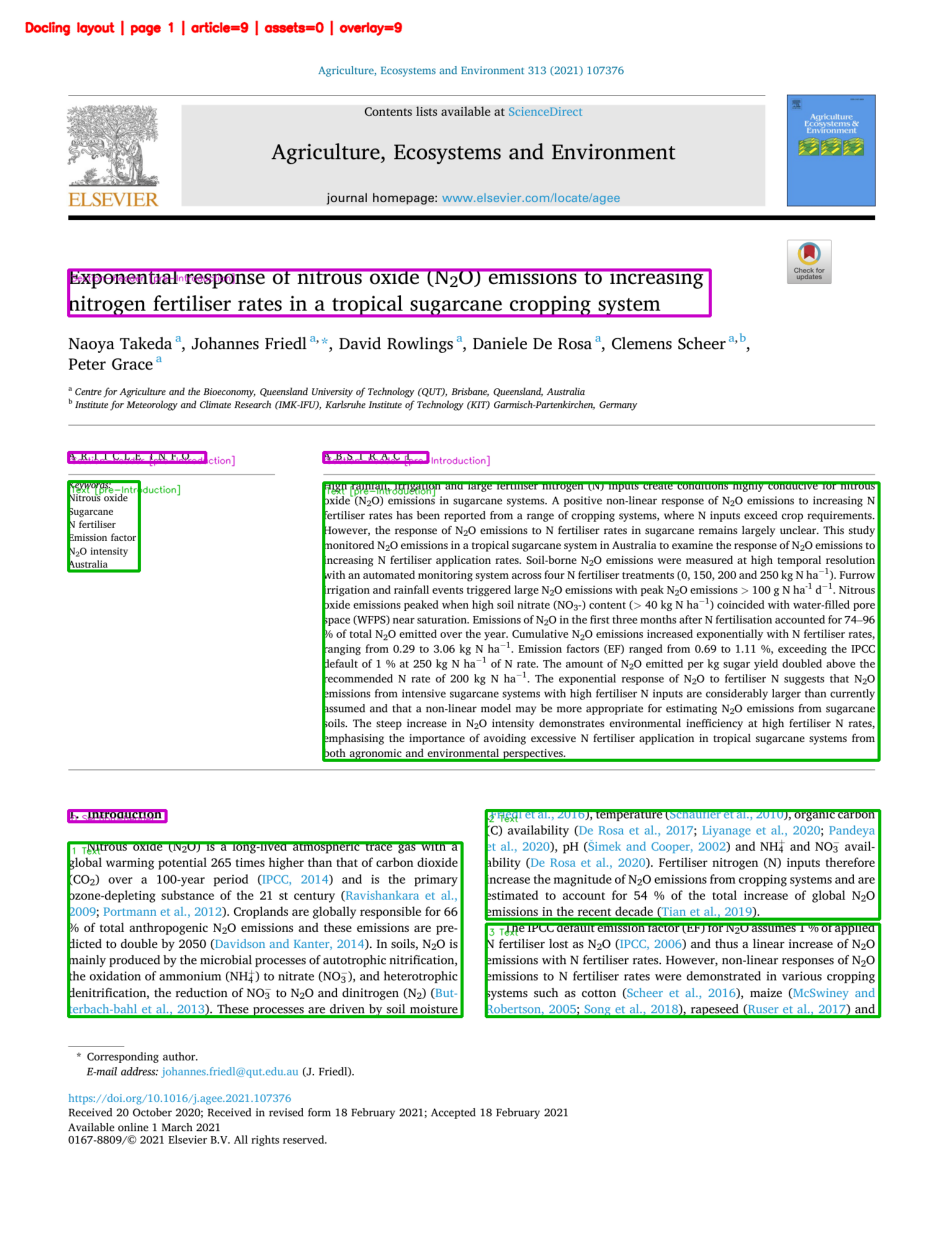

Overlay: /content/drive/MyDrive/00-ENVIRA/01-LayoutParser/phase1_docling/outputs/docling_layout_only/1-s2.0-S0167880921000803-main__abdb34c0bb6a/document/docling_overlays/page_0002_docling_layout_overlay.png


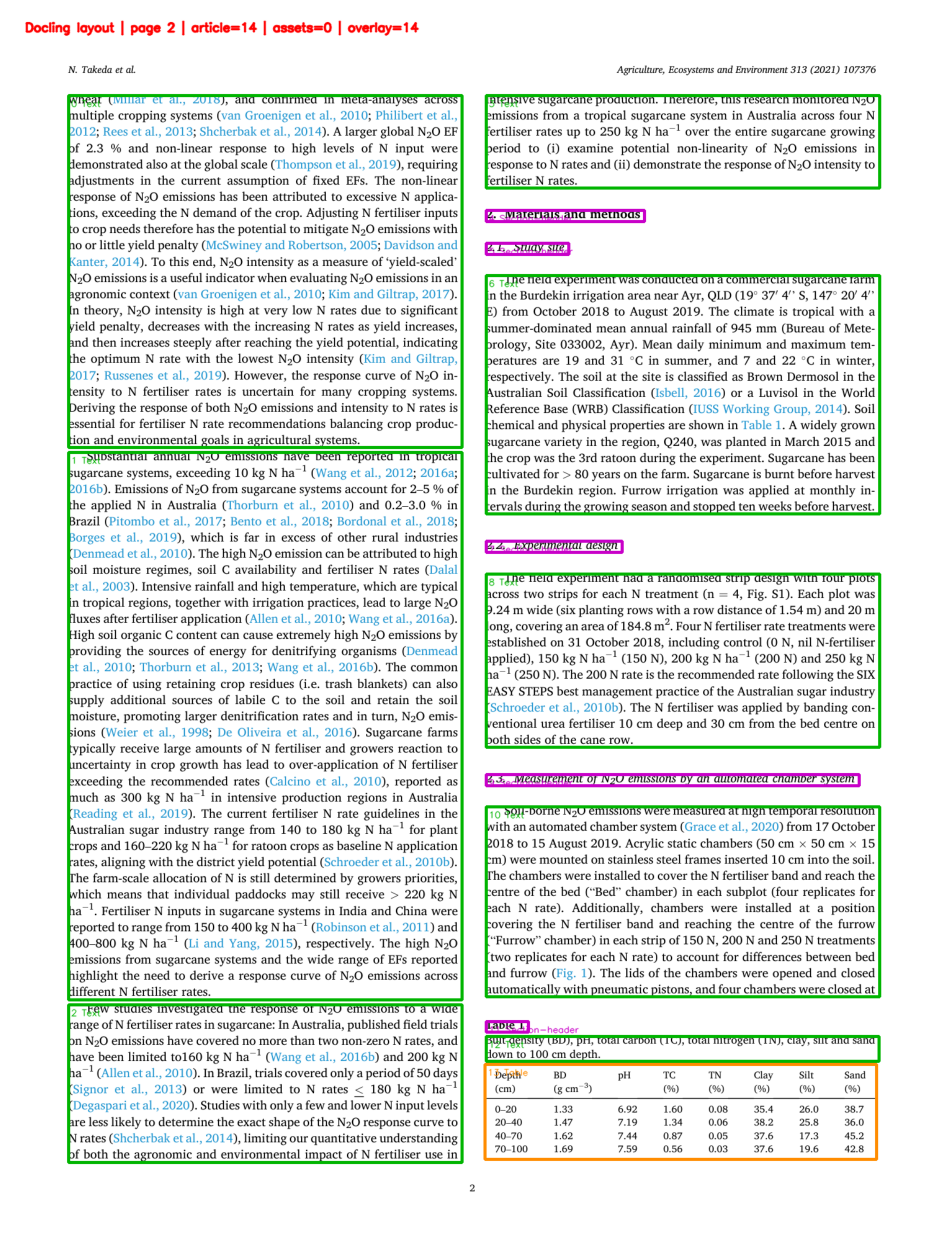

Overlay: /content/drive/MyDrive/00-ENVIRA/01-LayoutParser/phase1_docling/outputs/docling_layout_only/1-s2.0-S0167880921000803-main__abdb34c0bb6a/document/docling_overlays/page_0003_docling_layout_overlay.png


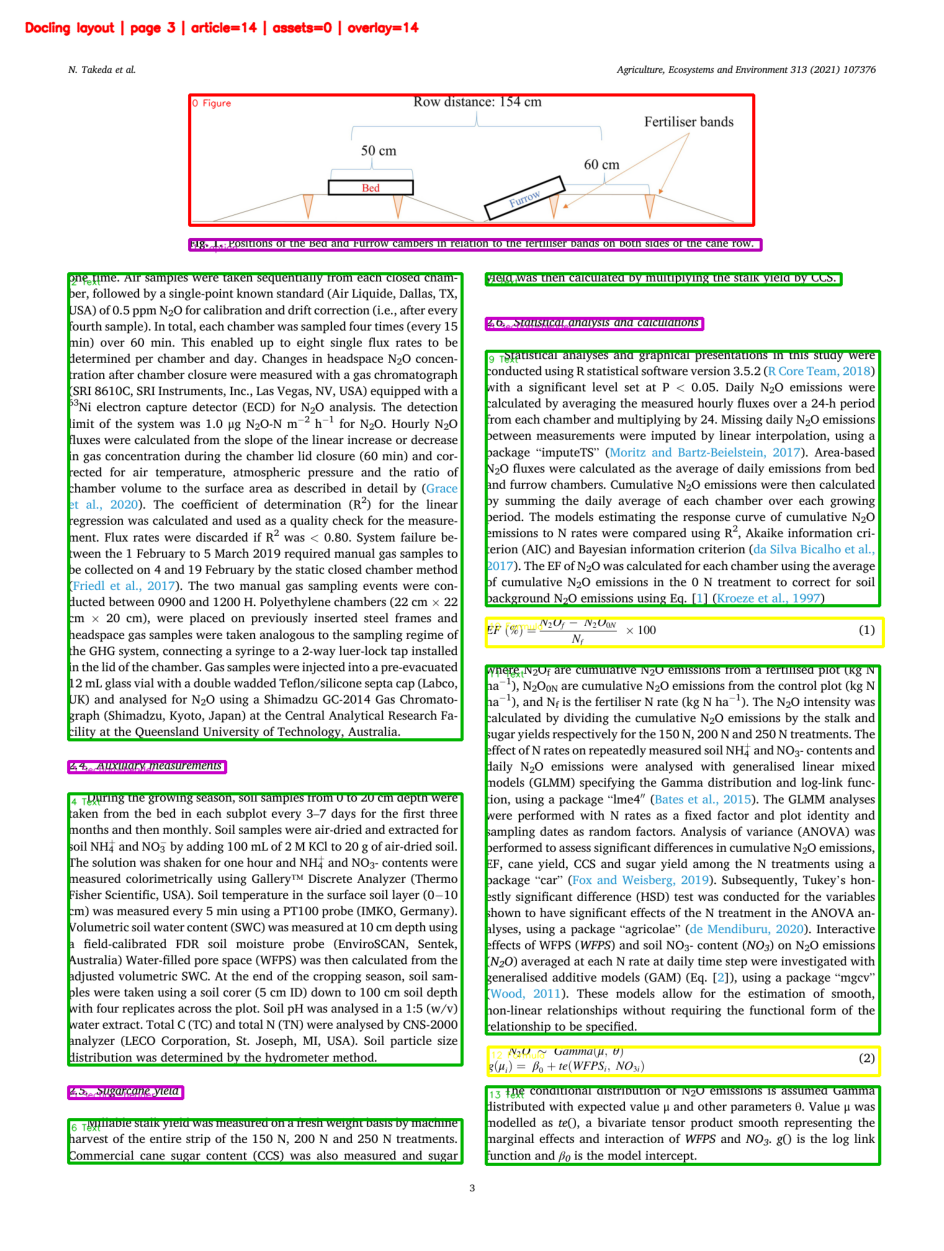

Overlay: /content/drive/MyDrive/00-ENVIRA/01-LayoutParser/phase1_docling/outputs/docling_layout_only/1-s2.0-S0167880921000803-main__abdb34c0bb6a/document/docling_overlays/page_0004_docling_layout_overlay.png


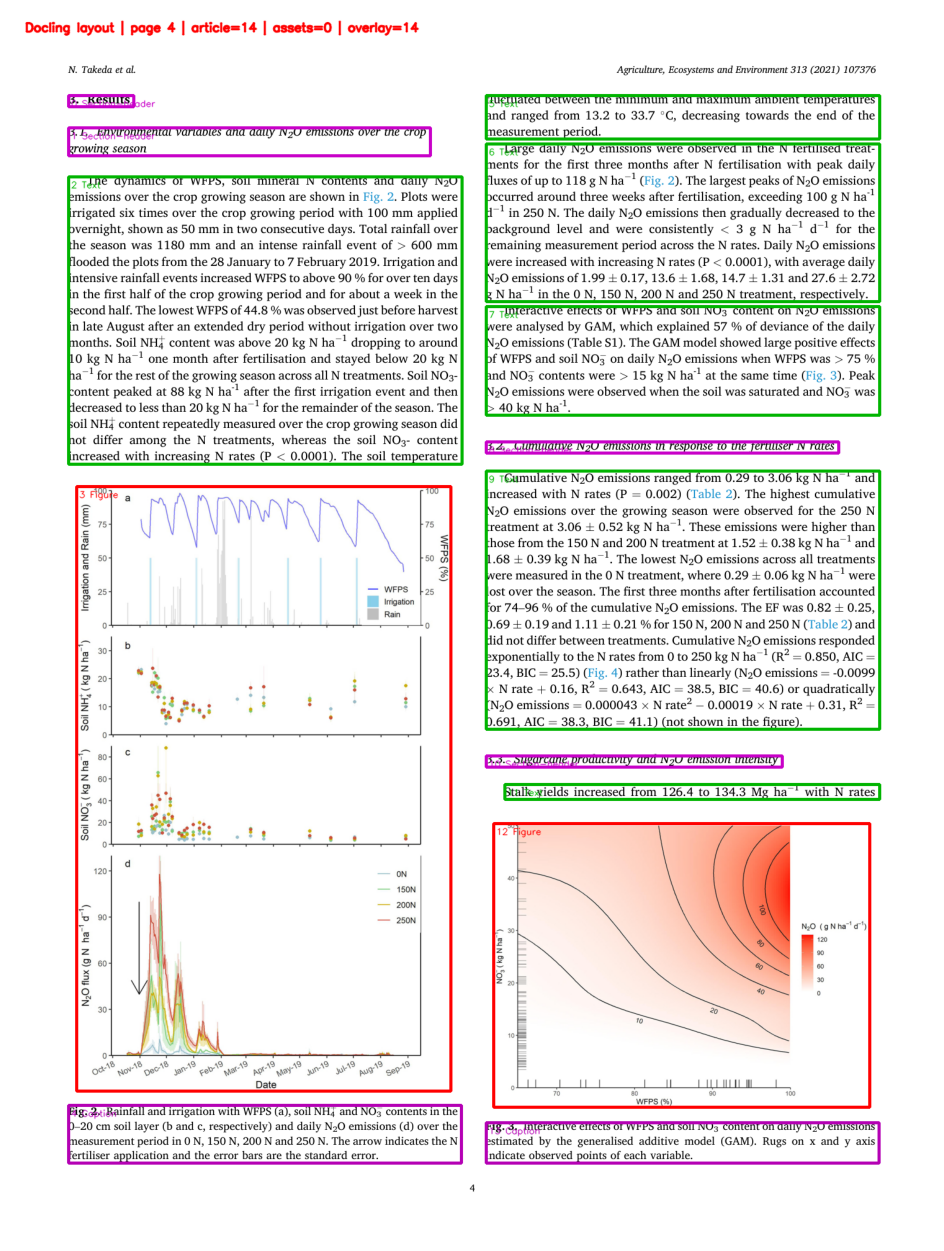

Overlay: /content/drive/MyDrive/00-ENVIRA/01-LayoutParser/phase1_docling/outputs/docling_layout_only/1-s2.0-S0167880921000803-main__abdb34c0bb6a/document/docling_overlays/page_0005_docling_layout_overlay.png


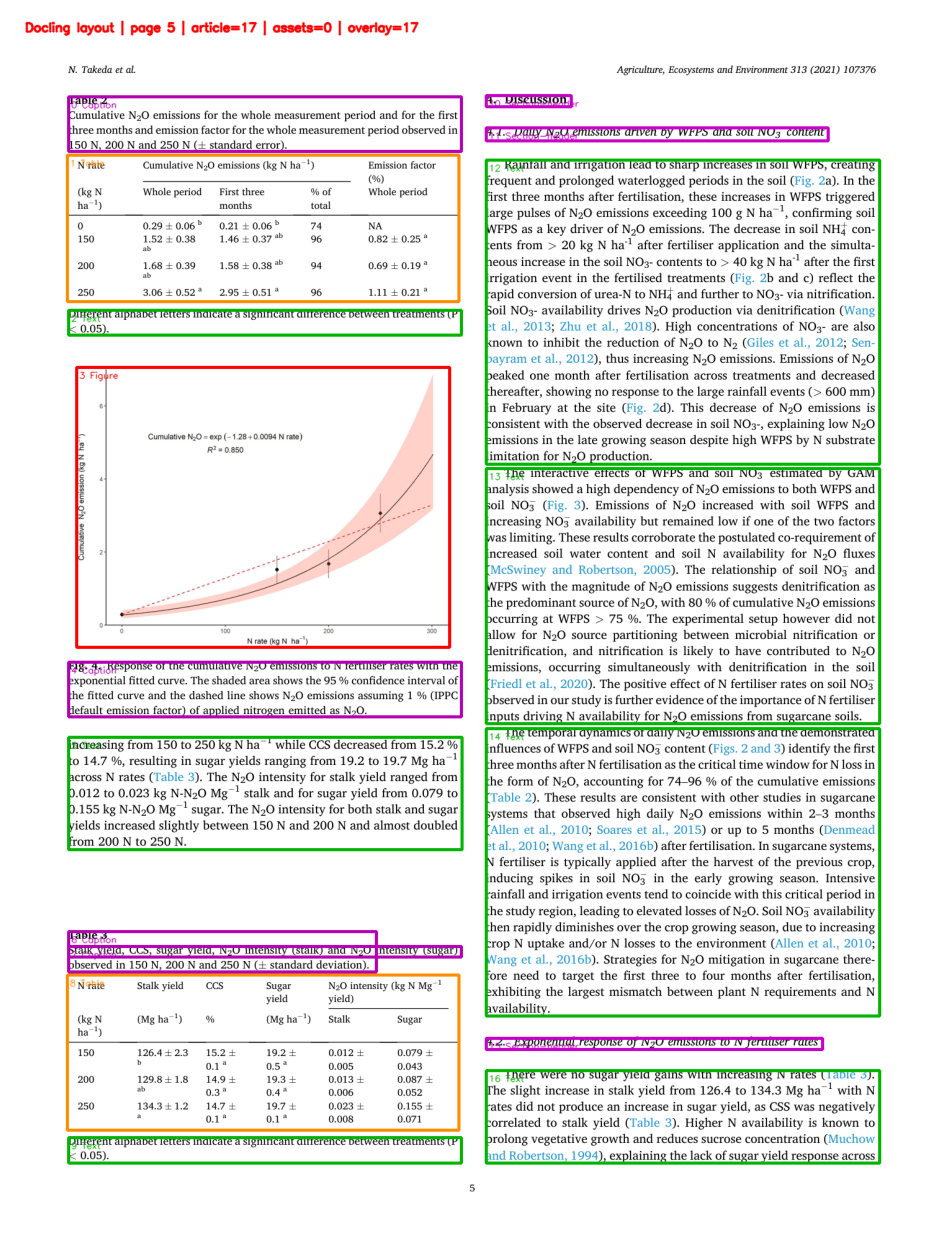

Overlay: /content/drive/MyDrive/00-ENVIRA/01-LayoutParser/phase1_docling/outputs/docling_layout_only/1-s2.0-S0167880921000803-main__abdb34c0bb6a/document/docling_overlays/page_0006_docling_layout_overlay.png


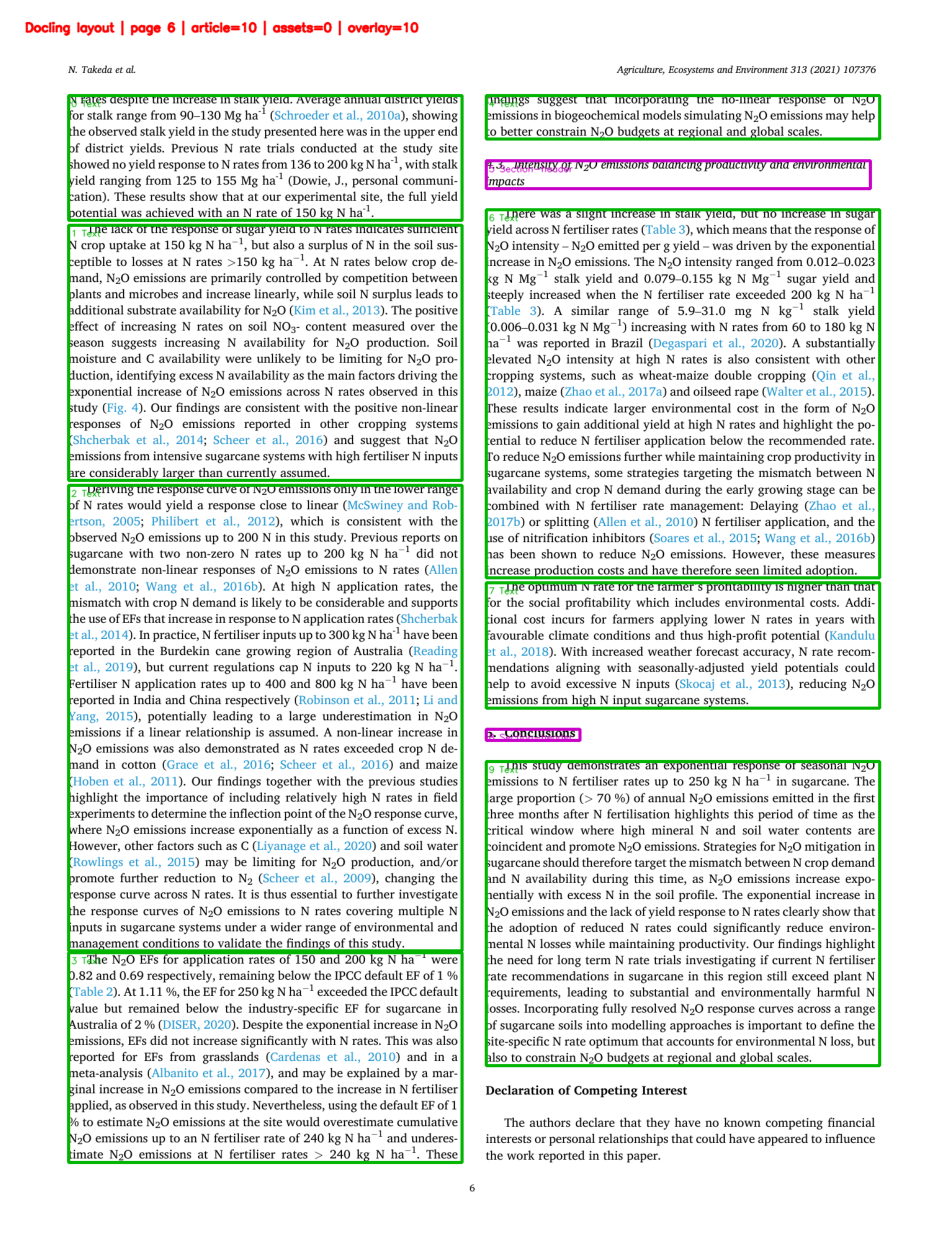

Overlay: /content/drive/MyDrive/00-ENVIRA/01-LayoutParser/phase1_docling/outputs/docling_layout_only/1-s2.0-S0167880921000803-main__abdb34c0bb6a/document/docling_overlays/page_0007_docling_layout_overlay.png


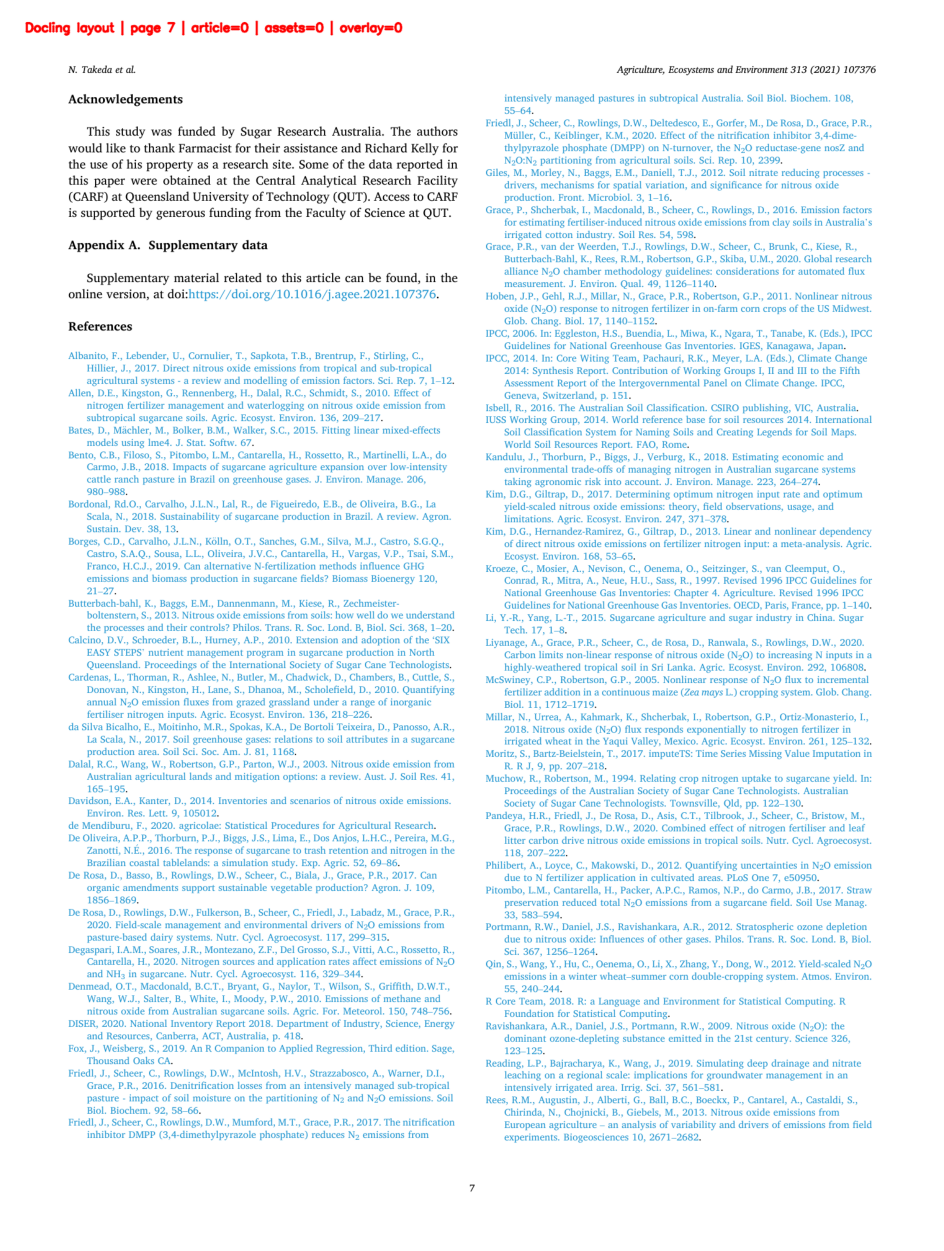

Overlay: /content/drive/MyDrive/00-ENVIRA/01-LayoutParser/phase1_docling/outputs/docling_layout_only/1-s2.0-S0167880921000803-main__abdb34c0bb6a/document/docling_overlays/page_0008_docling_layout_overlay.png


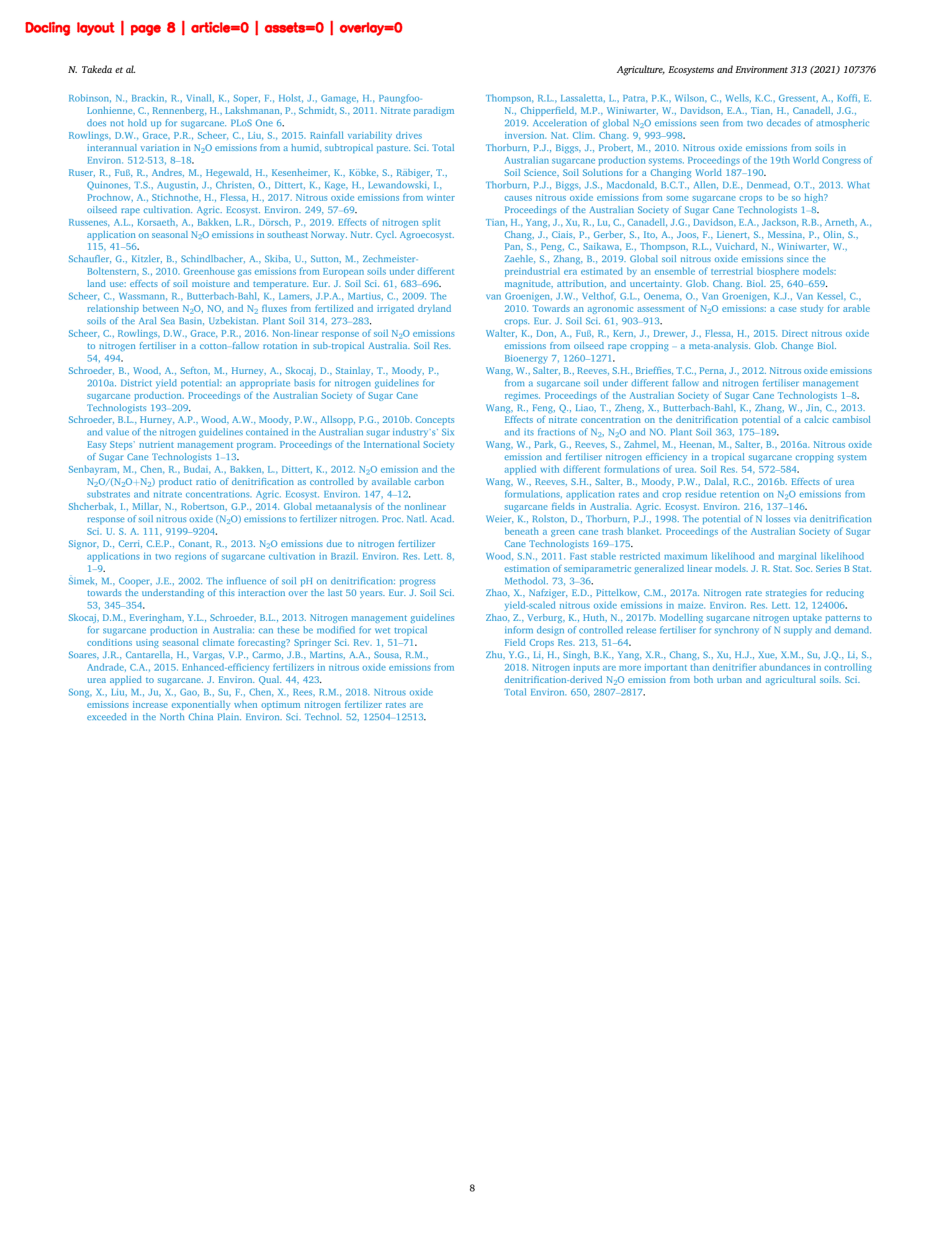

In [15]:
def draw_docling_layout_overlay(page_out: Dict[str, Any]) -> Path:
    page_number = int(page_out["page_number"])

    img = cv2.imread(page_out["page_image_path"], cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(page_out["page_image_path"])

    # OpenCV uses BGR, not RGB.
    colors = {
        "Text": (0, 180, 0),
        "Title": (255, 0, 255),
        "Section-header": (200, 0, 200),
        "List": (255, 120, 0),
        "Table": (0, 140, 255),
        "Formula": (0, 255, 255),
        "Caption": (180, 0, 180),
        "Footnote": (120, 120, 0),
        "Reference": (80, 180, 80),
        "Page-header": (120, 120, 120),
        "Page-footer": (80, 80, 80),
        "Figure": (0, 0, 255),
        "Unknown": (180, 180, 180),
    }

    article_regions = page_out.get("layout_regions", [])
    overlay_regions = page_out.get("asset_aware_overlay_regions", article_regions)

    for r in overlay_regions:
        x0, y0, x1, y1 = int_bbox(tuple(r["bbox_px"]))
        typ = r.get("type", "Unknown")
        color = colors.get(typ, colors["Unknown"])

        cv2.rectangle(img, (x0, y0), (x1, y1), color, 3)

        is_post_body_asset = bool(r.get("asset_association_role"))
        overlay_order = r.get("visual_overlay_order")
        if is_post_body_asset:
            asset_order = r.get("asset_overlay_order")
            role = str(r.get("asset_association_role", "asset"))
            scope = str(r.get("document_scope", "post_body_asset"))
            prefix = f"A{asset_order}" if asset_order is not None else "ASSET"
            label = f"{prefix} {typ}/{role} [{scope}]"
        elif overlay_order is None:
            label = f"{typ} [pre-Introduction]" if int(page_number) == 1 else typ
        else:
            label = f"{overlay_order} {typ}"
        raw_label = r.get("docling_label")
        if raw_label and docling_label_to_region_type(raw_label) != typ:
            label += f"/{raw_label}"
        if (
            r.get("synthetic_detection_method")
            == "caption_anchored_figure_completion"
        ):
            label += " [completed]"

        put_label(
            img,
            label,
            (x0 + 4, max(18, y0 + 18)),
            color,
            scale=0.48,
            thickness=1,
        )

    asset_count = len(page_out.get("post_body_asset_regions", []))
    title = (
        f"Docling layout | page {page_number} | "
        f"article={len(article_regions)} | assets={asset_count} | overlay={len(overlay_regions)}"
    )
    put_label(img, title, (24, 36), (0, 0, 255), scale=0.65, thickness=2)

    out_path = OVERLAY_DIR / f"page_{page_number:04d}_docling_layout_overlay.png"
    cv2.imwrite(str(out_path), img)
    return out_path


for page_out in layout_page_records:
    overlay_path = draw_docling_layout_overlay(page_out)
    page_out["overlay_path"] = str(overlay_path)

# Rewrite the combined page records now that overlay paths exist.
with DOCLING_PAGE_RECORDS_JSONL.open("w", encoding="utf-8") as page_f:
    for page_out in layout_page_records:
        page_f.write(json.dumps(page_out, ensure_ascii=False, default=str) + "\n")

for page_out in layout_page_records[:20]:
    print("Overlay:", page_out["overlay_path"])
    show_image(Path(page_out["overlay_path"]), width=12)


## 8. Inspect Docling regions

For later-page running-header tuning, run:

```python
debug_later_page_upper_header_detection(base_filtered_regions, page_map)
```

The diagnostic now shows:

- Docling upper-band candidates and their keep/drop evidence
- Reconstructed split/merged header rows
- Source-PDF top-ROI text lines
- Fuzzy recurrence clusters
- Per-page PDF-ROI header masks
- Region-to-mask overlap coverage
- OCR attempts or OCR errors, when the PDF text layer is unavailable

A region removed by the independent ROI path has:

```python
filter_reason = "later_page_pdf_roi_header_overlap"
```

For main-body-end tuning, run:

```python
debug_conclusion_tail_detection(base_filtered_regions, page_map)
```

The diagnostic shows both paths: the localized Conclusion anchor when one exists, and the conservative direct back-matter fallback when the paper ends with Discussion or has no explicit conclusion. It reports the selected boundary method, candidate scores, retained body content, and every region that would be removed.


For appendix/post-body asset preservation, inspect:

```python
print(POST_BODY_ASSETS_JSONL)
display(pd.DataFrame(post_body_asset_records))
display(pd.DataFrame(post_body_asset_regions))
```

The article-language-model stream remains main-body-only in `layout_regions`.
The visual overlay now uses `asset_aware_overlay_regions`, which is the union of
main-body regions and preserved appendix/post-body assets. Overlay labels beginning
with `A1`, `A2`, ... identify the separate asset stream. Pure reference pages still
correctly show zero regions when they contain no preserved figure/table asset.


For pages that have no retained article region and no Docling asset, inspect the
full-page table fallback with:

```python
debug_full_page_table_fallback(full_page_table_fallback_analysis)
```

A detected page receives one synthetic `Table` asset based on repeated source-PDF
word columns and rows. The fallback does not need to determine whether the page
continues a table from a neighboring page.


For a partially detected multi-panel figure, inspect the caption-anchored
completion decisions with:

```python
debug_caption_figure_completion(caption_figure_completion_analysis)
```

A completed figure retains the original Docling region id but receives an
expanded bbox and:

```python
synthetic_detection_method = "caption_anchored_figure_completion"
```


Caption-anchored figure completion now requires explicit multi-panel evidence by
default and will not cross another caption, heading, paragraph, table, formula,
or detected figure in the same lane. Single-panel captions such as `Fig. 2`
appear in diagnostics with:

```text
insufficient_multipanel_caption_evidence
```

The environment override remains available:

```python
PHASE1_CAPTION_FIGURE_COMPLETION_REQUIRE_MULTIPANEL_HINT=0
```

Disabling it is less conservative; hard barriers and merge-corridor checks still
remain active.


The compact footer-furniture fallback now uses normalized region size only as
candidate evidence. A tiny extreme-footer region is removed only when it has no
specifically assigned scientific caption and either:

- its region/source-PDF text contains a known publisher or imprint name; or
- it recurs on at least `COMPACT_FOOTER_MIN_REPEAT_PAGES` pages with similar
  size, vertical position, and visual/text identity.

Inspect all footer decisions with:

```python
debug_repeated_footer_visual_furniture(filtered_regions, page_map)
```

Relevant environment overrides include:

```text
PHASE1_COMPACT_FOOTER_FURNITURE_FILTER
PHASE1_COMPACT_FOOTER_Y0_MIN
PHASE1_COMPACT_FOOTER_MAX_WIDTH_RATIO
PHASE1_COMPACT_FOOTER_MAX_HEIGHT_RATIO
PHASE1_COMPACT_FOOTER_MAX_AREA_RATIO
PHASE1_COMPACT_FOOTER_MIN_REPEAT_PAGES
```


Compact footer confirmation now uses three increasingly broad sources while
keeping the original region bbox for candidate qualification:

1. the exact detected region;
2. an expanded local context bbox around that region;
3. a left/right edge-footer ROI used to locate a nearby publisher anchor.

The edge ROI does not independently remove content. Its publisher word must be
spatially associated with the compact candidate, and a specifically assigned
scientific figure/table caption still protects the region.

Useful diagnostics:

```python
debug_repeated_footer_visual_furniture(
    filtered_regions,
    page_map,
)
```

Inspect these columns for fragmented marks:

```text
publisher_confirmation_sources
context_bbox_px
edge_roi_bbox_px
publisher_anchor_hits
context_pdf_text
edge_footer_pdf_text
```


Compact footer candidate detection is now label-agnostic. A tiny region in the
extreme left or right footer can enter confirmation even when Docling labels it
as `list_item`, `caption`, `page_footer`, `unknown`, a line-like region, or
another article label. It is not removed merely because it is small.

Removal still requires:

- nearby publisher/imprint evidence from the exact bbox, expanded context, or
  edge-footer anchor; or
- repeated visual/text identity on multiple pages;

and the region must not have an assigned scientific caption. Explicit `Table`,
`Formula`, and text beginning with `Fig.`/`Figure`/`Table <number>` are protected.

Useful diagnostic columns now include:

```text
candidate_docling_label
candidate_region_type
candidate_word_count
candidate_line_like
candidate_hard_protected
candidate_content_shape_allowed
candidate_label_agnostic
publisher_confirmation_sources
drop
```


A separate `filter_small_edge_figures_page2_plus(...)` stage now removes
detected `Figure`/`Picture`/`Chart` regions on page 2 onward when:

- the complete bbox is contained inside the configured top or bottom band;
- normalized width, height, and area are below the compact visual thresholds;
- the visual is small relative to the median body scientific-figure area when
  a reliable document-level reference is available; and
- no specific scientific caption is assigned to it.

This is intentionally different from testing only the visual center. A large
scientific figure that starts near the top but extends into the body is not an
edge-furniture candidate.

Inspect decisions with:

```python
debug_small_edge_figures_page2_plus(
    filtered_regions,
    page_map,
)
```

Primary environment overrides:

```text
PHASE1_SMALL_EDGE_FIGURE_FILTER
PHASE1_SMALL_EDGE_FIGURE_HEADER_Y1_MAX
PHASE1_SMALL_EDGE_FIGURE_FOOTER_Y0_MIN
PHASE1_SMALL_EDGE_FIGURE_MAX_WIDTH_RATIO
PHASE1_SMALL_EDGE_FIGURE_MAX_HEIGHT_RATIO
PHASE1_SMALL_EDGE_FIGURE_MAX_AREA_RATIO
PHASE1_SMALL_EDGE_FIGURE_MAX_BODY_AREA_FRACTION
```


Page-1 post-abstract author metadata is now handled by:

```python
debug_page1_post_abstract_author_metadata(
    filtered_regions,
    page_map,
)
```

The detector first localizes the `Introduction` heading and infers body
column(s) only from substantive prose. It then removes contribution notes,
correspondence rows, and aligned affiliation blocks outside those body columns.
This avoids a fixed left/right assumption: documents whose Introduction
continues in both columns retain both columns.


The post-abstract filter also treats institution-bearing `list_item`,
`footnote`, and `reference` regions as explicit affiliation evidence when they
are outside the inferred Introduction body column. This covers Springer pages
where each affiliation is detected separately and its superscript number is
missing from the extracted text.


### Page-1 filter-stage independence

The lower-metadata filter and the post-abstract author-sidebar filter now run
in parallel against the same post-frontmatter regions. This prevents the lower
filter from deleting contribution/correspondence rows before those rows can
seed geometric expansion through weak-text or empty-text affiliation
`list_item` regions. Their drop sets are merged afterward, duplicate
exclusions are removed, and the specialized sidebar reason takes precedence.


### Column-aware page-1 abstract transition

The page-1 metadata filter no longer requires an `Introduction` heading. It
detects `Abstract`, optional `Keywords`, and optional `Introduction` anchors,
infers abstract prose columns, and records a separate bottom for each abstract
column. Metadata can therefore be removed beneath the left abstract column
while the right abstract column is still continuing.

It also recognizes `Supplementary/Supporting Information`, `Present Address`,
correspondence rows, and multilingual organization evidence as semantic seeds.
Use:

```python
debug_page1_post_abstract_author_metadata(
    page1_post_frontmatter_regions,
    page_map,
)
```

The title filter now hard-rejects bullet-separated and ORCID-like author
bylines, and split-title fragments must be directly compatible with the
original title seed rather than recursively bridging through lower regions.


### Regression-safe page-1 metadata filtering

The column-aware fallback is now separated by behavior:

- **Before Introduction:** per-column abstract bottoms are used, but only
  explicit metadata or compact affiliation-like rows can seed removal.
- **After Introduction:** the conservative legacy rule is restored.
  Affiliation-only regions must be outside inferred Introduction body columns.
- All text-like fragments inside inferred abstract bands or Introduction body
  columns are protected, including short continuation and citation fragments
  that do not satisfy the normal paragraph threshold.
- Institution words alone no longer make ordinary scientific prose metadata;
  the region must also have compact affiliation-row structure.

Use the existing debug helper to inspect the new fields
`abstract_band_fragment` and `intro_column_fragment`.


### Introduction-column upward backfill

For two-column first pages, the first fragment of the right Introduction
column can begin slightly above the bottom of the left-column `Introduction`
heading. The page-1 analyzer now backfills such a fragment only when it:

- overlaps an already inferred Introduction body column;
- is vertically adjacent to the top of that column;
- starts below the corresponding abstract-column bottom;
- is textual article content rather than explicit metadata.

The analyzer returns `protected_article_region_ids`. These IDs are removed from
the independent lower-metadata exclusion set before the page-1 drop sets are
merged, so a confirmed Abstract/Keywords/Introduction region cannot be deleted
by a later page-1 cleanup stage.

The debug table includes `intro_column_backfill`, `intro_column_top`,
`intro_backfill_floor`, and `intro_backfill_gap`.


### Nested elements inside Figures and Tables

After caption-anchored figure completion, the pipeline now keeps the parent
`Figure`/`Table` region and removes other layout regions detected inside it.

Two geometry paths are used:

1. **Strong containment** for regions almost fully inside the asset.
2. **Edge-fragment overlap** for false `Text` boxes created from axis ticks,
   error bars, plotted lines, or similar graphics that extend partly into blank
   space outside the asset.

Captions receive the relaxed-overlap protection, so a legitimate caption that
only touches an asset boundary is preserved. A caption genuinely enclosed by
the asset is still removed through strong containment.

Inspect decisions with:

```python
debug_nested_asset_elements(
    filtered_regions,
    page_map,
)
```

Environment controls use the prefix `PHASE1_NESTED_ASSET_...`. Set
`PHASE1_NESTED_ASSET_ELEMENT_FILTER=0` to disable this stage.


### Bilateral side-margin text filter

The side-margin cleanup is now symmetric. It removes narrow text-like page
furniture in either the **left** or **right** outer margin.

A region must:

- be text-like;
- be narrow;
- be mostly contained in one outer side band;
- have its center in that same side band; and
- be vertically elongated or very compact.

This avoids removing normal article columns that merely begin near the page
edge. Decisions are recorded as
`left_side_margin_text_furniture` or
`right_side_margin_text_furniture`.

Inspect candidates with:

```python
debug_side_margin_text_regions(
    filtered_regions,
    page_map,
)
```

Set `PHASE1_SIDE_MARGIN_TEXT_FILTER=0` to disable the stage.


### `Summary` as an abstract-equivalent page-1 heading

The page-1 frontmatter logic now treats a standalone `Summary` heading exactly
like `Abstract`:

- it can become the first useful page-1 body anchor;
- its following prose is analyzed as abstract content;
- it is protected from upper-frontmatter and lower-metadata removal;
- the later `Introduction` heading still starts article reading order.

The default aliases are configured by:

```python
PHASE1_PAGE1_ABSTRACT_EQUIVALENT_ALIASES="Abstract,Summary"
```

When Docling preserves the Summary body but omits the standalone heading, a
strict PDF-text fallback recovers only an exact configured heading line. The
candidate must be on page 1, above Introduction, within the frontmatter band,
and have substantial prose immediately below it. This fallback does not run
OCR and does not match short later headings such as `Summary and conclusions`.

Recovery details are stored in
`page1_abstract_equivalent_recovery` in the page-1 output metadata. Disable it
with `PHASE1_PAGE1_ABSTRACT_EQUIVALENT_PDF_RECOVERY=0`.


In [16]:
regions_df = pd.DataFrame(all_layout_regions)
cols = [
    "doc_id",
    "page_number",
    "docling_reading_order",
    "visual_overlay_order",
    "layout_reading_order",
    "included_in_layout_reading_order",
    "reading_order_column",
    "reading_order_band",
    "reading_order_role",
    "reading_order_excluded_reason",
    "type",
    "docling_label",
    "text",
    "orig",
    "bbox_px",
    "width_px",
    "height_px",
    "area_px",
    "page_image_path",
]
cols = [c for c in cols if c in regions_df.columns]
display(regions_df[cols].head(150))

print("Region type counts:")
if len(regions_df):
    display(regions_df.groupby(["page_number", "type"]).size().reset_index(name="count"))
else:
    print("No regions found after filtering.")

print("Formula/equation candidates:")
if len(regions_df) and "type" in regions_df.columns:
    display(regions_df[regions_df["type"].isin(["Formula", "Code"])][cols].head(50))


# Examples:
# debug_later_page_upper_header_detection(base_filtered_regions, page_map)
# debug_conclusion_tail_detection(base_filtered_regions, page_map)
# debug_layout_reading_order(layout_page_records[0])  # page 1
# debug_layout_reading_order(layout_page_records[1])  # page 2


,doc_id,page_number,docling_reading_order,visual_overlay_order,layout_reading_order,included_in_layout_reading_order,reading_order_column,reading_order_band,reading_order_role,reading_order_excluded_reason,type,docling_label,text,orig,bbox_px,width_px,height_px,area_px,page_image_path
0,1-s2.0-S0167880921000803-main__abdb34c0bb6a,1,0,NaN,NaN,False,NaN,NaN,None,page1_before_introduction,Section-header,section_header,Exponential response of nitrous oxide (N2O) em...,Exponential response of nitrous oxide (N2O) em...,"[94.01964552272214, 420.22668876799054, 1128.1...",1034.152161,73.956227,76481.992129,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...
1,1-s2.0-S0167880921000803-main__abdb34c0bb6a,1,1,NaN,NaN,False,NaN,NaN,None,page1_before_introduction,Section-header,section_header,A R T I C L E I N F O,A R T I C L E I N F O,"[94.01964552272214, 714.0980118144686, 315.476...",221.456991,15.998378,3542.952600,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...
2,1-s2.0-S0167880921000803-main__abdb34c0bb6a,1,5,NaN,NaN,False,NaN,NaN,None,page1_before_introduction,Section-header,section_header,A B S T R A C T,A B S T R A C T,"[505.26735918561286, 714.0980118144686, 673.23...",167.965765,15.998378,2687.179756,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...
3,1-s2.0-S0167880921000803-main__abdb34c0bb6a,1,2,NaN,NaN,False,NaN,NaN,None,page1_before_introduction,Text,text,Keywords: Nitrous oxide Sugarcane N fertiliser...,Keywords: Nitrous oxide Sugarcane N fertiliser...,"[94.01964552272214, 761.4661596118967, 208.125...",114.106202,143.226101,16342.986370,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...
4,1-s2.0-S0167880921000803-main__abdb34c0bb6a,1,6,NaN,NaN,False,NaN,NaN,None,page1_before_introduction,Text,text,"High rainfall, irrigation and large fertiliser...","High rainfall, irrigation and large fertiliser...","[505.26735918561286, 762.5394285425813, 1400.2...",894.970800,447.058466,400104.272947,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,1-s2.0-S0167880921000803-main__abdb34c0bb6a,6,2,2.0,2.0,True,0.0,0.0,column,None,Text,text,Deriving the response curve of N2O emissions o...,Deriving the response curve of N2O emissions o...,"[94.01999941523528, 766.5872885449114, 727.985...",633.965684,750.891945,476039.725692,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...
74,1-s2.0-S0167880921000803-main__abdb34c0bb6a,6,7,7.0,7.0,True,1.0,0.0,column,None,Text,text,The optimum N rate for the farmer ' s profitab...,The optimum N rate for the farmer ' s profitab...,"[766.9070087145246, 924.3935493603045, 1400.81...",633.912000,201.331018,127626.147981,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...
75,1-s2.0-S0167880921000803-main__abdb34c0bb6a,6,8,8.0,8.0,True,1.0,0.0,column,None,Section-header,section_header,5. Conclusions,5. Conclusions,"[766.9118526995927, 1159.8993746093477, 917.51...",150.605236,18.284221,2753.699392,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...
76,1-s2.0-S0167880921000803-main__abdb34c0bb6a,6,9,9.0,9.0,True,1.0,0.0,column,None,Text,text,This study demonstrates an exponential respons...,This study demonstrates an exponential respons...,"[766.906291224219, 1212.2188737285026, 1400.80...",633.901277,489.299363,310167.491337,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...


Region type counts:


,page_number,type,count
0,1,Section-header,4
1,1,Text,5
2,2,Section-header,5
3,2,Table,1
4,2,Text,8
5,3,Caption,1
6,3,Figure,1
7,3,Formula,2
8,3,Section-header,3
9,3,Text,7


Formula/equation candidates:


,doc_id,page_number,docling_reading_order,visual_overlay_order,layout_reading_order,included_in_layout_reading_order,reading_order_column,reading_order_band,reading_order_role,reading_order_excluded_reason,type,docling_label,text,orig,bbox_px,width_px,height_px,area_px,page_image_path
29,1-s2.0-S0167880921000803-main__abdb34c0bb6a,3,10,10.0,10.0,True,1.0,2.0,column,None,Formula,formula,\text {mes and} \\ \text {primeime of} \quad \...,EF ( % ) = N 2 Of N 2 O 0 N Nf × 100 (1),"[766.9053957871122, 981.1857874863159, 1406.63...",639.733423,46.037581,29451.779196,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...
33,1-s2.0-S0167880921000803-main__abdb34c0bb6a,3,12,12.0,12.0,True,1.0,2.0,column,None,Formula,formula,\begin{array} { c c c c c c c c c c c c c c c ...,"N 2 O ∼ Gamma ( μ , θ ) g ( μi ) = β 0 + te ( ...","[770.3105506741977, 1672.0476863489896, 1400.7...",630.487418,45.670714,28794.810858,/content/drive/MyDrive/00-ENVIRA/01-LayoutPars...


## Google Drive / deployment notes

### Colab first run, online

Run normally. The notebook will mount Google Drive and use:

```text
/content/drive/MyDrive/00-ENVIRA/01-LayoutParser/phase1_docling
```

Docling models are loaded from:

```text
/content/drive/MyDrive/00-ENVIRA/01-LayoutParser/phase1_docling/artifacts/docling_models
```

The notebook also creates/uses:

```text
/content/drive/MyDrive/00-ENVIRA/01-LayoutParser/phase1_docling/requirements.txt
```

Outputs are saved per PDF using `DOC_ID = filename + sha256 hash`:

```text
/content/drive/MyDrive/00-ENVIRA/01-LayoutParser/phase1_docling/outputs/docling_layout_only/<DOC_ID>/
```

This prevents different PDFs from overwriting each other.

### Colab next run

Run the notebook again. If the Drive model folder contains complete model artifacts, the validation cell will reuse them and skip downloading.

### Colab stable/offline-style rerun after models are saved

Set these before running the notebook:

```python
%env PHASE1_PROJECT_DIR=/content/drive/MyDrive/00-ENVIRA/01-LayoutParser/phase1_docling
%env PHASE1_OFFLINE_MODE=1
%env PHASE1_FORCE_REDOWNLOAD_DOCLING_MODELS=0
```

Use this only when your runtime or server environment already has the packages installed from `requirements.txt`:

```python
%env PHASE1_SKIP_PIP_INSTALL=1
```

### Force a fresh model download

Only use this when you intentionally want to refresh the cached Docling models:

```python
%env PHASE1_AUTO_DOWNLOAD_DOCLING_MODELS=1
%env PHASE1_FORCE_REDOWNLOAD_DOCLING_MODELS=1
%env PHASE1_OFFLINE_MODE=0
```

### Server/deployment version with requirements.txt

Install dependencies once using the provided `requirements.txt`:

```bash
pip install -r requirements.txt
```

Then point the project to a persistent folder that already contains the saved Docling models:

```bash
export PHASE1_PROJECT_DIR=/path/to/phase1_docling
export PHASE1_OFFLINE_MODE=1
export PHASE1_SKIP_PIP_INSTALL=1
export PHASE1_FORCE_REDOWNLOAD_DOCLING_MODELS=0
```

### Optional figure filtering

Default keeps figures. To exclude Docling picture/chart regions later:

```python
%env PHASE1_DOCLING_EXCLUDE_LABELS=picture,chart
```

To keep them again:

```python
%env PHASE1_DOCLING_EXCLUDE_LABELS=
```

### Optional separate run folders for the same PDF

By default, rerunning the same PDF writes to the same `<DOC_ID>` folder. If you want a separate folder for a specific run:

```python
%env PHASE1_RUN_ID=test_run_001
```
